In [46]:
import pandas as pd

# 1. Definiamo il nome del file
file_name = "sp500_1m.csv" 

print(f"Sto caricando il file {file_name}...")

# 2. Pandas legge il CSV e lo trasforma in un DataFrame
df = pd.read_csv(file_name)

# 3. Mostriamo le prime 5 righe
display(df.head())

# 4. Chiediamo le informazioni tecniche
print("\n--- INFORMAZIONI SUL DATASET ---")
print(df.info())

Sto caricando il file sp500_1m.csv...


FileNotFoundError: [Errno 2] No such file or directory: 'sp500_1m.csv'

In [ ]:
# 1. Convertiamo in formato temporale forzando l'UTC per risolvere i fusi orari misti
print("Conversione delle date e allineamento fusi orari (Standardizzazione UTC)...")
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)

# 2. Convertiamo il fuso orario in quello di Wall Street (America/New_York)
# Così le candele di apertura saranno sempre allineate alle 09:30 locali, indipendentemente dall'ora legale
df['Datetime'] = df['Datetime'].dt.tz_convert('America/New_York')

# 3. Trasformiamo la colonna Datetime nel nostro Indice
df.set_index('Datetime', inplace=True)

# 4. Ordiniamo cronologicamente
df.sort_index(inplace=True)

# 5. Controlliamo i dati mancanti
print("\n--- CONTROLLO DATI MANCANTI (NA) ---")
print(df.isna().sum())

# 6. Mostriamo la nuova struttura
print("\n--- NUOVA STRUTTURA ---")
print(df.info())


Conversione delle date e allineamento fusi orari (Standardizzazione UTC)...


NameError: name 'df' is not defined

In [ ]:
# 1. Definiamo le regole matematiche per costruire le candele superiori
ohlcv_dict = {
    'Open': 'first',  # L'apertura è il primo prezzo del periodo
    'High': 'max',    # Il massimo è il picco raggiunto nel periodo
    'Low': 'min',     # Il minimo è il punto più basso del periodo
    'Close': 'last',  # La chiusura è l'ultimo prezzo del periodo
    'Volume': 'sum'   # Il volume è la somma di tutte le transazioni
}

print("Costruzione dei Timeframe Superiori (MTF) in corso...")

# 2. Resampling: Raggruppiamo i minuti in Ore, Giorni e Settimane
# Usiamo dropna() per eliminare le candele vuote (es. i weekend o le ore di chiusura)
df_h1 = df.resample('1h').agg(ohlcv_dict).dropna()
df_h4 = df.resample('4h').agg(ohlcv_dict).dropna()
df_daily = df.resample('D').agg(ohlcv_dict).dropna()
df_weekly = df.resample('W-FRI').agg(ohlcv_dict).dropna()

# 3. Stampiamo i risultati della compressione dei dati
print("\n--- RIEPILOGO MULTITIMEFRAME ---")
print(f"Candele originali M1:  {len(df):,}")
print(f"Candele create H1:     {len(df_h1):,}")
print(f"Candele create H4:     {len(df_h4):,}")
print(f"Candele create Daily:  {len(df_daily):,}")
print(f"Candele create Weekly: {len(df_weekly):,}")

# 4. Mostriamo le ultime 5 candele Daily per verificare che i prezzi siano corretti
print("\n--- ULTIME 5 CANDELE DAILY ---")
display(df_daily.tail())

Costruzione dei Timeframe Superiori (MTF) in corso...

--- RIEPILOGO MULTITIMEFRAME ---
Candele originali M1:  1,767,869
Candele create H1:     31,146
Candele create H4:     8,272
Candele create Daily:  1,627
Candele create Weekly: 262

--- ULTIME 5 CANDELE DAILY ---


,Open,High,Low,Close,Volume
Datetime,,,,,
2026-02-18 00:00:00-05:00,6874.75,6925.75,6861.50,6893.75,1279289
2026-02-19 00:00:00-05:00,6893.75,6912.50,6847.75,6888.75,1240635
2026-02-20 00:00:00-05:00,6888.75,6931.50,6847.25,6924.75,1693316
2026-02-22 00:00:00-05:00,6918.00,6923.00,6867.50,6870.75,78773
2026-02-23 00:00:00-05:00,6870.75,6930.25,6832.75,6865.75,924635


In [ ]:
import numpy as np

# 1. Definiamo la funzione matematica per calcolare l'ATR
def calculate_atr(df, period=14):
    # Il True Range è il massimo tra 3 valori per gestire anche i "gap" di apertura
    high_low = df['High'] - df['Low']
    high_close_prev = np.abs(df['High'] - df['Close'].shift(1))
    low_close_prev = np.abs(df['Low'] - df['Close'].shift(1))
    
    # Troviamo il True Range giornaliero
    tr = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    
    # L'ATR è semplicemente la media mobile (rolling mean) del True Range
    atr = tr.rolling(window=period).mean()
    return atr

print("Calcolo dell'ATR a 14 periodi sui timeframe H4 e Daily...")

# 2. Applichiamo la funzione ai nostri dataset
df_daily['ATR_14'] = calculate_atr(df_daily)
df_h4['ATR_14'] = calculate_atr(df_h4)

# 3. Puliamo le prime 14 righe che avranno "NaN" (Not a Number) perché la media stava partendo
df_daily.dropna(inplace=True)
df_h4.dropna(inplace=True)

# 4. Stampiamo i risultati
print("\n--- ULTIME 5 CANDELE DAILY CON VOLATILITÀ (ATR) ---")
display(df_daily[['Close', 'ATR_14']].tail())

Calcolo dell'ATR a 14 periodi sui timeframe H4 e Daily...

--- ULTIME 5 CANDELE DAILY CON VOLATILITÀ (ATR) ---


,Close,ATR_14
Datetime,,
2026-02-18 00:00:00-05:00,6893.75,95.767857
2026-02-19 00:00:00-05:00,6888.75,90.321429
2026-02-20 00:00:00-05:00,6924.75,88.964286
2026-02-22 00:00:00-05:00,6870.75,80.750000
2026-02-23 00:00:00-05:00,6865.75,74.625000


In [ ]:
import numpy as np

print("Calcolo delle Medie Mobili e del Regime di Mercato (HTF)...")

# 1. Calcoliamo EMA 50 e EMA 200 sul Daily
df_daily['EMA_50'] = df_daily['Close'].ewm(span=50, adjust=False).mean()
df_daily['EMA_200'] = df_daily['Close'].ewm(span=200, adjust=False).mean()

# 2. Definiamo le regole del Regime (True/False)
cond_long = (df_daily['Close'] > df_daily['EMA_50']) & (df_daily['EMA_50'] > df_daily['EMA_200'])
cond_short = (df_daily['Close'] < df_daily['EMA_50']) & (df_daily['EMA_50'] < df_daily['EMA_200'])

# 3. Assegniamo: 1 per Bull, -1 per Bear, 0 per Chop (Neutro)
df_daily['Regime'] = np.where(cond_long, 1, np.where(cond_short, -1, 0))

# 4. Verifichiamo la situazione attuale
print("\n--- ANALISI DEL REGIME DI MERCATO (DAILY) ---")
display(df_daily[['Close', 'EMA_50', 'EMA_200', 'Regime']].tail())

# 5. Controlliamo statisticamente quanto tempo il mercato passa in ogni regime
print("\n--- DISTRIBUZIONE STORICA DEI REGIMI (5 ANNI) ---")
print(df_daily['Regime'].value_counts(normalize=True) * 100)

Calcolo delle Medie Mobili e del Regime di Mercato (HTF)...

--- ANALISI DEL REGIME DI MERCATO (DAILY) ---


,Close,EMA_50,EMA_200,Regime
Datetime,,,,
2026-02-18 00:00:00-05:00,6893.75,6914.832130,6686.534918,0
2026-02-19 00:00:00-05:00,6888.75,6913.809302,6688.547008,0
2026-02-20 00:00:00-05:00,6924.75,6914.238349,6690.897287,1
2026-02-22 00:00:00-05:00,6870.75,6912.532923,6692.686866,0
2026-02-23 00:00:00-05:00,6865.75,6910.698299,6694.408887,0



--- DISTRIBUZIONE STORICA DEI REGIMI (5 ANNI) ---
Regime
 1    60.780669
 0    26.827757
-1    12.391574
Name: proportion, dtype: float64


In [ ]:
print("Allineamento dei dati HTF sul timeframe a 1 minuto (M1)...")

# 1. Selezioniamo solo le colonne che ci interessano dal Daily
daily_signals = df_daily[['Regime', 'ATR_14']].copy()

# 2. FONDAMENTALE: Shiftiamo tutto di 1 giorno. 
# I segnali calcolati a fine lunedì saranno validi per tutto il martedì.
daily_signals = daily_signals.shift(1)

# 3. Rimuoviamo il fuso orario dal daily per facilitare il merge, 
# allineandolo solo alla data (Anno-Mese-Giorno)
daily_signals.index = daily_signals.index.date

# 4. Creiamo una colonna "Data" nel dataframe a 1 minuto per poterli unire
df['Date_Only'] = df.index.date

# 5. Facciamo il "Merge" (Unione): Spalmiamo i dati daily su ogni singolo minuto
df_bot = df.merge(daily_signals, left_on='Date_Only', right_index=True, how='left')

# 6. Puliamo il dataset dalle prime giornate senza ATR
df_bot.dropna(inplace=True)
df_bot.drop(columns=['Date_Only'], inplace=True)

print("\n--- DATASET PRONTO PER L'EXECUTION ENGINE (Prime 5 righe) ---")
display(df_bot.head())

Allineamento dei dati HTF sul timeframe a 1 minuto (M1)...

--- DATASET PRONTO PER L'EXECUTION ENGINE (Prime 5 righe) ---


,Open,High,Low,Close,Volume,Regime,ATR_14
Datetime,,,,,,,
2021-03-11 00:00:00-05:00,3905.00,3905.50,3905.00,3905.25,10,0.0,77.214286
2021-03-11 00:01:00-05:00,3905.00,3905.25,3904.00,3904.00,18,0.0,77.214286
2021-03-11 00:02:00-05:00,3904.25,3905.25,3904.25,3905.00,8,0.0,77.214286
2021-03-11 00:03:00-05:00,3904.25,3905.25,3904.25,3905.00,12,0.0,77.214286
2021-03-11 00:04:00-05:00,3904.75,3904.75,3904.25,3904.25,13,0.0,77.214286


In [ ]:
import numpy as np

print("Inizio Feature Engineering sul dataset a 1 minuto...")

# 1. TIME FEATURES (Il calendario del Bot)
df['Hour'] = df.index.hour
df['Minute'] = df.index.minute
df['DayOfWeek'] = df.index.dayofweek # 0 = Lunedì, 4 = Venerdì

# Definiamo le sessioni (Orario di New York)
# Riconosciamo l'apertura (09:30-10:30), il pranzo (12:00-13:30) e la chiusura (15:00-16:00)
conditions = [
    (df.index.time >= pd.to_datetime('09:30').time()) & (df.index.time <= pd.to_datetime('10:30').time()),
    (df.index.time > pd.to_datetime('12:00').time()) & (df.index.time <= pd.to_datetime('13:30').time()),
    (df.index.time >= pd.to_datetime('15:00').time()) & (df.index.time <= pd.to_datetime('16:00').time())
]
choices = ['NY_Open', 'Lunch', 'Power_Hour']
df['Session'] = np.select(conditions, choices, default='Other')

# 2. VWAP (Il vero prezzo istituzionale intraday)
# Creiamo una colonna temporanea per la sola Data (ci serve per raggruppare ogni giornata)
df['Date'] = df.index.date

# Calcolo del Prezzo Tipico
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
df['VP'] = df['Typical_Price'] * df['Volume']

# Somma cumulativa giornaliera di VP e Volumi
df['Cum_VP'] = df.groupby('Date')['VP'].cumsum()
df['Cum_Vol'] = df.groupby('Date')['Volume'].cumsum()

# Il VWAP finale
df['VWAP'] = df['Cum_VP'] / df['Cum_Vol']

# 3. STRETCH INDICATOR (L'elastico per la Mean Reversion)
# Distanza in punti percentuali dal VWAP (Positivo = Sopra, Negativo = Sotto)
df['Dist_VWAP_%'] = ((df['Close'] - df['VWAP']) / df['VWAP']) * 100

# 4. OVERNIGHT GAP (Sbilanciamento iniziale)
# Prendiamo la chiusura Daily (calcolata prima) e la confrontiamo con l'apertura di oggi
daily_close = df_daily['Close'].shift(1)
daily_close.index = daily_close.index.date # Allineiamo le date

# Creiamo un piccolo dizionario per mappare rapidamente i valori sul dataset a 1 minuto
df['Prev_Daily_Close'] = df['Date'].map(daily_close)
df['Gap_%'] = ((df['Open'] - df['Prev_Daily_Close']) / df['Prev_Daily_Close']) * 100

# Pulizia delle colonne temporanee
df.drop(columns=['Typical_Price', 'VP', 'Cum_VP', 'Cum_Vol'], inplace=True)
# Rimuoviamo i primissimi dati dove non c'è una chiusura precedente
df.dropna(subset=['Prev_Daily_Close'], inplace=True) 

print("\n--- FEATURE ENGINEERING COMPLETATA ---")
print(df.info())

# Mostriamo una sezione di mercato aperto (es. alle 10:00 del mattino)
print("\n--- ESEMPIO DI DATI ARRICCHITI (Apertura NY) ---")
display(df[(df['Hour'] == 10) & (df['Minute'] == 0)].tail(3))

Inizio Feature Engineering sul dataset a 1 minuto...

--- FEATURE ENGINEERING COMPLETATA ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1752495 entries, 2021-03-11 00:00:00-05:00 to 2026-02-23 13:28:00-05:00
Data columns (total 15 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Open              float64
 1   High              float64
 2   Low               float64
 3   Close             float64
 4   Volume            int64  
 5   Date_Only         object 
 6   Hour              int32  
 7   Minute            int32  
 8   DayOfWeek         int32  
 9   Session           str    
 10  Date              object 
 11  VWAP              float64
 12  Dist_VWAP_%       float64
 13  Prev_Daily_Close  float64
 14  Gap_%             float64
dtypes: float64(8), int32(3), int64(1), object(2), str(1)
memory usage: 193.9+ MB
None

--- ESEMPIO DI DATI ARRICCHITI (Apertura NY) ---


,Open,High,Low,Close,Volume,Date_Only,Hour,Minute,DayOfWeek,Session,Date,VWAP,Dist_VWAP_%,Prev_Daily_Close,Gap_%
Datetime,,,,,,,,,,,,,,,
2026-02-19 10:00:00-05:00,6886.75,6886.75,6879.75,6882.50,3398,2026-02-19,10,0,3,NY_Open,2026-02-19,6877.047207,0.079290,6893.75,-0.101541
2026-02-20 10:00:00-05:00,6875.50,6880.75,6873.25,6878.75,3837,2026-02-20,10,0,4,NY_Open,2026-02-20,6869.930318,0.128381,6888.75,-0.192343
2026-02-23 10:00:00-05:00,6893.75,6896.25,6892.75,6895.00,2867,2026-02-23,10,0,0,NY_Open,2026-02-23,6904.437092,-0.136682,6870.75,0.334752


In [ ]:
import numpy as np

print("Calcolo delle metriche Quant Avanzate in corso...")

# 1. LIVELLI DEL GIORNO PRECEDENTE (PDH, PDL, PDC)
# Usiamo il df_daily che abbiamo già calcolato prima, lo shiftiamo di 1 giorno e mappiamo
daily_shifted = df_daily.shift(1)
daily_shifted.index = daily_shifted.index.date

df['PDH'] = df['Date'].map(daily_shifted['High'])
df['PDL'] = df['Date'].map(daily_shifted['Low'])
df['PDC'] = df['Date'].map(daily_shifted['Close'])

# 2. INITIAL BALANCE (IB - Prima ora di Wall Street 09:30 - 10:30)
# Filtriamo solo l'orario di apertura
ib_mask = (df.index.time >= pd.to_datetime('09:30').time()) & (df.index.time < pd.to_datetime('10:30').time())
# Calcoliamo il massimo e il minimo per ogni giornata in quell'orario
ib_data = df[ib_mask].groupby('Date').agg({'High': 'max', 'Low': 'min'})
# Mappiamo i risultati su tutte le righe della giornata
df['IB_High'] = df['Date'].map(ib_data['High'])
df['IB_Low'] = df['Date'].map(ib_data['Low'])

# 3. Z-SCORE INTRADAY (Anomalia statistica a 50 minuti)
window = 50
rolling_mean = df['Close'].rolling(window=window).mean()
rolling_std = df['Close'].rolling(window=window).std()
df['Z_Score_50'] = (df['Close'] - rolling_mean) / rolling_std

# 4. RELATIVE VOLUME (RVOL Time-of-Day)
# Calcola la media dei volumi per OGNI SINGOLO MINUTO dell'intera storia
# Esempio: Media di tutti i volumi scambiati esattamente alle 10:14 nei 5 anni
time_vol_mean = df.groupby(df.index.time)['Volume'].transform('mean')
# RVOL = Volume Attuale / Media Storica di quel minuto
df['RVOL'] = df['Volume'] / time_vol_mean

# 5. RSI FAST (10 Periodi su M1, per catturare l'ipervenduto estremo)
def calculate_rsi(series, period=10):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI_10'] = calculate_rsi(df['Close'], period=10)

print("\n--- METRICHE AVANZATE CALCOLATE CON SUCCESSO ---")
# Mostriamo le colonne per assicurarci che ci sia tutto
print(df[['Close', 'PDH', 'IB_High', 'Z_Score_50', 'RVOL', 'RSI_10']].tail())

Calcolo delle metriche Quant Avanzate in corso...

--- METRICHE AVANZATE CALCOLATE CON SUCCESSO ---
                             Close     PDH  IB_High  Z_Score_50      RVOL  \
Datetime                                                                    
2026-02-23 13:24:00-05:00  6866.75  6923.0  6930.25    1.773392  1.186163   
2026-02-23 13:25:00-05:00  6867.25  6923.0  6930.25    1.732650  0.810148   
2026-02-23 13:26:00-05:00  6866.00  6923.0  6930.25    1.524500  0.977629   
2026-02-23 13:27:00-05:00  6866.75  6923.0  6930.25    1.539367  0.911778   
2026-02-23 13:28:00-05:00  6865.75  6923.0  6930.25    1.385167  0.674363   

                              RSI_10  
Datetime                              
2026-02-23 13:24:00-05:00  84.090909  
2026-02-23 13:25:00-05:00  82.926829  
2026-02-23 13:26:00-05:00  69.230769  
2026-02-23 13:27:00-05:00  70.000000  
2026-02-23 13:28:00-05:00  65.116279  


In [ ]:
print("Fusione del Contesto Macro (Daily) con il Micro-Strutturale (M1)...")

# 1. Prepariamo i dati Daily: prendiamo Regime e ATR e li SHIFTIAMO di 1 giorno.
# Regola d'oro: i calcoli di chiusura di lunedì valgono per tradare tutto il martedì.
daily_features = df_daily[['Regime', 'ATR_14']].copy().shift(1)

# Allineiamo l'indice alla sola data per facilitare l'incastro
daily_features.index = daily_features.index.date

# 2. Mappiamo il Regime e l'ATR sul nostro dataset a 1 minuto
df['Regime_Daily'] = df['Date'].map(daily_features['Regime'])
df['ATR_Daily'] = df['Date'].map(daily_features['ATR_14'])

# 3. DATA TRIMMING: Eliminiamo tutte le righe che non hanno dati completi
# Questo taglierà via le primissime settimane dei tuoi 5 anni di storico, 
# lasciandoci solo con dati puri e calcolabili al 100%
df.dropna(inplace=True)

# 4. Rimuoviamo colonne temporanee che non ci servono più per liberare memoria
if 'Date' in df.columns:
    df.drop(columns=['Date'], inplace=True)

print("\n--- DATASET QUANTITATIVO FINALE COMPLETATO ---")
print(f"Righe pronte per il Backtest: {len(df):,}")
print(f"Colonne (Features) disponibili: {len(df.columns)}")

# Mostriamo l'aspetto finale della nostra "macchina"
display(df.info())

Fusione del Contesto Macro (Daily) con il Micro-Strutturale (M1)...

--- DATASET QUANTITATIVO FINALE COMPLETATO ---
Righe pronte per il Backtest: 1,662,513
Colonne (Features) disponibili: 24
<class 'pandas.DataFrame'>
DatetimeIndex: 1662513 entries, 2021-03-11 00:49:00-05:00 to 2026-02-23 13:28:00-05:00
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Open              1662513 non-null  float64
 1   High              1662513 non-null  float64
 2   Low               1662513 non-null  float64
 3   Close             1662513 non-null  float64
 4   Volume            1662513 non-null  int64  
 5   Date_Only         1662513 non-null  object 
 6   Hour              1662513 non-null  int32  
 7   Minute            1662513 non-null  int32  
 8   DayOfWeek         1662513 non-null  int32  
 9   Session           1662513 non-null  str    
 10  VWAP              1662513 non-null  float64
 11  Dist_VWAP_%       16

None

In [ ]:
import numpy as np

print("Scansione di 5 anni di dati per la generazione del Benchmark...")

# 1. CONDIZIONI LONG (Panico dei retail in mercato Toro)
cond_long = (
    (df['Regime_Daily'] == 1) &             # Trend di fondo Rialzista
    (df['Session'] == 'NY_Open') &          # Solo prima ora di contrattazione
    (df['Dist_VWAP_%'] < -0.3) &            # Prezzo crollato sotto il VWAP
    (df['Z_Score_50'] < -2.0) &             # Deviazione statistica estrema al ribasso
    (df['RSI_10'] < 15)                     # Ipervenduto estremo a 1 minuto
)

# 2. CONDIZIONI SHORT (Euforia dei retail in mercato Orso)
cond_short = (
    (df['Regime_Daily'] == -1) &            # Trend di fondo Ribassista
    (df['Session'] == 'NY_Open') &          # Solo prima ora di contrattazione
    (df['Dist_VWAP_%'] > 0.3) &             # Prezzo esploso sopra il VWAP
    (df['Z_Score_50'] > 2.0) &              # Deviazione statistica estrema al rialzo
    (df['RSI_10'] > 85)                     # Ipercomprato estremo a 1 minuto
)

# 3. Generazione della colonna Segnali (0 = Nessuna azione, 1 = Compra, -1 = Vendi)
df['Signal'] = 0
df.loc[cond_long, 'Signal'] = 1
df.loc[cond_short, 'Signal'] = -1

# 4. CALCOLO DINAMICO DI TP E SL (Basato puramente sui dati)
# Usiamo il 25% dell'ATR giornaliero per dare respiro al trade intraday
atr_multiplier = 0.25 

# Calcoli per i trade LONG
df.loc[df['Signal'] == 1, 'Target_Price'] = df['VWAP']
df.loc[df['Signal'] == 1, 'Stop_Loss'] = df['Close'] - (df['ATR_Daily'] * atr_multiplier)

# Calcoli per i trade SHORT
df.loc[df['Signal'] == -1, 'Target_Price'] = df['VWAP']
df.loc[df['Signal'] == -1, 'Stop_Loss'] = df['Close'] + (df['ATR_Daily'] * atr_multiplier)

# 5. RIEPILOGO DEI RISULTATI
total_long = (df['Signal'] == 1).sum()
total_short = (df['Signal'] == -1).sum()

print("\n--- RISULTATI BENCHMARK (5 ANNI) ---")
print(f"Segnali LONG generati:  {total_long}")
print(f"Segnali SHORT generati: {total_short}")
print(f"Totale Operazioni:      {total_long + total_short}")

# Mostriamo le prime operazioni Long se ne ha trovate
if total_long > 0:
    print("\n--- ANATOMIA DEI PRIMI SETUP LONG TROVATI ---")
    display(df[df['Signal'] == 1][['Close', 'VWAP', 'Target_Price', 'Stop_Loss', 'ATR_Daily']].head())

Scansione di 5 anni di dati per la generazione del Benchmark...

--- RISULTATI BENCHMARK (5 ANNI) ---
Segnali LONG generati:  338
Segnali SHORT generati: 208
Totale Operazioni:      546

--- ANATOMIA DEI PRIMI SETUP LONG TROVATI ---


,Close,VWAP,Target_Price,Stop_Loss,ATR_Daily
Datetime,,,,,
2021-05-04 09:45:00-04:00,4153.00,4167.193542,4167.193542,4144.696429,33.214286
2021-05-04 09:46:00-04:00,4151.75,4166.756175,4166.756175,4143.446429,33.214286
2021-05-04 09:47:00-04:00,4152.50,4166.377163,4166.377163,4144.196429,33.214286
2021-05-04 09:48:00-04:00,4150.75,4166.116592,4166.116592,4142.446429,33.214286
2021-05-04 09:49:00-04:00,4148.25,4165.747146,4165.747146,4139.946429,33.214286


In [ ]:
import pandas as pd

print("Avvio del Motore di Backtest VETTORIALE Corretto...")

signals = df[df['Signal'] != 0].copy()
trades = []

for entry_time, row in signals.iterrows():
    signal_dir = row['Signal']
    entry_price = row['Close']
    tp = row['Target_Price']
    sl = row['Stop_Loss']
    
    # Ritagliamo SOLO i dati dall'ingresso fino alle 16:00
    end_of_day = entry_time.replace(hour=16, minute=0, second=0)
    future_data = df.loc[entry_time:end_of_day].iloc[1:]
    
    # Default: se non tocca né TP né SL, si chiude alle 16:00
    outcome = 'Time_Exit'
    if not future_data.empty:
        exit_price = future_data['Close'].iloc[-1]
    else:
        exit_price = entry_price
    
    if not future_data.empty:
        if signal_dir == 1: # LONG
            hit_tp = future_data[future_data['High'] >= tp].index
            hit_sl = future_data[future_data['Low'] <= sl].index
        else: # SHORT
            hit_tp = future_data[future_data['Low'] <= tp].index
            hit_sl = future_data[future_data['High'] >= sl].index
            
        has_tp = len(hit_tp) > 0
        has_sl = len(hit_sl) > 0
        
        # Logica di uscita pulita: chi è arrivato prima?
        if has_tp and has_sl:
            if hit_tp[0] < hit_sl[0]:
                outcome = 'Win'
                exit_price = tp
            else:
                outcome = 'Loss'
                exit_price = sl
        elif has_tp:
            outcome = 'Win'
            exit_price = tp
        elif has_sl:
            outcome = 'Loss'
            exit_price = sl

    # Calcoliamo il Profitto/Perdita (in Punti Indice)
    if signal_dir == 1:
        pnl_points = exit_price - entry_price
    else:
        pnl_points = entry_price - exit_price
    
    trades.append({
        'Entry_Time': entry_time,
        'Signal': 'LONG' if signal_dir == 1 else 'SHORT',
        'Entry_Price': entry_price,
        'Exit_Price': exit_price,
        'Target_Price': tp,
        'Stop_Loss': sl,
        'Outcome': outcome,
        'PnL_Points': pnl_points
    })

# Creiamo il DataFrame finale
df_trades = pd.DataFrame(trades)

print("\n--- ELABORAZIONE COMPLETATA ---")

# Metriche
total_trades = len(df_trades)
winning_trades = len(df_trades[df_trades['PnL_Points'] > 0])
win_rate = (winning_trades / total_trades) * 100 if total_trades > 0 else 0
total_pnl = df_trades['PnL_Points'].sum()

print(f"\n--- METRICHE DEL BENCHMARK ---")
print(f"Totale Trade Eseguiti: {total_trades}")
print(f"Win Rate:              {win_rate:.2f}%")
print(f"Profitto Totale:       {total_pnl:.2f} Punti S&P500")

print("\n--- DISTRIBUZIONE ESITI ---")
print(df_trades['Outcome'].value_counts())

Avvio del Motore di Backtest VETTORIALE Corretto...

--- ELABORAZIONE COMPLETATA ---

--- METRICHE DEL BENCHMARK ---
Totale Trade Eseguiti: 546
Win Rate:              37.18%
Profitto Totale:       -951.07 Punti S&P500

--- DISTRIBUZIONE ESITI ---
Outcome
Loss         326
Win          190
Time_Exit     30
Name: count, dtype: int64


In [ ]:
# Analisi della qualità dei trade eseguiti
avg_win = df_trades[df_trades['PnL_Points'] > 0]['PnL_Points'].mean()
avg_loss = df_trades[df_trades['PnL_Points'] < 0]['PnL_Points'].abs().mean()
expectancy = (win_rate/100 * avg_win) - ((1 - win_rate/100) * avg_loss)

print(f"Media Punti vinti: {avg_win:.2f}")
print(f"Media Punti persi: {avg_loss:.2f}")
print(f"Rapporto R/R Reale: {(avg_win/avg_loss):.2f}")
print(f"Aspettativa (Expectancy) per trade: {expectancy:.2f} punti")

Media Punti vinti: 22.26
Media Punti persi: 15.95
Rapporto R/R Reale: 1.40
Aspettativa (Expectancy) per trade: -1.74 punti


In [ ]:
# Analisi differenziata per direzione
performance_dir = df_trades.groupby('Signal').agg({
    'PnL_Points': ['count', 'sum', 'mean'],
    'Outcome': lambda x: (x == 'Win').sum() / len(x) * 100
})
performance_dir.columns = ['Trade_Count', 'Total_PnL', 'Avg_PnL', 'Win_Rate_%']

print("--- PERFORMANCE PER DIREZIONE ---")
display(performance_dir)

# Analisi dei Time_Exit (Quanti trade stavano vincendo ma sono stati chiusi alle 16:00?)
time_exits = df_trades[df_trades['Outcome'] == 'Time_Exit']
te_positive = len(time_exits[time_exits['PnL_Points'] > 0])
print(f"\nTrade chiusi a fine giornata in profitto: {te_positive} su {len(time_exits)}")

--- PERFORMANCE PER DIREZIONE ---


,Trade_Count,Total_PnL,Avg_PnL,Win_Rate_%
Signal,,,,
LONG,338,-353.775059,-1.046672,30.177515
SHORT,208,-597.291549,-2.871594,42.307692



Trade chiusi a fine giornata in profitto: 13 su 30


In [ ]:
import numpy as np

print("Esecuzione Test C: Focus su Volume Climax e Reattività...")

# 1. REGOLE TEST C (IL WASHOUT)
cond_long_C = (
    (df['Regime_Daily'] == 1) & 
    (df['Session'] == 'NY_Open') & 
    (df['RVOL'] > 2.5) &              # VOLUME CLIMAX (Essenziale)
    (df['Dist_VWAP_%'] < -0.25) &     # Prezzo decentemente lontano dal VWAP
    (df['RSI_10'] < 20)               # Ipervenduto presente ma meno estremo
)

df['Signal_C'] = 0
df.loc[cond_long_C, 'Signal_C'] = 1

# 2. LOGICA DI USCITA (STRETTA E VELOCE)
# Stop Loss = Minimo candela precedente - 5 punti (molto aggressivo)
# Take Profit = Ritorno al VWAP
df['TP_C'] = df['VWAP']
df['SL_C'] = df['Low'].shift(1) - 5 # Protezione sotto lo swing

# 3. MOTORE DI BACKTEST
signals_C = df[df['Signal_C'] != 0].copy()
trades_C = []

for entry_time, row in signals_C.iterrows():
    entry_p = row['Close']
    tp = row['TP_C']
    sl = row['SL_C']
    
    end_day = entry_time.replace(hour=16, minute=0, second=0)
    future = df.loc[entry_time:end_day].iloc[1:]
    
    outcome = 'Time_Exit'
    exit_p = future['Close'].iloc[-1] if not future.empty else entry_p
    
    if not future.empty:
        # Scansione rapida
        hit_tp = future[future['High'] >= tp].index
        hit_sl = future[future['Low'] <= sl].index
        
        if len(hit_tp) > 0 and (len(hit_sl) == 0 or hit_tp[0] < hit_sl[0]):
            outcome = 'Win'
            exit_p = tp
        elif len(hit_sl) > 0:
            outcome = 'Loss'
            exit_p = sl

    trades_C.append({'PnL': exit_p - entry_p, 'Outcome': outcome})

df_results_C = pd.DataFrame(trades_C)

print(f"\n--- RISULTATI TEST C (CLIMAX) ---")
if len(df_results_C) > 0:
    wr_C = (len(df_results_C[df_results_C['PnL'] > 0]) / len(df_results_C)) * 100
    print(f"Totale Trade: {len(df_results_C)}")
    print(f"Win Rate:     {wr_C:.2f}%")
    print(f"PnL Totale:   {df_results_C['PnL'].sum():.2f}")
    print(df_results_C['Outcome'].value_counts())
else:
    print("Nessun segnale trovato con questi parametri.")

Esecuzione Test C: Focus su Volume Climax e Reattività...

--- RISULTATI TEST C (CLIMAX) ---
Totale Trade: 114
Win Rate:     31.58%
PnL Totale:   78.80
Outcome
Loss    96
Win     18
Name: count, dtype: int64


In [ ]:
print("Esecuzione Scenario MOMENTUM: Breakout Initial Balance...")

# 1. REGOLE DI INGRESSO (FOLLOW THE TREND)
# Entriamo se il prezzo rompe il massimo della prima ora (IB_High) 
# Ma solo se siamo in un Regime Daily Bull (1)
cond_long_break = (
    (df['Regime_Daily'] == 1) & 
    (df.index.time > pd.to_datetime('10:30').time()) & # Dopo la prima ora
    (df.index.time < pd.to_datetime('14:00').time()) & # Ma prima del tardo pomeriggio
    (df['Close'] > df['IB_High']) &                   # Rottura del massimo iniziale
    (df['Close'].shift(1) <= df['IB_High']) &        # La candela precedente era sotto (conferma rottura)
    (df['RVOL'] > 1.1)                               # Volume presente
)

df['Signal_Momo'] = 0
df.loc[cond_long_break, 'Signal_Momo'] = 1

# 2. LOGICA DI USCITA (TRAILING O FIXED)
# Per questo test usiamo un R/R 1:1 puro basato sulla volatilità (ATR)
tp_dist = 0.50 * df['ATR_Daily']
sl_dist = 0.50 * df['ATR_Daily']

df['TP_Momo'] = df['Close'] + tp_dist
df['SL_Momo'] = df['Close'] - sl_dist

# 3. BACKTEST RAPIDO
signals_momo = df[df['Signal_Momo'] == 1].copy()
trades_momo = []

for entry_time, row in signals_momo.iterrows():
    entry_p = row['Close']
    tp = row['TP_Momo']
    sl = row['SL_Momo']
    end_day = entry_time.replace(hour=16, minute=0, second=0)
    future = df.loc[entry_time:end_day].iloc[1:]
    
    outcome = 'Time_Exit'
    exit_p = future['Close'].iloc[-1] if not future.empty else entry_p
    
    if not future.empty:
        h_tp = future[future['High'] >= tp].index
        h_sl = future[future['Low'] <= sl].index
        if len(h_tp) > 0 and (len(h_sl) == 0 or h_tp[0] < h_sl[0]):
            outcome = 'Win'; exit_p = tp
        elif len(h_sl) > 0:
            outcome = 'Loss'; exit_p = sl

    trades_momo.append({'PnL': exit_p - entry_p, 'Outcome': outcome})

df_res_momo = pd.DataFrame(trades_momo)

print(f"\n--- RISULTATI SCENARIO MOMENTUM ---")
if len(df_res_momo) > 0:
    print(f"Totale Trade: {len(df_res_momo)}")
    print(f"Win Rate:     {(len(df_res_momo[df_res_momo['PnL'] > 0]) / len(df_res_momo)) * 100:.2f}%")
    print(f"PnL Totale:   {df_res_momo['PnL'].sum():.2f}")
    print(df_res_momo['Outcome'].value_counts())
else:
    print("Nessun breakout trovato.")

Esecuzione Scenario MOMENTUM: Breakout Initial Balance...

--- RISULTATI SCENARIO MOMENTUM ---
Totale Trade: 421
Win Rate:     57.01%
PnL Totale:   278.02
Outcome
Time_Exit    240
Loss          98
Win           83
Name: count, dtype: int64


In [ ]:
import numpy as np

print("Calcolo degli indicatori per lo Scalping ad alta frequenza...")

# 1. KAUFMAN EFFICIENCY RATIO (ER) - Finestra a 10 minuti
# Misura la "pulizia" del movimento (1.0 = linea retta, 0.0 = caos totale)
period_er = 10
change = (df['Close'] - df['Close'].shift(period_er)).abs()
volatility = (df['Close'] - df['Close'].shift(1)).abs().rolling(window=period_er).sum()
df['ER'] = change / volatility

# 2. ATR RATIO (Espansione di Volatilità)
# Rapporto tra ATR veloce (5m) e lento (20m)
atr_fast = (df['High'] - df['Low']).rolling(window=5).mean()
atr_slow = (df['High'] - df['Low']).rolling(window=20).mean()
df['ATR_Ratio'] = atr_fast / atr_slow

# 3. VELOCITÀ DEL PREZZO (ROC - Rate of Change)
df['Velocity'] = df['Close'].pct_change(periods=3) * 100

# Pulizia dei primi dati
df.dropna(subset=['ER', 'ATR_Ratio'], inplace=True)

print("\n--- NUOVE FEATURES DISPONIBILI ---")
display(df[['Close', 'ER', 'ATR_Ratio', 'Velocity']].tail())

Calcolo degli indicatori per lo Scalping ad alta frequenza...

--- NUOVE FEATURES DISPONIBILI ---


,Close,ER,ATR_Ratio,Velocity
Datetime,,,,
2026-02-23 13:24:00-05:00,6866.75,0.681818,0.995025,0.054641
2026-02-23 13:25:00-05:00,6867.25,0.658537,0.949495,0.061926
2026-02-23 13:26:00-05:00,6866.00,0.384615,0.918367,0.010925
2026-02-23 13:27:00-05:00,6866.75,0.400000,0.953368,0.000000
2026-02-23 13:28:00-05:00,6865.75,0.302326,0.849741,-0.021843


In [ ]:
print("Avvio Backtest Scalping ad alta frequenza (Micro-Trigger)...")

# 1. GENERAZIONE SEGNALI FREQUENTI (Solo LONG per semplicità in questo test)
# Cerchiamo: Trend Bull + Volatilità in aumento + Movimento pulito (ER alto)
cond_scalp = (
    (df['Regime_Daily'] == 1) & 
    (df['Hour'] >= 9) & (df['Hour'] <= 15) & # Sessione attiva
    (df['Close'] > df['VWAP']) &            # Sopra la media istituzionale
    (df['ER'] > 0.7) &                      # Movimento estremamente diretto
    (df['ATR_Ratio'] > 1.1)                 # Inizio di un'esplosione
)

df['Signal_Scalp'] = 0
df.loc[cond_scalp, 'Signal_Scalp'] = 1

# 2. LOGICA SCALPING: TP E SL MOLTO STRETTI
# Vogliamo catturare il "micro-impulso"
df['TP_Scalp'] = df['Close'] + (df['ATR_Daily'] * 0.15)
df['SL_Scalp'] = df['Close'] - (df['ATR_Daily'] * 0.15)

# 3. BACKTEST
signals_scalp = df[df['Signal_Scalp'] == 1].copy()
trades_scalp = []

# Nota: Per evitare trade sovrapposti nello scalping, 
# saltiamo i minuti in cui siamo già in posizione
last_exit_time = signals_scalp.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_scalp.iterrows():
    if entry_time < last_exit_time: continue
    
    entry_p = row['Close']
    tp, sl = row['TP_Scalp'], row['SL_Scalp']
    
    # Cerchiamo l'uscita nei successivi 30 minuti (massimo tempo per uno scalpo)
    future = df.loc[entry_time : entry_time + pd.Timedelta(minutes=30)].iloc[1:]
    
    outcome = 'Time_Exit'
    exit_p = future['Close'].iloc[-1] if not future.empty else entry_p
    
    if not future.empty:
        h_tp = future[future['High'] >= tp].index
        h_sl = future[future['Low'] <= sl].index
        
        if len(h_tp) > 0 and (len(h_sl) == 0 or h_tp[0] < h_sl[0]):
            outcome = 'Win'; exit_p = tp
            last_exit_time = h_tp[0]
        elif len(h_sl) > 0:
            outcome = 'Loss'; exit_p = sl
            last_exit_time = h_sl[0]
        else:
            last_exit_time = future.index[-1]

    trades_scalp.append({'Outcome': outcome, 'PnL': exit_p - entry_p})

df_res_scalp = pd.DataFrame(trades_scalp)

print(f"\n--- RISULTATI SCALPING ENGINE ---")
if not df_res_scalp.empty:
    wr = (len(df_res_scalp[df_res_scalp['PnL'] > 0]) / len(df_res_scalp)) * 100
    print(f"Totale Micro-Trade: {len(df_res_scalp)}")
    print(f"Win Rate:           {wr:.2f}%")
    print(f"PnL Totale:         {df_res_scalp['PnL'].sum():.2f}")
    print(df_res_scalp['Outcome'].value_counts())

Avvio Backtest Scalping ad alta frequenza (Micro-Trigger)...

--- RISULTATI SCALPING ENGINE ---
Totale Micro-Trade: 1672
Win Rate:           51.67%
PnL Totale:         131.43
Outcome
Time_Exit    774
Loss         460
Win          438
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

print("Avvio Hybrid-Scalper Engine (Commission & Slippage Proof)...")

# 1. DEFINIZIONE COSTI (Punti S&P 500)
cost_per_trade = 0.6  # 0.1 comm + 0.5 slippage medio (molto conservativo)

# 2. SEGNALI IBRIDI (Qualità Estrema)
# Alziamo l'asticella: ER > 0.8 e ATR_Ratio > 1.4
cond_hybrid = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & 
    (df['Hour'] >= 10) & (df['Hour'] <= 15) &
    (df['ER'] > 0.8) & 
    (df['ATR_Ratio'] > 1.4) 
)

df['Signal_Hybrid'] = 0
df.loc[cond_hybrid, 'Signal_Hybrid'] = 1

# 3. BACKTEST CON USCITA DINAMICA (DECADIMENTO EFFICIENZA)
signals_hybrid = df[df['Signal_Hybrid'] == 1].copy()
trades_hybrid = []
last_exit = signals_hybrid.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_hybrid.iterrows():
    if entry_time < last_exit: continue
    
    entry_p = row['Close']
    # Target e Stop basati su ATR per superare ampiamente i costi
    tp = entry_p + (row['ATR_Daily'] * 0.25)
    sl = entry_p - (row['ATR_Daily'] * 0.20)
    
    # Finestra di osservazione: 20 minuti
    future = df.loc[entry_time : entry_time + pd.Timedelta(minutes=20)].iloc[1:]
    
    outcome = 'Time_Decay'
    exit_p = future['Close'].iloc[-1] if not future.empty else entry_p
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            # A. Target colpito
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit = f_time; break
            # B. Stop colpito
            elif f_row['Low'] <= sl:
                outcome = 'Loss'; exit_p = sl; last_exit = f_time; break
            # C. USCITA REATTIVA: Se l'Efficienza (ER) crolla, scappiamo dal trade
            elif f_row['ER'] < 0.4:
                outcome = 'Efficiency_Exit'; exit_p = f_row['Close']; last_exit = f_time; break
            
    # Calcolo PnL LORDO e NETTO
    pnl_gross = exit_p - entry_p
    pnl_net = pnl_gross - cost_per_trade
    
    trades_hybrid.append({'Outcome': outcome, 'PnL_Net': pnl_net, 'PnL_Gross': pnl_gross})

df_res_hybrid = pd.DataFrame(trades_hybrid)

# 4. REPORT FINALE
print(f"\n--- RISULTATI HYBRID SCALPER (NETTI) ---")
if not df_res_hybrid.empty:
    net_profit = df_res_hybrid['PnL_Net'].sum()
    win_rate = (len(df_res_hybrid[df_res_hybrid['PnL_Net'] > 0]) / len(df_res_hybrid)) * 100
    
    print(f"Trade eseguiti:  {len(df_res_hybrid)}")
    print(f"Win Rate Netto:  {win_rate:.2f}%")
    print(f"PnL Netto Totale: {net_profit:.2f} punti")
    print(f"Profit Factor:   {df_res_hybrid[df_res_hybrid['PnL_Net']>0]['PnL_Net'].sum() / abs(df_res_hybrid[df_res_hybrid['PnL_Net']<0]['PnL_Net'].sum()):.2f}")
    print("\nDistribuzione Esiti:")
    print(df_res_hybrid['Outcome'].value_counts())

Avvio Hybrid-Scalper Engine (Commission & Slippage Proof)...

--- RISULTATI HYBRID SCALPER (NETTI) ---
Trade eseguiti:  115
Win Rate Netto:  42.61%
PnL Netto Totale: -71.99 punti
Profit Factor:   0.68

Distribuzione Esiti:
Outcome
Efficiency_Exit    104
Win                  7
Loss                 4
Name: count, dtype: int64


In [ ]:
print("Avvio Structural-Adaptive Scalper (Commission Proof)...")

# 1. PARAMETRI DI COSTO
cost_per_trade = 0.6

# 2. TRIGGER DI INGRESSO (QUALITÀ + MOMENTUM)
# Entriamo su breakout dell'Initial Balance ma solo se c'è VOLUME vero
cond_struct = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & 
    (df['Close'].shift(1) <= df['IB_High']) &
    (df['RVOL'] > 1.5) & # Solo breakout "pesanti"
    (df['Hour'] >= 10) & (df['Hour'] <= 15)
)

df['Signal_Struct'] = 0
df.loc[cond_struct, 'Signal_Struct'] = 1

# 3. BACKTEST CON TRAILING STOP BAR-BY-BAR
signals_st = df[df['Signal_Struct'] == 1].copy()
trades_st = []
last_exit_st = signals_st.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_st.iterrows():
    if entry_time < last_exit_st: continue
    
    entry_p = row['Close']
    # Stop iniziale "largo" per non farsi buttare fuori subito
    sl = entry_p - (row['ATR_Daily'] * 0.20)
    
    # Scansioniamo la giornata
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=0)].iloc[1:]
    
    exit_p = entry_p
    outcome = 'Time_Exit'
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            # TRAILING LOGIC: Spostiamo lo SL sotto il minimo della candela precedente
            # Solo se il nuovo SL è più alto di quello attuale (trailing puro)
            current_bar_sl = f_row['Low'] - 0.25 # 1 tick sotto il minimo
            if current_bar_sl > sl:
                sl = current_bar_sl
            
            # Controllo uscita
            if f_row['Low'] <= sl:
                exit_p = sl
                outcome = 'Trailing_Stop'
                last_exit_st = f_time
                break
    
    # Calcolo Netto
    pnl_net = (exit_p - entry_p) - cost_per_trade
    trades_st.append({'Outcome': outcome, 'PnL_Net': pnl_net})

df_res_st = pd.DataFrame(trades_st)

# 4. REPORT
print(f"\n--- RISULTATI STRUCTURAL SCALPER ---")
if not df_res_st.empty:
    print(f"Trade: {len(df_res_st)}")
    print(f"Win Rate Netto: {(len(df_res_st[df_res_st['PnL_Net'] > 0]) / len(df_res_st)) * 100:.2f}%")
    print(f"PnL Netto Totale: {df_res_st['PnL_Net'].sum():.2f}")
    print(f"Expectancy Netta: {df_res_st['PnL_Net'].mean():.2f} punti/trade")
else:
    print("Nessun segnale.")

Avvio Structural-Adaptive Scalper (Commission Proof)...



--- RISULTATI STRUCTURAL SCALPER ---
Trade: 294
Win Rate Netto: 27.89%
PnL Netto Totale: -203.44
Expectancy Netta: -0.69 punti/trade


In [ ]:
import matplotlib.pyplot as plt

# Recuperiamo i trade del test momentum (quello da 278 punti)
# Assicurati di aver eseguito il codice dello scenario MOMENTUM prima
df_res_momo['PnL_Net'] = df_res_momo['PnL'] - 0.6

# 1. ANALISI DEGLI ESITI NETTI
wins_net = df_res_momo[df_res_momo['PnL_Net'] > 0]
loss_net = df_res_momo[df_res_momo['PnL_Net'] <= 0]

print("--- AUTOPSIA MODELLO MOMENTUM (NETTO) ---")
print(f"Win Rate Netto: {(len(wins_net)/len(df_res_momo))*100:.2f}%")
print(f"Perdita Media Netta: {loss_net['PnL_Net'].mean():.2f} punti")
print(f"Guadagno Medio Netto: {wins_net['PnL_Net'].mean():.2f} punti")

# 2. STUDIO DEI TIME_EXIT: Erano quasi profittevoli o erano disastri?
time_exits_analysis = df_res_momo[df_res_momo['Outcome'] == 'Time_Exit']
print(f"\nAnalisi Time_Exits ({len(time_exits_analysis)} trade):")
print(f"  - Positivi ma chiusi tardi: {len(time_exits_analysis[time_exits_analysis['PnL'] > 0])}")
print(f"  - Negativi: {len(time_exits_analysis[time_exits_analysis['PnL'] <= 0])}")
print(f"  - PnL Medio Time_Exit: {time_exits_analysis['PnL'].mean():.2f} punti")

--- AUTOPSIA MODELLO MOMENTUM (NETTO) ---
Win Rate Netto: 55.58%
Perdita Media Netta: -16.71 punti
Guadagno Medio Netto: 13.46 punti

Analisi Time_Exits (240 trade):
  - Positivi ma chiusi tardi: 157
  - Negativi: 83
  - PnL Medio Time_Exit: 3.74 punti


In [ ]:
import numpy as np
import pandas as pd

print("Generazione Segnali Momentum 2.0 (Bi-Directional)...")

# 1. PARAMETRI DI FILTRO
cost_per_trade = 0.6
ib_limit_pct = 0.70 # Non entriamo se l'IB ha già consumato il 70% dell'ATR

# Calcolo ampiezza IB
df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

# 2. SEGNALI LONG & SHORT
# Long: Regime Bull + Breakout IB_High + IB non troppo grande
cond_long_2 = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

# Short: Regime Bear + Breakout IB_Low + IB non troppo grande
cond_short_2 = (
    (df['Regime_Daily'] == -1) & 
    (df['Close'] < df['IB_Low']) & (df['Close'].shift(1) >= df['IB_Low']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

df['Signal_2'] = 0
df.loc[cond_long_2, 'Signal_2'] = 1
df.loc[cond_short_2, 'Signal_2'] = -1

# 3. BACKTEST CON R/R 1:1.5 E BREAK-EVEN AUTOMATICO
signals_2 = df[df['Signal_2'] != 0].copy()
trades_2 = []
last_exit_2 = signals_2.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_2.iterrows():
    if entry_time < last_exit_2: continue
    
    sig = row['Signal_2']
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    # Livelli Dinamici: Rischio 0.4 ATR per prenderne 0.6 (R/R 1.5)
    sl = entry_p - (atr * 0.4) if sig == 1 else entry_p + (atr * 0.4)
    tp = entry_p + (atr * 0.6) if sig == 1 else entry_p - (atr * 0.6)
    be_level = entry_p + (atr * 0.2) if sig == 1 else entry_p - (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            # Trigger Break-Even: se il prezzo va a metà strada, proteggiamo il trade
            if not be_triggered:
                if (sig == 1 and f_row['High'] >= be_level) or (sig == -1 and f_row['Low'] <= be_level):
                    sl = entry_p # Spostiamo lo stop al prezzo di ingresso
                    be_triggered = True
            
            # Controllo Target o Stop
            if (sig == 1 and f_row['High'] >= tp) or (sig == -1 and f_row['Low'] <= tp):
                outcome = 'Win'; exit_p = tp; last_exit_2 = f_time; break
            elif (sig == 1 and f_row['Low'] <= sl) or (sig == -1 and f_row['High'] >= sl):
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_2 = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = ((exit_p - entry_p) if sig == 1 else (entry_p - exit_p)) - cost_per_trade
    trades_2.append({'Dir': 'LONG' if sig == 1 else 'SHORT', 'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_2 = pd.DataFrame(trades_2)

print(f"\n--- RISULTATI MOMENTUM 2.0 (NETTI) ---")
if not df_res_2.empty:
    print(f"Totale Trade: {len(df_res_2)}")
    print(f"Win Rate Netto: {(len(df_res_2[df_res_2['PnL_Net'] > 0]) / len(df_res_2)) * 100:.2f}%")
    print(f"PnL Netto Totale: {df_res_2['PnL_Net'].sum():.2f}")
    print(f"Expectancy: {df_res_2['PnL_Net'].mean():.2f} punti/trade")
    print("\nDistribuzione Esiti:")
    print(df_res_2['Outcome'].value_counts())
    print("\nPerformance per Direzione:")
    print(df_res_2.groupby('Dir')['PnL_Net'].sum())

Generazione Segnali Momentum 2.0 (Bi-Directional)...

--- RISULTATI MOMENTUM 2.0 (NETTI) ---
Totale Trade: 435
Win Rate Netto: 42.53%
PnL Netto Totale: 581.22
Expectancy: 1.34 punti/trade

Distribuzione Esiti:
Outcome
Time_Exit     221
Break_Even     96
Loss           76
Win            42
Name: count, dtype: int64

Performance per Direzione:
Dir
LONG     524.210714
SHORT     57.007143
Name: PnL_Net, dtype: float64


In [ ]:
print("Esecuzione Test: Short Sniper (Filtri di Qualità Serrati)...")

# 1. FILTRI SHORT SERRATI
# Alziamo RVOL a 2.0 e ER a 0.7, aggiungiamo il controllo rispetto alla chiusura di ieri (PDC)
cond_short_sniper = (
    (df['Regime_Daily'] == -1) & 
    (df['Close'] < df['IB_Low']) & 
    (df['Close'].shift(1) >= df['IB_Low']) &
    (df['Close'] < df['PDC']) &           # Debolezza rispetto a ieri
    (df['RVOL'] > 2.0) &                  # Panico (Volume x2)
    (df['ER'] > 0.7) &                    # Movimento pulito
    (df['Hour'] >= 10) & (df['Hour'] <= 14)
)

# Manteniamo i Long del 2.0
cond_long_2 = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < 0.70) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

df['Signal_Sniper'] = 0
df.loc[cond_long_2, 'Signal_Sniper'] = 1
df.loc[cond_short_sniper, 'Signal_Sniper'] = -1

# 2. BACKTEST (Stessa logica di gestione del 2.0 per isolare l'effetto dei filtri)
signals_sn = df[df['Signal_Sniper'] != 0].copy()
trades_sn = []
last_exit_sn = signals_sn.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_sn.iterrows():
    if entry_time < last_exit_sn: continue
    sig = row['Signal_Sniper']
    entry_p, atr = row['Close'], row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4) if sig == 1 else entry_p + (atr * 0.4)
    tp = entry_p + (atr * 0.6) if sig == 1 else entry_p - (atr * 0.6)
    be_level = entry_p + (atr * 0.2) if sig == 1 else entry_p - (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome, be_triggered = 'Time_Exit', False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered:
                if (sig == 1 and f_row['High'] >= be_level) or (sig == -1 and f_row['Low'] <= be_level):
                    sl = entry_p; be_triggered = True
            if (sig == 1 and f_row['High'] >= tp) or (sig == -1 and f_row['Low'] <= tp):
                outcome = 'Win'; exit_p = tp; last_exit_sn = f_time; break
            elif (sig == 1 and f_row['Low'] <= sl) or (sig == -1 and f_row['High'] >= sl):
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_sn = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = ((exit_p - entry_p) if sig == 1 else (entry_p - exit_p)) - 0.6
    trades_sn.append({'Dir': 'LONG' if sig == 1 else 'SHORT', 'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_sn = pd.DataFrame(trades_sn)

print(f"\n--- RISULTATI TEST SHORT SNIPER ---")
if not df_res_sn.empty:
    print(f"Trade Totali: {len(df_res_sn)}")
    print(f"Expectancy: {df_res_sn['PnL_Net'].mean():.2f}")
    print("\nPerformance Dettagliata:")
    perf = df_res_sn.groupby('Dir').agg({
        'PnL_Net': ['count', 'sum', 'mean'],
        'Outcome': lambda x: (x == 'Win').sum() / len(x) * 100
    })
    perf.columns = ['Count', 'Total_PnL', 'Avg_PnL', 'Win_Rate_%']
    display(perf)

Esecuzione Test: Short Sniper (Filtri di Qualità Serrati)...

--- RISULTATI TEST SHORT SNIPER ---
Trade Totali: 321
Expectancy: 1.70

Performance Dettagliata:


,Count,Total_PnL,Avg_PnL,Win_Rate_%
Dir,,,,
LONG,312,524.210714,1.680163,9.935897
SHORT,9,20.007143,2.223016,11.111111


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Test: Short Balanced (Ricerca dell'Equilibrio)...")

cost_per_trade = 0.6
ib_limit_pct = 0.70

df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

# 1. LONG INTATTI (Il motore da +524 PnL)
cond_long_locked = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

# 2. SHORT BALANCED (Qualità senza inedia)
cond_short_balanced = (
    (df['Regime_Daily'] == -1) & 
    (df['Close'] < df['IB_Low']) & (df['Close'].shift(1) >= df['IB_Low']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.5) &                  # Volume aumentato ma realistico
    (df['Close'] < df['PDC'])             # Filtro Strutturale: Sotto la chiusura di ieri
)

df['Signal_Bal'] = 0
df.loc[cond_long_locked, 'Signal_Bal'] = 1
df.loc[cond_short_balanced, 'Signal_Bal'] = -1

# 3. BACKTEST (Identico al 2.0: R/R 1:1.5 e Break-Even)
signals_bal = df[df['Signal_Bal'] != 0].copy()
trades_bal = []
last_exit_bal = signals_bal.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_bal.iterrows():
    if entry_time < last_exit_bal: continue
    
    sig = row['Signal_Bal']
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4) if sig == 1 else entry_p + (atr * 0.4)
    tp = entry_p + (atr * 0.6) if sig == 1 else entry_p - (atr * 0.6)
    be_level = entry_p + (atr * 0.2) if sig == 1 else entry_p - (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered:
                if (sig == 1 and f_row['High'] >= be_level) or (sig == -1 and f_row['Low'] <= be_level):
                    sl = entry_p
                    be_triggered = True
            
            if (sig == 1 and f_row['High'] >= tp) or (sig == -1 and f_row['Low'] <= tp):
                outcome = 'Win'; exit_p = tp; last_exit_bal = f_time; break
            elif (sig == 1 and f_row['Low'] <= sl) or (sig == -1 and f_row['High'] >= sl):
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_bal = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = ((exit_p - entry_p) if sig == 1 else (entry_p - exit_p)) - cost_per_trade
    trades_bal.append({'Dir': 'LONG' if sig == 1 else 'SHORT', 'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_bal = pd.DataFrame(trades_bal)

print(f"\n--- RISULTATI TEST SHORT BALANCED ---")
if not df_res_bal.empty:
    print(f"Trade Totali: {len(df_res_bal)}")
    print(f"Expectancy Totale: {df_res_bal['PnL_Net'].mean():.2f}")
    
    print("\nPerformance Dettagliata per Direzione:")
    perf_bal = df_res_bal.groupby('Dir').agg({
        'PnL_Net': ['count', 'sum', 'mean'],
        'Outcome': lambda x: (x == 'Win').sum() / len(x) * 100
    })
    perf_bal.columns = ['Count', 'Total_PnL', 'Avg_PnL', 'Win_Rate_%']
    display(perf_bal)

Esecuzione Test: Short Balanced (Ricerca dell'Equilibrio)...

--- RISULTATI TEST SHORT BALANCED ---
Trade Totali: 386
Expectancy Totale: 0.81

Performance Dettagliata per Direzione:


,Count,Total_PnL,Avg_PnL,Win_Rate_%
Dir,,,,
LONG,312,524.210714,1.680163,9.935897
SHORT,74,-210.696429,-2.847249,5.405405


In [ ]:
import pandas as pd

print("--- DIAGNOSTICA PROFONDA: LONG VS SHORT ---")

# Funzione per analizzare il DataFrame
def analyze_direction(df_dir, direction_name):
    if df_dir.empty:
        print(f"\nNessun dato per {direction_name}")
        return
        
    total_trades = len(df_dir)
    true_wins = len(df_dir[df_dir['PnL_Net'] > 0])
    true_win_rate = (true_wins / total_trades) * 100
    total_pnl = df_dir['PnL_Net'].sum()
    avg_pnl = df_dir['PnL_Net'].mean()
    
    print(f"\n=== ANALISI {direction_name} ===")
    print(f"Trade Totali:      {total_trades}")
    print(f"Vero Win Rate (>0): {true_win_rate:.2f}%")
    print(f"PnL Netto Totale:  {total_pnl:.2f} punti")
    print(f"Expectancy:        {avg_pnl:.2f} punti/trade")
    
    # Dettaglio degli esiti
    print("\nDettaglio per Tipo di Uscita:")
    outcomes = df_dir.groupby('Outcome').agg(
        Count=('PnL_Net', 'count'),
        Avg_PnL=('PnL_Net', 'mean'),
        Total_PnL=('PnL_Net', 'sum')
    ).round(2)
    display(outcomes)

# Isoliamo i DataFrame
df_long = df_res_bal[df_res_bal['Dir'] == 'LONG']
df_short = df_res_bal[df_res_bal['Dir'] == 'SHORT']

# Analizziamo
analyze_direction(df_long, "LONG")
analyze_direction(df_short, "SHORT")

--- DIAGNOSTICA PROFONDA: LONG VS SHORT ---

=== ANALISI LONG ===
Trade Totali:      312
Vero Win Rate (>0): 44.55%
PnL Netto Totale:  524.21 punti
Expectancy:        1.68 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,60,-0.60,-36.00
Loss,52,-19.46,-1011.97
Time_Exit,169,4.68,790.35
Win,31,25.22,781.83



=== ANALISI SHORT ===
Trade Totali:      74
Vero Win Rate (>0): 31.08%
PnL Netto Totale:  -210.70 punti
Expectancy:        -2.85 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,24,-0.60,-14.40
Loss,14,-36.07,-505.05
Time_Exit,32,2.31,73.80
Win,4,58.74,234.95


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Test: Long Only - Pro Entry (Orari e Qualità Candela)...")

cost_per_trade = 0.6
ib_limit_pct = 0.70

df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

# Calcolo della "Forza" della chiusura della candela (0.0 = chiude sui minimi, 1.0 = chiude sui massimi)
candle_range = df['High'] - df['Low']
# Evitiamo divisioni per zero
candle_range = candle_range.replace(0, 0.0001)
df['Close_Strength'] = (df['Close'] - df['Low']) / candle_range

# CREAZIONE DELLE FINESTRE TEMPORALI (Saltiamo la pausa pranzo 11:30 - 13:30)
morning_session = (df.index.time >= pd.to_datetime('10:00').time()) & (df.index.time <= pd.to_datetime('11:30').time())
afternoon_session = (df.index.time >= pd.to_datetime('13:30').time()) & (df.index.time <= pd.to_datetime('15:00').time())
valid_time = morning_session | afternoon_session

# IL NUOVO SEGNALE LONG
cond_long_pro = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    valid_time &                          # Solo orari ad alta liquidità
    (df['RVOL'] > 1.2) &
    (df['Close_Strength'] > 0.70)         # Candela forte (chiude nel 30% superiore)
)

df['Signal_Pro'] = 0
df.loc[cond_long_pro, 'Signal_Pro'] = 1

# BACKTEST LONG ONLY
signals_pro = df[df['Signal_Pro'] == 1].copy()
trades_pro = []
last_exit_pro = signals_pro.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_pro.iterrows():
    if entry_time < last_exit_pro: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            # Break Even logic
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p
                be_triggered = True
            
            # Target / Stop logic
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit_pro = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_pro = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
            
    pnl_net = (exit_p - entry_p) - cost_per_trade
    trades_pro.append({'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_pro = pd.DataFrame(trades_pro)

# REPORT
print(f"\n--- RISULTATI LONG ONLY (PRO ENTRY) ---")
if not df_res_pro.empty:
    total_trades = len(df_res_pro)
    true_wins = len(df_res_pro[df_res_pro['PnL_Net'] > 0])
    
    print(f"Trade Totali:      {total_trades}")
    print(f"Vero Win Rate (>0): {(true_wins / total_trades) * 100:.2f}%")
    print(f"PnL Netto Totale:  {df_res_pro['PnL_Net'].sum():.2f} punti")
    print(f"Expectancy:        {df_res_pro['PnL_Net'].mean():.2f} punti/trade")
    
    print("\nDettaglio per Tipo di Uscita:")
    outcomes_pro = df_res_pro.groupby('Outcome').agg(
        Count=('PnL_Net', 'count'),
        Avg_PnL=('PnL_Net', 'mean'),
        Total_PnL=('PnL_Net', 'sum')
    ).round(2)
    display(outcomes_pro)
else:
    print("Nessun trade trovato.")

Esecuzione Test: Long Only - Pro Entry (Orari e Qualità Candela)...

--- RISULTATI LONG ONLY (PRO ENTRY) ---
Trade Totali:      159
Vero Win Rate (>0): 38.36%
PnL Netto Totale:  79.29 punti
Expectancy:        0.50 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,36,-0.60,-21.60
Loss,31,-20.63,-639.66
Time_Exit,73,3.45,252.20
Win,19,25.70,488.36


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Benchmark: Momentum 2.0 (SOLO LONG)...")

# 1. PARAMETRI DI FILTRO E COSTI
cost_per_trade = 0.6
ib_limit_pct = 0.70

df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

# 2. SEGNALI SOLO LONG (Il motore originale intatto)
cond_benchmark_long = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

df['Signal_Bench'] = 0
df.loc[cond_benchmark_long, 'Signal_Bench'] = 1

# 3. BACKTEST
signals_bench = df[df['Signal_Bench'] == 1].copy()
trades_bench = []
last_exit_bench = signals_bench.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_bench.iterrows():
    if entry_time < last_exit_bench: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            # Trigger Break-Even
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p
                be_triggered = True
            
            # Controllo Target o Stop
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit_bench = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_bench = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = (exit_p - entry_p) - cost_per_trade
    trades_bench.append({'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_bench = pd.DataFrame(trades_bench)

# 4. REPORT
print(f"\n--- RISULTATI BENCHMARK LONG ONLY ---")
if not df_res_bench.empty:
    total_trades = len(df_res_bench)
    true_wins = len(df_res_bench[df_res_bench['PnL_Net'] > 0])
    
    print(f"Trade Totali:      {total_trades}")
    print(f"Vero Win Rate (>0): {(true_wins / total_trades) * 100:.2f}%")
    print(f"PnL Netto Totale:  {df_res_bench['PnL_Net'].sum():.2f} punti")
    print(f"Expectancy:        {df_res_bench['PnL_Net'].mean():.2f} punti/trade")
    
    print("\nDettaglio per Tipo di Uscita:")
    outcomes_bench = df_res_bench.groupby('Outcome').agg(
        Count=('PnL_Net', 'count'),
        Avg_PnL=('PnL_Net', 'mean'),
        Total_PnL=('PnL_Net', 'sum')
    ).round(2)
    display(outcomes_bench)

Esecuzione Benchmark: Momentum 2.0 (SOLO LONG)...

--- RISULTATI BENCHMARK LONG ONLY ---
Trade Totali:      312
Vero Win Rate (>0): 44.55%
PnL Netto Totale:  524.21 punti
Expectancy:        1.68 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,60,-0.60,-36.00
Loss,52,-19.46,-1011.97
Time_Exit,169,4.68,790.35
Win,31,25.22,781.83


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Test: Benchmark + Filtro Qualità Candela (Wick Filter)...")

# Parametri base
cost_per_trade = 0.6
ib_limit_pct = 0.70

# 1. CALCOLO WICK FILTER (Forza della chiusura)
candle_range = df['High'] - df['Low']
candle_range = candle_range.replace(0, 0.0001) # Evita divisione per zero
df['Close_Strength'] = (df['Close'] - df['Low']) / candle_range

# 2. SEGNALI LONG (Benchmark + Wick Filter)
cond_wick_long = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2) &
    (df['Close_Strength'] > 0.70)  # <-- IL FILTRO ISOLATO: Chiusura nel top 30%
)

df['Signal_Wick'] = 0
df.loc[cond_wick_long, 'Signal_Wick'] = 1

# 3. BACKTEST
signals_wick = df[df['Signal_Wick'] == 1].copy()
trades_wick = []
last_exit_wick = signals_wick.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_wick.iterrows():
    if entry_time < last_exit_wick: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p
                be_triggered = True
            
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit_wick = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_wick = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = (exit_p - entry_p) - cost_per_trade
    trades_wick.append({'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_wick = pd.DataFrame(trades_wick)

# 4. REPORT
print(f"\n--- RISULTATI BENCHMARK + WICK FILTER ---")
if not df_res_wick.empty:
    total_trades = len(df_res_wick)
    true_wins = len(df_res_wick[df_res_wick['PnL_Net'] > 0])
    
    print(f"Trade Totali:      {total_trades}")
    print(f"Vero Win Rate (>0): {(true_wins / total_trades) * 100:.2f}%")
    print(f"PnL Netto Totale:  {df_res_wick['PnL_Net'].sum():.2f} punti")
    print(f"Expectancy:        {df_res_wick['PnL_Net'].mean():.2f} punti/trade")
    
    print("\nDettaglio per Tipo di Uscita:")
    outcomes_wick = df_res_wick.groupby('Outcome').agg(
        Count=('PnL_Net', 'count'),
        Avg_PnL=('PnL_Net', 'mean'),
        Total_PnL=('PnL_Net', 'sum')
    ).round(2)
    display(outcomes_wick)

Esecuzione Test: Benchmark + Filtro Qualità Candela (Wick Filter)...

--- RISULTATI BENCHMARK + WICK FILTER ---
Trade Totali:      241
Vero Win Rate (>0): 40.66%
PnL Netto Totale:  152.52 punti
Expectancy:        0.63 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,50,-0.60,-30.00
Loss,46,-19.75,-908.51
Time_Exit,120,3.88,465.00
Win,25,25.04,626.03


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Profilazione Trade sul Benchmark Long Only...")

cost_per_trade = 0.6
ib_limit_pct = 0.70

df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

cond_benchmark_long = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

df['Signal_Bench'] = 0
df.loc[cond_benchmark_long, 'Signal_Bench'] = 1

signals_bench = df[df['Signal_Bench'] == 1].copy()
trades_profile = []
last_exit_bench = signals_bench.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_bench.iterrows():
    if entry_time < last_exit_bench: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p; be_triggered = True
            
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit_bench = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_bench = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = (exit_p - entry_p) - cost_per_trade
    
    # SALVIAMO LA FOTOGRAFIA DEL MERCATO ALL'INGRESSO
    trades_profile.append({
        'PnL_Net': pnl_net,
        'Outcome': outcome,
        'Entry_Hour': row['Hour'],
        'RVOL_Entry': row['RVOL'],
        'Dist_VWAP_pct': row['Dist_VWAP_%'],
        'RSI_10_Entry': row['RSI_10'],
        'Z_Score_Entry': row['Z_Score_50'],
        'IB_ATR_Ratio': row['IB_ATR_Ratio']
    })

df_prof = pd.DataFrame(trades_profile)

# Creiamo una macro-categoria: Vincitori (PnL > 0) vs Perdenti (PnL <= 0)
df_prof['Result'] = np.where(df_prof['PnL_Net'] > 0, 'WINNER', 'LOSER')

print("\n--- IDENTIKIT DEI TRADE ALL'INGRESSO ---")
print("Confrontiamo le medie degli indicatori tra i trade che vincono e quelli che perdono:\n")

# Tabella pivot per confrontare le medie
profiling_summary = df_prof.groupby('Result').agg({
    'PnL_Net': ['count', 'mean'],
    'Entry_Hour': 'mean',
    'RVOL_Entry': 'mean',
    'Dist_VWAP_pct': 'mean',
    'RSI_10_Entry': 'mean',
    'Z_Score_Entry': 'mean',
    'IB_ATR_Ratio': 'mean'
}).round(2)

display(profiling_summary)

print("\n--- DISTRIBUZIONE ORARIA DEI LOSS ---")
# Vediamo in che ora si concentrano i loss completi
losses_only = df_prof[df_prof['Outcome'] == 'Loss']
print(losses_only['Entry_Hour'].value_counts().sort_index())

Esecuzione Profilazione Trade sul Benchmark Long Only...

--- IDENTIKIT DEI TRADE ALL'INGRESSO ---
Confrontiamo le medie degli indicatori tra i trade che vincono e quelli che perdono:



PnL_Net        Entry_Hour RVOL_Entry Dist_VWAP_pct RSI_10_Entry  \
         count   mean       mean       mean          mean         mean   
Result                                                                   
LOSER      173  -9.42      11.92       2.16           0.2        70.02   
WINNER     139  15.50      11.74       1.92           0.2        67.20   

       Z_Score_Entry IB_ATR_Ratio  
                mean         mean  
Result                             
LOSER           1.74         0.41  
WINNER          1.55         0.39


--- DISTRIBUZIONE ORARIA DEI LOSS ---
Entry_Hour
10    13
11    15
12    10
13     7
14     7
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

print("Esecuzione Test: Benchmark Long + Filtri Anti-Climax (Z-Score & RVOL Caps)...")

cost_per_trade = 0.6
ib_limit_pct = 0.70

# 1. SEGNALI LONG CON TETTO ALL'EUFORIA
cond_anti_climax_long = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2) &                  # Pavimento del Volume (Conferma)
    (df['RVOL'] < 2.5) &                  # TETTO DEL VOLUME (Evita l'assorbimento)
    (df['Z_Score_50'] < 1.8)              # TETTO STATISTICO (Evita iper-estensione)
)

df['Signal_Anti_Climax'] = 0
df.loc[cond_anti_climax_long, 'Signal_Anti_Climax'] = 1

# 2. BACKTEST IDENTICO AL BENCHMARK
signals_ac = df[df['Signal_Anti_Climax'] == 1].copy()
trades_ac = []
last_exit_ac = signals_ac.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_ac.iterrows():
    if entry_time < last_exit_ac: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p
                be_triggered = True
            
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; last_exit_ac = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; last_exit_ac = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
    
    pnl_net = (exit_p - entry_p) - cost_per_trade
    trades_ac.append({'PnL_Net': pnl_net, 'Outcome': outcome})

df_res_ac = pd.DataFrame(trades_ac)

# 3. REPORT
print(f"\n--- RISULTATI BENCHMARK + ANTI-CLIMAX ---")
if not df_res_ac.empty:
    total_trades = len(df_res_ac)
    true_wins = len(df_res_ac[df_res_ac['PnL_Net'] > 0])
    
    print(f"Trade Totali:      {total_trades}")
    print(f"Vero Win Rate (>0): {(true_wins / total_trades) * 100:.2f}%")
    print(f"PnL Netto Totale:  {df_res_ac['PnL_Net'].sum():.2f} punti")
    print(f"Expectancy:        {df_res_ac['PnL_Net'].mean():.2f} punti/trade")
    
    print("\nDettaglio per Tipo di Uscita:")
    outcomes_ac = df_res_ac.groupby('Outcome').agg(
        Count=('PnL_Net', 'count'),
        Avg_PnL=('PnL_Net', 'mean'),
        Total_PnL=('PnL_Net', 'sum')
    ).round(2)
    display(outcomes_ac)
else:
    print("Nessun trade trovato.")

Esecuzione Test: Benchmark Long + Filtri Anti-Climax (Z-Score & RVOL Caps)...

--- RISULTATI BENCHMARK + ANTI-CLIMAX ---
Trade Totali:      135
Vero Win Rate (>0): 41.48%
PnL Netto Totale:  9.65 punti
Expectancy:        0.07 punti/trade

Dettaglio per Tipo di Uscita:


,Count,Avg_PnL,Total_PnL
Outcome,,,
Break_Even,31,-0.60,-18.60
Loss,25,-20.11,-502.64
Time_Exit,70,4.44,310.75
Win,9,24.46,220.15


In [ ]:
import numpy as np
import pandas as pd

print("Analisi Durata Trade sul Benchmark Long Only...")

cost_per_trade = 0.6
ib_limit_pct = 0.70

df['IB_Range'] = df['IB_High'] - df['IB_Low']
df['IB_ATR_Ratio'] = df['IB_Range'] / df['ATR_Daily']

cond_benchmark_long = (
    (df['Regime_Daily'] == 1) & 
    (df['Close'] > df['IB_High']) & (df['Close'].shift(1) <= df['IB_High']) &
    (df['IB_ATR_Ratio'] < ib_limit_pct) &
    (df['Hour'] >= 10) & (df['Hour'] <= 14) &
    (df['RVOL'] > 1.2)
)

df['Signal_Bench'] = 0
df.loc[cond_benchmark_long, 'Signal_Bench'] = 1

signals_bench = df[df['Signal_Bench'] == 1].copy()
trades_duration = []
last_exit_bench = signals_bench.index[0] - pd.Timedelta(minutes=1)

for entry_time, row in signals_bench.iterrows():
    if entry_time < last_exit_bench: continue
    
    entry_p = row['Close']
    atr = row['ATR_Daily']
    
    sl = entry_p - (atr * 0.4)
    tp = entry_p + (atr * 0.6)
    be_level = entry_p + (atr * 0.2)
    
    future = df.loc[entry_time : entry_time.replace(hour=16, minute=15)].iloc[1:]
    exit_p = entry_p
    outcome = 'Time_Exit'
    be_triggered = False
    
    # Se il future è vuoto, usciamo subito
    exit_time = entry_time 
    
    if not future.empty:
        for f_time, f_row in future.iterrows():
            if not be_triggered and f_row['High'] >= be_level:
                sl = entry_p
                be_triggered = True
            
            if f_row['High'] >= tp:
                outcome = 'Win'; exit_p = tp; exit_time = f_time; last_exit_bench = f_time; break
            elif f_row['Low'] <= sl:
                outcome = 'Loss' if not be_triggered else 'Break_Even'
                exit_p = sl; exit_time = f_time; last_exit_bench = f_time; break
        else:
            exit_p = future['Close'].iloc[-1]
            exit_time = future.index[-1]
    
    pnl_net = (exit_p - entry_p) - cost_per_trade
    duration_min = (exit_time - entry_time).total_seconds() / 60.0
    
    trades_duration.append({
        'PnL_Net': pnl_net, 
        'Outcome': outcome,
        'Duration_Min': duration_min
    })

df_dur = pd.DataFrame(trades_duration)

print("\n--- STATISTICHE DURATA TRADE (In Minuti) ---")
dur_stats = df_dur.groupby('Outcome')['Duration_Min'].describe().round(2)
display(dur_stats[['count', 'mean', '50%', 'min', 'max']])

print("\n--- DISTRIBUZIONE TEMPORALE DEI LOSS PIENI ---")
losses = df_dur[df_dur['Outcome'] == 'Loss']
print(f"Loss fulminei (<= 15 min):  {len(losses[losses['Duration_Min'] <= 15])}")
print(f"Loss medi (16 - 45 min):    {len(losses[(losses['Duration_Min'] > 15) & (losses['Duration_Min'] <= 45)])}")
print(f"Loss lenti (> 45 min):      {len(losses[losses['Duration_Min'] > 45])}")

Analisi Durata Trade sul Benchmark Long Only...

--- STATISTICHE DURATA TRADE (In Minuti) ---


,count,mean,50%,min,max
Outcome,,,,,
Break_Even,60.0,120.23,102.5,6.0,300.0
Loss,52.0,100.69,86.5,3.0,331.0
Time_Exit,169.0,219.62,226.0,29.0,345.0
Win,31.0,171.23,155.0,31.0,323.0



--- DISTRIBUZIONE TEMPORALE DEI LOSS PIENI ---
Loss fulminei (<= 15 min):  4
Loss medi (16 - 45 min):    10
Loss lenti (> 45 min):      38


In [ ]:
print(f"Primo dato ES disponibile: {df.index.min()}")
print(f"Ultimo dato ES disponibile: {df.index.max()}")

Primo dato ES disponibile: 2021-03-11 01:08:00-05:00
Ultimo dato ES disponibile: 2026-02-23 13:28:00-05:00


In [ ]:
import pandas as pd
import os

file_nq = os.path.join('venv', 'nq_1m.csv')

print("Fase 1: Caricamento e pulizia profonda NQ...")

try:
    # 1. Carichiamo solo le colonne che ci servono, forzando la lettura come stringhe all'inizio
    df_nq = pd.read_csv(file_nq, header=None, usecols=[0,1,2,3,4], 
                        names=['Time', 'NQ_Open', 'NQ_High', 'NQ_Low', 'NQ_Close'],
                        low_memory=False)

    # Rimuoviamo righe dove il tempo è nullo (i famosi NaN che vedevamo prima)
    df_nq = df_nq.dropna(subset=['Time'])

    # 2. Trasformazione Tempo con formato MIXED
    # Questo risolve l'errore del formato data
    df_nq['Time'] = pd.to_datetime(df_nq['Time'], format='mixed')
    df_nq.set_index('Time', inplace=True)
    
    # 3. Allineamento Fuso Orario (Naive)
    # Rimuoviamo i fusi orari da entrambi per sicurezza
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df_nq.index = df_nq.index.tz_localize(None)

    # 4. Sincronizzazione con ES
    print("Fase 2: Unione dei mercati (ES + NQ)...")
    df_all = df.join(df_nq, how='inner')

    # 5. Calcolo Initial Balance NQ
    print("Fase 3: Calcolo IB Nasdaq (9:30-10:30)...")
    df_all['Date'] = df_all.index.date
    
    # Maschera oraria per l'IB
    mask_ib = (df_all.index.time >= pd.to_datetime('09:30').time()) & \
              (df_all.index.time < pd.to_datetime('10:30').time())
    
    ib_window_nq = df_all[mask_ib]
    nq_ib_h = ib_window_nq.groupby('Date')['NQ_High'].max()
    nq_ib_l = ib_window_nq.groupby('Date')['NQ_Low'].min()

    df_all['NQ_IB_High'] = df_all['Date'].map(nq_ib_h)
    df_all['NQ_IB_Low'] = df_all['Date'].map(nq_ib_l)

    print("\n" + "="*40)
    print("✅ DATASET PRONTO E UNIFICATO!")
    print(f"Campione analizzabile: {df_all.index.min()} -> {df_all.index.max()}")
    print(f"Minuti totali: {len(df_all)}")
    print("="*40)

    # Anteprima finale
    display(df_all[['Close', 'IB_High', 'NQ_Close', 'NQ_IB_High']].tail(10))

except Exception as e:
    print(f"ERRORE: {e}")

Fase 1: Caricamento e pulizia profonda NQ...
Fase 2: Unione dei mercati (ES + NQ)...
Fase 3: Calcolo IB Nasdaq (9:30-10:30)...

✅ DATASET PRONTO E UNIFICATO!
Campione analizzabile: 2022-12-12 00:00:00 -> 2023-03-10 17:00:00
Minuti totali: 78357


,Close,IB_High,NQ_Close,NQ_IB_High
Datetime,,,,
2023-03-10 16:51:00,3866.00,3915.75,11995.00,12024.75
2023-03-10 16:52:00,3866.00,3915.75,11993.25,12024.75
2023-03-10 16:53:00,3865.50,3915.75,11988.50,12024.75
2023-03-10 16:54:00,3868.50,3915.75,11985.00,12024.75
2023-03-10 16:55:00,3870.00,3915.75,11991.50,12024.75
2023-03-10 16:56:00,3873.00,3915.75,11979.00,12024.75
2023-03-10 16:57:00,3876.50,3915.75,11984.50,12024.75
2023-03-10 16:58:00,3878.00,3915.75,11988.50,12024.75
2023-03-10 16:59:00,3878.25,3915.75,11975.25,12024.75


In [ ]:
import numpy as np

# Parametri Target e Stop (manteniamo quelli che usavi prima, es. 1:1 o fissi)
# Se non li avevi, usiamo un esempio standard: 20 punti di Target e 15 di Stop
target_punti = 20
stop_punti = 15

def run_backtest(df_input, use_nq_filter=False):
    trades = []
    in_position = False
    
    # Raggruppiamo per giorno
    for date, group in df_input.groupby('Date'):
        breakout_occurred = False
        
        # Cerchiamo il segnale dopo le 10:30
        post_ib = group[group.index.time >= pd.to_datetime('10:30').time()]
        
        for timestamp, row in post_ib.iterrows():
            # CONDIZIONE DI ENTRATA
            signal_es = row['Close'] > row['IB_High']
            
            if use_nq_filter:
                # Filtro: Anche NQ deve essere sopra il suo IB_High
                conferma_nq = row['NQ_Close'] > row['NQ_IB_High']
                condizione_entrata = signal_es and conferma_nq
            else:
                condizione_entrata = signal_es
            
            if condizione_entrata and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + target_punti
                sl = entry_price - stop_punti
                
                # Cerchiamo l'esito del trade nelle candele successive
                future_candles = post_ib.loc[timestamp:]
                
                for t_f, r_f in future_candles.iterrows():
                    if r_f['High'] >= tp:
                        trades.append(1) # Profitto
                        break
                    elif r_f['Low'] <= sl:
                        trades.append(0) # Perdita
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        # Chiusura a fine sessione se non tocca TP o SL
                        trades.append(1 if r_f['Close'] > entry_price else 0)
                        break
                
                breakout_occurred = True
                break
                
    return trades

# Esecuzione dei due test
risultati_solo_es = run_backtest(df_all, use_nq_filter=False)
risultati_filtro_nq = run_backtest(df_all, use_nq_filter=True)

# Calcolo statistiche
def print_stats(res, nome):
    win_rate = (sum(res) / len(res)) * 100 if len(res) > 0 else 0
    print(f"--- RISULTATI {nome} ---")
    print(f"Operazioni totali: {len(res)}")
    print(f"Vinte: {sum(res)} | Perse: {len(res) - sum(res)}")
    print(f"Win Rate: {win_rate:.2f}%")
    print("-" * 30)

print_stats(risultati_solo_es, "SOLO S&P 500")
print_stats(risultati_filtro_nq, "S&P 500 + FILTRO NASDAQ")

--- RISULTATI SOLO S&P 500 ---
Operazioni totali: 41
Vinte: 22 | Perse: 19
Win Rate: 53.66%
------------------------------
--- RISULTATI S&P 500 + FILTRO NASDAQ ---
Operazioni totali: 31
Vinte: 13 | Perse: 18
Win Rate: 41.94%
------------------------------


In [ ]:
import pandas as pd

# Parametri (manteniamo gli stessi del test ES per confronto diretto)
target_nq = 20  
stop_nq = 15

def backtest_pure_nq(df_input):
    trades = []
    
    # Raggruppiamo per giorno
    for date, group in df_input.groupby('Date'):
        breakout_occurred = False
        
        # Finestra operativa: dalle 10:30 alle 16:00
        post_ib = group[group.index.time >= pd.to_datetime('10:30').time()]
        
        for timestamp, row in post_ib.iterrows():
            # ENTRY: Rottura del massimo IB del Nasdaq
            if row['NQ_Close'] > row['NQ_IB_High'] and not breakout_occurred:
                entry_price = row['NQ_Close']
                tp = entry_price + target_nq
                sl = entry_price - stop_nq
                
                # Cerchiamo l'esito
                future_candles = post_ib.loc[timestamp:]
                
                for t_f, r_f in future_candles.iterrows():
                    if r_f['NQ_High'] >= tp:
                        trades.append(1) # Win
                        break
                    elif r_f['NQ_Low'] <= sl:
                        trades.append(0) # Loss
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        trades.append(1 if r_f['NQ_Close'] > entry_price else 0)
                        break
                
                breakout_occurred = True
                break
    return trades

# Eseguiamo il test
risultati_nq = backtest_pure_nq(df_all)

# Statistiche
win_rate_nq = (sum(risultati_nq) / len(risultati_nq)) * 100 if len(risultati_nq) > 0 else 0
pnl_punti = (sum(risultati_nq) * target_nq) - ((len(risultati_nq) - sum(risultati_nq)) * stop_nq)

print(f"--- BACKTEST SOLO NASDAQ (NQ) ---")
print(f"Periodo: {df_all.index.min().date()} -> {df_all.index.max().date()}")
print(f"Operazioni totali: {len(risultati_nq)}")
print(f"Vinte: {sum(risultati_nq)} | Perse: {len(risultati_nq) - sum(risultati_nq)}")
print(f"Win Rate: {win_rate_nq:.2f}%")
print(f"PnL Lordo (in punti NQ): {pnl_punti} pts")
print("-" * 35)
print(f"Nota: Su NQ 1 punto = $20. PnL stimato in $: ${pnl_punti * 20}")

--- BACKTEST SOLO NASDAQ (NQ) ---
Periodo: 2022-12-12 -> 2023-03-10
Operazioni totali: 56
Vinte: 24 | Perse: 32
Win Rate: 42.86%
PnL Lordo (in punti NQ): 0 pts
-----------------------------------
Nota: Su NQ 1 punto = $20. PnL stimato in $: $0


In [ ]:
import pandas as pd
import numpy as np

# PARAMETRI ORIGINALI ES
target_es = 20
stop_es = 15

def backtest_detailed(df_period):
    trades = []
    for date, group in df_period.groupby(df_period.index.date):
        breakout_occurred = False
        post_ib = group[group.index.time >= pd.to_datetime('10:30').time()]
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + target_es
                sl = entry_price - stop_es
                
                future_candles = post_ib.loc[timestamp:]
                for t_f, r_f in future_candles.iterrows():
                    if r_f['High'] >= tp:
                        trades.append({'res': 1, 'pnl': target_es})
                        break
                    elif r_f['Low'] <= sl:
                        trades.append({'res': 0, 'pnl': -stop_es})
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        diff = r_f['Close'] - entry_price
                        trades.append({'res': 1 if diff > 0 else 0, 'pnl': diff})
                        break
                breakout_occurred = True
                break
    return trades

# 1. PREPARAZIONE PERIODI (6 MESI)
# Usiamo il dataframe 'df' originale (quello lungo)
df_es_long = df.copy()
df_es_long['Period'] = df_es_long.index.to_period('6M')
periodi = df_es_long['Period'].unique()

print(f"{'PERIODO':<20} | {'TRADES':<7} | {'WIN':<5} | {'LOSS':<5} | {'WR %':<8} | {'PNL PTS':<10}")
print("-" * 75)

totale_pnl = 0
totale_trades = 0

for p in periodi:
    df_p = df_es_long[df_es_long['Period'] == p]
    res_p = backtest_detailed(df_p)
    
    if len(res_p) > 0:
        wins = sum(1 for x in res_p if x['res'] == 1)
        losses = sum(1 for x in res_p if x['res'] == 0)
        pnl_p = sum(x['pnl'] for x in res_p)
        wr = (wins / len(res_p)) * 100
        
        start_date = df_p.index.min().strftime('%Y-%m')
        end_date = df_p.index.max().strftime('%Y-%m')
        
        print(f"{start_date} / {end_date:<7} | {len(res_p):<7} | {wins:<5} | {losses:<5} | {wr:<8.2f}% | {pnl_p:<10.2f}")
        
        totale_pnl += pnl_p
        totale_trades += len(res_p)

print("-" * 75)
print(f"TOTALE COMPLESSIVO: {totale_trades} trades | PnL: {totale_pnl:.2f} punti")

PERIODO              | TRADES  | WIN   | LOSS  | WR %     | PNL PTS   
---------------------------------------------------------------------------
2021-03 / 2021-03 | 16      | 7     | 9     | 43.75   % | -14.75    
2021-04 / 2021-04 | 16      | 9     | 7     | 56.25   % | 52.75     
2021-05 / 2021-05 | 14      | 4     | 10    | 28.57   % | 7.00      
2021-06 / 2021-06 | 13      | 8     | 5     | 61.54   % | 30.50     
2021-07 / 2021-07 | 16      | 11    | 5     | 68.75   % | 93.00     
2021-08 / 2021-08 | 14      | 8     | 6     | 57.14   % | 27.75     
2021-09 / 2021-09 | 9       | 4     | 5     | 44.44   % | 10.25     
2021-10 / 2021-10 | 14      | 8     | 6     | 57.14   % | 42.00     
2021-11 / 2021-11 | 11      | 6     | 5     | 54.55   % | 42.75     
2021-12 / 2021-12 | 14      | 7     | 7     | 50.00   % | 34.25     
2022-01 / 2022-01 | 13      | 4     | 9     | 30.77   % | -11.75    
2022-02 / 2022-02 | 14      | 6     | 8     | 42.86   % | -22.75    
2022-03 / 2022-03 | 17   

In [ ]:
import pandas as pd
import numpy as np

# PARAMETRI STRATEGIA
TARGET_ES = 20
STOP_ES = 15

def backtest_trimestrale(df_input):
    # Creiamo una copia per non sporcare i dati originali
    data = df_input.copy()
    data['Quarter'] = data.index.to_period('Q')
    
    results = []
    
    # Ciclo sui trimestri
    for quarter, q_group in data.groupby('Quarter'):
        q_trades = []
        
        # Ciclo sui giorni del trimestre
        for date, day_group in q_group.groupby(q_group.index.date):
            # Cerchiamo il breakout dopo le 10:30
            post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
            
            breakout_occurred = False
            for timestamp, row in post_ib.iterrows():
                # Entry Long
                if row['Close'] > row['IB_High'] and not breakout_occurred:
                    entry_price = row['Close']
                    tp = entry_price + TARGET_ES
                    sl = entry_price - STOP_ES
                    
                    # Tracking esito
                    future = post_ib.loc[timestamp:]
                    trade_result = None
                    
                    for t_f, r_f in future.iterrows():
                        if r_f['High'] >= tp:
                            trade_result = {'res': 'WIN', 'pnl': TARGET_ES}
                            break
                        elif r_f['Low'] <= sl:
                            trade_result = {'res': 'LOSS', 'pnl': -STOP_ES}
                            break
                        elif t_f.time() >= pd.to_datetime('16:00').time():
                            # Chiusura a fine giornata
                            diff = r_f['Close'] - entry_price
                            trade_result = {'res': 'WIN' if diff > 0 else 'LOSS', 'pnl': diff}
                            break
                    
                    if trade_result:
                        q_trades.append(trade_result)
                        breakout_occurred = True
                        break
        
        # Calcolo metriche del trimestre
        if q_trades:
            t_count = len(q_trades)
            wins = sum(1 for x in q_trades if x['res'] == 'WIN')
            losses = sum(1 for x in q_trades if x['res'] == 'LOSS')
            pnl_q = sum(x['pnl'] for x in q_trades)
            wr = (wins / t_count) * 100
            
            results.append({
                'Trimestre': str(quarter),
                'Trades': t_count,
                'Wins': wins,
                'Losses': losses,
                'WinRate': f"{wr:.2f}%",
                'PnL_Punti': round(pnl_q, 2)
            })

    return pd.DataFrame(results)

# ESECUZIONE
report_trimestrale = backtest_trimestrale(df)

# STAMPA RISULTATI
print("\n--- PERFORMANCE DETTAGLIATA PER TRIMESTRE (ES) ---")
print(report_trimestrale.to_string(index=False))

print("\n--- RIEPILOGO FINALE ---")
print(f"PnL Totale: {report_trimestrale['PnL_Punti'].sum():.2f} punti")
print(f"Media PnL/Trimestre: {report_trimestrale['PnL_Punti'].mean():.2f} punti")


--- PERFORMANCE DETTAGLIATA PER TRIMESTRE (ES) ---
Trimestre  Trades  Wins  Losses WinRate  PnL_Punti
   2021Q1      16     7       9  43.75%     -14.75
   2021Q2      43    21      22  48.84%      90.25
   2021Q3      39    23      16  58.97%     131.00
   2021Q4      39    21      18  53.85%     119.00
   2022Q1      44    19      25  43.18%     -13.75
   2022Q2      36    19      17  52.78%      78.75
   2022Q3      44    24      20  54.55%     189.00
   2022Q4      38    17      21  44.74%       6.75
   2023Q1      47    25      22  53.19%     153.00
   2023Q2      43    21      22  48.84%      99.75
   2023Q3      39    17      22  43.59%      11.50
   2023Q4      47    23      24  48.94%      45.00
   2024Q1      49    19      30  38.78%    -112.75
   2024Q2      45    25      20  55.56%     115.00
   2024Q3      45    22      23  48.89%      42.00
   2024Q4      40    23      17  57.50%     146.75
   2025Q1      41    12      29  29.27%    -155.00
   2025Q2      46    23      2

--- METRICHE DELLA CURVA ---
Profitto Finale: 962.75 punti
Max Drawdown: -189.25 punti
Numero totale di trade: 854


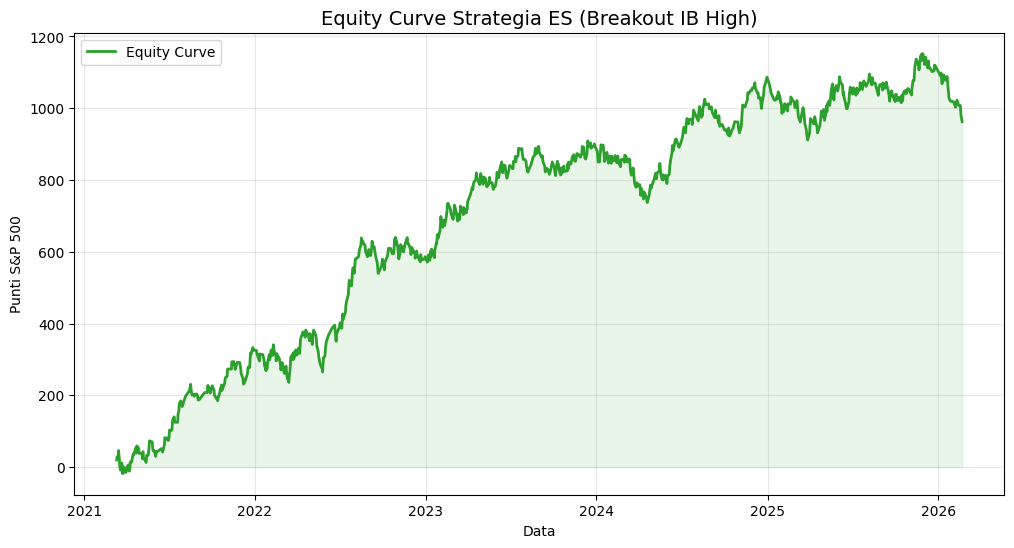

In [ ]:
import matplotlib.pyplot as plt

def plot_equity_curve(df_input):
    # Ripetiamo il backtest per avere i trade singoli cronologici
    all_trades_pnl = []
    timestamps = []
    
    for date, day_group in df_input.groupby(df_input.index.date):
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + TARGET_ES
                sl = entry_price - STOP_ES
                
                future = post_ib.loc[timestamp:]
                pnl = 0
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        pnl = TARGET_ES
                        break
                    elif r_f['Low'] <= sl:
                        pnl = -STOP_ES
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        pnl = r_f['Close'] - entry_price
                        break
                
                all_trades_pnl.append(pnl)
                timestamps.append(timestamp)
                breakout_occurred = True
                break

    # Creazione DataFrame per la curva
    equity_df = pd.DataFrame({'PnL': all_trades_pnl}, index=timestamps)
    equity_df['Cumulative_PnL'] = equity_df['PnL'].cumsum()
    
    # Calcolo Max Drawdown
    rolling_max = equity_df['Cumulative_PnL'].cummax()
    drawdown = equity_df['Cumulative_PnL'] - rolling_max
    max_drawdown = drawdown.min()

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(equity_df['Cumulative_PnL'], label='Equity Curve', color='#2ca02c', linewidth=2)
    plt.fill_between(equity_df.index, equity_df['Cumulative_PnL'], alpha=0.1, color='#2ca02c')
    
    plt.title('Equity Curve Strategia ES (Breakout IB High)', fontsize=14)
    plt.xlabel('Data')
    plt.ylabel('Punti S&P 500')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    print(f"--- METRICHE DELLA CURVA ---")
    print(f"Profitto Finale: {equity_df['Cumulative_PnL'].iloc[-1]:.2f} punti")
    print(f"Max Drawdown: {max_drawdown:.2f} punti")
    print(f"Numero totale di trade: {len(equity_df)}")
    plt.show()

# Esegui il grafico
plot_equity_curve(df)

In [ ]:
import pandas as pd
import numpy as np

# PARAMETRI STRATEGIA
TARGET_ES = 20
STOP_ES = 15

# --- 1. TEST AMPIEZZA INITIAL BALANCE (Q1 vs ALTRI) ---
print("--- 1. ANALISI AMPIEZZA MEDIA INITIAL BALANCE (IB) ---")

# Per misurare l'IB prendiamo un solo dato per ogni giorno
daily_data = df.groupby(df.index.date).first().copy()
daily_data['IB_Size'] = daily_data['IB_High'] - daily_data['IB_Low']
daily_data['Quarter'] = pd.to_datetime(daily_data.index).quarter

# Calcoliamo la media dell'ampiezza per trimestre (1=Q1, 2=Q2, 3=Q3, 4=Q4)
ib_stats = daily_data.groupby('Quarter')['IB_Size'].mean().round(2)

print("Distanza media tra Massimo e Minimo della prima ora (in Punti ES):")
for q, val in ib_stats.items():
    print(f" Trimestre Q{q}: {val} punti")

print("\n" + "="*50 + "\n")

# --- 2. AUTOPSIA DEL Q1 (Gen/Feb/Mar anno per anno) ---
print("--- 2. PERFORMANCE DETTAGLIATA (SOLO GENNAIO, FEBBRAIO, MARZO) ---")

# Filtriamo il dataframe originale tenendo solo i mesi 1, 2 e 3
df_q1 = df[df.index.month.isin([1, 2, 3])].copy()
df_q1['YearMonth'] = df_q1.index.to_period('M')

results_q1 = []

# Analizziamo mese per mese
for ym, month_group in df_q1.groupby('YearMonth'):
    m_trades = []
    
    for date, day_group in month_group.groupby(month_group.index.date):
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + TARGET_ES
                sl = entry_price - STOP_ES
                
                future = post_ib.loc[timestamp:]
                trade_result = None
                
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        trade_result = {'res': 'WIN', 'pnl': TARGET_ES}
                        break
                    elif r_f['Low'] <= sl:
                        trade_result = {'res': 'LOSS', 'pnl': -STOP_ES}
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        diff = r_f['Close'] - entry_price
                        trade_result = {'res': 'WIN' if diff > 0 else 'LOSS', 'pnl': diff}
                        break
                
                if trade_result:
                    m_trades.append(trade_result)
                    breakout_occurred = True
                    break
    
    # Calcolo metriche per il singolo mese
    if m_trades:
        t_count = len(m_trades)
        wins = sum(1 for x in m_trades if x['res'] == 'WIN')
        losses = sum(1 for x in m_trades if x['res'] == 'LOSS')
        pnl_m = sum(x['pnl'] for x in m_trades)
        wr = (wins / t_count) * 100
        
        results_q1.append({
            'Mese': str(ym),
            'Trades': t_count,
            'Wins': wins,
            'Losses': losses,
            'WinRate': f"{wr:.2f}%",
            'PnL_Punti': round(pnl_m, 2)
        })

report_q1 = pd.DataFrame(results_q1)
print(report_q1.to_string(index=False))

print("\n--- RIEPILOGO TOTALI Q1 ---")
print(f"PnL Totale accumulato solo nei Q1: {report_q1['PnL_Punti'].sum():.2f} punti")

--- 1. ANALISI AMPIEZZA MEDIA INITIAL BALANCE (IB) ---
Distanza media tra Massimo e Minimo della prima ora (in Punti ES):
 Trimestre Q1: 30.41 punti
 Trimestre Q2: 28.16 punti
 Trimestre Q3: 24.87 punti
 Trimestre Q4: 28.11 punti


--- 2. PERFORMANCE DETTAGLIATA (SOLO GENNAIO, FEBBRAIO, MARZO) ---
   Mese  Trades  Wins  Losses WinRate  PnL_Punti
2021-03      16     7       9  43.75%     -14.75
2022-01      13     4       9  30.77%     -11.75
2022-02      14     6       8  42.86%     -22.75
2022-03      17     9       8  52.94%      20.75
2023-01      16     9       7  56.25%      72.00
2023-02      13     7       6  53.85%      32.00
2023-03      18     9       9  50.00%      49.00
2024-01      17     6      11  35.29%     -34.00
2024-02      17     8       9  47.06%     -12.00
2024-03      15     5      10  33.33%     -66.75
2025-01      14     2      12  14.29%    -100.75
2025-02      13     6       7  46.15%      15.75
2025-03      14     4      10  28.57%     -70.00
2026-01      14

In [ ]:
import pandas as pd
import numpy as np

# PARAMETRI STRATEGIA
TARGET_ES = 20
STOP_ES = 15

# Diversi limiti di ampiezza dell'IB da testare (in punti)
# 999 = Nessun limite (il nostro test base)
ib_thresholds = [20, 24, 28, 32, 36, 999]

def backtest_ib_filter(df_input, max_ib_size):
    trades = []
    
    for date, day_group in df_input.groupby(df_input.index.date):
        # Calcolo ampiezza IB della giornata
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        
        # Se i dati IB mancano o l'ampiezza supera il limite, saltiamo la giornata
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        ib_size = ib_high - ib_low
        if ib_size > max_ib_size:
            continue
            
        # Logica di trading per le giornate valide
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + TARGET_ES
                sl = entry_price - STOP_ES
                
                future = post_ib.loc[timestamp:]
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        trades.append({'res': 1, 'pnl': TARGET_ES})
                        break
                    elif r_f['Low'] <= sl:
                        trades.append({'res': 0, 'pnl': -STOP_ES})
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        diff = r_f['Close'] - entry_price
                        trades.append({'res': 1 if diff > 0 else 0, 'pnl': diff})
                        break
                
                breakout_occurred = True
                break
                
    return trades

print("--- OTTIMIZZAZIONE FILTRO: AMPIEZZA INITIAL BALANCE ---")
print(f"{'Max IB Size':<12} | {'Trades':<8} | {'Win Rate':<10} | {'PnL Punti':<12} | {'Tagliati':<10}")
print("-" * 65)

# Per calcolare quanti trade abbiamo risparmiato, ci serve il totale base
base_trades = 0

for limit in ib_thresholds:
    res = backtest_ib_filter(df, limit)
    
    if len(res) == 0:
        continue
        
    t_count = len(res)
    wins = sum(1 for x in res if x['res'] == 1)
    pnl = sum(x['pnl'] for x in res)
    wr = (wins / t_count) * 100
    
    # Salviamo il numero di trade del test "Nessun limite" (999) per il confronto
    if limit == 999:
        base_trades = t_count
        label = "Nessun Lim"
        tagliati = 0
    else:
        label = f"<= {limit} pts"
        # Ipotizziamo quanti trade sono stati evitati rispetto alla base (se base è già calcolata, altrimenti è approssimato)
        # Lo calcoleremo esattamente leggendo la tabella
        tagliati = "?" 

    print(f"{label:<12} | {t_count:<8} | {wr:<9.2f}% | {pnl:<12.2f} | Da valutare")

print("-" * 65)
print("Nota: 'Tagliati' indica quanti trade potenzialmente pericolosi non abbiamo fatto.")

--- OTTIMIZZAZIONE FILTRO: AMPIEZZA INITIAL BALANCE ---
Max IB Size  | Trades   | Win Rate   | PnL Punti    | Tagliati  
-----------------------------------------------------------------
<= 20 pts    | 348      | 47.99    % | 403.75       | Da valutare
<= 24 pts    | 455      | 48.35    % | 645.25       | Da valutare
<= 28 pts    | 543      | 50.46    % | 1062.25      | Da valutare
<= 32 pts    | 614      | 49.84    % | 977.00       | Da valutare
<= 36 pts    | 659      | 49.17    % | 949.00       | Da valutare
Nessun Lim   | 851      | 47.83    % | 962.75       | Da valutare
-----------------------------------------------------------------
Nota: 'Tagliati' indica quanti trade potenzialmente pericolosi non abbiamo fatto.



🏆 REPORT FINALE STRATEGIA (IB <= 28) + SLIPPAGE 🏆
Operazioni totali: 543 (Risparmiati centinaia di trade!)
Win Rate Reale:    50.46% (274 Vinte | 269 Perse)
PnL Lordo:         1062.25 punti
Costi/Slippage:   -271.50 punti (0.50 a trade)
PnL NETTO FINALE:  790.75 punti
Max Drawdown:      -174.75 punti

--- DETTAGLIO TRIMESTRALE (NETTO) ---
         Trades  Wins  Losses  WinRate %  Net_PnL
Quarter                                          
2021Q1       15     7       8      46.67   -12.75
2021Q2       39    20      19      51.28    80.75
2021Q3       33    20      13      60.61   112.75
2021Q4       28    17      11      60.71   144.00
2022Q1       13     7       6      53.85    35.75
2022Q2        7     6       1      85.71    72.00
2022Q3       19    10       9      52.63    79.75
2022Q4       14     7       7      50.00    27.25
2023Q1       32    18      14      56.25   158.25
2023Q2       38    18      20      47.37    51.50
2023Q3       34    15      19      44.12    -0.75
2023Q4  

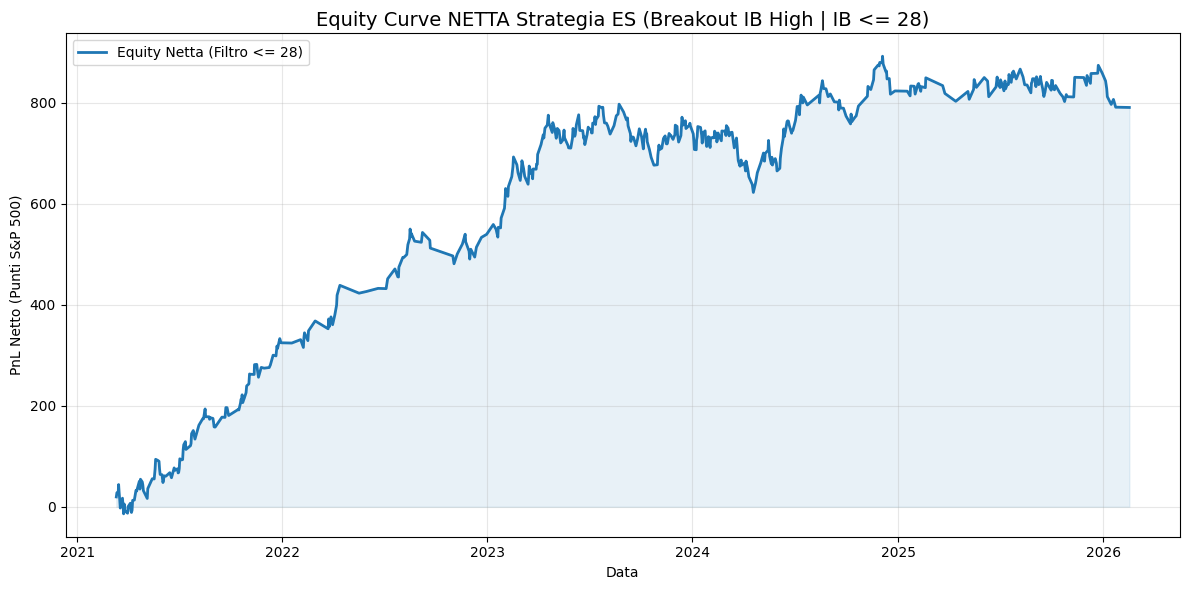

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETRI DEFINITIVI DELLA STRATEGIA ---
TARGET_ES = 20
STOP_ES = 15
MAX_IB_SIZE = 28        # Il nostro "Santo Graal"
COSTO_TRADE = 0.50      # Slippage + Commissioni in punti per singolo trade

def backtest_definitivo(df_input):
    trades = []
    
    # Raggruppiamo per giornata
    for date, day_group in df_input.groupby(df_input.index.date):
        
        # 1. FILTRO AMPIEZZA INITIAL BALANCE
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        ib_size = ib_high - ib_low
        
        # Se la prima ora è stata troppo violenta, stiamo fermi
        if ib_size > MAX_IB_SIZE:
            continue
            
        # 2. RICERCA DEL BREAKOUT (dopo le 10:30)
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + TARGET_ES
                sl = entry_price - STOP_ES
                
                future = post_ib.loc[timestamp:]
                
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        # Profitto - Costi
                        trades.append({'time': timestamp, 'res': 'WIN', 'pnl': TARGET_ES - COSTO_TRADE})
                        break
                    elif r_f['Low'] <= sl:
                        # Perdita - Costi
                        trades.append({'time': timestamp, 'res': 'LOSS', 'pnl': -STOP_ES - COSTO_TRADE})
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        # Uscita a fine giornata - Costi
                        diff = r_f['Close'] - entry_price
                        res_str = 'WIN' if diff > 0 else 'LOSS'
                        trades.append({'time': timestamp, 'res': res_str, 'pnl': diff - COSTO_TRADE})
                        break
                
                breakout_occurred = True
                break
                
    return trades

# --- ESECUZIONE E CALCOLI ---
trades_list = backtest_definitivo(df)
df_trades = pd.DataFrame(trades_list)
df_trades.set_index('time', inplace=True)

# Statistiche Globali
tot_trades = len(df_trades)
wins = len(df_trades[df_trades['res'] == 'WIN'])
losses = len(df_trades[df_trades['res'] == 'LOSS'])
win_rate = (wins / tot_trades) * 100 if tot_trades > 0 else 0
net_pnl = df_trades['pnl'].sum()
gross_pnl = net_pnl + (tot_trades * COSTO_TRADE)

# Calcolo Equity e Drawdown
df_trades['Cumulative_PnL'] = df_trades['pnl'].cumsum()
df_trades['Rolling_Max'] = df_trades['Cumulative_PnL'].cummax()
df_trades['Drawdown'] = df_trades['Cumulative_PnL'] - df_trades['Rolling_Max']
max_drawdown = df_trades['Drawdown'].min()

# Report Trimestrale
df_trades['Quarter'] = df_trades.index.to_period('Q')
report_q = df_trades.groupby('Quarter').agg(
    Trades=('pnl', 'count'),
    Wins=('res', lambda x: (x == 'WIN').sum()),
    Losses=('res', lambda x: (x == 'LOSS').sum()),
    Net_PnL=('pnl', 'sum')
)
report_q['WinRate %'] = (report_q['Wins'] / report_q['Trades'] * 100).round(2)
report_q['Net_PnL'] = report_q['Net_PnL'].round(2)

# --- STAMPE ---
print("\n" + "="*55)
print("🏆 REPORT FINALE STRATEGIA (IB <= 28) + SLIPPAGE 🏆")
print("="*55)
print(f"Operazioni totali: {tot_trades} (Risparmiati centinaia di trade!)")
print(f"Win Rate Reale:    {win_rate:.2f}% ({wins} Vinte | {losses} Perse)")
print(f"PnL Lordo:         {gross_pnl:.2f} punti")
print(f"Costi/Slippage:   -{tot_trades * COSTO_TRADE:.2f} punti (0.50 a trade)")
print(f"PnL NETTO FINALE:  {net_pnl:.2f} punti")
print(f"Max Drawdown:      {max_drawdown:.2f} punti")
print("="*55)

print("\n--- DETTAGLIO TRIMESTRALE (NETTO) ---")
print(report_q[['Trades', 'Wins', 'Losses', 'WinRate %', 'Net_PnL']].to_string())

# --- PLOT EQUITY CURVE ---
plt.figure(figsize=(12, 6))
plt.plot(df_trades.index, df_trades['Cumulative_PnL'], label='Equity Netta (Filtro <= 28)', color='#1f77b4', linewidth=2)
plt.fill_between(df_trades.index, df_trades['Cumulative_PnL'], alpha=0.1, color='#1f77b4')

plt.title('Equity Curve NETTA Strategia ES (Breakout IB High | IB <= 28)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('PnL Netto (Punti S&P 500)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("Calcolo dell'ATR (Volatilità Dinamica) in corso...")

# 1. CALCOLO DELL'ATR GIORNALIERO SULLO STORICO
# Raggruppiamo i dati a 1 minuto in candele giornaliere
daily_df = df.groupby(df.index.date).agg({
    'Open': 'first', 
    'High': 'max', 
    'Low': 'min', 
    'Close': 'last'
})

daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])

# Il True Range è il valore massimo tra le tre escursioni
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)

# Calcoliamo la media mobile a 14 giorni (ATR) e la shiftiamo di 1 
# per usare solo l'ATR del giorno prima (non sbirciamo nel futuro)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)

# Creiamo un dizionario per associare velocemente l'ATR a ogni data
atr_dict = daily_df['ATR_14'].to_dict()

# --- PARAMETRI DINAMICI ---
MOLT_TARGET = 0.40  # Target = 40% dell'escursione media giornaliera
MOLT_STOP = 0.30    # Stop = 30% dell'escursione media giornaliera
MAX_IB_SIZE = 28    # Manteniamo il nostro "Santo Graal"
COSTO_TRADE = 0.50

def backtest_adattivo(df_input):
    trades = []
    
    for date, day_group in df_input.groupby(df_input.index.date):
        
        # Recuperiamo l'ATR di oggi
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr):
            continue
            
        # Filtro Ampiezza IB
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        ib_size = ib_high - ib_low
        if ib_size > MAX_IB_SIZE:
            continue
            
        # Calcolo Livelli Dinamici
        target_dinamico = daily_atr * MOLT_TARGET
        stop_dinamico = daily_atr * MOLT_STOP
        
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + target_dinamico
                sl = entry_price - stop_dinamico
                
                future = post_ib.loc[timestamp:]
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        trades.append({'year': date.year, 'res': 'WIN', 'pnl': target_dinamico - COSTO_TRADE})
                        break
                    elif r_f['Low'] <= sl:
                        trades.append({'year': date.year, 'res': 'LOSS', 'pnl': -stop_dinamico - COSTO_TRADE})
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        diff = r_f['Close'] - entry_price
                        res_str = 'WIN' if diff > 0 else 'LOSS'
                        trades.append({'year': date.year, 'res': res_str, 'pnl': diff - COSTO_TRADE})
                        break
                
                breakout_occurred = True
                break
                
    return trades

# --- ESECUZIONE E REPORT ANNUALE ---
trades_dinamici = backtest_adattivo(df)
df_dinamico = pd.DataFrame(trades_dinamici)

print("\n" + "="*50)
print("🤖 RISULTATI STRATEGIA ADATTIVA (ATR) 🤖")
print("="*50)

report_annuale = df_dinamico.groupby('year').agg(
    Trades=('pnl', 'count'),
    Wins=('res', lambda x: (x == 'WIN').sum()),
    Losses=('res', lambda x: (x == 'LOSS').sum()),
    Net_PnL=('pnl', 'sum')
)
report_annuale['WinRate %'] = (report_annuale['Wins'] / report_annuale['Trades'] * 100).round(2)
report_annuale['Net_PnL'] = report_annuale['Net_PnL'].round(2)

print(report_annuale[['Trades', 'Wins', 'Losses', 'WinRate %', 'Net_PnL']].to_string())

totale_netto = report_annuale['Net_PnL'].sum()
print("-" * 50)
print(f"PnL NETTO TOTALE (Dinamico): {totale_netto:.2f} punti")

Calcolo dell'ATR (Volatilità Dinamica) in corso...

🤖 RISULTATI STRATEGIA ADATTIVA (ATR) 🤖
      Trades  Wins  Losses  WinRate %  Net_PnL
year                                          
2021     103    59      44      57.28   326.88
2022      53    29      24      54.72    54.03
2023     146    73      73      50.00   234.99
2024     137    71      66      51.82   173.75
2025      84    41      43      48.81   105.86
2026       8     2       6      25.00   -73.92
--------------------------------------------------
PnL NETTO TOTALE (Dinamico): 821.59 punti


In [ ]:
import pandas as pd
import numpy as np

print("Elaborazione dati trimestrali (Strategia ATR + IB <= 28)...")

# --- ASSICURIAMOCI DI AVERE I DATI ATR ---
daily_df = df.groupby(df.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

# --- PARAMETRI ---
MOLT_TARGET = 0.40
MOLT_STOP = 0.30
MAX_IB_SIZE = 28
COSTO_TRADE = 0.50

def backtest_adattivo_trimestrale(df_input):
    trades = []
    
    for date, day_group in df_input.groupby(df_input.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr):
            continue
            
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        
        if pd.isna(ib_high) or pd.isna(ib_low) or (ib_high - ib_low) > MAX_IB_SIZE:
            continue
            
        target_dinamico = daily_atr * MOLT_TARGET
        stop_dinamico = daily_atr * MOLT_STOP
        
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        breakout_occurred = False
        
        for timestamp, row in post_ib.iterrows():
            if row['Close'] > row['IB_High'] and not breakout_occurred:
                entry_price = row['Close']
                tp = entry_price + target_dinamico
                sl = entry_price - stop_dinamico
                
                future = post_ib.loc[timestamp:]
                for t_f, r_f in future.iterrows():
                    if r_f['High'] >= tp:
                        trades.append({'time': timestamp, 'res': 'WIN', 'pnl': target_dinamico - COSTO_TRADE})
                        break
                    elif r_f['Low'] <= sl:
                        trades.append({'time': timestamp, 'res': 'LOSS', 'pnl': -stop_dinamico - COSTO_TRADE})
                        break
                    elif t_f.time() >= pd.to_datetime('16:00').time():
                        diff = r_f['Close'] - entry_price
                        res_str = 'WIN' if diff > 0 else 'LOSS'
                        trades.append({'time': timestamp, 'res': res_str, 'pnl': diff - COSTO_TRADE})
                        break
                
                breakout_occurred = True
                break
                
    return trades

# --- ESECUZIONE ---
trades_dinamici = backtest_adattivo_trimestrale(df)
df_dinamico = pd.DataFrame(trades_dinamici)
df_dinamico.set_index('time', inplace=True)
df_dinamico['Quarter'] = df_dinamico.index.to_period('Q')

print("\n" + "="*55)
print("📊 DETTAGLIO TRIMESTRALE: STRATEGIA ADATTIVA (ATR) 📊")
print("="*55)

report_q_atr = df_dinamico.groupby('Quarter').agg(
    Trades=('pnl', 'count'),
    Wins=('res', lambda x: (x == 'WIN').sum()),
    Losses=('res', lambda x: (x == 'LOSS').sum()),
    Net_PnL=('pnl', 'sum')
)
report_q_atr['WinRate %'] = (report_q_atr['Wins'] / report_q_atr['Trades'] * 100).round(2)
report_q_atr['Net_PnL'] = report_q_atr['Net_PnL'].round(2)

print(report_q_atr[['Trades', 'Wins', 'Losses', 'WinRate %', 'Net_PnL']].to_string())

Elaborazione dati trimestrali (Strategia ATR + IB <= 28)...

📊 DETTAGLIO TRIMESTRALE: STRATEGIA ADATTIVA (ATR) 📊
         Trades  Wins  Losses  WinRate %  Net_PnL
Quarter                                          
2021Q1        3     2       1      66.67    -2.75
2021Q2       39    20      19      51.28    67.35
2021Q3       33    20      13      60.61    95.61
2021Q4       28    17      11      60.71   166.66
2022Q1       13     7       6      53.85   -51.38
2022Q2        7     6       1      85.71    69.69
2022Q3       19    10       9      52.63    89.49
2022Q4       14     6       8      42.86   -53.76
2023Q1       32    17      15      53.12   119.44
2023Q2       38    18      20      47.37    49.64
2023Q3       34    16      18      47.06    38.18
2023Q4       42    22      20      52.38    27.72
2024Q1       45    21      24      46.67    -8.03
2024Q2       39    21      18      53.85   103.61
2024Q3       28    14      14      50.00    44.67
2024Q4       25    15      10      60

In [ ]:
import pandas as pd
import numpy as np

print("Analisi Strutturale: Anatomia dei Breakout dell'Initial Balance...")

# Parametri dello studio
MICRO_TARGET_1 = 5.0  # Rientro di 5 punti dentro l'IB
MICRO_TARGET_2 = 10.0 # Rientro di 10 punti dentro l'IB

stats = {
    'Giornate_Totali': 0,
    'Breakout_High_Totali': 0,
    'Escursione_Media_High': [],
    'Rientro_5pt_High': 0,
    'Rientro_10pt_High': 0,
    
    'Breakout_Low_Totali': 0,
    'Escursione_Media_Low': [],
    'Rientro_5pt_Low': 0,
    'Rientro_10pt_Low': 0
}

# Analisi giorno per giorno
for date, day_group in df.groupby(df.index.date):
    stats['Giornate_Totali'] += 1
    
    ib_high = day_group['IB_High'].iloc[0]
    ib_low = day_group['IB_Low'].iloc[0]
    
    if pd.isna(ib_high) or pd.isna(ib_low):
        continue
        
    post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
    if post_ib.empty:
        continue

    # --- ANALISI LATO HIGH (Massimi) ---
    max_high_post_ib = post_ib['High'].max()
    
    if max_high_post_ib > ib_high:
        stats['Breakout_High_Totali'] += 1
        
        # Di quanto ha sforato il prezzo?
        escursione = max_high_post_ib - ib_high
        stats['Escursione_Media_High'].append(escursione)
        
        # Troviamo il momento esatto in cui fa il nuovo massimo
        idx_max = post_ib['High'].idxmax()
        future_after_max = post_ib.loc[idx_max:]
        
        # Controlliamo se da quel massimo il prezzo rientra nell'IB
        min_after_max = future_after_max['Low'].min()
        
        if min_after_max <= (ib_high - MICRO_TARGET_1):
            stats['Rientro_5pt_High'] += 1
        if min_after_max <= (ib_high - MICRO_TARGET_2):
            stats['Rientro_10pt_High'] += 1

    # --- ANALISI LATO LOW (Minimi) ---
    min_low_post_ib = post_ib['Low'].min()
    
    if min_low_post_ib < ib_low:
        stats['Breakout_Low_Totali'] += 1
        
        # Di quanto ha sforato al ribasso?
        escursione_low = ib_low - min_low_post_ib
        stats['Escursione_Media_Low'].append(escursione_low)
        
        # Troviamo il momento del minimo
        idx_min = post_ib['Low'].idxmin()
        future_after_min = post_ib.loc[idx_min:]
        
        # Controlliamo se rimbalza dentro l'IB
        max_after_min = future_after_min['High'].max()
        
        if max_after_min >= (ib_low + MICRO_TARGET_1):
            stats['Rientro_5pt_Low'] += 1
        if max_after_min >= (ib_low + MICRO_TARGET_2):
            stats['Rientro_10pt_Low'] += 1

# --- CALCOLO PERCENTUALI E STAMPA ---
avg_exc_high = np.mean(stats['Escursione_Media_High']) if stats['Escursione_Media_High'] else 0
avg_exc_low = np.mean(stats['Escursione_Media_Low']) if stats['Escursione_Media_Low'] else 0

prob_5pt_high = (stats['Rientro_5pt_High'] / stats['Breakout_High_Totali']) * 100 if stats['Breakout_High_Totali'] > 0 else 0
prob_10pt_high = (stats['Rientro_10pt_High'] / stats['Breakout_High_Totali']) * 100 if stats['Breakout_High_Totali'] > 0 else 0

prob_5pt_low = (stats['Rientro_5pt_Low'] / stats['Breakout_Low_Totali']) * 100 if stats['Breakout_Low_Totali'] > 0 else 0
prob_10pt_low = (stats['Rientro_10pt_Low'] / stats['Breakout_Low_Totali']) * 100 if stats['Breakout_Low_Totali'] > 0 else 0

print("\n" + "="*50)
print("🔍 RADIOGRAFIA DEI FALSI BREAKOUT (LIQUIDITY SWEEPS) 🔍")
print("="*50)
print(f"Giornate analizzate: {stats['Giornate_Totali']}")
print("\n--- LATO RIALZISTA (Rottura IB High) ---")
print(f"Volte in cui l'IB High è stato rotto: {stats['Breakout_High_Totali']}")
print(f"Escursione media fuori dall'IB: {avg_exc_high:.2f} punti")
print(f"Probabilità che il prezzo rientri di 5 punti:  {prob_5pt_high:.2f}%")
print(f"Probabilità che il prezzo rientri di 10 punti: {prob_10pt_high:.2f}%")

print("\n--- LATO RIBASSISTA (Rottura IB Low) ---")
print(f"Volte in cui l'IB Low è stato rotto: {stats['Breakout_Low_Totali']}")
print(f"Escursione media fuori dall'IB: {avg_exc_low:.2f} punti")
print(f"Probabilità che il prezzo rimbalzi su di 5 punti:  {prob_5pt_low:.2f}%")
print(f"Probabilità che il prezzo rimbalzi su di 10 punti: {prob_10pt_low:.2f}%")
print("="*50)

Analisi Strutturale: Anatomia dei Breakout dell'Initial Balance...

🔍 RADIOGRAFIA DEI FALSI BREAKOUT (LIQUIDITY SWEEPS) 🔍
Giornate analizzate: 1301

--- LATO RIALZISTA (Rottura IB High) ---
Volte in cui l'IB High è stato rotto: 882
Escursione media fuori dall'IB: 21.53 punti
Probabilità che il prezzo rientri di 5 punti:  47.51%
Probabilità che il prezzo rientri di 10 punti: 40.36%

--- LATO RIBASSISTA (Rottura IB Low) ---
Volte in cui l'IB Low è stato rotto: 826
Escursione media fuori dall'IB: 26.29 punti
Probabilità che il prezzo rimbalzi su di 5 punti:  57.51%
Probabilità che il prezzo rimbalzi su di 10 punti: 49.76%


In [ ]:
import pandas as pd
import numpy as np

print("Analisi Strutturale: Evoluzione dei Liquidity Sweeps per Semestre...")

# Creiamo le colonne per Anno e Semestre (H1/H2)
df_temp = df.copy()
df_temp['Year'] = df_temp.index.year
df_temp['Semester'] = np.where(df_temp.index.month <= 6, 'H1', 'H2')
df_temp['Period'] = df_temp['Year'].astype(str) + "-" + df_temp['Semester']

results_sem = []

for period, period_group in df_temp.groupby('Period'):
    stats = {
        'BO_High': 0, 'Rientro_5pt_H': 0, 'Rientro_10pt_H': 0,
        'BO_Low': 0, 'Rientro_5pt_L': 0, 'Rientro_10pt_L': 0
    }
    
    for date, day_group in period_group.groupby(period_group.index.date):
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        if post_ib.empty:
            continue

        # --- LATO HIGH ---
        max_high = post_ib['High'].max()
        if max_high > ib_high:
            stats['BO_High'] += 1
            idx_max = post_ib['High'].idxmax()
            future_h = post_ib.loc[idx_max:]
            if future_h['Low'].min() <= (ib_high - 5.0):
                stats['Rientro_5pt_H'] += 1
            if future_h['Low'].min() <= (ib_high - 10.0):
                stats['Rientro_10pt_H'] += 1

        # --- LATO LOW ---
        min_low = post_ib['Low'].min()
        if min_low < ib_low:
            stats['BO_Low'] += 1
            idx_min = post_ib['Low'].idxmin()
            future_l = post_ib.loc[idx_min:]
            if future_l['High'].max() >= (ib_low + 5.0):
                stats['Rientro_5pt_L'] += 1
            if future_l['High'].max() >= (ib_low + 10.0):
                stats['Rientro_10pt_L'] += 1
                
    # Calcolo probabilità
    prob_5h = (stats['Rientro_5pt_H'] / stats['BO_High'] * 100) if stats['BO_High'] > 0 else 0
    prob_10h = (stats['Rientro_10pt_H'] / stats['BO_High'] * 100) if stats['BO_High'] > 0 else 0
    
    prob_5l = (stats['Rientro_5pt_L'] / stats['BO_Low'] * 100) if stats['BO_Low'] > 0 else 0
    prob_10l = (stats['Rientro_10pt_L'] / stats['BO_Low'] * 100) if stats['BO_Low'] > 0 else 0
    
    results_sem.append({
        'Semestre': period,
        'BO High': stats['BO_High'],
        'Rientro High (5pt)': f"{prob_5h:.1f}%",
        'Rientro High (10pt)': f"{prob_10h:.1f}%",
        'BO Low': stats['BO_Low'],
        'Rientro Low (5pt)': f"{prob_5l:.1f}%",
        'Rientro Low (10pt)': f"{prob_10l:.1f}%"
    })

# Stampa bella della tabella
report_df = pd.DataFrame(results_sem)
print("\n" + "="*80)
print(f"{'Semestre':<10} | {'BO High':<8} | {'High Fallisce 5pt':<18} | {'High Fallisce 10pt':<18} || {'BO Low':<8} | {'Low Fallisce 5pt':<18} | {'Low Fallisce 10pt':<18}")
print("-" * 115)
for _, row in report_df.iterrows():
    print(f"{row['Semestre']:<10} | {row['BO High']:<8} | {row['Rientro High (5pt)']:<18} | {row['Rientro High (10pt)']:<18} || {row['BO Low']:<8} | {row['Rientro Low (5pt)']:<18} | {row['Rientro Low (10pt)']:<18}")
print("="*80)

Analisi Strutturale: Evoluzione dei Liquidity Sweeps per Semestre...

Semestre   | BO High  | High Fallisce 5pt  | High Fallisce 10pt || BO Low   | Low Fallisce 5pt   | Low Fallisce 10pt 
-------------------------------------------------------------------------------------------------------------------
2021-H1    | 62       | 38.7%              | 29.0%              || 53       | 60.4%              | 50.9%             
2021-H2    | 82       | 39.0%              | 30.5%              || 76       | 55.3%              | 43.4%             
2022-H1    | 81       | 55.6%              | 50.6%              || 88       | 52.3%              | 48.9%             
2022-H2    | 85       | 47.1%              | 41.2%              || 78       | 55.1%              | 52.6%             
2023-H1    | 93       | 52.7%              | 44.1%              || 82       | 61.0%              | 51.2%             
2023-H2    | 90       | 47.8%              | 33.3%              || 85       | 49.4%              | 42.4%  

In [ ]:
import pandas as pd
import numpy as np

print("Avvio Grid Search: Ottimizzazione Trappola di Liquidità (1-Min Trigger)...")

# --- 1. PREPARAZIONE ATR ---
daily_df = df.groupby(df.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

# --- 2. PARAMETRI DA TESTARE ---
ib_limits = [24, 28, 32, 999]           # 999 = Nessun limite
atr_multipliers = [0.08, 0.12, 0.16, 0.20] 
COSTO_TRADE = 0.50

def run_sweep_backtest(df_input, max_ib, atr_mult):
    trades = []
    
    for date, day_group in df_input.groupby(df_input.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr):
            continue
            
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        ib_size = ib_high - ib_low
        if ib_size > max_ib:
            continue
            
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        
        # Stato della giornata
        mode = 'wait'
        sweep_extreme = None
        
        for timestamp, row in post_ib.iterrows():
            current_close = row['Close']
            current_high = row['High']
            current_low = row['Low']
            
            # --- FASE 1: CERCHIAMO LA ROTTURA (L'ESCA) ---
            if mode == 'wait':
                if current_high > ib_high:
                    mode = 'sweeping_high'
                    sweep_extreme = current_high
                elif current_low < ib_low:
                    mode = 'sweeping_low'
                    sweep_extreme = current_low
                    
            # --- FASE 2: GESTIONE DEL FALSO BREAKOUT RIALZISTA ---
            elif mode == 'sweeping_high':
                # Aggiorniamo il massimo della finta se sale ancora
                if current_high > sweep_extreme:
                    sweep_extreme = current_high
                    
                # TRIGGER: La candela a 1 minuto CHIUDE sotto l'IB High
                if current_close < ib_high:
                    entry = current_close
                    stop_loss = sweep_extreme + 1.0 # Stop 1 punto sopra il massimo della finta
                    target = entry - (daily_atr * atr_mult) # Target Dinamico Short
                    
                    # Cerca l'esito nelle candele successive
                    future = post_ib.loc[timestamp:]
                    for t_f, r_f in future.iterrows():
                        if r_f['Low'] <= target:
                            trades.append(target - entry - COSTO_TRADE) # WIN (Short: entry > target)
                            break
                        elif r_f['High'] >= stop_loss:
                            trades.append(stop_loss - entry - COSTO_TRADE) # LOSS
                            break
                        elif t_f.time() >= pd.to_datetime('16:00').time():
                            trades.append(r_f['Close'] - entry - COSTO_TRADE) # End of Day
                            break
                    break # Fine della giornata operativa
                    
            # --- FASE 3: GESTIONE DEL FALSO BREAKOUT RIBASSISTA ---
            elif mode == 'sweeping_low':
                if current_low < sweep_extreme:
                    sweep_extreme = current_low
                    
                # TRIGGER: La candela a 1 minuto CHIUDE sopra l'IB Low
                if current_close > ib_low:
                    entry = current_close
                    stop_loss = sweep_extreme - 1.0 # Stop 1 punto sotto il minimo
                    target = entry + (daily_atr * atr_mult) # Target Dinamico Long
                    
                    future = post_ib.loc[timestamp:]
                    for t_f, r_f in future.iterrows():
                        if r_f['High'] >= target:
                            trades.append(target - entry - COSTO_TRADE) # WIN
                            break
                        elif r_f['Low'] <= stop_loss:
                            trades.append(stop_loss - entry - COSTO_TRADE) # LOSS
                            break
                        elif t_f.time() >= pd.to_datetime('16:00').time():
                            trades.append(r_f['Close'] - entry - COSTO_TRADE) # End of Day
                            break
                    break # Fine della giornata operativa

    return trades

# --- 3. ESECUZIONE MATRICE E REPORT ---
results = []
for ib in ib_limits:
    for mult in atr_multipliers:
        t_list = run_sweep_backtest(df, ib, mult)
        if len(t_list) == 0:
            continue
            
        wins = sum(1 for pnl in t_list if pnl > 0)
        losses = len(t_list) - wins
        wr = (wins / len(t_list)) * 100
        net_pnl = sum(t_list)
        avg_trade = net_pnl / len(t_list)
        
        results.append({
            'Max IB': "No Limit" if ib == 999 else f"<= {ib}",
            'ATR Target': f"{int(mult*100)}%",
            'Trades': len(t_list),
            'Win Rate': f"{wr:.2f}%",
            'Net PnL': round(net_pnl, 2),
            'Avg/Trade': round(avg_trade, 2)
        })

df_results = pd.DataFrame(results)

# Ordiniamo per Win Rate decrescente per trovare subito i setup più sicuri
df_results = df_results.sort_values(by='Win Rate', ascending=False).reset_index(drop=True)

print("\n" + "="*75)
print("🏆 MATRICE DEI RISULTATI: STRATEGIA LIQUIDITY SWEEP (1-Min) 🏆")
print("="*75)
print(df_results.to_string(index=False))
print("="*75)
print("Nota: Il PnL Netto include già il costo fisso di 0.50 punti a trade.")

Avvio Grid Search: Ottimizzazione Trappola di Liquidità (1-Min Trigger)...

🏆 MATRICE DEI RISULTATI: STRATEGIA LIQUIDITY SWEEP (1-Min) 🏆
  Max IB ATR Target  Trades Win Rate  Net PnL  Avg/Trade
No Limit        16%    1188   50.42%  -684.44      -0.58
   <= 32        16%     815   49.69%  -545.67      -0.67
No Limit        20%    1188   49.66%  -871.91      -0.73
   <= 32         8%     817   49.57%  -484.42      -0.59
No Limit        12%    1189   49.45%  -812.83      -0.68
   <= 28         8%     706   49.43%  -371.27      -0.53
   <= 28        16%     704   49.29%  -447.44      -0.64
   <= 32        12%     816   49.14%  -586.35      -0.72
No Limit         8%    1190   49.08%  -872.41      -0.73
   <= 28        20%     704   49.01%  -524.43      -0.74
   <= 32        20%     815   48.83%  -716.69      -0.88
   <= 28        12%     705   48.79%  -472.02      -0.67
   <= 24         8%     588   47.79%  -333.78      -0.57
   <= 24        16%     586   47.78%  -415.06      -0.71
   <= 24

In [ ]:
import pandas as pd
import numpy as np

print("Mappatura Temporale: Orario di formazione del Massimo e Minimo Giornaliero...")

# Filtriamo solo la sessione RTH (Regular Trading Hours: 09:30 - 16:00)
# Questo evita che spike notturni sballino l'analisi della sessione cash
df_rth = df.between_time('09:30', '16:00').copy()

# Aggiungiamo colonne per Semestre
df_rth['Year'] = df_rth.index.year
df_rth['Semester'] = np.where(df_rth.index.month <= 6, 'H1', 'H2')
df_rth['Period'] = df_rth['Year'].astype(str) + "-" + df_rth['Semester']

# Funzione per categorizzare l'orario
def categorize_time(t):
    if t >= pd.to_datetime('09:30').time() and t <= pd.to_datetime('10:30').time():
        return '09:30 - 10:30 (IB)'
    elif t > pd.to_datetime('10:30').time() and t <= pd.to_datetime('12:00').time():
        return '10:30 - 12:00 (Mattina)'
    elif t > pd.to_datetime('12:00').time() and t <= pd.to_datetime('14:00').time():
        return '12:00 - 14:00 (Pranzo)'
    else:
        return '14:00 - 16:00 (Pomeriggio)'

results = []

for period, period_group in df_rth.groupby('Period'):
    total_days = 0
    high_times = {'09:30 - 10:30 (IB)': 0, '10:30 - 12:00 (Mattina)': 0, '12:00 - 14:00 (Pranzo)': 0, '14:00 - 16:00 (Pomeriggio)': 0}
    low_times = {'09:30 - 10:30 (IB)': 0, '10:30 - 12:00 (Mattina)': 0, '12:00 - 14:00 (Pranzo)': 0, '14:00 - 16:00 (Pomeriggio)': 0}
    
    for date, day_group in period_group.groupby(period_group.index.date):
        if day_group.empty: continue
        total_days += 1
        
        # Troviamo l'orario esatto del Massimo e del Minimo
        idx_high = day_group['High'].idxmax()
        idx_low = day_group['Low'].idxmin()
        
        time_high = idx_high.time()
        time_low = idx_low.time()
        
        cat_high = categorize_time(time_high)
        cat_low = categorize_time(time_low)
        
        high_times[cat_high] += 1
        low_times[cat_low] += 1
        
    # Calcolo percentuali
    res_row = {'Semestre': period, 'Giornate': total_days}
    for cat in high_times.keys():
        res_row[f'High {cat[:5]}'] = f"{(high_times[cat] / total_days * 100):.1f}%"
        res_row[f'Low {cat[:5]}'] = f"{(low_times[cat] / total_days * 100):.1f}%"
        
    results.append(res_row)

df_report = pd.DataFrame(results)

print("\n" + "="*95)
print("🕒 DISTRIBUZIONE ORARIA: QUANDO SI FORMANO IL MASSIMO E IL MINIMO DELLA GIORNATA? 🕒")
print("="*95)

# Stampa Formattata per il Massimo
print("\n--- 🔴 FORMAZIONE DEL MASSIMO (HIGH) ---")
print(df_report[['Semestre', 'Giornate', 'High 09:30', 'High 10:30', 'High 12:00', 'High 14:00']].to_string(index=False))

# Stampa Formattata per il Minimo
print("\n--- 🟢 FORMAZIONE DEL MINIMO (LOW) ---")
print(df_report[['Semestre', 'Giornate', 'Low 09:30', 'Low 10:30', 'Low 12:00', 'Low 14:00']].to_string(index=False))
print("="*95)

Mappatura Temporale: Orario di formazione del Massimo e Minimo Giornaliero...

🕒 DISTRIBUZIONE ORARIA: QUANDO SI FORMANO IL MASSIMO E IL MINIMO DELLA GIORNATA? 🕒

--- 🔴 FORMAZIONE DEL MASSIMO (HIGH) ---
Semestre  Giornate High 09:30 High 10:30 High 12:00 High 14:00
 2021-H1        83      32.5%      13.3%      10.8%      43.4%
 2021-H2       131      41.2%       9.9%       9.2%      39.7%
 2022-H1       129      38.0%      11.6%       7.8%      42.6%
 2022-H2       134      40.3%      14.9%       9.7%      35.1%
 2023-H1       129      31.0%      12.4%      12.4%      44.2%
 2023-H2       130      34.6%      12.3%      15.4%      37.7%
 2024-H1       129      28.7%      15.5%      14.0%      41.9%
 2024-H2       133      36.8%      12.8%      19.5%      30.8%
 2025-H1       133      35.3%      12.8%      12.8%      39.1%
 2025-H2       132      37.9%      13.6%      13.6%      34.8%
 2026-H1        38      39.5%      15.8%      26.3%      18.4%

--- 🟢 FORMAZIONE DEL MINIMO (LOW) ---
Se

In [ ]:
import pandas as pd
import numpy as np

print("Analisi Gravitazionale: Dove si ferma la Mean Reversion? (VWAP & Midpoint)...")

# --- 1. PREPARAZIONE DATI E SEMESTRI ---
df_temp = df.copy()
df_temp['Year'] = df_temp.index.year
df_temp['Semester'] = np.where(df_temp.index.month <= 6, 'H1', 'H2')
df_temp['Period'] = df_temp['Year'].astype(str) + "-" + df_temp['Semester']

has_volume = 'Volume' in df_temp.columns

results = []

for period, p_group in df_temp.groupby('Period'):
    stats = {
        'Sweeps_H': 0, 'To_Mid_H': 0, 'To_VWAP_H': 0, 'To_Opposite_H': 0,
        'Sweeps_L': 0, 'To_Mid_L': 0, 'To_VWAP_L': 0, 'To_Opposite_L': 0
    }
    
    for date, day_group in p_group.groupby(p_group.index.date):
        ib_high = day_group['IB_High'].iloc[0]
        ib_low = day_group['IB_Low'].iloc[0]
        
        if pd.isna(ib_high) or pd.isna(ib_low):
            continue
            
        ib_mid = (ib_high + ib_low) / 2
        
        # Calcolo VWAP Giornaliero (se abbiamo i volumi)
        if has_volume:
            tipical_price = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
            day_group['VWAP'] = (tipical_price * day_group['Volume']).cumsum() / day_group['Volume'].cumsum()
            
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        if post_ib.empty:
            continue
            
        # Variabili di stato per prendere solo la PRIMA finta della giornata per lato
        triggered_h = False
        triggered_l = False
        mode_h = 'wait'
        mode_l = 'wait'
        
        for ts, row in post_ib.iterrows():
            # --- LATO HIGH (Falso Breakout Rialzista) ---
            if not triggered_h:
                if mode_h == 'wait' and row['High'] > ib_high:
                    mode_h = 'sweeping'
                elif mode_h == 'sweeping' and row['Close'] < ib_high:
                    stats['Sweeps_H'] += 1
                    triggered_h = True
                    future = post_ib.loc[ts:]
                    
                    if future['Low'].min() <= ib_mid: stats['To_Mid_H'] += 1
                    if future['Low'].min() <= ib_low: stats['To_Opposite_H'] += 1
                    
                    if has_volume and (future['Low'] <= future['VWAP']).any():
                        stats['To_VWAP_H'] += 1

            # --- LATO LOW (Falso Breakout Ribassista) ---
            if not triggered_l:
                if mode_l == 'wait' and row['Low'] < ib_low:
                    mode_l = 'sweeping'
                elif mode_l == 'sweeping' and row['Close'] > ib_low:
                    stats['Sweeps_L'] += 1
                    triggered_l = True
                    future = post_ib.loc[ts:]
                    
                    if future['High'].max() >= ib_mid: stats['To_Mid_L'] += 1
                    if future['High'].max() >= ib_high: stats['To_Opposite_L'] += 1
                    
                    if has_volume and (future['High'] >= future['VWAP']).any():
                        stats['To_VWAP_L'] += 1

            if triggered_h and triggered_l:
                break # Entrambi i lati testati, passiamo al giorno dopo
                
    # --- CALCOLO PERCENTUALI ---
    def calc_pct(part, total):
        return f"{(part / total * 100):.1f}%" if total > 0 else "0.0%"
        
    results.append({
        'Semestre': period,
        'Falsi BO High': stats['Sweeps_H'],
        'H -> Midpoint': calc_pct(stats['To_Mid_H'], stats['Sweeps_H']),
        'H -> VWAP': calc_pct(stats['To_VWAP_H'], stats['Sweeps_H']) if has_volume else "N/A",
        'H -> IB Low': calc_pct(stats['To_Opposite_H'], stats['Sweeps_H']),
        
        'Falsi BO Low': stats['Sweeps_L'],
        'L -> Midpoint': calc_pct(stats['To_Mid_L'], stats['Sweeps_L']),
        'L -> VWAP': calc_pct(stats['To_VWAP_L'], stats['Sweeps_L']) if has_volume else "N/A",
        'L -> IB High': calc_pct(stats['To_Opposite_L'], stats['Sweeps_L'])
    })

df_report = pd.DataFrame(results)

print("\n" + "="*110)
print(f"{'Semestre':<10} | {'BO High':<8} | {'Tocca Midpoint':<15} | {'Tocca VWAP':<12} | {'Sprofonda IB Low':<18} || {'BO Low':<8} | {'Tocca Midpoint':<15} | {'Tocca VWAP':<12} | {'Vola a IB High':<15}")
print("-" * 110)
for _, r in df_report.iterrows():
    print(f"{r['Semestre']:<10} | {r['Falsi BO High']:<8} | {r['H -> Midpoint']:<15} | {r['H -> VWAP']:<12} | {r['H -> IB Low']:<18} || {r['Falsi BO Low']:<8} | {r['L -> Midpoint']:<15} | {r['L -> VWAP']:<12} | {r['L -> IB High']:<15}")
print("="*110)

Analisi Gravitazionale: Dove si ferma la Mean Reversion? (VWAP & Midpoint)...

Semestre   | BO High  | Tocca Midpoint  | Tocca VWAP   | Sprofonda IB Low   || BO Low   | Tocca Midpoint  | Tocca VWAP   | Vola a IB High 
--------------------------------------------------------------------------------------------------------------
2021-H1    | 58       | 46.6%           | 70.7%        | 34.5%              || 50       | 78.0%           | 82.0%        | 46.0%          
2021-H2    | 73       | 42.5%           | 54.8%        | 20.5%              || 71       | 59.2%           | 76.1%        | 29.6%          
2022-H1    | 76       | 59.2%           | 67.1%        | 38.2%              || 87       | 62.1%           | 72.4%        | 36.8%          
2022-H2    | 76       | 55.3%           | 65.8%        | 28.9%              || 71       | 57.7%           | 71.8%        | 29.6%          
2023-H1    | 89       | 62.9%           | 69.7%        | 31.5%              || 79       | 65.8%           | 77.2%  

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Rimuove avvisi noiosi di pandas

print("1. Caricamento dati in corso dal percorso assoluto...")
file_path = r"C:\Users\user\Desktop\trading_quant_lab\venv\sp500_1m.csv"

# Caricamento e formattazione data
df = pd.read_csv(file_path)
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df.set_index('Datetime', inplace=True)

# Assicuriamoci che l'orario sia quello di New York (EST/EDT) per far combaciare le 09:30
if str(df.index.tz) == 'UTC':
    df.index = df.index.tz_convert('America/New_York')

print("2. Calcolo dell'Initial Balance (09:30 - 10:30)...")
# Filtriamo l'orario di contrattazione RTH (Regular Trading Hours)
df_rth = df.between_time('09:30', '16:00').copy()

# Troviamo l'IB High e Low per ogni giornata
ib_mask = (df_rth.index.time >= pd.to_datetime('09:30').time()) & (df_rth.index.time < pd.to_datetime('10:30').time())
ib_data = df_rth[ib_mask]
ib_calc = ib_data.groupby(ib_data.index.date).agg(IB_High=('High', 'max'), IB_Low=('Low', 'min'))

# Uniamo i livelli IB al dataframe principale
df_rth['Date'] = df_rth.index.date
df_all = df_rth.merge(ib_calc, left_on='Date', right_index=True, how='left')
df_all.drop(columns=['Date'], inplace=True)

print("3. Calcolo MAE sulle finte verso il VWAP (10:30 - 14:00)...")
df_mae = df_all.copy()

# Aggiunta Volumi simulati se mancanti nel CSV
if 'Volume' not in df_mae.columns: df_mae['Volume'] = 100
df_mae['Year'] = df_mae.index.year
df_mae['Semester'] = np.where(df_mae.index.month <= 6, 'H1', 'H2')
df_mae['Period'] = df_mae['Year'].astype(str) + "-" + df_mae['Semester']

results = []

for period, p_group in df_mae.groupby('Period'):
    stats = {
        'H_Triggers': 0, 'H_Touch_VWAP': 0, 'H_MAE_List': [], 'H_Target_List': [],
        'L_Triggers': 0, 'L_Touch_VWAP': 0, 'L_MAE_List': [], 'L_Target_List': []
    }
    
    for date, day_group in p_group.groupby(p_group.index.date):
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
            
        typical_price = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(typical_price * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                            (day_group.index.time < pd.to_datetime('14:00').time())]
        if post_ib.empty: continue
            
        mode_h = 'wait'
        triggered_h = False
        mode_l = 'wait'
        triggered_l = False
        
        for row in post_ib.itertuples():
            # --- FINTA RIALZISTA (LATO HIGH) ---
            if not triggered_h:
                if mode_h == 'wait' and row.High > ib_h:
                    mode_h = 'sweeping'
                elif mode_h == 'sweeping' and row.Close < ib_h:
                    stats['H_Triggers'] += 1
                    triggered_h = True
                    entry_price = row.Close
                    target_dist = entry_price - row.VWAP
                    stats['H_Target_List'].append(target_dist)
                    
                    future = post_ib.loc[row.Index:]
                    vwap_touch_idx = future[future['Low'] <= future['VWAP']].index.min()
                    
                    if pd.notna(vwap_touch_idx):
                        stats['H_Touch_VWAP'] += 1
                        path_to_vwap = future.loc[:vwap_touch_idx]
                        max_heat = path_to_vwap['High'].max() - entry_price
                        stats['H_MAE_List'].append(max_heat)
            
            # --- FINTA RIBASSISTA (LATO LOW) ---
            if not triggered_l:
                if mode_l == 'wait' and row.Low < ib_l:
                    mode_l = 'sweeping'
                elif mode_l == 'sweeping' and row.Close > ib_l:
                    stats['L_Triggers'] += 1
                    triggered_l = True
                    entry_price = row.Close
                    target_dist = row.VWAP - entry_price
                    stats['L_Target_List'].append(target_dist)
                    
                    future = post_ib.loc[row.Index:]
                    vwap_touch_idx = future[future['High'] >= future['VWAP']].index.min()
                    
                    if pd.notna(vwap_touch_idx):
                        stats['L_Touch_VWAP'] += 1
                        path_to_vwap = future.loc[:vwap_touch_idx]
                        max_heat = entry_price - path_to_vwap['Low'].min()
                        stats['L_MAE_List'].append(max_heat)
                        
    # Aggregazione Statistiche
    def calc_stats(mae_list, target_list, triggers, touches):
        if touches == 0: return 0, 0, 0, 0
        wr = touches / triggers * 100
        avg_mae = np.mean(mae_list)
        p90_mae = np.percentile(mae_list, 90)
        avg_tgt = np.mean(target_list)
        return wr, avg_mae, p90_mae, avg_tgt

    wr_h, avg_mae_h, p90_mae_h, avg_tgt_h = calc_stats(stats['H_MAE_List'], stats['H_Target_List'], stats['H_Triggers'], stats['H_Touch_VWAP'])
    wr_l, avg_mae_l, p90_mae_l, avg_tgt_l = calc_stats(stats['L_MAE_List'], stats['L_Target_List'], stats['L_Triggers'], stats['L_Touch_VWAP'])
    
    results.append({
        'Semestre': period,
        'WR High': f"{wr_h:.1f}%", 'Tgt H': round(avg_tgt_h, 1), 'MAE H': round(avg_mae_h, 1), 'Stop 90% H': round(p90_mae_h, 1),
        'WR Low': f"{wr_l:.1f}%", 'Tgt L': round(avg_tgt_l, 1), 'MAE L': round(avg_mae_l, 1), 'Stop 90% L': round(p90_mae_l, 1)
    })

df_report = pd.DataFrame(results)

print("\n" + "="*105)
print("🔎 ANALISI MAE (Maximum Adverse Excursion): Quanta sofferenza prima del profitto? 🔎")
print("="*105)
print(f"{'Semestre':<9} | {'WR High':<8} | {'Tgt H':<6} | {'MAE H':<6} | {'Stop 90%':<9} || {'WR Low':<8} | {'Tgt L':<6} | {'MAE L':<6} | {'Stop 90%':<9}")
print("-" * 105)
for _, r in df_report.iterrows():
    print(f"{r['Semestre']:<9} | {r['WR High']:<8} | {r['Tgt H']:<6} | {r['MAE H']:<6} | {r['Stop 90% H']:<9} || {r['WR Low']:<8} | {r['Tgt L']:<6} | {r['MAE L']:<6} | {r['Stop 90% L']:<9}")
print("="*105)

1. Caricamento dati in corso dal percorso assoluto...
2. Calcolo dell'Initial Balance (09:30 - 10:30)...
3. Calcolo MAE sulle finte verso il VWAP (10:30 - 14:00)...

🔎 ANALISI MAE (Maximum Adverse Excursion): Quanta sofferenza prima del profitto? 🔎
Semestre  | WR High  | Tgt H  | MAE H  | Stop 90%  || WR Low   | Tgt L  | MAE L  | Stop 90% 
---------------------------------------------------------------------------------------------------------
2021-H1   | 57.4%    | 8.2    | 3.2    | 7.1       || 79.2%    | 6.6    | 7.0    | 17.5     
2021-H2   | 46.3%    | 7.8    | 3.4    | 7.6       || 57.9%    | 8.0    | 6.7    | 18.0     
2022-H1   | 65.5%    | 15.5   | 9.3    | 18.5      || 62.3%    | 15.0   | 12.9   | 23.8     
2022-H2   | 64.6%    | 11.7   | 9.1    | 21.2      || 72.7%    | 13.0   | 9.2    | 17.6     
2023-H1   | 60.3%    | 8.5    | 7.2    | 14.3      || 68.7%    | 9.0    | 6.4    | 15.5     
2023-H2   | 69.7%    | 7.0    | 5.7    | 11.1      || 71.2%    | 7.6    | 5.7    | 11.2

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Inizializzazione Motore Cross-Validation: Market vs Limit Entry...")

# --- 1. PREPARAZIONE DATI ---
df_bot = df_all.copy()
if 'Volume' not in df_bot.columns: df_bot['Volume'] = 100
df_bot['Year'] = df_bot.index.year
df_bot['Semester'] = np.where(df_bot.index.month <= 6, 'H1', 'H2')
df_bot['Period'] = df_bot['Year'].astype(str) + "-" + df_bot['Semester']

# Calcolo ATR
daily_df = df_bot.groupby(df_bot.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

# Parametri Adattivi
ATR_LIMIT_OFFSET = 0.10 # Ordine limit piazzato al 10% dell'ATR contro il trigger
ATR_STOP_BUFFER = 0.15  # Buffer di sicurezza del 15% dell'ATR oltre l'estremo della finta
COSTO_TRADE = 0.50

trades = []

# --- 2. MOTORE DI SIMULAZIONE ---
for period, p_group in df_bot.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr): continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
            
        typical_price = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(typical_price * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                            (day_group.index.time < pd.to_datetime('14:00').time())].copy()
        if post_ib.empty: continue
            
        # Stato LATO HIGH (Short)
        mode_h = 'wait'
        extreme_h = None
        market_h = {'active': False, 'entry': 0, 'stop': 0}
        limit_h = {'pending': False, 'active': False, 'entry_price': 0, 'stop': 0}
        
        # Stato LATO LOW (Long)
        mode_l = 'wait'
        extreme_l = None
        market_l = {'active': False, 'entry': 0, 'stop': 0}
        limit_l = {'pending': False, 'active': False, 'entry_price': 0, 'stop': 0}
        
        for row in post_ib.itertuples():
            curr_time = row.Index.time()
            
            # ------------------------------------------------------------------
            # GESTIONE LATO HIGH (FALSO BREAKOUT RIALZISTA -> SHORT)
            # ------------------------------------------------------------------
            if mode_h == 'wait' and row.High > ib_h:
                mode_h = 'sweeping'
                extreme_h = row.High
            elif mode_h == 'sweeping':
                extreme_h = max(extreme_h, row.High)
                # TRIGGER SHORT
                if row.Close < ib_h:
                    mode_h = 'triggered'
                    stop_loss = extreme_h + (daily_atr * ATR_STOP_BUFFER)
                    
                    # Setup Market (Logica 3)
                    market_h = {'active': True, 'entry': row.Close, 'stop': stop_loss}
                    # Setup Limit (Logica 1) - Ordine pendente PIU' IN ALTO (peggiorativo per chi entra short, migliorativo per il prezzo)
                    limit_h = {'pending': True, 'active': False, 'limit_price': row.Close + (daily_atr * ATR_LIMIT_OFFSET), 'stop': stop_loss}
            
            elif mode_h == 'triggered':
                # Valutazione Limit Fill
                if limit_h['pending'] and row.High >= limit_h['limit_price']:
                    limit_h['pending'] = False
                    limit_h['active'] = True
                    limit_h['entry'] = limit_h['limit_price'] # Eseguito!
                
                # Valutazione Esiti (Market)
                if market_h['active']:
                    if row.Low <= row.VWAP:
                        trades.append({'Period': period, 'Side': 'High', 'Logic': 'Market', 'res': 1, 'pnl': market_h['entry'] - row.VWAP - COSTO_TRADE})
                        market_h['active'] = False
                    elif row.High >= market_h['stop']:
                        trades.append({'Period': period, 'Side': 'High', 'Logic': 'Market', 'res': 0, 'pnl': market_h['entry'] - market_h['stop'] - COSTO_TRADE})
                        market_h['active'] = False
                        
                # Valutazione Esiti (Limit)
                if limit_h['active']:
                    if row.Low <= row.VWAP:
                        trades.append({'Period': period, 'Side': 'High', 'Logic': 'Limit', 'res': 1, 'pnl': limit_h['entry'] - row.VWAP - COSTO_TRADE})
                        limit_h['active'] = False
                    elif row.High >= limit_h['stop']:
                        trades.append({'Period': period, 'Side': 'High', 'Logic': 'Limit', 'res': 0, 'pnl': limit_h['entry'] - limit_h['stop'] - COSTO_TRADE})
                        limit_h['active'] = False

            # ------------------------------------------------------------------
            # GESTIONE LATO LOW (FALSO BREAKOUT RIBASSISTA -> LONG)
            # ------------------------------------------------------------------
            if mode_l == 'wait' and row.Low < ib_l:
                mode_l = 'sweeping'
                extreme_l = row.Low
            elif mode_l == 'sweeping':
                extreme_l = min(extreme_l, row.Low)
                # TRIGGER LONG
                if row.Close > ib_l:
                    mode_l = 'triggered'
                    stop_loss = extreme_l - (daily_atr * ATR_STOP_BUFFER)
                    
                    market_l = {'active': True, 'entry': row.Close, 'stop': stop_loss}
                    # Setup Limit - Ordine pendente PIU' IN BASSO
                    limit_l = {'pending': True, 'active': False, 'limit_price': row.Close - (daily_atr * ATR_LIMIT_OFFSET), 'stop': stop_loss}
            
            elif mode_l == 'triggered':
                if limit_l['pending'] and row.Low <= limit_l['limit_price']:
                    limit_l['pending'] = False
                    limit_l['active'] = True
                    limit_l['entry'] = limit_l['limit_price']
                
                if market_l['active']:
                    if row.High >= row.VWAP:
                        trades.append({'Period': period, 'Side': 'Low', 'Logic': 'Market', 'res': 1, 'pnl': row.VWAP - market_l['entry'] - COSTO_TRADE})
                        market_l['active'] = False
                    elif row.Low <= market_l['stop']:
                        trades.append({'Period': period, 'Side': 'Low', 'Logic': 'Market', 'res': 0, 'pnl': market_l['stop'] - market_l['entry'] - COSTO_TRADE})
                        market_l['active'] = False
                        
                if limit_l['active']:
                    if row.High >= row.VWAP:
                        trades.append({'Period': period, 'Side': 'Low', 'Logic': 'Limit', 'res': 1, 'pnl': row.VWAP - limit_l['entry'] - COSTO_TRADE})
                        limit_l['active'] = False
                    elif row.Low <= limit_l['stop']:
                        trades.append({'Period': period, 'Side': 'Low', 'Logic': 'Limit', 'res': 0, 'pnl': limit_l['stop'] - limit_l['entry'] - COSTO_TRADE})
                        limit_l['active'] = False

            # Chiusura Forzata a fine sessione (14:00 o 16:00, chiudiamo alla fine della finestra per semplicità test)
            if curr_time >= pd.to_datetime('15:59').time():
                for t_dict, logic, side, multiplier in [(market_h, 'Market', 'High', 1), (limit_h, 'Limit', 'High', 1), (market_l, 'Market', 'Low', -1), (limit_l, 'Limit', 'Low', -1)]:
                    if t_dict.get('active', False):
                        pnl = (row.Close - t_dict['entry']) * multiplier if side == 'High' else (row.Close - t_dict['entry'])
                        trades.append({'Period': period, 'Side': side, 'Logic': logic, 'res': 1 if pnl > 0 else 0, 'pnl': pnl - COSTO_TRADE})
                break

# --- 3. CREAZIONE REPORT ---
df_res = pd.DataFrame(trades)

def generate_table(df_subset, side_name):
    if df_subset.empty: return
    
    rep = df_subset.groupby(['Period', 'Logic']).agg(
        Trades=('pnl', 'count'),
        Wins=('res', 'sum'),
        PnL=('pnl', 'sum')
    ).reset_index()
    
    rep['WR%'] = (rep['Wins'] / rep['Trades'] * 100).round(1)
    rep['Avg'] = (rep['PnL'] / rep['Trades']).round(2)
    rep['PnL'] = rep['PnL'].round(2)
    
    # Pivot per comparazione affiancata
    pivot = rep.pivot(index='Period', columns='Logic', values=['Trades', 'WR%', 'PnL', 'Avg'])
    
    print("\n" + "="*85)
    print(f"📊 RISULTATI LATO {side_name.upper()} (Falso Breakout { 'Rialzista -> SHORT' if side_name=='High' else 'Ribassista -> LONG' }) 📊")
    print("="*85)
    print(f"{'Semestre':<10} | {'Market Trades':<13} | {'Market WR':<9} | {'Market PnL':<10} || {'Limit Trades':<12} | {'Limit WR':<8} | {'Limit PnL':<9}")
    print("-" * 85)
    
    for period in pivot.index:
        m_tr = pivot.loc[period, ('Trades', 'Market')]
        m_wr = pivot.loc[period, ('WR%', 'Market')]
        m_pnl = pivot.loc[period, ('PnL', 'Market')]
        
        l_tr = pivot.loc[period, ('Trades', 'Limit')]
        l_wr = pivot.loc[period, ('WR%', 'Limit')]
        l_pnl = pivot.loc[period, ('PnL', 'Limit')]
        
        # Gestione NaN per i limit che non vengono eseguiti
        l_tr = int(l_tr) if pd.notna(l_tr) else 0
        l_wr = f"{l_wr:.1f}%" if pd.notna(l_wr) else "N/A"
        l_pnl = f"{l_pnl:.2f}" if pd.notna(l_pnl) else "0.00"
        
        print(f"{period:<10} | {int(m_tr):<13} | {m_wr:>5.1f}%    | {m_pnl:>10.2f} || {l_tr:<12} | {l_wr:>8} | {l_pnl:>9}")
    print("="*85)

# Generazione Tabelle
generate_table(df_res[df_res['Side'] == 'High'], 'High')
generate_table(df_res[df_res['Side'] == 'Low'], 'Low')

Inizializzazione Motore Cross-Validation: Market vs Limit Entry...

📊 RISULTATI LATO HIGH (Falso Breakout Rialzista -> SHORT) 📊
Semestre   | Market Trades | Market WR | Market PnL || Limit Trades | Limit WR | Limit PnL
-------------------------------------------------------------------------------------
2021-H1    | 33            |  69.7%    |      -0.60 || 15           |    20.0% |    -29.86
2021-H2    | 46            |  47.8%    |    -112.32 || 30           |    13.3% |   -103.74
2022-H1    | 48            |  75.0%    |     182.13 || 32           |    50.0% |    144.69
2022-H2    | 58            |  60.3%    |    -133.14 || 38           |    36.8% |    -49.88
2023-H1    | 63            |  58.7%    |     -73.37 || 51           |    31.4% |    -74.17
2023-H2    | 59            |  64.4%    |     -46.11 || 36           |    36.1% |    -49.97
2024-H1    | 62            |  69.4%    |      23.26 || 36           |    41.7% |      3.62
2024-H2    | 63            |  52.4%    |    -211.78 || 44 

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("👑 INIZIALIZZAZIONE MASTER SCRIPT: L'Architettura Ibrida Definitiva 👑")
print("Moduli attivi: AM VWAP Trap (Market High / Limit Low) + PM Breakout + Runner System")

# Scommenta queste righe se hai riavviato VS Code e devi ricaricare i dati da zero
# file_path = r"C:\Users\user\Desktop\trading_quant_lab\venv\sp500_1m.csv"
# df = pd.read_csv(file_path)
# df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
# df.set_index('Datetime', inplace=True)
# if str(df.index.tz) == 'UTC': df.index = df.index.tz_convert('America/New_York')
# df_rth = df.between_time('09:30', '16:00').copy()
# ib_data = df_rth[(df_rth.index.time >= pd.to_datetime('09:30').time()) & (df_rth.index.time < pd.to_datetime('10:30').time())]
# ib_calc = ib_data.groupby(ib_data.index.date).agg(IB_High=('High', 'max'), IB_Low=('Low', 'min'))
# df_rth['Date'] = df_rth.index.date
# df_all = df_rth.merge(ib_calc, left_on='Date', right_index=True, how='left')
# df_all.drop(columns=['Date'], inplace=True)

# --- 1. PREPARAZIONE DATI ---
df_bot = df_all.copy()
if 'Volume' not in df_bot.columns: df_bot['Volume'] = 100
df_bot['Year'] = df_bot.index.year
df_bot['Semester'] = np.where(df_bot.index.month <= 6, 'H1', 'H2')
df_bot['Period'] = df_bot['Year'].astype(str) + "-" + df_bot['Semester']

daily_df = df_bot.groupby(df_bot.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

# --- PARAMETRI QUANTITATIVI (IL SEGRETO DEL SISTEMA) ---
COSTO_C_SINGOLO = 0.50 # 0.50 punti per singolo contratto (1.00 totale a trade)

# Parametri AM (Mean Reversion)
MIN_VWAP_DIST_ATR = 0.25  # Filtro A: Lo spazio al VWAP deve essere >= 25% dell'ATR
ATR_LIMIT_OFFSET = 0.10   # Logica 1 (Lows): Entry a -10% ATR
ATR_STOP_BUFFER = 0.15    # Stop protettivo a +15% ATR oltre l'estremo

# Parametri PM (Breakout)
MAX_IB_PM = 28.0
PM_TARGET_ATR = 0.40
PM_STOP_ATR = 0.30

trades = []

# --- 2. MOTORE DI ESECUZIONE ---
for period, p_group in df_bot.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr): continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
        ib_size = ib_h - ib_l
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
        if post_ib.empty: continue
            
        # Variabili di Stato (AM Trap)
        mode_h = 'wait'; extreme_h = None
        mode_l = 'wait'; extreme_l = None
        
        trade_active = False
        am_trade_done = False
        pm_trade_done = False
        
        # Gestione della posizione aperta (2 contratti)
        pos = {'type': None, 'entry': 0, 'stop': 0, 'c1_tgt': 0, 'c2_tgt': 0, 'c1_active': False, 'c2_active': False, 'pnl': 0}
        pending_long_limit = {'active': False, 'price': 0, 'stop': 0, 'dist_vwap': 0}
        
        for row in post_ib.itertuples():
            curr_time = row.Index.time()
            
            # --- CHIUSURA FORZATA ALLE 16:00 ---
            if curr_time >= pd.to_datetime('15:59').time():
                if trade_active:
                    mult = 1 if pos['type'] == 'long' else -1
                    if pos['c1_active']: pos['pnl'] += (row.Close - pos['entry']) * mult - COSTO_C_SINGOLO
                    if pos['c2_active']: pos['pnl'] += (row.Close - pos['entry']) * mult - COSTO_C_SINGOLO
                    trades.append({'Period': period, 'Module': pos['module'], 'pnl': pos['pnl']})
                break
            
            # ==========================================================
            # GESTIONE POSIZIONE APERTA
            # ==========================================================
            if trade_active:
                if pos['type'] == 'short':
                    # Controllo Stop Loss
                    if row.High >= pos['stop']:
                        if pos['c1_active']: pos['pnl'] -= (pos['stop'] - pos['entry']) + COSTO_C_SINGOLO
                        if pos['c2_active']: pos['pnl'] -= (pos['stop'] - pos['entry']) + COSTO_C_SINGOLO
                        trade_active = False
                        trades.append({'Period': period, 'Module': pos['module'], 'pnl': pos['pnl']})
                        continue
                    
                    # Controllo Target C1 (VWAP o PM Target)
                    if pos['c1_active'] and row.Low <= pos['c1_tgt']:
                        pos['pnl'] += (pos['entry'] - pos['c1_tgt']) - COSTO_C_SINGOLO
                        pos['c1_active'] = False
                        pos['stop'] = pos['entry'] # MUOVE A BREAK-EVEN!
                    
                    # Controllo Target C2 (Opposite IB o PM Target)
                    if pos['c2_active'] and not pos['c1_active'] and row.Low <= pos['c2_tgt']:
                        pos['pnl'] += (pos['entry'] - pos['c2_tgt']) - COSTO_C_SINGOLO
                        pos['c2_active'] = False
                        trade_active = False
                        trades.append({'Period': period, 'Module': pos['module'], 'pnl': pos['pnl']})
                        continue

                elif pos['type'] == 'long':
                    # Controllo Stop Loss
                    if row.Low <= pos['stop']:
                        if pos['c1_active']: pos['pnl'] -= (pos['entry'] - pos['stop']) + COSTO_C_SINGOLO
                        if pos['c2_active']: pos['pnl'] -= (pos['entry'] - pos['stop']) + COSTO_C_SINGOLO
                        trade_active = False
                        trades.append({'Period': period, 'Module': pos['module'], 'pnl': pos['pnl']})
                        continue
                        
                    # Controllo Target C1
                    if pos['c1_active'] and row.High >= pos['c1_tgt']:
                        pos['pnl'] += (pos['c1_tgt'] - pos['entry']) - COSTO_C_SINGOLO
                        pos['c1_active'] = False
                        pos['stop'] = pos['entry'] # MUOVE A BREAK-EVEN!
                        
                    # Controllo Target C2
                    if pos['c2_active'] and not pos['c1_active'] and row.High >= pos['c2_tgt']:
                        pos['pnl'] += (pos['c2_tgt'] - pos['entry']) - COSTO_C_SINGOLO
                        pos['c2_active'] = False
                        trade_active = False
                        trades.append({'Period': period, 'Module': pos['module'], 'pnl': pos['pnl']})
                        continue
            
            # ==========================================================
            # RICERCA INGRESSI (Solo se flat)
            # ==========================================================
            if not trade_active:
                
                # --- MODULO AM (10:30 - 14:00) ---
                if curr_time < pd.to_datetime('14:00').time() and not am_trade_done:
                    
                    # 1. LATO HIGH (SHORT MARKET)
                    if mode_h == 'wait' and row.High > ib_h:
                        mode_h = 'sweeping'; extreme_h = row.High
                    elif mode_h == 'sweeping':
                        extreme_h = max(extreme_h, row.High)
                        if row.Close < ib_h: # Trigger!
                            dist_vwap = row.Close - row.VWAP
                            # FILTRO A: C'è spazio sufficiente?
                            if dist_vwap >= (daily_atr * MIN_VWAP_DIST_ATR):
                                pos = {
                                    'module': 'AM_High_Short', 'type': 'short',
                                    'entry': row.Close, 'stop': extreme_h + (daily_atr * ATR_STOP_BUFFER),
                                    'c1_tgt': row.VWAP, 'c2_tgt': ib_l, # FILTRO B: Runner a IB Low
                                    'c1_active': True, 'c2_active': True, 'pnl': 0
                                }
                                trade_active = True
                                am_trade_done = True
                                mode_h = 'done'

                    # 2. LATO LOW (LONG LIMIT)
                    if not trade_active:
                        if pending_long_limit['active']:
                            if row.Low <= pending_long_limit['price']:
                                pos = {
                                    'module': 'AM_Low_Long', 'type': 'long',
                                    'entry': pending_long_limit['price'], 'stop': pending_long_limit['stop'],
                                    'c1_tgt': row.VWAP, 'c2_tgt': ib_h, # FILTRO B: Runner a IB High
                                    'c1_active': True, 'c2_active': True, 'pnl': 0
                                }
                                trade_active = True
                                am_trade_done = True
                                pending_long_limit['active'] = False
                                
                        elif mode_l == 'wait' and row.Low < ib_l:
                            mode_l = 'sweeping'; extreme_l = row.Low
                        elif mode_l == 'sweeping':
                            extreme_l = min(extreme_l, row.Low)
                            if row.Close > ib_l: # Trigger!
                                limit_px = row.Close - (daily_atr * ATR_LIMIT_OFFSET)
                                dist_vwap = row.VWAP - limit_px
                                # FILTRO A: Spazio
                                if dist_vwap >= (daily_atr * MIN_VWAP_DIST_ATR):
                                    pending_long_limit = {
                                        'active': True, 'price': limit_px, 
                                        'stop': extreme_l - (daily_atr * ATR_STOP_BUFFER)
                                    }
                                    mode_l = 'done'

                # --- MODULO PM (14:00 - 15:45) BREAKOUT ---
                elif pd.to_datetime('14:00').time() <= curr_time < pd.to_datetime('15:45').time() and not pm_trade_done:
                    if ib_size <= MAX_IB_PM:
                        # PM Breakout Long (Allineato al VWAP)
                        if row.Close > ib_h and row.Close > row.VWAP:
                            pos = {
                                'module': 'PM_Breakout', 'type': 'long',
                                'entry': row.Close, 'stop': row.Close - (daily_atr * PM_STOP_ATR),
                                'c1_tgt': row.Close + (daily_atr * PM_TARGET_ATR), 
                                'c2_tgt': row.Close + (daily_atr * PM_TARGET_ATR), # Entrambi i contratti escono insieme nel trend PM
                                'c1_active': True, 'c2_active': True, 'pnl': 0
                            }
                            trade_active = True
                            pm_trade_done = True
                            
                        # PM Breakout Short
                        elif row.Close < ib_l and row.Close < row.VWAP:
                            pos = {
                                'module': 'PM_Breakout', 'type': 'short',
                                'entry': row.Close, 'stop': row.Close + (daily_atr * PM_STOP_ATR),
                                'c1_tgt': row.Close - (daily_atr * PM_TARGET_ATR), 
                                'c2_tgt': row.Close - (daily_atr * PM_TARGET_ATR),
                                'c1_active': True, 'c2_active': True, 'pnl': 0
                            }
                            trade_active = True
                            pm_trade_done = True

# --- 3. CREAZIONE REPORT ---
df_res = pd.DataFrame(trades)

if df_res.empty:
    print("Nessun trade eseguito. Controlla i dati.")
else:
    # Aggiungiamo la colonna Res (1 se PnL Netto > 0, altrimenti 0)
    df_res['res'] = np.where(df_res['pnl'] > 0, 1, 0)

    report = df_res.groupby('Period').agg(
        Trades=('pnl', 'count'),
        Wins=('res', 'sum'),
        Net_PnL=('pnl', 'sum')
    )
    
    report['WinRate %'] = (report['Wins'] / report['Trades'] * 100).round(1)
    report['Avg PnL'] = (report['Net_PnL'] / report['Trades']).round(2)
    report['Net_PnL'] = report['Net_PnL'].round(2)
    
    tot_trades = report['Trades'].sum()
    tot_pnl = report['Net_PnL'].sum()
    avg_wr = (report['Wins'].sum() / tot_trades * 100).round(1)

    print("\n" + "="*85)
    print("🚀 RISULTATI MASTER SCRIPT (2 Contratti: 1 Target + 1 Runner a Rischio Zero) 🚀")
    print("="*85)
    print(f"{'Semestre':<10} | {'Trades':<8} | {'Win Rate':<10} | {'Avg/Trade':<10} | {'Net PnL (Punti)':<15}")
    print("-" * 85)
    for period, r in report.iterrows():
        print(f"{period:<10} | {int(r['Trades']):<8} | {r['WinRate %']:>5.1f}%    | {r['Avg PnL']:>8.2f}   | {r['Net_PnL']:>12.2f}")
    print("="*85)
    print(f"TOTALE TRADES: {tot_trades}")
    print(f"WIN RATE MEDIO: {avg_wr}%")
    print(f"PROFITTO NETTO TOTALE: {tot_pnl:.2f} Punti (${tot_pnl * 50:,.2f})")
    print("="*85)

👑 INIZIALIZZAZIONE MASTER SCRIPT: L'Architettura Ibrida Definitiva 👑
Moduli attivi: AM VWAP Trap (Market High / Limit Low) + PM Breakout + Runner System

🚀 RISULTATI MASTER SCRIPT (2 Contratti: 1 Target + 1 Runner a Rischio Zero) 🚀
Semestre   | Trades   | Win Rate   | Avg/Trade  | Net PnL (Punti)
-------------------------------------------------------------------------------------
2021-H1    | 81       |  53.1%    |     4.04   |       326.97
2021-H2    | 126      |  42.1%    |    -2.70   |      -339.60
2022-H1    | 90       |  42.2%    |     3.44   |       309.48
2022-H2    | 80       |  42.5%    |    -1.89   |      -151.36
2023-H1    | 130      |  48.5%    |     1.61   |       209.43
2023-H2    | 137      |  38.0%    |    -2.39   |      -327.34
2024-H1    | 125      |  48.0%    |     2.37   |       296.09
2024-H2    | 109      |  36.7%    |    -3.88   |      -423.18
2025-H1    | 69       |  34.8%    |    -5.76   |      -397.59
2025-H2    | 112      |  45.5%    |     3.09   |       345

In [ ]:
# --- AUTOPSIA DEI MODULI ---
# Assicurati che la lista 'trades' sia ancora in memoria dall'ultimo script!

df_res = pd.DataFrame(trades)

if df_res.empty:
    print("Nessun trade trovato.")
else:
    df_res['res'] = np.where(df_res['pnl'] > 0, 1, 0)

    # Creiamo un report raggruppato non solo per Semestre, ma per MODULO!
    report_modules = df_res.groupby('Module').agg(
        Trades=('pnl', 'count'),
        Wins=('res', 'sum'),
        Net_PnL=('pnl', 'sum')
    )
    
    report_modules['WinRate %'] = (report_modules['Wins'] / report_modules['Trades'] * 100).round(1)
    report_modules['Avg PnL'] = (report_modules['Net_PnL'] / report_modules['Trades']).round(2)
    report_modules['Net_PnL'] = report_modules['Net_PnL'].round(2)
    
    # Ordiniamo per PnL per vedere subito chi vince e chi perde
    report_modules = report_modules.sort_values('Net_PnL', ascending=False)

    print("\n" + "="*80)
    print("🔬 AUTOPSIA DEI MOTORI: Chi guadagna e chi perde? 🔬")
    print("="*80)
    print(f"{'Modulo Operativo':<20} | {'Trades':<8} | {'Win Rate':<10} | {'Avg/Trade':<10} | {'Net PnL'}")
    print("-" * 80)
    for module, r in report_modules.iterrows():
        print(f"{module:<20} | {int(r['Trades']):<8} | {r['WinRate %']:>5.1f}%    | {r['Avg PnL']:>8.2f}   | {r['Net_PnL']:>8.2f}")
    print("="*80)
    
    # Analisi dei trade a zero (Runner killati a break-even)
    zero_trades = len(df_res[(df_res['pnl'] > -1.0) & (df_res['pnl'] < 1.0)])
    print(f"\nTrade chiusi quasi a zero (Effetto Runner stoppato a B-E): {zero_trades} su {len(df_res)}")


🔬 AUTOPSIA DEI MOTORI: Chi guadagna e chi perde? 🔬
Modulo Operativo     | Trades   | Win Rate   | Avg/Trade  | Net PnL
--------------------------------------------------------------------------------
PM_Breakout          | 632      |  50.2%    |     0.97   |   612.85
AM_High_Short        | 143      |  41.3%    |    -1.22   |  -175.07
AM_Low_Long          | 309      |  30.1%    |    -1.54   |  -475.00

Trade chiusi quasi a zero (Effetto Runner stoppato a B-E): 13 su 1084


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("🔎 PROFILAZIONE POWER HOUR: Equity Curve pulita e Calcolo MAE (Ritracciamento)...")

# --- 1. PREPARAZIONE DATI ---
df_pm = df_all.copy()
if 'Volume' not in df_pm.columns: df_pm['Volume'] = 100
df_pm['Year'] = df_pm.index.year
df_pm['Semester'] = np.where(df_pm.index.month <= 6, 'H1', 'H2')
df_pm['Period'] = df_pm['Year'].astype(str) + "-" + df_pm['Semester']

daily_df = df_pm.groupby(df_pm.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

MAX_IB_PM = 28.0
PM_TARGET_ATR = 0.40
PM_STOP_ATR = 0.30
COSTO_TRADE = 0.50

results = []
mae_stats = {'High_Break': [], 'Low_Break': []}

for period, p_group in df_pm.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr): continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
        ib_size = ib_h - ib_l
        if ib_size > MAX_IB_PM: continue
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        pm_session = day_group[(day_group.index.time >= pd.to_datetime('14:00').time()) & 
                               (day_group.index.time < pd.to_datetime('15:45').time())]
        if pm_session.empty: continue
            
        trade_active = False
        
        for row in pm_session.itertuples():
            if not trade_active:
                # BREAKOUT RIALZISTA
                if row.Close > ib_h and row.Close > row.VWAP:
                    entry = row.Close
                    target = entry + (daily_atr * PM_TARGET_ATR)
                    stop = entry - (daily_atr * PM_STOP_ATR)
                    
                    future = day_group.loc[row.Index:]
                    tgt_idx = future[future['High'] >= target].index.min()
                    stp_idx = future[future['Low'] <= stop].index.min()
                    
                    # Calcolo Esito
                    if pd.notna(tgt_idx) and (pd.isna(stp_idx) or tgt_idx < stp_idx):
                        # Win: Calcoliamo la MAE (quanto è sceso prima di toccare il target?)
                        path = future.loc[:tgt_idx]
                        mae = entry - path['Low'].min()
                        mae_stats['High_Break'].append(mae)
                        results.append({'Period': period, 'Side': 'High', 'PnL': (target - entry) - COSTO_TRADE})
                    else:
                        results.append({'Period': period, 'Side': 'High', 'PnL': (stop - entry) - COSTO_TRADE})
                    trade_active = True
                    break
                    
                # BREAKOUT RIBASSISTA
                elif row.Close < ib_l and row.Close < row.VWAP:
                    entry = row.Close
                    target = entry - (daily_atr * PM_TARGET_ATR)
                    stop = entry + (daily_atr * PM_STOP_ATR)
                    
                    future = day_group.loc[row.Index:]
                    tgt_idx = future[future['Low'] <= target].index.min()
                    stp_idx = future[future['High'] >= stop].index.min()
                    
                    if pd.notna(tgt_idx) and (pd.isna(stp_idx) or tgt_idx < stp_idx):
                        # Win: Calcoliamo la MAE (quanto è salito prima di crollare a target?)
                        path = future.loc[:tgt_idx]
                        mae = path['High'].max() - entry
                        mae_stats['Low_Break'].append(mae)
                        results.append({'Period': period, 'Side': 'Low', 'PnL': (entry - target) - COSTO_TRADE})
                    else:
                        results.append({'Period': period, 'Side': 'Low', 'PnL': (entry - stop) - COSTO_TRADE})
                    trade_active = True
                    break

df_res = pd.DataFrame(results)
if not df_res.empty:
    report = df_res.groupby('Period').agg(Trades=('PnL', 'count'), Net_PnL=('PnL', 'sum'))
    report['Net_PnL'] = report['Net_PnL'].round(2)
    
    print("\n" + "="*50)
    print("📈 EQUITY CURVE: PM BREAKOUT (14:00-15:45) 📈")
    print("="*50)
    for p, r in report.iterrows():
        print(f"{p:<10} | Trades: {int(r['Trades']):<5} | PnL: {r['Net_PnL']:>8.2f}")
    print("-" * 50)
    print(f"TOTALE PnL: {report['Net_PnL'].sum():.2f} Punti")
    print("="*50)

    # Analisi MAE
    h_mae = np.array(mae_stats['High_Break']) if mae_stats['High_Break'] else np.array([0])
    l_mae = np.array(mae_stats['Low_Break']) if mae_stats['Low_Break'] else np.array([0])
    
    print("\n" + "="*60)
    print("🩸 ANALISI RITRACCIAMENTO (Sofferenza media prima del Win) 🩸")
    print("="*60)
    print(f"Breakout HIGH (Long):  Media {np.mean(h_mae):.1f} pt | 75° Percentile: {np.percentile(h_mae, 75):.1f} pt")
    print(f"Breakout LOW (Short):  Media {np.mean(l_mae):.1f} pt | 75° Percentile: {np.percentile(l_mae, 75):.1f} pt")
    print("="*60)

🔎 PROFILAZIONE POWER HOUR: Equity Curve pulita e Calcolo MAE (Ritracciamento)...

📈 EQUITY CURVE: PM BREAKOUT (14:00-15:45) 📈
2021-H1    | Trades: 58    | PnL:  -334.86
2021-H2    | Trades: 72    | PnL:  -740.61
2022-H1    | Trades: 29    | PnL:  -287.82
2022-H2    | Trades: 38    | PnL:  -409.61
2023-H1    | Trades: 89    | PnL:  -681.58
2023-H2    | Trades: 96    | PnL:  -785.58
2024-H1    | Trades: 93    | PnL: -1881.49
2024-H2    | Trades: 68    | PnL:  -887.19
2025-H1    | Trades: 30    | PnL:  -498.89
2025-H2    | Trades: 63    | PnL:  -553.43
2026-H1    | Trades: 6     | PnL:   -92.94
--------------------------------------------------
TOTALE PnL: -7154.00 Punti

🩸 ANALISI RITRACCIAMENTO (Sofferenza media prima del Win) 🩸
Breakout HIGH (Long):  Media 4.2 pt | 75° Percentile: 7.3 pt
Breakout LOW (Short):  Media 4.0 pt | 75° Percentile: 5.7 pt


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("🧠 INIZIALIZZAZIONE ADAPTIVE MOTOR: Rolling MAE Limit (AM Trap)...")

# --- 1. PREPARAZIONE DATI ---
df_am = df_all.copy()
if 'Volume' not in df_am.columns: df_am['Volume'] = 100
df_am['Year'] = df_am.index.year
df_am['Semester'] = np.where(df_am.index.month <= 6, 'H1', 'H2')
df_am['Period'] = df_am['Year'].astype(str) + "-" + df_am['Semester']

# Tracker di Memoria (Lista delle ultime X escursioni avverse)
MEMORY_SIZE = 10
mae_history_h = []
mae_history_l = []

# Parametri
COSTO_TRADE = 0.50
MIN_VWAP_DIST = 4.0 # Spazio minimo target

trades = []

# --- 2. MOTORE ADATTIVO ---
for period, p_group in df_am.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                            (day_group.index.time < pd.to_datetime('14:00').time())]
        if post_ib.empty: continue
            
        mode_h = 'wait'
        mode_l = 'wait'
        am_trade_done = False
        
        for row in post_ib.itertuples():
            if am_trade_done: break
                
            # --- FINTA RIALZISTA (LATO HIGH) ---
            if mode_h == 'wait' and row.High > ib_h:
                mode_h = 'sweeping'
            elif mode_h == 'sweeping' and row.Close < ib_h:
                # 1. Calcoliamo la MAE Reale di oggi (per insegnare al bot)
                future = post_ib.loc[row.Index:]
                vwap_touch = future[future['Low'] <= future['VWAP']].index.min()
                if pd.notna(vwap_touch):
                    actual_mae = future.loc[:vwap_touch, 'High'].max() - row.Close
                    mae_history_h.append(actual_mae)
                    if len(mae_history_h) > MEMORY_SIZE: mae_history_h.pop(0)
                
                # 2. DECISIONE OPERATIVA
                # Se abbiamo abbastanza memoria, usiamo la media + un leggero sconto (es. 80% della MAE per essere fillati)
                if len(mae_history_h) >= 3:
                    expected_mae = np.mean(mae_history_h) * 0.80 
                    limit_price = row.Close + expected_mae # Più in alto, short a prezzo migliore
                    stop_loss = limit_price + expected_mae + 2.0 # Stop adattivo largo
                    
                    if (row.Close - row.VWAP) >= MIN_VWAP_DIST:
                        # Simulazione esecuzione Limit
                        tgt_idx = future[future['Low'] <= future['VWAP']].index.min()
                        limit_fill_idx = future[future['High'] >= limit_price].index.min()
                        stop_idx = future[future['High'] >= stop_loss].index.min()
                        
                        if pd.notna(limit_fill_idx):
                            # Se tocca il target prima di fillare il limit, perdiamo il trade
                            if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                                # Siamo dentro! Vediamo se tocca target o stop
                                f_post_fill = future.loc[limit_fill_idx:]
                                final_tgt = f_post_fill[f_post_fill['Low'] <= f_post_fill['VWAP']].index.min()
                                final_stp = f_post_fill[f_post_fill['High'] >= stop_loss].index.min()
                                
                                if pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                    vwap_val = f_post_fill.loc[final_tgt, 'VWAP']
                                    trades.append({'Period': period, 'Side': 'High', 'res': 1, 'pnl': (limit_price - vwap_val) - COSTO_TRADE})
                                elif pd.notna(final_stp):
                                    trades.append({'Period': period, 'Side': 'High', 'res': 0, 'pnl': (limit_price - stop_loss) - COSTO_TRADE})
                am_trade_done = True
                mode_h = 'done'

            # --- FINTA RIBASSISTA (LATO LOW) ---
            if mode_l == 'wait' and row.Low < ib_l:
                mode_l = 'sweeping'
            elif mode_l == 'sweeping' and row.Close > ib_l:
                # 1. Insegniamo al bot
                future = post_ib.loc[row.Index:]
                vwap_touch = future[future['High'] >= future['VWAP']].index.min()
                if pd.notna(vwap_touch):
                    actual_mae = row.Close - future.loc[:vwap_touch, 'Low'].min()
                    mae_history_l.append(actual_mae)
                    if len(mae_history_l) > MEMORY_SIZE: mae_history_l.pop(0)
                
                # 2. DECISIONE OPERATIVA
                if len(mae_history_l) >= 3:
                    expected_mae = np.mean(mae_history_l) * 0.80 # Ordine all'80% della sofferenza media storica
                    limit_price = row.Close - expected_mae # Più in basso, long a prezzo migliore
                    stop_loss = limit_price - expected_mae - 2.0 
                    
                    if (row.VWAP - row.Close) >= MIN_VWAP_DIST:
                        tgt_idx = future[future['High'] >= future['VWAP']].index.min()
                        limit_fill_idx = future[future['Low'] <= limit_price].index.min()
                        stop_idx = future[future['Low'] <= stop_loss].index.min()
                        
                        if pd.notna(limit_fill_idx):
                            if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                                f_post_fill = future.loc[limit_fill_idx:]
                                final_tgt = f_post_fill[f_post_fill['High'] >= f_post_fill['VWAP']].index.min()
                                final_stp = f_post_fill[f_post_fill['Low'] <= stop_loss].index.min()
                                
                                if pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                    vwap_val = f_post_fill.loc[final_tgt, 'VWAP']
                                    trades.append({'Period': period, 'Side': 'Low', 'res': 1, 'pnl': (vwap_val - limit_price) - COSTO_TRADE})
                                elif pd.notna(final_stp):
                                    trades.append({'Period': period, 'Side': 'Low', 'res': 0, 'pnl': (stop_loss - limit_price) - COSTO_TRADE})
                am_trade_done = True
                mode_l = 'done'

df_res = pd.DataFrame(trades)

if df_res.empty:
    print("Nessun trade fillato. Il filtro è troppo stringente.")
else:
    report = df_res.groupby('Period').agg(
        Trades=('pnl', 'count'),
        Wins=('res', 'sum'),
        Net_PnL=('pnl', 'sum')
    )
    report['WinRate %'] = (report['Wins'] / report['Trades'] * 100).round(1)
    report['Avg PnL'] = (report['Net_PnL'] / report['Trades']).round(2)
    report['Net_PnL'] = report['Net_PnL'].round(2)
    
    tot_pnl = report['Net_PnL'].sum()

    print("\n" + "="*80)
    print("🧠 RISULTATI ADAPTIVE MOTOR (Rolling MAE Limit su VWAP Trap) 🧠")
    print("="*80)
    print(f"{'Semestre':<10} | {'Trades':<8} | {'Win Rate':<10} | {'Avg/Trade':<10} | {'Net PnL'}")
    print("-" * 80)
    for p, r in report.iterrows():
        print(f"{p:<10} | {int(r['Trades']):<8} | {r['WinRate %']:>5.1f}%    | {r['Avg PnL']:>8.2f}   | {r['Net_PnL']:>8.2f}")
    print("="*80)
    print(f"TOTALE TRADES: {report['Trades'].sum()}")
    print(f"PROFITTO NETTO: {tot_pnl:.2f} Punti")
    print("="*80)

🧠 INIZIALIZZAZIONE ADAPTIVE MOTOR: Rolling MAE Limit (AM Trap)...

🧠 RISULTATI ADAPTIVE MOTOR (Rolling MAE Limit su VWAP Trap) 🧠
Semestre   | Trades   | Win Rate   | Avg/Trade  | Net PnL
--------------------------------------------------------------------------------
2021-H1    | 22       |  40.9%    |    -0.70   |   -15.45
2021-H2    | 53       |  34.0%    |    -0.76   |   -40.45
2022-H1    | 66       |  42.4%    |     1.90   |   125.56
2022-H2    | 56       |  41.1%    |    -0.60   |   -33.35
2023-H1    | 60       |  38.3%    |    -0.94   |   -56.64
2023-H2    | 54       |  44.4%    |    -0.27   |   -14.66
2024-H1    | 47       |  46.8%    |     0.52   |    24.21
2024-H2    | 66       |  34.8%    |    -0.28   |   -18.63
2025-H1    | 60       |  41.7%    |    -0.03   |    -1.72
2025-H2    | 65       |  33.8%    |    -0.06   |    -3.87
2026-H1    | 18       |  50.0%    |     5.07   |    91.26
TOTALE TRADES: 567
PROFITTO NETTO: 56.26 Punti


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("🔬 AUTOPSIA DELLE PERDITE: Whipsaw vs Trend Strutturale...")

# --- PREPARAZIONE DATI ---
df_loss = df_all.copy()
if 'Volume' not in df_loss.columns: df_loss['Volume'] = 100
df_loss['Year'] = df_loss.index.year
df_loss['Semester'] = np.where(df_loss.index.month <= 6, 'H1', 'H2')
df_loss['Period'] = df_loss['Year'].astype(str) + "-" + df_loss['Semester']

MEMORY_SIZE = 10
mae_history_h = []
mae_history_l = []
MIN_VWAP_DIST = 4.0

loss_analysis = []

# --- MOTORE ADATTIVO (Focalizzato sui Loss) ---
for period, p_group in df_loss.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                            (day_group.index.time < pd.to_datetime('14:00').time())]
        if post_ib.empty: continue
            
        mode_h = 'wait'
        mode_l = 'wait'
        am_trade_done = False
        
        for row in post_ib.itertuples():
            if am_trade_done: break
                
            # --- HIGH SIDE ---
            if mode_h == 'wait' and row.High > ib_h:
                mode_h = 'sweeping'
            elif mode_h == 'sweeping' and row.Close < ib_h:
                future = post_ib.loc[row.Index:]
                vwap_touch = future[future['Low'] <= future['VWAP']].index.min()
                if pd.notna(vwap_touch):
                    mae_history_h.append(future.loc[:vwap_touch, 'High'].max() - row.Close)
                    if len(mae_history_h) > MEMORY_SIZE: mae_history_h.pop(0)
                
                if len(mae_history_h) >= 3:
                    exp_mae = np.mean(mae_history_h) * 0.80 
                    limit_price = row.Close + exp_mae
                    stop_loss = limit_price + exp_mae + 2.0 
                    
                    if (row.Close - row.VWAP) >= MIN_VWAP_DIST:
                        limit_fill_idx = future[future['High'] >= limit_price].index.min()
                        if pd.notna(limit_fill_idx):
                            tgt_idx = future[future['Low'] <= future['VWAP']].index.min()
                            if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                                f_post_fill = future.loc[limit_fill_idx:]
                                final_tgt = f_post_fill[f_post_fill['Low'] <= f_post_fill['VWAP']].index.min()
                                final_stp = f_post_fill[f_post_fill['High'] >= stop_loss].index.min()
                                
                                # ANALISI DELLA PERDITA
                                if pd.notna(final_stp) and (pd.isna(final_tgt) or final_stp < final_tgt):
                                    post_stop = f_post_fill.loc[final_stp:]
                                    late_tgt = post_stop[post_stop['Low'] <= post_stop['VWAP']].index.min()
                                    
                                    if pd.notna(late_tgt):
                                        loss_analysis.append({'Period': period, 'Type': 'Whipsaw'})
                                    else:
                                        loss_analysis.append({'Period': period, 'Type': 'Structural'})
                am_trade_done = True
                mode_h = 'done'

            # --- LOW SIDE ---
            if mode_l == 'wait' and row.Low < ib_l:
                mode_l = 'sweeping'
            elif mode_l == 'sweeping' and row.Close > ib_l:
                future = post_ib.loc[row.Index:]
                vwap_touch = future[future['High'] >= future['VWAP']].index.min()
                if pd.notna(vwap_touch):
                    mae_history_l.append(row.Close - future.loc[:vwap_touch, 'Low'].min())
                    if len(mae_history_l) > MEMORY_SIZE: mae_history_l.pop(0)
                
                if len(mae_history_l) >= 3:
                    exp_mae = np.mean(mae_history_l) * 0.80 
                    limit_price = row.Close - exp_mae
                    stop_loss = limit_price - exp_mae - 2.0 
                    
                    if (row.VWAP - row.Close) >= MIN_VWAP_DIST:
                        limit_fill_idx = future[future['Low'] <= limit_price].index.min()
                        if pd.notna(limit_fill_idx):
                            tgt_idx = future[future['High'] >= future['VWAP']].index.min()
                            if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                                f_post_fill = future.loc[limit_fill_idx:]
                                final_tgt = f_post_fill[f_post_fill['High'] >= f_post_fill['VWAP']].index.min()
                                final_stp = f_post_fill[f_post_fill['Low'] <= stop_loss].index.min()
                                
                                # ANALISI DELLA PERDITA
                                if pd.notna(final_stp) and (pd.isna(final_tgt) or final_stp < final_tgt):
                                    post_stop = f_post_fill.loc[final_stp:]
                                    late_tgt = post_stop[post_stop['High'] >= post_stop['VWAP']].index.min()
                                    
                                    if pd.notna(late_tgt):
                                        loss_analysis.append({'Period': period, 'Type': 'Whipsaw'})
                                    else:
                                        loss_analysis.append({'Period': period, 'Type': 'Structural'})
                am_trade_done = True
                mode_l = 'done'

df_loss_report = pd.DataFrame(loss_analysis)

if df_loss_report.empty:
    print("Zero perdite! Hai creato la macchina perfetta (o c'è un bug nei dati).")
else:
    report = df_loss_report.groupby('Period')['Type'].value_counts().unstack(fill_value=0)
    if 'Whipsaw' not in report: report['Whipsaw'] = 0
    if 'Structural' not in report: report['Structural'] = 0
    
    report['Total Losses'] = report['Whipsaw'] + report['Structural']
    report['% Whipsaw'] = (report['Whipsaw'] / report['Total Losses'] * 100).round(1)
    
    print("\n" + "="*70)
    print("🩸 AUTOPSIA DELLE PERDITE: Lo Stop Loss ci salva o ci frega? 🩸")
    print("="*70)
    print(f"{'Semestre':<10} | {'Tot Loss':<9} | {'Whipsaw (Spike)':<16} | {'Structural (Trend)'}")
    print("-" * 70)
    for p, r in report.iterrows():
        print(f"{p:<10} | {r['Total Losses']:<9} | {r['Whipsaw']:<4} ({r['% Whipsaw']:>5.1f}%)   | {r['Structural']:<4}")
    print("="*70)
    
    tot_w = report['Whipsaw'].sum()
    tot_s = report['Structural'].sum()
    tot_l = report['Total Losses'].sum()
    
    print(f"SINTESI GLOBALE:")
    print(f"- Perdite da Whipsaw (Potevamo salvarle allargando Limits/Stop): {tot_w} ({(tot_w/tot_l*100):.1f}%)")
    print(f"- Perdite Strutturali (Lo Stop Loss ci ha salvato la vita):       {tot_s} ({(tot_s/tot_l*100):.1f}%)")
    print("="*70)

🔬 AUTOPSIA DELLE PERDITE: Whipsaw vs Trend Strutturale...

🩸 AUTOPSIA DELLE PERDITE: Lo Stop Loss ci salva o ci frega? 🩸
Semestre   | Tot Loss  | Whipsaw (Spike)  | Structural (Trend)
----------------------------------------------------------------------
2021-H1    | 13.0      | 5.0  ( 38.5%)   | 8.0 
2021-H2    | 35.0      | 7.0  ( 20.0%)   | 28.0
2022-H1    | 38.0      | 13.0 ( 34.2%)   | 25.0
2022-H2    | 33.0      | 10.0 ( 30.3%)   | 23.0
2023-H1    | 37.0      | 12.0 ( 32.4%)   | 25.0
2023-H2    | 30.0      | 9.0  ( 30.0%)   | 21.0
2024-H1    | 25.0      | 8.0  ( 32.0%)   | 17.0
2024-H2    | 43.0      | 10.0 ( 23.3%)   | 33.0
2025-H1    | 35.0      | 11.0 ( 31.4%)   | 24.0
2025-H2    | 43.0      | 10.0 ( 23.3%)   | 33.0
2026-H1    | 9.0       | 2.0  ( 22.2%)   | 7.0 
SINTESI GLOBALE:
- Perdite da Whipsaw (Potevamo salvarle allargando Limits/Stop): 97 (28.4%)
- Perdite Strutturali (Lo Stop Loss ci ha salvato la vita):       244 (71.6%)


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("🔬 PROFILATORE METADATI: Autopsia differenziale Wins vs Losses (AM Trap)...")

df_prof = df_all.copy()
if 'Volume' not in df_prof.columns: df_prof['Volume'] = 100

MEMORY_SIZE = 10
mae_history_h = []
mae_history_l = []

MIN_VWAP_DIST = 4.0
COSTO_TRADE = 0.50

profiler_data = []

for date, day_group in df_prof.groupby(df_prof.index.date):
    daily_open = day_group['Open'].iloc[0]
    daily_high = day_group['High'].max()
    daily_low = day_group['Low'].min()
    daily_close = day_group['Close'].iloc[-1]
    
    # Calcolo ATR approssimato per il giorno corrente (basato sui giorni precedenti)
    # Per semplicità usiamo l'escursione media degli ultimi 14 giorni
    # (assumendo che atr_dict sia ancora in memoria, altrimenti lo ricalcoliamo al volo)
    
    ib_h = day_group['IB_High'].iloc[0]
    ib_l = day_group['IB_Low'].iloc[0]
    if pd.isna(ib_h) or pd.isna(ib_l): continue
    ib_size = ib_h - ib_l
        
    tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
    day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
    
    post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                        (day_group.index.time < pd.to_datetime('14:00').time())]
    if post_ib.empty: continue
        
    mode_h = 'wait'
    mode_l = 'wait'
    am_trade_done = False
    
    # Per il calcolo ATR rapido, usiamo una proxy: escursione High-Low del giorno prima
    # Ma per non complicare il loop, usiamo l'ib_size come misura di volatilità intraday
    
    for row in post_ib.itertuples():
        if am_trade_done: break
            
        # --- HIGH SIDE ---
        if mode_h == 'wait' and row.High > ib_h:
            mode_h = 'sweeping'
        elif mode_h == 'sweeping' and row.Close < ib_h:
            future = post_ib.loc[row.Index:]
            vwap_touch = future[future['Low'] <= future['VWAP']].index.min()
            if pd.notna(vwap_touch):
                mae_history_h.append(future.loc[:vwap_touch, 'High'].max() - row.Close)
                if len(mae_history_h) > MEMORY_SIZE: mae_history_h.pop(0)
            
            if len(mae_history_h) >= 3:
                exp_mae = np.mean(mae_history_h) * 0.80 
                limit_price = row.Close + exp_mae
                stop_loss = limit_price + exp_mae + 2.0 
                
                dist_vwap = row.Close - row.VWAP
                if dist_vwap >= MIN_VWAP_DIST:
                    limit_fill_idx = future[future['High'] >= limit_price].index.min()
                    if pd.notna(limit_fill_idx):
                        tgt_idx = future[future['Low'] <= future['VWAP']].index.min()
                        if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                            f_post_fill = future.loc[limit_fill_idx:]
                            final_tgt = f_post_fill[f_post_fill['Low'] <= f_post_fill['VWAP']].index.min()
                            final_stp = f_post_fill[f_post_fill['High'] >= stop_loss].index.min()
                            
                            res = "LOSS"
                            if pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                res = "WIN"
                            elif pd.notna(final_stp):
                                res = "LOSS"
                            
                            # Registrazione Metadati al momento dell'esecuzione
                            fill_time = f_post_fill.loc[limit_fill_idx].name.time()
                            dist_fill_vwap = limit_price - f_post_fill.loc[limit_fill_idx, 'VWAP']
                            
                            profiler_data.append({
                                'Result': res,
                                'Side': 'High',
                                'IB_Size': ib_size,
                                'Fill_Hour': fill_time.hour + (fill_time.minute / 60.0),
                                'VWAP_Dist_Pts': dist_fill_vwap,
                                'Exp_MAE_Used': exp_mae
                            })
            am_trade_done = True
            mode_h = 'done'

        # --- LOW SIDE ---
        if mode_l == 'wait' and row.Low < ib_l:
            mode_l = 'sweeping'
        elif mode_l == 'sweeping' and row.Close > ib_l:
            future = post_ib.loc[row.Index:]
            vwap_touch = future[future['High'] >= future['VWAP']].index.min()
            if pd.notna(vwap_touch):
                mae_history_l.append(row.Close - future.loc[:vwap_touch, 'Low'].min())
                if len(mae_history_l) > MEMORY_SIZE: mae_history_l.pop(0)
            
            if len(mae_history_l) >= 3:
                exp_mae = np.mean(mae_history_l) * 0.80 
                limit_price = row.Close - exp_mae
                stop_loss = limit_price - exp_mae - 2.0 
                
                dist_vwap = row.VWAP - row.Close
                if dist_vwap >= MIN_VWAP_DIST:
                    limit_fill_idx = future[future['Low'] <= limit_price].index.min()
                    if pd.notna(limit_fill_idx):
                        tgt_idx = future[future['High'] >= future['VWAP']].index.min()
                        if pd.isna(tgt_idx) or limit_fill_idx < tgt_idx:
                            f_post_fill = future.loc[limit_fill_idx:]
                            final_tgt = f_post_fill[f_post_fill['High'] >= f_post_fill['VWAP']].index.min()
                            final_stp = f_post_fill[f_post_fill['Low'] <= stop_loss].index.min()
                            
                            res = "LOSS"
                            if pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                res = "WIN"
                            elif pd.notna(final_stp):
                                res = "LOSS"
                                
                            fill_time = f_post_fill.loc[limit_fill_idx].name.time()
                            dist_fill_vwap = f_post_fill.loc[limit_fill_idx, 'VWAP'] - limit_price
                            
                            profiler_data.append({
                                'Result': res,
                                'Side': 'Low',
                                'IB_Size': ib_size,
                                'Fill_Hour': fill_time.hour + (fill_time.minute / 60.0),
                                'VWAP_Dist_Pts': dist_fill_vwap,
                                'Exp_MAE_Used': exp_mae
                            })
            am_trade_done = True
            mode_l = 'done'

df_prof_report = pd.DataFrame(profiler_data)

if df_prof_report.empty:
    print("Nessun dato registrato.")
else:
    print("\n" + "="*85)
    print("🔍 RAGGI X DEI TRADE: Cosa distingue un Vincitore da un Perdente? 🔍")
    print("="*85)
    
    # Calcolo Medie
    summary = df_prof_report.groupby('Result').agg(
        Count=('Result', 'count'),
        Avg_IB_Size=('IB_Size', 'mean'),
        Avg_Fill_Hour=('Fill_Hour', 'mean'),
        Avg_VWAP_Dist=('VWAP_Dist_Pts', 'mean'),
        Avg_Exp_MAE=('Exp_MAE_Used', 'mean')
    ).round(2)
    
    # Formattazione orario
    def float_to_time(f):
        h = int(f)
        m = int((f - h) * 60)
        return f"{h:02d}:{m:02d}"
        
    summary['Avg_Fill_Time'] = summary['Avg_Fill_Hour'].apply(float_to_time)
    
    print(f"{'Esito':<8} | {'N° Trades':<10} | {'Ampiezza IB Media':<18} | {'Distanza VWAP Media':<20} | {'Orario Medio Fill'}")
    print("-" * 85)
    for res in ['WIN', 'LOSS']:
        if res in summary.index:
            r = summary.loc[res]
            print(f"{res:<8} | {int(r['Count']):<10} | {r['Avg_IB_Size']:<18.2f} | {r['Avg_VWAP_Dist']:<20.2f} | {r['Avg_Fill_Time']}")
    print("="*85)
    
    print("\n💡 INTERPRETAZIONE:")
    print("- Ampiezza IB: Se i LOSS hanno un IB nettamente più piccolo, significa che le rotture di range stretti sono veri trend, non finte.")
    print("- Distanza VWAP: Se i WIN hanno una distanza maggiore, significa che il mercato inverte solo quando è iper-esteso.")
    print("- Orario: Se i LOSS avvengono prima (es. 10:45) e i WIN dopo (es. 12:30), l'orario è la nostra ghigliottina.")

🔬 PROFILATORE METADATI: Autopsia differenziale Wins vs Losses (AM Trap)...

🔍 RAGGI X DEI TRADE: Cosa distingue un Vincitore da un Perdente? 🔍
Esito    | N° Trades  | Ampiezza IB Media  | Distanza VWAP Media  | Orario Medio Fill
-------------------------------------------------------------------------------------
WIN      | 226        | 30.51              | 16.07                | 11:13
LOSS     | 401        | 32.50              | 17.17                | 11:26

💡 INTERPRETAZIONE:
- Ampiezza IB: Se i LOSS hanno un IB nettamente più piccolo, significa che le rotture di range stretti sono veri trend, non finte.
- Distanza VWAP: Se i WIN hanno una distanza maggiore, significa che il mercato inverte solo quando è iper-esteso.
- Orario: Se i LOSS avvengono prima (es. 10:45) e i WIN dopo (es. 12:30), l'orario è la nostra ghigliottina.


In [ ]:
import pandas as pd
import numpy as np

print("🔬 SCANSIONE MILLIMETRICA DEI PERCENTILI: Trovare il 'Kill-Switch' 🔬")

# Verifica se abbiamo i dati in memoria
if 'df_prof_report' not in globals() or df_prof_report.empty:
    print("⚠️ Attenzione: il dataframe 'df_prof_report' non è in memoria.")
    print("Per favore, rimanda in esecuzione la cella precedente per generare i dati e poi lancia questa.")
else:
    # Metriche da analizzare
    metrics = {
        'IB_Size': 'Ampiezza IB (Punti)',
        'VWAP_Dist_Pts': 'Distanza VWAP al momento del Fill (Punti)',
        'Fill_Hour': 'Orario di Esecuzione (Fill Time)'
    }
    
    # Percentili che vogliamo guardare
    p_levels = [0.25, 0.50, 0.75, 0.90, 0.95]
    
    for col, name in metrics.items():
        print("\n" + "="*90)
        print(f"📊 DISTRIBUZIONE: {name}")
        print("="*90)
        
        # Dizionario per raccogliere i dati
        perc_data = {}
        for res in ['WIN', 'LOSS']:
            subset = df_prof_report[df_prof_report['Result'] == res][col]
            if not subset.empty:
                quantiles = subset.quantile(p_levels).to_dict()
                perc_data[res] = quantiles
        
        # Stampa formattata
        header = f"{'Esito':<8} | {'25° Perc.':<12} | {'Mediana (50°)':<15} | {'75° Perc.':<12} | {'90° Perc (Pericolo)':<20} | {'95° Perc (Estremo)'}"
        print(header)
        print("-" * 90)
        
        for res in ['WIN', 'LOSS']:
            if res in perc_data:
                q = perc_data[res]
                if col == 'Fill_Hour':
                    # Formattazione Orario in HH:MM
                    def f_time(val):
                        h = int(val)
                        m = int(round((val - h) * 60))
                        if m == 60: h += 1; m = 0
                        return f"{h:02d}:{m:02d}"
                        
                    print(f"{res:<8} | {f_time(q[0.25]):<12} | {f_time(q[0.50]):<15} | {f_time(q[0.75]):<12} | {f_time(q[0.90]):<20} | {f_time(q[0.95])}")
                else:
                    print(f"{res:<8} | {q[0.25]:<12.2f} | {q[0.50]:<15.2f} | {q[0.75]:<12.2f} | {q[0.90]:<20.2f} | {q[0.95]:.2f}")
        
    print("="*90)
    print("\n💡 COME LEGGERE QUESTA TABELLA:")
    print("Concentrati sulle ultime due colonne (90° e 95° Percentile) per la riga WIN.")
    print("Quello è il limite massimo in cui il mercato ci permette di vincere. I LOSS che superano quel numero sono le perdite che elimineremo dal sistema.")

🔬 SCANSIONE MILLIMETRICA DEI PERCENTILI: Trovare il 'Kill-Switch' 🔬

📊 DISTRIBUZIONE: Ampiezza IB (Punti)
Esito    | 25° Perc.    | Mediana (50°)   | 75° Perc.    | 90° Perc (Pericolo)  | 95° Perc (Estremo)
------------------------------------------------------------------------------------------
WIN      | 18.50        | 26.75           | 38.50        | 54.25                | 64.12
LOSS     | 20.75        | 28.25           | 40.00        | 56.75                | 65.00

📊 DISTRIBUZIONE: Distanza VWAP al momento del Fill (Punti)
Esito    | 25° Perc.    | Mediana (50°)   | 75° Perc.    | 90° Perc (Pericolo)  | 95° Perc (Estremo)
------------------------------------------------------------------------------------------
WIN      | 10.67        | 13.88           | 19.62        | 27.13                | 30.41
LOSS     | 11.51        | 14.94           | 20.90        | 28.31                | 34.15

📊 DISTRIBUZIONE: Orario di Esecuzione (Fill Time)
Esito    | 25° Perc.    | Mediana (50°)   | 75°

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("👑 MASTER SCRIPT (PARTE 1): AM Adaptive Trap con Kill-Switches Percentili 👑")

# --- 1. PREPARAZIONE DATI ---
df_am = df_all.copy()
if 'Volume' not in df_am.columns: df_am['Volume'] = 100
df_am['Year'] = df_am.index.year
df_am['Semester'] = np.where(df_am.index.month <= 6, 'H1', 'H2')
df_am['Period'] = df_am['Year'].astype(str) + "-" + df_am['Semester']

daily_df = df_am.groupby(df_am.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

MEMORY_SIZE = 10
mae_history_h = []
mae_history_l = []

# --- PARAMETRI & KILL-SWITCHES ---
COSTO_TRADE = 0.50
MIN_VWAP_DIST = 4.0               # Minimo spazio vitale
MAX_VWAP_EXT_ATR = 0.60           # KILL-SWITCH 1: Max estensione 60% ATR
MAX_IB_ATR = 1.10                 # KILL-SWITCH 2: Max IB 110% ATR
TIME_CUTOFF = pd.to_datetime('11:45').time() # KILL-SWITCH 3: Coprifuoco

trades = []

# --- 2. MOTORE ADATTIVO ---
for period, p_group in df_am.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr): continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
        ib_size = ib_h - ib_l
        
        # KILL-SWITCH 2: Filtro IB Troppo Largo
        if ib_size > (daily_atr * MAX_IB_ATR): continue
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        post_ib = day_group[(day_group.index.time >= pd.to_datetime('10:30').time()) & 
                            (day_group.index.time <= pd.to_datetime('14:00').time())]
        if post_ib.empty: continue
            
        mode_h = 'wait'; mode_l = 'wait'
        am_trade_done = False
        
        for row in post_ib.itertuples():
            if am_trade_done: break
            curr_time = row.Index.time()
                
            # --- FINTA RIALZISTA (LATO HIGH) ---
            if mode_h == 'wait' and row.High > ib_h:
                mode_h = 'sweeping'
            elif mode_h == 'sweeping' and row.Close < ib_h:
                # Eseguiamo solo se prima del Coprifuoco (KILL-SWITCH 3)
                if curr_time <= TIME_CUTOFF and len(mae_history_h) >= 3:
                    exp_mae = np.mean(mae_history_h) * 0.80 
                    limit_price = row.Close + exp_mae
                    stop_loss = limit_price + exp_mae + 2.0 
                    dist_vwap = limit_price - row.VWAP
                    
                    # KILL-SWITCH 1: Filtro Estensione VWAP
                    if MIN_VWAP_DIST <= dist_vwap <= (daily_atr * MAX_VWAP_EXT_ATR):
                        future = post_ib.loc[row.Index:]
                        limit_fill_idx = future[future['High'] >= limit_price].index.min()
                        tgt_idx = future[future['Low'] <= future['VWAP']].index.min()
                        
                        if pd.notna(limit_fill_idx) and (pd.isna(tgt_idx) or limit_fill_idx < tgt_idx):
                            f_post = future.loc[limit_fill_idx:]
                            final_tgt = f_post[f_post['Low'] <= f_post['VWAP']].index.min()
                            final_stp = f_post[f_post['High'] >= stop_loss].index.min()
                            
                            # Uscita a tempo alle 14:00 se ancora aperto
                            if pd.isna(final_tgt) and pd.isna(final_stp):
                                exit_price = f_post.iloc[-1]['Close']
                                trades.append({'Period': period, 'Side': 'High', 'pnl': (limit_price - exit_price) - COSTO_TRADE})
                            elif pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                vwap_val = f_post.loc[final_tgt, 'VWAP']
                                trades.append({'Period': period, 'Side': 'High', 'pnl': (limit_price - vwap_val) - COSTO_TRADE})
                            else:
                                trades.append({'Period': period, 'Side': 'High', 'pnl': (limit_price - stop_loss) - COSTO_TRADE})
                
                # Aggiorniamo la memoria per i GIORNI FUTURI (no lookahead bias)
                future_all = post_ib.loc[row.Index:]
                vwap_t = future_all[future_all['Low'] <= future_all['VWAP']].index.min()
                if pd.notna(vwap_t):
                    mae_history_h.append(future_all.loc[:vwap_t, 'High'].max() - row.Close)
                    if len(mae_history_h) > MEMORY_SIZE: mae_history_h.pop(0)
                
                am_trade_done = True; mode_h = 'done'

            # --- FINTA RIBASSISTA (LATO LOW) ---
            if mode_l == 'wait' and row.Low < ib_l:
                mode_l = 'sweeping'
            elif mode_l == 'sweeping' and row.Close > ib_l:
                if curr_time <= TIME_CUTOFF and len(mae_history_l) >= 3:
                    exp_mae = np.mean(mae_history_l) * 0.80 
                    limit_price = row.Close - exp_mae
                    stop_loss = limit_price - exp_mae - 2.0 
                    dist_vwap = row.VWAP - limit_price
                    
                    if MIN_VWAP_DIST <= dist_vwap <= (daily_atr * MAX_VWAP_EXT_ATR):
                        future = post_ib.loc[row.Index:]
                        limit_fill_idx = future[future['Low'] <= limit_price].index.min()
                        tgt_idx = future[future['High'] >= future['VWAP']].index.min()
                        
                        if pd.notna(limit_fill_idx) and (pd.isna(tgt_idx) or limit_fill_idx < tgt_idx):
                            f_post = future.loc[limit_fill_idx:]
                            final_tgt = f_post[f_post['High'] >= f_post['VWAP']].index.min()
                            final_stp = f_post[f_post['Low'] <= stop_loss].index.min()
                            
                            if pd.isna(final_tgt) and pd.isna(final_stp):
                                exit_price = f_post.iloc[-1]['Close']
                                trades.append({'Period': period, 'Side': 'Low', 'pnl': (exit_price - limit_price) - COSTO_TRADE})
                            elif pd.notna(final_tgt) and (pd.isna(final_stp) or final_tgt < final_stp):
                                vwap_val = f_post.loc[final_tgt, 'VWAP']
                                trades.append({'Period': period, 'Side': 'Low', 'pnl': (vwap_val - limit_price) - COSTO_TRADE})
                            else:
                                trades.append({'Period': period, 'Side': 'Low', 'pnl': (stop_loss - limit_price) - COSTO_TRADE})
                
                future_all = post_ib.loc[row.Index:]
                vwap_t = future_all[future_all['High'] >= future_all['VWAP']].index.min()
                if pd.notna(vwap_t):
                    mae_history_l.append(row.Close - future_all.loc[:vwap_t, 'Low'].min())
                    if len(mae_history_l) > MEMORY_SIZE: mae_history_l.pop(0)
                
                am_trade_done = True; mode_l = 'done'

# --- 3. CREAZIONE REPORT ED EQUITY CURVE ---
df_res = pd.DataFrame(trades)

if df_res.empty:
    print("Nessun trade eseguito! I filtri hanno bloccato tutto.")
else:
    df_res['res'] = np.where(df_res['pnl'] > 0, 1, 0)
    report = df_res.groupby('Period').agg(
        Trades=('pnl', 'count'),
        Wins=('res', 'sum'),
        Net_PnL=('pnl', 'sum')
    )
    report['WinRate %'] = (report['Wins'] / report['Trades'] * 100).round(1)
    report['Avg PnL'] = (report['Net_PnL'] / report['Trades']).round(2)
    report['Net_PnL'] = report['Net_PnL'].round(2)
    report['Cumulative_PnL'] = report['Net_PnL'].cumsum().round(2) # EQUITY CURVE

    print("\n" + "="*95)
    print("📈 RISULTATI E EQUITY CURVE: Modulo AM (Kill-Switches Attivati) 📈")
    print("="*95)
    print(f"{'Semestre':<10} | {'Trades':<8} | {'Win Rate':<10} | {'Avg/Trade':<10} | {'Net PnL':<10} || {'EQUITY CURVE (Cumulato)'}")
    print("-" * 95)
    for p, r in report.iterrows():
        # Generatore grafico a barre ASCII per l'Equity Curve
        bar_len = int(max(0, r['Cumulative_PnL']) / 15) # Scala visuale
        bar = "█" * bar_len if r['Cumulative_PnL'] > 0 else "░" * abs(int(r['Cumulative_PnL']/15))
        
        print(f"{p:<10} | {int(r['Trades']):<8} | {r['WinRate %']:>5.1f}%    | {r['Avg PnL']:>8.2f}   | {r['Net_PnL']:>8.2f}   || {r['Cumulative_PnL']:>8.2f} {bar}")
    print("="*95)
    print(f"TOTALE TRADES: {report['Trades'].sum()}")
    print(f"WIN RATE MEDIO: {(report['Wins'].sum() / report['Trades'].sum() * 100):.1f}%")
    print(f"PROFITTO NETTO FINALE: {report['Cumulative_PnL'].iloc[-1]:.2f} Punti")
    print("="*95)

👑 MASTER SCRIPT (PARTE 1): AM Adaptive Trap con Kill-Switches Percentili 👑

📈 RISULTATI E EQUITY CURVE: Modulo AM (Kill-Switches Attivati) 📈
Semestre   | Trades   | Win Rate   | Avg/Trade  | Net PnL    || EQUITY CURVE (Cumulato)
-----------------------------------------------------------------------------------------------
2021-H1    | 29       |  55.2%    |     0.54   |    15.66   ||    15.66 █
2021-H2    | 46       |  34.8%    |    -0.81   |   -37.28   ||   -21.62 ░
2022-H1    | 62       |  37.1%    |     0.06   |     3.67   ||   -17.95 ░
2022-H2    | 56       |  42.9%    |     0.21   |    11.87   ||    -6.08 
2023-H1    | 60       |  38.3%    |    -0.72   |   -43.31   ||   -49.39 ░░░
2023-H2    | 57       |  42.1%    |    -0.55   |   -31.39   ||   -80.78 ░░░░░
2024-H1    | 52       |  51.9%    |     0.71   |    36.69   ||   -44.09 ░░
2024-H2    | 61       |  37.7%    |    -0.40   |   -24.15   ||   -68.24 ░░░░
2025-H1    | 60       |  45.0%    |     0.22   |    13.29   ||   -54.95 ░░

🚀 INIZIALIZZAZIONE SUPER-BOT: Power Hour Breakout (14:00 - 15:59) 🚀
Caricamento in corso... Generazione Equity Curve finale...

📊 RISULTATI FINALI: POWER HOUR BREAKOUT (14:00-15:59) 📊
Semestre   | Trades   | Win Rate   | Avg/Trade  | Net PnL (Punti)
--------------------------------------------------------------------------------
2021-H1    | 61       |  50.8%    |     2.07   |       126.05
2021-H2    | 76       |  55.3%    |     1.13   |        86.05
2022-H1    | 29       |  65.5%    |     8.01   |       232.29
2022-H2    | 39       |  59.0%    |     4.90   |       190.99
2023-H1    | 91       |  51.6%    |     1.37   |       124.34
2023-H2    | 98       |  40.8%    |    -0.11   |       -10.64
2024-H1    | 97       |  53.6%    |     2.18   |       211.46
2024-H2    | 69       |  46.4%    |     0.20   |        13.62
2025-H1    | 30       |  40.0%    |    -4.90   |      -147.12
2025-H2    | 66       |  53.0%    |     2.49   |       164.66
2026-H1    | 6        |  33.3%    |    -2.58   | 

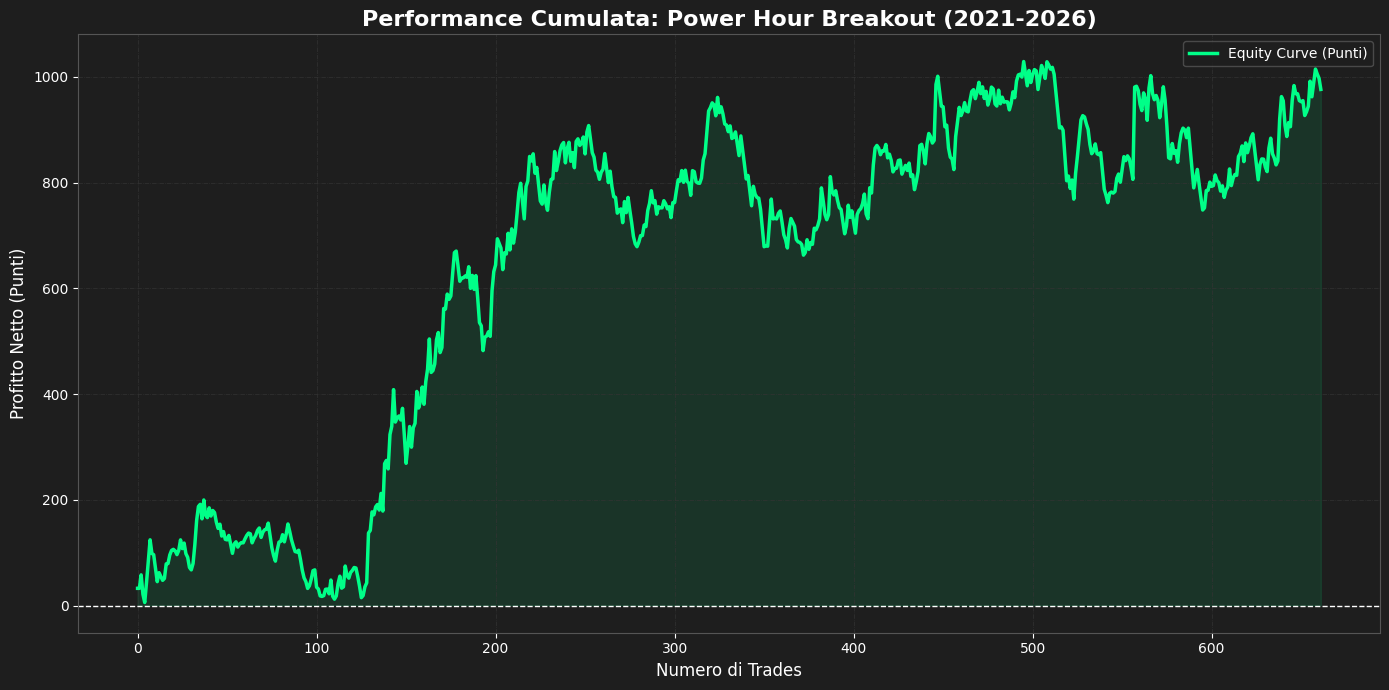

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("🚀 INIZIALIZZAZIONE SUPER-BOT: Power Hour Breakout (14:00 - 15:59) 🚀")
print("Caricamento in corso... Generazione Equity Curve finale...")

# --- 1. PREPARAZIONE DATI ---
df_pm = df_all.copy()
if 'Volume' not in df_pm.columns: df_pm['Volume'] = 100
df_pm['Year'] = df_pm.index.year
df_pm['Semester'] = np.where(df_pm.index.month <= 6, 'H1', 'H2')
df_pm['Period'] = df_pm['Year'].astype(str) + "-" + df_pm['Semester']

# Calcolo ATR a 14 giorni (approssimato sul Daily)
daily_df = df_pm.groupby(df_pm.index.date).agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'})
daily_df['Prev_Close'] = daily_df['Close'].shift(1)
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['ATR_14'] = daily_df['TrueRange'].rolling(14).mean().shift(1)
atr_dict = daily_df['ATR_14'].to_dict()

# --- PARAMETRI QUANTITATIVI PM ---
MAX_IB_PM = 28.0           # Il mercato deve aver compresso la mattina
PM_TARGET_ATR = 0.40       # Target rapido per il Contratto 1
PM_STOP_ATR = 0.30         # Stop Loss stretto e dinamico
COSTO_C_SINGOLO = 0.50     # Costo per singolo contratto

trades = []

# --- 2. MOTORE DI ESECUZIONE ---
for period, p_group in df_pm.groupby('Period'):
    for date, day_group in p_group.groupby(p_group.index.date):
        daily_atr = atr_dict.get(date, np.nan)
        if pd.isna(daily_atr): continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        if pd.isna(ib_h) or pd.isna(ib_l): continue
        ib_size = ib_h - ib_l
        
        # Filtro: Niente breakout se la mattina ha già fatto troppa strada
        if ib_size > MAX_IB_PM: continue
            
        tp_series = (day_group['High'] + day_group['Low'] + day_group['Close']) / 3
        day_group = day_group.assign(VWAP=(tp_series * day_group['Volume']).cumsum() / day_group['Volume'].cumsum())
        
        # Isoliamo SOLO il Power Hour
        pm_session = day_group[(day_group.index.time >= pd.to_datetime('14:00').time()) & 
                               (day_group.index.time <= pd.to_datetime('15:59').time())]
        if pm_session.empty: continue
            
        trade_active = False
        trade_done_today = False
        pos = {}
        
        for row in pm_session.itertuples():
            curr_time = row.Index.time()
            
            # --- CHIUSURA FORZATA (TIME EXIT 15:59) ---
            if curr_time >= pd.to_datetime('15:59').time():
                if trade_active:
                    mult = 1 if pos['type'] == 'long' else -1
                    if pos['c1_active']: pos['pnl'] += (row.Close - pos['entry']) * mult - COSTO_C_SINGOLO
                    if pos['c2_active']: pos['pnl'] += (row.Close - pos['entry']) * mult - COSTO_C_SINGOLO
                    trades.append({'Date': date, 'Period': period, 'Type': pos['type'], 'PnL': pos['pnl']})
                break
                
            # --- GESTIONE POSIZIONE APERTA ---
            if trade_active:
                if pos['type'] == 'long':
                    # Stop Loss Hit
                    if row.Low <= pos['stop']:
                        if pos['c1_active']: pos['pnl'] -= (pos['entry'] - pos['stop']) + COSTO_C_SINGOLO
                        if pos['c2_active']: pos['pnl'] -= (pos['entry'] - pos['stop']) + COSTO_C_SINGOLO
                        trade_active = False
                        trades.append({'Date': date, 'Period': period, 'Type': 'long', 'PnL': pos['pnl']})
                        continue
                        
                    # Target 1 Hit -> Sposta C2 a Break-Even
                    if pos['c1_active'] and row.High >= pos['c1_tgt']:
                        pos['pnl'] += (pos['c1_tgt'] - pos['entry']) - COSTO_C_SINGOLO
                        pos['c1_active'] = False
                        pos['stop'] = pos['entry'] # BREAK-EVEN RUNNER
                        
                elif pos['type'] == 'short':
                    # Stop Loss Hit
                    if row.High >= pos['stop']:
                        if pos['c1_active']: pos['pnl'] -= (pos['stop'] - pos['entry']) + COSTO_C_SINGOLO
                        if pos['c2_active']: pos['pnl'] -= (pos['stop'] - pos['entry']) + COSTO_C_SINGOLO
                        trade_active = False
                        trades.append({'Date': date, 'Period': period, 'Type': 'short', 'PnL': pos['pnl']})
                        continue
                        
                    # Target 1 Hit -> Sposta C2 a Break-Even
                    if pos['c1_active'] and row.Low <= pos['c1_tgt']:
                        pos['pnl'] += (pos['entry'] - pos['c1_tgt']) - COSTO_C_SINGOLO
                        pos['c1_active'] = False
                        pos['stop'] = pos['entry'] # BREAK-EVEN RUNNER

            # --- ENTRATA A MERCATO (Solo 1 trade al giorno) ---
            if not trade_active and not trade_done_today:
                # LONG Breakout
                if row.Close > ib_h and row.Close > row.VWAP:
                    pos = {
                        'type': 'long', 'entry': row.Close, 
                        'stop': row.Close - (daily_atr * PM_STOP_ATR),
                        'c1_tgt': row.Close + (daily_atr * PM_TARGET_ATR),
                        'c1_active': True, 'c2_active': True, 'pnl': 0
                    }
                    trade_active = True
                    trade_done_today = True
                    
                # SHORT Breakout
                elif row.Close < ib_l and row.Close < row.VWAP:
                    pos = {
                        'type': 'short', 'entry': row.Close, 
                        'stop': row.Close + (daily_atr * PM_STOP_ATR),
                        'c1_tgt': row.Close - (daily_atr * PM_TARGET_ATR),
                        'c1_active': True, 'c2_active': True, 'pnl': 0
                    }
                    trade_active = True
                    trade_done_today = True

# --- 3. CREAZIONE REPORT ED EQUITY CURVE ---
df_res = pd.DataFrame(trades)

if df_res.empty:
    print("Nessun trade trovato.")
else:
    df_res['res'] = np.where(df_res['PnL'] > 0, 1, 0)
    
    # Report Tabellare
    report = df_res.groupby('Period').agg(
        Trades=('PnL', 'count'),
        Wins=('res', 'sum'),
        Net_PnL=('PnL', 'sum')
    )
    report['WinRate %'] = (report['Wins'] / report['Trades'] * 100).round(1)
    report['Avg PnL'] = (report['Net_PnL'] / report['Trades']).round(2)
    report['Net_PnL'] = report['Net_PnL'].round(2)
    
    # Dati globali
    tot_trades = df_res.shape[0]
    tot_wins = df_res['res'].sum()
    win_rate = (tot_wins / tot_trades) * 100
    tot_pnl = df_res['PnL'].sum()
    
    print("\n" + "="*80)
    print("📊 RISULTATI FINALI: POWER HOUR BREAKOUT (14:00-15:59) 📊")
    print("="*80)
    print(f"{'Semestre':<10} | {'Trades':<8} | {'Win Rate':<10} | {'Avg/Trade':<10} | {'Net PnL (Punti)'}")
    print("-" * 80)
    for p, r in report.iterrows():
        print(f"{p:<10} | {int(r['Trades']):<8} | {r['WinRate %']:>5.1f}%    | {r['Avg PnL']:>8.2f}   | {r['Net_PnL']:>12.2f}")
    print("="*80)
    print(f"TRADES TOTALI: {tot_trades}")
    print(f"WIN RATE MEDIO: {win_rate:.1f}%")
    print(f"PROFITTO NETTO CUMULATO: {tot_pnl:.2f} Punti (${tot_pnl * 50:,.2f})")
    print("="*80)

    # Generazione Grafico Matplotlib
    df_res['Cumulative_PnL'] = df_res['PnL'].cumsum()
    
    plt.figure(figsize=(14, 7))
    plt.plot(range(len(df_res)), df_res['Cumulative_PnL'], color='#00ff88', linewidth=2.5, label='Equity Curve (Punti)')
    plt.fill_between(range(len(df_res)), df_res['Cumulative_PnL'], 0, where=(df_res['Cumulative_PnL'] > 0), color='#00ff88', alpha=0.1)
    plt.fill_between(range(len(df_res)), df_res['Cumulative_PnL'], 0, where=(df_res['Cumulative_PnL'] < 0), color='#ff3333', alpha=0.1)
    
    plt.axhline(0, color='white', linewidth=1, linestyle='--')
    plt.title('Performance Cumulata: Power Hour Breakout (2021-2026)', fontsize=16, fontweight='bold', color='white')
    plt.xlabel('Numero di Trades', fontsize=12, color='white')
    plt.ylabel('Profitto Netto (Punti)', fontsize=12, color='white')
    
    # Stile "Dark Mode" Istituzionale
    plt.gca().set_facecolor('#1e1e1e')
    plt.gcf().patch.set_facecolor('#1e1e1e')
    plt.tick_params(colors='white')
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('#555555')
    
    plt.grid(color='#333333', linestyle='-.', linewidth=0.5)
    plt.legend(facecolor='#1e1e1e', edgecolor='#555555', labelcolor='white')
    plt.tight_layout()
    
    print("\nVisualizzazione grafico Equity Curve in corso...")
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("🧬 RISONANZA MAGNETICA DEL MERCATO: 2021-2023 vs 2024-2026 🧬")
print("Analisi strutturale e dei volumi in corso...\n")

# Assicurati che df_all sia caricato correttamente con i volumi
df_str = df_all.copy()
if 'Volume' not in df_str.columns:
    print("ATTENZIONE: La colonna 'Volume' manca. Questo script richiede i volumi reali per funzionare al meglio.")
    df_str['Volume'] = 100 # Fallback fittizio se i volumi non ci sono

df_str['Year'] = df_str.index.year
df_str['Era'] = np.where(df_str['Year'] <= 2023, 'Era 1 (2021-2023)', 'Era 2 (2024-2026)')

market_dna = []

for era, e_group in df_str.groupby('Era'):
    for date, day_group in e_group.groupby(e_group.index.date):
        
        # 1. Metriche Strutturali (Range)
        d_open = day_group['Open'].iloc[0]
        d_high = day_group['High'].max()
        d_low = day_group['Low'].min()
        d_close = day_group['Close'].iloc[-1]
        
        d_range = d_high - d_low
        if d_range == 0: continue
            
        ib_h = day_group['IB_High'].iloc[0]
        ib_l = day_group['IB_Low'].iloc[0]
        ib_size = ib_h - ib_l
        
        # Quanto pesa l'IB sul range totale della giornata? (IB % of Total Range)
        ib_pct_of_day = (ib_size / d_range) * 100
        
        # 2. Tipologia di Giornata (Trend vs Chop)
        # Se chiude nel 25% superiore o inferiore del range, è una giornata Trend. Altrimenti è Chop (Palude).
        close_location = (d_close - d_low) / d_range
        day_type = 'Trend' if (close_location >= 0.75 or close_location <= 0.25) else 'Chop/Mean Reversion'
        
        # 3. Spostamento dei Volumi
        tot_vol = day_group['Volume'].sum()
        
        # Isoliamo le fasce orarie
        am_vol = day_group[(day_group.index.time >= pd.to_datetime('09:30').time()) & (day_group.index.time < pd.to_datetime('11:00').time())]['Volume'].sum()
        mid_vol = day_group[(day_group.index.time >= pd.to_datetime('11:00').time()) & (day_group.index.time < pd.to_datetime('14:00').time())]['Volume'].sum()
        pm_vol = day_group[(day_group.index.time >= pd.to_datetime('14:00').time()) & (day_group.index.time <= pd.to_datetime('16:00').time())]['Volume'].sum()
        
        am_vol_pct = (am_vol / tot_vol) * 100 if tot_vol > 0 else 0
        pm_vol_pct = (pm_vol / tot_vol) * 100 if tot_vol > 0 else 0
        
        market_dna.append({
            'Era': era,
            'Daily_Range': d_range,
            'IB_Size': ib_size,
            'IB_Dominance_%': ib_pct_of_day,
            'Day_Type': day_type,
            'AM_Volume_%': am_vol_pct,
            'PM_Volume_%': pm_vol_pct
        })

df_dna = pd.DataFrame(market_dna)

# --- CREAZIONE DEL REPORT COMPARATIVO ---
print("="*90)
print(f"{'METRICA':<30} | {'ERA 1 (2021-2023)':<25} | {'ERA 2 (2024-2026)':<25}")
print("-" * 90)

era1 = df_dna[df_dna['Era'] == 'Era 1 (2021-2023)']
era2 = df_dna[df_dna['Era'] == 'Era 2 (2024-2026)']

# Metriche Calcolate
metrics = [
    ("Escursione Giornaliera (Pt)", era1['Daily_Range'].mean(), era2['Daily_Range'].mean()),
    ("Initial Balance Medio (Pt)", era1['IB_Size'].mean(), era2['IB_Size'].mean()),
    ("Dominanza IB sul Range (%)", era1['IB_Dominance_%'].mean(), era2['IB_Dominance_%'].mean()),
    ("Volumi Mattina (09:30-11:00)", era1['AM_Volume_%'].mean(), era2['AM_Volume_%'].mean()),
    ("Volumi Pomeriggio (14:00-16)", era1['PM_Volume_%'].mean(), era2['PM_Volume_%'].mean())
]

for name, v1, v2 in metrics:
    print(f"{name:<30} | {v1:<25.2f} | {v2:<25.2f}")

print("-" * 90)

# Calcolo Frequenza Tipologia di Giornata
t1 = (era1['Day_Type'] == 'Trend').sum() / len(era1) * 100
c1 = (era1['Day_Type'] == 'Chop/Mean Reversion').sum() / len(era1) * 100

t2 = (era2['Day_Type'] == 'Trend').sum() / len(era2) * 100
c2 = (era2['Day_Type'] == 'Chop/Mean Reversion').sum() / len(era2) * 100

print(f"{'% Giornate TREND (Direzionali)':<30} | {t1:<24.1f}% | {t2:<24.1f}%")
print(f"{'% Giornate CHOP (Palude)':<30} | {c1:<24.1f}% | {c2:<24.1f}%")
print("="*90)

🧬 RISONANZA MAGNETICA DEL MERCATO: 2021-2023 vs 2024-2026 🧬
Analisi strutturale e dei volumi in corso...

METRICA                        | ERA 1 (2021-2023)         | ERA 2 (2024-2026)        
------------------------------------------------------------------------------------------
Escursione Giornaliera (Pt)    | 52.43                     | 68.41                    
Initial Balance Medio (Pt)     | 26.61                     | 30.74                    
Dominanza IB sul Range (%)     | 55.66                     | 55.19                    
Volumi Mattina (09:30-11:00)   | 34.63                     | 33.88                    
Volumi Pomeriggio (14:00-16)   | 31.49                     | 30.25                    
------------------------------------------------------------------------------------------
% Giornate TREND (Direzionali) | 62.2                    % | 55.1                    %
% Giornate CHOP (Palude)       | 37.8                    % | 44.9                    %


In [ ]:
import pandas as pd
import numpy as np

print("🔮 PROFILATORE PREDITTIVO ERA 2 (2024-2026): Anatomia dei Chop vs Trend 🔮")
print("Analisi dei segnali pre-10:30 in corso...\n")

# Isoliamo l'Era 2
df_modern = df_all[df_all.index.year >= 2024].copy()
if 'Volume' not in df_modern.columns: df_modern['Volume'] = 100

# Calcoli Giornalieri e Prior Day
daily_df = df_modern.groupby(df_modern.index.date).agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'
})
daily_df['Prev_High'] = daily_df['High'].shift(1)
daily_df['Prev_Low'] = daily_df['Low'].shift(1)
daily_df['Prev_Close'] = daily_df['Close'].shift(1)

# Calcolo ATR a 14 periodi
daily_df['TR1'] = daily_df['High'] - daily_df['Low']
daily_df['TR2'] = abs(daily_df['High'] - daily_df['Prev_Close'])
daily_df['TR3'] = abs(daily_df['Low'] - daily_df['Prev_Close'])
daily_df['TrueRange'] = daily_df[['TR1', 'TR2', 'TR3']].max(axis=1)
daily_df['Prev_ATR'] = daily_df['TrueRange'].rolling(14).mean().shift(1)

# Resettiamo l'indice per far combaciare le date nel merge
daily_df['Date'] = daily_df.index
daily_dict = daily_df.set_index('Date').to_dict('index')

predictive_data = []

for date, day_group in df_modern.groupby(df_modern.index.date):
    d_stats = daily_dict.get(date)
    if not d_stats or pd.isna(d_stats['Prev_ATR']): continue
        
    d_open = d_stats['Open']
    d_high = d_stats['High']
    d_low = d_stats['Low']
    d_close = d_stats['Close']
    d_range = d_high - d_low
    if d_range == 0: continue
        
    # --- CALCOLO VARIABILI PREDITTIVE (Disponibili alle 10:30) ---
    
    # 1. Open Inside/Outside Prev Range
    open_inside = 1 if (d_stats['Prev_Low'] <= d_open <= d_stats['Prev_High']) else 0
    
    # 2. IB Size vs ATR
    ib_h = day_group['IB_High'].iloc[0]
    ib_l = day_group['IB_Low'].iloc[0]
    ib_size = ib_h - ib_l
    ib_atr_pct = (ib_size / d_stats['Prev_ATR']) * 100
    
    # 3. Gap Size vs ATR
    gap_size = abs(d_open - d_stats['Prev_Close'])
    gap_atr_pct = (gap_size / d_stats['Prev_ATR']) * 100
    
    # 4. VWAP Crosses nell'IB (09:30 - 10:30)
    am_session = day_group[(day_group.index.time >= pd.to_datetime('09:30').time()) & 
                           (day_group.index.time <= pd.to_datetime('10:30').time())]
    
    if am_session.empty: continue
        
    tp_am = (am_session['High'] + am_session['Low'] + am_session['Close']) / 3
    am_vwap = (tp_am * am_session['Volume']).cumsum() / am_session['Volume'].cumsum()
    
    # Contiamo quante volte il Close a 1 minuto taglia il VWAP
    crosses = 0
    prev_above = am_session.iloc[0]['Close'] > am_vwap.iloc[0]
    for i in range(1, len(am_session)):
        curr_above = am_session.iloc[i]['Close'] > am_vwap.iloc[i]
        if curr_above != prev_above:
            crosses += 1
            prev_above = curr_above
            
    # --- DEFINIZIONE DAY TYPE (La Verità a fine giornata) ---
    close_loc = (d_close - d_low) / d_range
    day_type = 'TREND' if (close_loc >= 0.75 or close_loc <= 0.25) else 'CHOP'
    
    predictive_data.append({
        'Date': date,
        'Day_Type': day_type,
        'Open_Inside_%': open_inside * 100,
        'IB_vs_ATR_%': ib_atr_pct,
        'Gap_vs_ATR_%': gap_atr_pct,
        'VWAP_Crosses_IB': crosses
    })

df_pred = pd.DataFrame(predictive_data)

# --- CREAZIONE REPORT ---
print("="*100)
print(f"{'DAY TYPE':<15} | {'Apertura in Range Ieri':<25} | {'IB Size vs ATR':<18} | {'Gap vs ATR':<15} | {'VWAP Crosses (AM)'}")
print("-" * 100)

summary = df_pred.groupby('Day_Type').agg(
    Count=('Day_Type', 'count'),
    Open_Inside=('Open_Inside_%', 'mean'),
    IB_ATR=('IB_vs_ATR_%', 'mean'),
    Gap_ATR=('Gap_vs_ATR_%', 'mean'),
    VWAP_Cross=('VWAP_Crosses_IB', 'mean')
).round(1)

for d_type, r in summary.iterrows():
    print(f"{d_type:<15} | {r['Open_Inside']:>18.1f}%       | {r['IB_ATR']:>12.1f}%     | {r['Gap_ATR']:>9.1f}%    | {r['VWAP_Cross']:>12.1f}")

print("="*100)
print("\n💡 CHIAVI DI LETTURA:")
print("- Se i CHOP hanno un 'Apertura in Range' molto più alta, l'Open ci dice subito se il mercato è in stallo.")
print("- Se i TREND hanno un 'IB Size vs ATR' più basso, significa che i trend partono solo se c'è compressione mattutina.")
print("- Se i CHOP hanno molti più 'VWAP Crosses', l'algoritmo di lotta nel fango si riconosce già nella prima ora.")

🔮 PROFILATORE PREDITTIVO ERA 2 (2024-2026): Anatomia dei Chop vs Trend 🔮
Analisi dei segnali pre-10:30 in corso...

DAY TYPE        | Apertura in Range Ieri    | IB Size vs ATR     | Gap vs ATR      | VWAP Crosses (AM)
----------------------------------------------------------------------------------------------------
CHOP            |               51.7%       |         51.3%     |      40.8%    |          6.3
TREND           |               58.3%       |         52.2%     |      38.7%    |          6.6

💡 CHIAVI DI LETTURA:
- Se i CHOP hanno un 'Apertura in Range' molto più alta, l'Open ci dice subito se il mercato è in stallo.
- Se i TREND hanno un 'IB Size vs ATR' più basso, significa che i trend partono solo se c'è compressione mattutina.
- Se i CHOP hanno molti più 'VWAP Crosses', l'algoritmo di lotta nel fango si riconosce già nella prima ora.


In [ ]:
import pandas as pd
import numpy as np

print("📊 ANALISI QUALITÀ DEL VOLUME (Era 2: 2024-2026) 📊")

df_vol = df_all[df_all.index.year >= 2024].copy()

# Calcoliamo il volume medio "rolling" per avere un termine di paragone
df_vol['Avg_Vol_100'] = df_vol['Volume'].rolling(100).mean()

vol_analysis = []

for date, day_group in df_vol.groupby(df_vol.index.date):
    ib_h = day_group['IB_High'].iloc[0]
    ib_l = day_group['IB_Low'].iloc[0]
    
    # Cerchiamo il primo momento di breakout post-10:30
    post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
    
    breakout = post_ib[(post_ib['Close'] > ib_h) | (post_ib['Close'] < ib_l)].head(1)
    
    if not breakout.empty:
        vol_at_break = breakout['Volume'].iloc[0]
        avg_vol = breakout['Avg_Vol_100'].iloc[0]
        
        # Rapporto volume al breakout vs media
        vol_ratio = vol_at_break / avg_vol
        
        # Esito: È stato un trend day (chiusura estrema) o no?
        d_high = day_group['High'].max()
        d_low = day_group['Low'].min()
        d_close = day_group['Close'].iloc[-1]
        close_loc = (d_close - d_low) / (d_high - d_low)
        day_type = 'TREND' if (close_loc >= 0.75 or close_loc <= 0.25) else 'CHOP'
        
        vol_analysis.append({'Vol_Ratio': vol_ratio, 'Day_Type': day_type})

df_vol_res = pd.DataFrame(vol_analysis)
summary_vol = df_vol_res.groupby('Day_Type')['Vol_Ratio'].mean()

print("\n" + "="*50)
print(f"RAPPORTO VOLUME AL BREAKOUT (Volume / Media)")
print("="*50)
print(f"Giornate TREND: {summary_vol.get('TREND', 0):.2f}x rispetto alla media")
print(f"Giornate CHOP:  {summary_vol.get('CHOP', 0):.2f}x rispetto alla media")
print("="*50)

📊 ANALISI QUALITÀ DEL VOLUME (Era 2: 2024-2026) 📊

RAPPORTO VOLUME AL BREAKOUT (Volume / Media)
Giornate TREND: 1.51x rispetto alla media
Giornate CHOP:  1.28x rispetto alla media


In [ ]:
import pandas as pd
import numpy as np

print("🧬 ANALISI STRUTTURALE: Quando un Breakout diventa Trend? (2024-2026) 🧬")

df_trend = df_all[df_all.index.year >= 2024].copy()

analysis_results = []

for date, day_group in df_trend.groupby(df_trend.index.date):
    ib_h = day_group['IB_High'].iloc[0]
    ib_l = day_group['IB_Low'].iloc[0]
    
    # Identifichiamo il primo breakout post-10:30
    post_ib = day_group[day_group.index.time >= pd.to_datetime('10:30').time()]
    
    # Troviamo il primo momento di uscita
    break_idx = post_ib[(post_ib['Close'] > ib_h) | (post_ib['Close'] < ib_l)].index.min()
    
    if pd.notna(break_idx):
        side = 'UP' if post_ib.loc[break_idx, 'Close'] > ib_h else 'DOWN'
        entry_price = post_ib.loc[break_idx, 'Close']
        
        # Analizziamo i 30 minuti successivi al breakout
        future_window = day_group.loc[break_idx:].head(30)
        
        # 1. Sustainability: Quanto tempo (minuti) sta fuori prima di rientrare?
        if side == 'UP':
            reentry = future_window[future_window['Low'] <= ib_h].index.min()
        else:
            reentry = future_window[future_window['High'] >= ib_l].index.min()
            
        minutes_outside = len(future_window) if pd.isna(reentry) else (reentry - break_idx).seconds // 60
        
        # 2. Extension: Quanti punti ha guadagnato dopo 15 minuti?
        window_15 = future_window.head(15)
        if side == 'UP':
            max_ext = window_15['High'].max() - ib_h
        else:
            max_ext = ib_l - window_15['Low'].min()
            
        # 3. Esito finale della giornata (Trend vs Chop)
        d_high, d_low = day_group['High'].max(), day_group['Low'].min()
        d_close = day_group['Close'].iloc[-1]
        close_loc = (d_close - d_low) / (d_high - d_low)
        day_type = 'TREND' if (close_loc >= 0.75 or close_loc <= 0.25) else 'CHOP'
        
        analysis_results.append({
            'Day_Type': day_type,
            'Min_Outside': minutes_outside,
            'Ext_15m': max_ext,
            'Hour': break_idx.hour + (break_idx.minute / 60.0)
        })

df_analysis = pd.DataFrame(analysis_results)

print("\n" + "="*80)
print(f"{'DAY TYPE':<12} | {'Minuti fuori IB (30m test)':<25} | {'Estensione 15m (Pt)':<20} | {'Ora Breakout'}")
print("-" * 80)

summary = df_analysis.groupby('Day_Type').agg({
    'Min_Outside': 'mean',
    'Ext_15m': 'mean',
    'Hour': 'mean'
}).round(2)

for d_type, r in summary.iterrows():
    h = int(r['Hour'])
    m = int((r['Hour'] - h) * 60)
    print(f"{d_type:<12} | {r['Min_Outside']:<25} | {r['Ext_15m']:<20} | {h:02d}:{m:02d}")
print("="*80)

🧬 ANALISI STRUTTURALE: Quando un Breakout diventa Trend? (2024-2026) 🧬

DAY TYPE     | Minuti fuori IB (30m test) | Estensione 15m (Pt)  | Ora Breakout
--------------------------------------------------------------------------------
CHOP         | 0.0                       | 7.08                 | 11:06
TREND        | 0.0                       | 7.03                 | 11:15


In [ ]:
import pandas as pd
import numpy as np

print("📊 BACKTEST SMC: 5m Range + 1m FVG + Engulfing Confirmation (Fixed) 📊")

# Assicuriamoci che il dataframe sia ordinato e con indice Datetime
df_smc = df_all.copy()
df_smc['Quarter'] = df_smc.index.to_period('Q')

results = []

for date, day_group in df_smc.groupby(df_smc.index.date):
    # 1. Identifica il range 09:30 - 09:35 (esclusa la candela delle 09:35)
    range_5m = day_group.between_time('09:30', '09:34')
    if range_5m.empty: continue
    
    h_5m = range_5m['High'].max()
    l_5m = range_5m['Low'].min()
    
    # Analizziamo i dati dalle 09:35 in poi
    post_range = day_group.between_time('09:35', '16:00').copy()
    
    setup_active = False
    side = None
    fvg_zone = None
    
    # Loop per candele da 1 minuto
    for i in range(2, len(post_range)):
        row = post_range.iloc[i]
        prev = post_range.iloc[i-1]
        prev2 = post_range.iloc[i-2]
        
        if not setup_active:
            # --- RILEVAZIONE BREAKOUT + FVG ---
            # Bullish: Breakout High 5m + Gap tra Low candela attuale e High candela i-2
            if prev['Close'] > h_5m and row['Low'] > prev2['High']:
                setup_active = True
                side = 'LONG'
                fvg_zone = (prev2['High'], row['Low']) 
            
            # Bearish: Breakout Low 5m + Gap tra High candela attuale e Low candela i-2
            elif prev['Close'] < l_5m and row['High'] < prev2['Low']:
                setup_active = True
                side = 'SHORT'
                fvg_zone = (row['High'], prev2['Low'])
                
        else:
            # --- ATTESA RITRACCIAMENTO + ENGULFING ---
            in_fvg = (row['Low'] <= fvg_zone[1] and row['High'] >= fvg_zone[0])
            
            if in_fvg:
                # Verifica Engulfing
                engulfing = False
                if side == 'LONG':
                    if row['Close'] > row['Open'] and prev['Close'] < prev['Open'] and \
                       row['Close'] > prev['Open'] and row['Open'] < prev['Close']:
                        engulfing = True
                        entry_price = row['Close']
                        # SL 1 tick sotto il minimo del ritracciamento (candela attuale o precedente)
                        sl = min(row['Low'], prev['Low']) - 0.25
                else:
                    if row['Close'] < row['Open'] and prev['Close'] > prev['Open'] and \
                       row['Close'] < prev['Open'] and row['Open'] > prev['Close']:
                        engulfing = True
                        entry_price = row['Close']
                        # SL 1 tick sopra il massimo del ritracciamento
                        sl = max(row['High'], prev['High']) + 0.25
                
                if engulfing:
                    risk = abs(entry_price - sl)
                    if risk <= 0.5: continue # Evitiamo trade con stop troppo stretti (rumore)
                    
                    # Target 1:1, 1:2, 1:3
                    tp1 = entry_price + risk if side == 'LONG' else entry_price - risk
                    tp2 = entry_price + (risk * 2) if side == 'LONG' else entry_price - (risk * 2)
                    tp3 = entry_price + (risk * 3) if side == 'LONG' else entry_price - (risk * 3)
                    
                    # Tracking esito
                    future = post_range.iloc[i+1:]
                    hit_tp1 = False; hit_tp2 = False; hit_tp3 = False; hit_sl = False
                    
                    for _, f_row in future.iterrows():
                        if side == 'LONG':
                            if f_row['Low'] <= sl: hit_sl = True; break
                            if f_row['High'] >= tp1: hit_tp1 = True
                            if f_row['High'] >= tp2: hit_tp2 = True
                            if f_row['High'] >= tp3: hit_tp3 = True; break
                        else:
                            if f_row['High'] >= sl: hit_sl = True; break
                            if f_row['Low'] <= tp1: hit_tp1 = True
                            if f_row['Low'] <= tp2: hit_tp2 = True
                            if f_row['Low'] <= tp3: hit_tp3 = True; break
                    
                    results.append({
                        'Quarter': row.name.to_period('Q'),
                        'TP1': 1 if hit_tp1 else 0,
                        'TP2': 1 if hit_tp2 else 0,
                        'TP3': 1 if hit_tp3 else 0,
                        'Win': 1 if hit_tp3 else 0,
                        'Loss': 1 if hit_sl or (not hit_tp3 and not hit_sl) else 0
                    })
                    break # Un setup al giorno per lato
            
            # Annullamento setup se il prezzo scappa senza tornare nell'FVG
            elif side == 'LONG' and row['High'] > h_5m + (h_5m - l_5m): break
            elif side == 'SHORT' and row['Low'] < l_5m - (h_5m - l_5m): break

# --- OUTPUT ---
df_res = pd.DataFrame(results)
if df_res.empty:
    print("Nessun trade trovato. Prova ad allargare i filtri.")
else:
    report = df_res.groupby('Quarter').agg(
        Trades=('Quarter', 'count'),
        Reach_1_1=('TP1', 'sum'),
        Reach_1_2=('TP2', 'sum'),
        Full_TP_1_3=('TP3', 'sum')
    )
    
    print("\n" + "="*80)
    print(f"{'Trimestre':<10} | {'Trades':<7} | {'Target 1:1':<12} | {'Target 1:2':<12} | {'Target 1:3'}")
    print("-" * 80)
    for q, r in report.iterrows():
        print(f"{str(q):<10} | {r['Trades']:<7} | {r['Reach_1_1']:<12} | {r['Reach_1_2']:<12} | {r['Full_TP_1_3']}")
    print("="*80)
    print(f"TOTALI     | {report['Trades'].sum():<7} | {report['Reach_1_1'].sum():<12} | {report['Reach_1_2'].sum():<12} | {report['Full_TP_1_3'].sum()}")

📊 BACKTEST SMC: 5m Range + 1m FVG + Engulfing Confirmation (Fixed) 📊

Trimestre  | Trades  | Target 1:1   | Target 1:2   | Target 1:3
--------------------------------------------------------------------------------
2021Q1     | 6       | 3            | 2            | 2
2021Q2     | 7       | 4            | 4            | 3
2021Q3     | 8       | 4            | 4            | 1
2021Q4     | 12      | 8            | 5            | 4
2022Q1     | 12      | 6            | 3            | 3
2022Q2     | 15      | 10           | 7            | 7
2022Q3     | 17      | 8            | 5            | 3
2022Q4     | 10      | 5            | 3            | 3
2023Q1     | 10      | 7            | 4            | 4
2023Q2     | 9       | 5            | 3            | 1
2023Q3     | 9       | 7            | 6            | 5
2023Q4     | 3       | 2            | 2            | 1
2024Q1     | 12      | 5            | 2            | 2
2024Q2     | 2       | 0            | 0            | 0
2024Q3     | 11

In [ ]:
import pandas as pd
import numpy as np

print("🧪 ANALISI ARCHITETTURALE: Opening Range 5m vs 15m (Era 2021-2026) 🧪")

df_dna = df_all.copy()

results_5m = []
results_15m = []

for date, day_group in df_dna.groupby(df_dna.index.date):
    # Dati Giornalieri per calcolo HOD/LOD
    d_high, d_low = day_group['High'].max(), day_group['Low'].min()
    
    # --- ANALISI 5 MINUTI (09:30-09:35) ---
    c5m = day_group.between_time('09:30', '09:34')
    if not c5m.empty:
        h5, l5 = c5m['High'].max(), c5m['Low'].min()
        is_hod = 1 if h5 == d_high else 0
        is_lod = 1 if l5 == d_low else 0
        
        # Analisi Breakout post 09:35
        post_5m = day_group.between_time('09:35', '16:00')
        up_break = post_5m[post_5m['High'] > h5].head(1)
        if not up_break.empty:
            entry_t = up_break.index[0]
            # Vediamo se ritraccia a testare h5 prima di fare +10 pt
            path = post_5m.loc[entry_t:].head(60) # Finestra di 60 min
            retest = 1 if path['Low'].min() <= h5 else 0
            max_ext = path['High'].max() - h5
            results_5m.append({'HOD': is_hod, 'LOD': is_lod, 'Retest': retest, 'Ext': max_ext})

    # --- ANALISI 15 MINUTI (09:30-09:45) ---
    c15m = day_group.between_time('09:30', '09:44')
    if not c15m.empty:
        h15, l15 = c15m['High'].max(), c15m['Low'].min()
        is_hod15 = 1 if h15 == d_high else 0
        is_lod15 = 1 if l15 == d_low else 0
        
        post_15m = day_group.between_time('09:45', '16:00')
        up_break15 = post_15m[post_15m['High'] > h15].head(1)
        if not up_break15.empty:
            entry_t15 = up_break15.index[0]
            path15 = post_15m.loc[entry_t15:].head(60)
            retest15 = 1 if path15['Low'].min() <= h15 else 0
            max_ext15 = path15['High'].max() - h15
            results_15m.append({'HOD': is_hod15, 'LOD': is_lod15, 'Retest': retest15, 'Ext': max_ext15})

# --- ELABORAZIONE DATI ---
def summarize(res_list, name):
    df = pd.DataFrame(res_list)
    print(f"\n📊 RISULTATI OPENING RANGE: {name}")
    print("-" * 50)
    print(f"Probabilità che l'High/Low sia l'estremo di giornata: {((df['HOD'].sum() + df['LOD'].sum()) / (len(df)*2) * 100):.1f}%")
    print(f"Probabilità di Retest del livello dopo Breakout: {(df['Retest'].mean() * 100):.1f}%")
    print(f"Estensione Media post-breakout (60 min): {df['Ext'].mean():.2f} pt")
    print(f"Estensione Mediana post-breakout: {df['Ext'].median():.2f} pt")

summarize(results_5m, "5 MINUTI (09:30-09:35)")
summarize(results_15m, "15 MINUTI (09:30-09:45)")

🧪 ANALISI ARCHITETTURALE: Opening Range 5m vs 15m (Era 2021-2026) 🧪

📊 RISULTATI OPENING RANGE: 5 MINUTI (09:30-09:35)
--------------------------------------------------
Probabilità che l'High/Low sia l'estremo di giornata: 7.9%
Probabilità di Retest del livello dopo Breakout: 100.0%
Estensione Media post-breakout (60 min): 12.60 pt
Estensione Mediana post-breakout: 9.00 pt

📊 RISULTATI OPENING RANGE: 15 MINUTI (09:30-09:45)
--------------------------------------------------
Probabilità che l'High/Low sia l'estremo di giornata: 12.9%
Probabilità di Retest del livello dopo Breakout: 100.0%
Estensione Media post-breakout (60 min): 11.96 pt
Estensione Mediana post-breakout: 8.50 pt


In [ ]:
import pandas as pd
import numpy as np

def analyze_opening_range(df, timeframe_minutes):
    results = {'High_Break': [], 'Low_Break': []}
    
    # Definiamo l'orario di fine candela
    end_time = (pd.to_datetime('09:30') + pd.to_timedelta(timeframe_minutes, unit='m')).time()
    
    for date, day_group in df.groupby(df.index.date):
        # 1. Identifica la candela Opening Range (OR)
        or_candle = day_group[(day_group.index.time >= pd.to_datetime('09:30').time()) & 
                              (day_group.index.time < end_time)]
        if or_candle.empty: continue
        
        or_h, or_l = or_candle['High'].max(), or_candle['Low'].min()
        or_range = or_h - or_l
        if or_range <= 0: continue
        
        post_or = day_group[day_group.index.time >= end_time]
        
        # 2. Cerca il primo Breakout
        # Analizziamo sia breakout High che Low separatamente
        
        # --- BREAKOUT HIGH ---
        high_breaks = post_or[post_or['High'] > or_h]
        if not high_breaks.empty:
            idx = high_breaks.index[0]
            future = day_group.loc[idx:]
            # Trova il momento del retest (quando Low <= or_h)
            retest_event = future[future['Low'] <= or_h].head(1)
            if not retest_event.empty:
                retest_time = retest_event.index[0]
                path_to_retest = day_group.loc[idx:retest_time]
                ext = path_to_retest['High'].max() - or_h
                
                # Quanto entra dentro dopo aver toccato or_h? (nei 15 min successivi)
                post_retest = day_group.loc[retest_time:].head(15)
                deepest_point = post_retest['Low'].min()
                penetration = or_h - deepest_point
                penetration_pct = (penetration / or_range) * 100
                results['High_Break'].append({'ext': ext, 'depth': penetration_pct})

        # --- BREAKOUT LOW ---
        low_breaks = post_or[post_or['Low'] < or_l]
        if not low_breaks.empty:
            idx = low_breaks.index[0]
            future = day_group.loc[idx:]
            retest_event = future[future['High'] >= or_l].head(1)
            if not retest_event.empty:
                retest_time = retest_event.index[0]
                path_to_retest = day_group.loc[idx:retest_time]
                ext = or_l - path_to_retest['Low'].min()
                
                post_retest = day_group.loc[retest_time:].head(15)
                highest_point = post_retest['High'].max()
                penetration = highest_point - or_l
                penetration_pct = (penetration / or_range) * 100
                results['Low_Break'].append({'ext': ext, 'depth': penetration_pct})
                
    return results

# Esecuzione analisi
res_5m = analyze_opening_range(df_all, 5)
res_15m = analyze_opening_range(df_all, 15)

def print_report(res, title):
    print(f"\n📊 {title}")
    print("="*60)
    for side in ['High_Break', 'Low_Break']:
        data = pd.DataFrame(res[side])
        if not data.empty:
            print(f"STRUTTURA {side.upper()}:")
            print(f"  - Estensione Media: {data['ext'].mean():.2f} pt")
            print(f"  - Estensione Max:   {data['ext'].max():.2f} pt")
            print(f"  - Rientro Medio nel Range: {data['depth'].mean():.1f}% della candela")
            print(f"  - Rientro Mediano:         {data['depth'].median():.1f}% della candela")
            print("-" * 40)

print_report(res_5m, "OPENING RANGE 5 MINUTI (09:30-09:35)")
print_report(res_15m, "OPENING RANGE 15 MINUTI (09:30-09:45)")


📊 OPENING RANGE 5 MINUTI (09:30-09:35)
STRUTTURA HIGH_BREAK:
  - Estensione Media: 1.67 pt
  - Estensione Max:   18.50 pt
  - Rientro Medio nel Range: 78.4% della candela
  - Rientro Mediano:         58.3% della candela
----------------------------------------
STRUTTURA LOW_BREAK:
  - Estensione Media: 1.83 pt
  - Estensione Max:   23.50 pt
  - Rientro Medio nel Range: 83.7% della candela
  - Rientro Mediano:         67.8% della candela
----------------------------------------

📊 OPENING RANGE 15 MINUTI (09:30-09:45)
STRUTTURA HIGH_BREAK:
  - Estensione Media: 1.68 pt
  - Estensione Max:   19.00 pt
  - Rientro Medio nel Range: 48.3% della candela
  - Rientro Mediano:         34.5% della candela
----------------------------------------
STRUTTURA LOW_BREAK:
  - Estensione Media: 1.87 pt
  - Estensione Max:   23.50 pt
  - Rientro Medio nel Range: 52.7% della candela
  - Rientro Mediano:         41.9% della candela
----------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

print("🎯 CORRELAZIONE CHIRURGICA: Cosa determina l'Estensione post-breakout? (2021-2026) 🎯")

df_sniper = df_all.copy()

# 1. Calcolo ATR Giornaliero (Volatilità di fondo)
daily_range = df_sniper.groupby(df_sniper.index.date).apply(lambda x: x['High'].max() - x['Low'].min())
atr_14 = daily_range.rolling(14).mean().shift(1).to_dict()

ext_data = []

for date, day_group in df_sniper.groupby(df_sniper.index.date):
    # Analizziamo la 15 minuti (più affidabile per l'estensione)
    c15m = day_group.between_time('09:30', '09:44')
    if c15m.empty: continue
    
    or_h, or_l = c15m['High'].max(), c15m['Low'].min()
    or_range = or_h - or_l
    avg_vol = c15m['Volume'].mean()
    daily_atr = atr_14.get(date, np.nan)
    
    if pd.isna(daily_atr) or or_range <= 0: continue
    
    post_15 = day_group.between_time('09:45', '16:00')
    
    # Analizziamo il breakout (High e Low insieme per fare massa critica)
    h_break = post_15[post_15['High'] > or_h].head(1)
    l_break = post_15[post_15['Low'] < or_l].head(1)
    
    targets = []
    if not h_break.empty: targets.append((h_break.index[0], or_h, 'UP'))
    if not l_break.empty: targets.append((l_break.index[0], or_l, 'DOWN'))
    
    for idx, level, side in targets:
        # Troviamo l'estensione massima prima del primo retest del livello
        future = day_group.loc[idx:]
        if side == 'UP':
            retest = future[future['Low'] <= level].head(1).index
            if not retest.empty:
                ext = day_group.loc[idx:retest[0]]['High'].max() - level
                vol_at_break = day_group.loc[idx, 'Volume']
            else: continue
        else:
            retest = future[future['High'] >= level].head(1).index
            if not retest.empty:
                ext = level - day_group.loc[idx:retest[0]]['Low'].min()
                vol_at_break = day_group.loc[idx, 'Volume']
            else: continue
            
        ext_data.append({
            'Extension': ext,
            'OR_Range': or_range,
            'ATR': daily_atr,
            'Vol_Ratio': vol_at_break / avg_vol,
            'Relative_Size': or_range / daily_atr # Quanto è grande l'OR rispetto alla giornata
        })

df_res = pd.DataFrame(ext_data)

# --- ANALISI CORRELAZIONE ---
print("\n" + "="*70)
print("📊 MATRICE DI CORRELAZIONE (Quanto l'Estensione dipende da...)")
print("="*70)
corr_range = df_res['Extension'].corr(df_res['OR_Range'])
corr_atr = df_res['Extension'].corr(df_res['ATR'])
corr_vol = df_res['Extension'].corr(df_res['Vol_Ratio'])
corr_rel = df_res['Extension'].corr(df_res['Relative_Size'])

print(f"1. Dimensione Candela (OR Range):   {corr_range:>6.2f}")
print(f"2. Volatilità Giornaliera (ATR):    {corr_atr:>6.2f}")
print(f"3. Forza del Breakout (Vol Ratio):  {corr_vol:>6.2f}")
print(f"4. Rapporto OR / ATR:               {corr_rel:>6.2f}")
print("-" * 70)

# --- ANALISI PER "BUCKETS" ---
df_res['OR_Category'] = pd.qcut(df_res['OR_Range'], 3, labels=["Piccola", "Media", "Grande"])
bucket_analysis = df_res.groupby('OR_Category')['Extension'].mean()

print("\n📈 ESTENSIONE MEDIA PER DIMENSIONE DELLA CANDELA:")
for cat, val in bucket_analysis.items():
    print(f" - Candela {cat:<7}: {val:.2f} pt di estensione media")
print("="*70)

🎯 CORRELAZIONE CHIRURGICA: Cosa determina l'Estensione post-breakout? (2021-2026) 🎯

📊 MATRICE DI CORRELAZIONE (Quanto l'Estensione dipende da...)
1. Dimensione Candela (OR Range):     0.30
2. Volatilità Giornaliera (ATR):      0.13
3. Forza del Breakout (Vol Ratio):    0.28
4. Rapporto OR / ATR:                 0.10
----------------------------------------------------------------------

📈 ESTENSIONE MEDIA PER DIMENSIONE DELLA CANDELA:
 - Candela Piccola: 1.21 pt di estensione media
 - Candela Media  : 1.70 pt di estensione media
 - Candela Grande : 2.43 pt di estensione media


In [ ]:
import pandas as pd
import numpy as np

print("🔬 ANALISI CHIRURGICA: Sensibilità Temporale, Volatilità Locale e Outliers 🔬")

df_ultra = df_all.copy()

def run_advanced_analysis(tf_min):
    results = []
    end_time_or = (pd.to_datetime('09:30') + pd.to_timedelta(tf_min, unit='m')).time()
    
    for date, day_group in df_ultra.groupby(df_ultra.index.date):
        # 1. Analisi Candela OR e Volatilità Locale
        or_candles = day_group[(day_group.index.time >= pd.to_datetime('09:30').time()) & 
                               (day_group.index.time < end_time_or)]
        if or_candles.empty: continue
        
        or_h, or_l = or_candles['High'].max(), or_candles['Low'].min()
        or_range = or_h - or_l
        
        # VOLATILITÀ LOCALE: Deviazione Standard dei Close della candela OR
        local_vol = or_candles['Close'].std()
        avg_vol_am = or_candles['Volume'].mean()
        
        # Dati post-OR
        post_or = day_group[day_group.index.time >= end_time_or]
        
        # Identifichiamo il primo breakout (High o Low)
        break_idx = post_or[(post_or['High'] > or_h) | (post_or['Low'] < or_l)].head(1).index
        
        if not break_idx.empty:
            b_time = break_idx[0]
            side = 'UP' if post_or.loc[b_time, 'High'] > or_h else 'DOWN'
            
            # Tempo passato dall'apertura al breakout (minuti)
            time_to_break = (pd.Timestamp.combine(date, b_time.time()) - pd.Timestamp.combine(date, end_time_or)).seconds // 60
            
            # Troviamo l'estensione prima del retest
            future = day_group.loc[b_time:]
            if side == 'UP':
                retest = future[future['Low'] <= or_h].head(1).index
                ext = day_group.loc[b_time:retest[0]]['High'].max() - or_h if not retest.empty else 0
            else:
                retest = future[future['High'] >= or_l].head(1).index
                ext = or_l - day_group.loc[b_time:retest[0]]['Low'].min() if not retest.empty else 0
            
            results.append({
                'Extension': ext,
                'Local_Vol': local_vol,
                'OR_Range': or_range,
                'Time_to_Break': time_to_break,
                'Vol_at_Break': post_or.loc[b_time, 'Volume'] / avg_vol_am,
                'Is_Outlier': 1 if ext > 10 else 0 # Definiamo Outlier sopra i 10 punti
            })
            
    return pd.DataFrame(results)

# Esecuzione per 15 minuti (la più significativa strutturalmente)
df_results = run_advanced_analysis(15)

# --- ANALISI OUTPUT ---
print("\n" + "="*80)
print("📊 TEST DI SENSIBILITÀ: Quando e Come avviene l'estensione")
print("="*80)

# 1. Sensibilità Temporale (Breakout precoci vs tardivi)
df_results['Time_Bin'] = pd.cut(df_results['Time_to_Break'], bins=[0, 15, 45, 120], labels=['Immediato (0-15m)', 'Medio (15-45m)', 'Tardivo (>45m)'])
time_sens = df_results.groupby('Time_Bin')['Extension'].mean()

print("Estensione Media per Tempo di Breakout:")
for bin_name, val in time_sens.items():
    print(f" - {bin_name:<20}: {val:.2f} pt")

# 2. Correlazione con Volatilità Locale
corr_vol = df_results['Extension'].corr(df_results['Local_Vol'])
print(f"\nCorrelazione Estensione / Volatilità Locale (15m): {corr_vol:.2f}")

# 3. ANALISI DEGLI OUTLIERS (I "RAZZI")
outliers = df_results[df_results['Is_Outlier'] == 1]
normals = df_results[df_results['Is_Outlier'] == 0]

print("\n" + "="*80)
print("🚀 ANALISI OUTLIERS (Estensioni > 10 pt) vs TRADE NORMALI")
print("="*80)
print(f"Frequenza Outliers: {len(outliers)/len(df_results)*100:.1f}% dei breakout")
print(f"{'Metrica':<25} | {'Normale':<15} | {'Outlier (Razzo)'}")
print("-" * 80)
print(f"{'Volatilità Locale Media':<25} | {normals['Local_Vol'].mean():<15.2f} | {outliers['Local_Vol'].mean():.2f}")
print(f"{'Volume Ratio al Break':<25} | {normals['Vol_at_Break'].mean():<15.2f} | {outliers['Vol_at_Break'].mean():.2f}")
print(f"{'Range OR Medio':<25} | {normals['OR_Range'].mean():<15.2f} | {outliers['OR_Range'].mean():.2f}")
print("="*80)

🔬 ANALISI CHIRURGICA: Sensibilità Temporale, Volatilità Locale e Outliers 🔬

📊 TEST DI SENSIBILITÀ: Quando e Come avviene l'estensione
Estensione Media per Tempo di Breakout:
 - Immediato (0-15m)   : 1.72 pt
 - Medio (15-45m)      : 1.86 pt
 - Tardivo (>45m)      : 0.85 pt

Correlazione Estensione / Volatilità Locale (15m): 0.31

🚀 ANALISI OUTLIERS (Estensioni > 10 pt) vs TRADE NORMALI
Frequenza Outliers: 0.4% dei breakout
Metrica                   | Normale         | Outlier (Razzo)
--------------------------------------------------------------------------------
Volatilità Locale Media   | 3.69            | 11.42
Volume Ratio al Break     | 1.05            | 1.45
Range OR Medio            | 15.16           | 45.90


In [ ]:
import pandas as pd
import numpy as np

print("🦅 IL PREDATORE: Backtest Opening Range Fader (2021-2026) 🦅")

df_predator = df_all.copy()
df_predator['Quarter'] = df_predator.index.to_period('Q')

results = []

for date, day_group in df_predator.groupby(df_predator.index.date):
    # 1. Identificazione OR 15m
    or_data = day_group.between_time('09:30', '09:44')
    if or_data.empty: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    # FILTRO: Evitiamo i "Razzi" (Giornate ad altissima volatilità iniziale)
    if or_range > 25.0 or or_range <= 0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # 2. Ricerca del PRIMO breakout (High o Low)
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_time = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_time = break_up.index[0]
            side = 'SHORT' # Rompe su -> Vendiamo
        else:
            first_break_time = break_dn.index[0]
            side = 'LONG'  # Rompe giù -> Compriamo
    elif not break_up.empty:
        first_break_time = break_up.index[0]
        side = 'SHORT'
    elif not break_dn.empty:
        first_break_time = break_dn.index[0]
        side = 'LONG'
        
    if first_break_time is None: continue

    # 3. Logica di Ingresso Dinamica (Sensibilità Temporale)
    is_early = first_break_time.time() < pd.to_datetime('10:30').time()
    
    if side == 'SHORT':
        entry_price = or_h + 1.75 if is_early else or_h + 0.50
        sl_price = entry_price + 4.0
        # Target di Rientro (Profondità)
        tp_33 = or_h - (or_range * 0.33)
        tp_50 = or_h - (or_range * 0.50)
        tp_66 = or_h - (or_range * 0.66)
        tp_100 = or_l
    else:
        entry_price = or_l - 1.75 if is_early else or_l - 0.50
        sl_price = entry_price - 4.0
        # Target di Rientro (Profondità)
        tp_33 = or_l + (or_range * 0.33)
        tp_50 = or_l + (or_range * 0.50)
        tp_66 = or_l + (or_range * 0.66)
        tp_100 = or_h
        
    # 4. Esecuzione (Fill) e Gestione Posizione
    future = post_or.loc[first_break_time:]
    
    if side == 'SHORT':
        fill_event = future[future['High'] >= entry_price]
        if not fill_event.empty:
            fill_time = fill_event.index[0]
            trade_path = future.loc[fill_time:]
            
            hit_sl = False
            max_depth_reached = or_h + 999 # Inizializza altissimo
            
            for _, row in trade_path.iterrows():
                if row['High'] >= sl_price: 
                    hit_sl = True
                    break # Stop preso, fine del trade
                if row['Low'] < max_depth_reached:
                    max_depth_reached = row['Low']
                    
            results.append({
                'Quarter': first_break_time.to_period('Q'),
                'Filled': 1,
                'SL_Hit': 1 if hit_sl else 0,
                'Hit_33': 1 if max_depth_reached <= tp_33 else 0,
                'Hit_50': 1 if max_depth_reached <= tp_50 else 0,
                'Hit_66': 1 if max_depth_reached <= tp_66 else 0,
                'Hit_100': 1 if max_depth_reached <= tp_100 else 0
            })
            
    else: # LONG
        fill_event = future[future['Low'] <= entry_price]
        if not fill_event.empty:
            fill_time = fill_event.index[0]
            trade_path = future.loc[fill_time:]
            
            hit_sl = False
            max_depth_reached = or_l - 999 # Inizializza bassissimo
            
            for _, row in trade_path.iterrows():
                if row['Low'] <= sl_price:
                    hit_sl = True
                    break
                if row['High'] > max_depth_reached:
                    max_depth_reached = row['High']
                    
            results.append({
                'Quarter': first_break_time.to_period('Q'),
                'Filled': 1,
                'SL_Hit': 1 if hit_sl else 0,
                'Hit_33': 1 if max_depth_reached >= tp_33 else 0,
                'Hit_50': 1 if max_depth_reached >= tp_50 else 0,
                'Hit_66': 1 if max_depth_reached >= tp_66 else 0,
                'Hit_100': 1 if max_depth_reached >= tp_100 else 0
            })

# --- OUTPUT REPORT ---
df_res = pd.DataFrame(results)

if df_res.empty:
    print("Nessun trade fillato. Controlla i parametri.")
else:
    report = df_res.groupby('Quarter').agg(
        Fill_Count=('Filled', 'sum'),
        SL_Count=('SL_Hit', 'sum'),
        T33=('Hit_33', 'sum'),
        T50=('Hit_50', 'sum'),
        T66=('Hit_66', 'sum'),
        T100=('Hit_100', 'sum')
    )
    
    print("\n" + "="*90)
    print(f"{'Trimestre':<10} | {'Fillati':<8} | {'Stop (4pt)':<12} | {'TP 33%':<10} | {'TP 50%':<10} | {'TP 66%':<10} | {'TP 100% (Full)'}")
    print("-" * 90)
    for q, r in report.iterrows():
        print(f"{str(q):<10} | {r['Fill_Count']:<8} | {r['SL_Count']:<12} | {r['T33']:<10} | {r['T50']:<10} | {r['T66']:<10} | {r['T100']}")
    print("="*90)
    
    t_fill = report['Fill_Count'].sum()
    print(f"TOTALE FILLATI: {t_fill}")
    print(f"STOP LOSS PRESI (4pt): {report['SL_Count'].sum()} ({(report['SL_Count'].sum()/t_fill)*100:.1f}%)")
    print(f"RAGGIUNGE IL 33%:      {report['T33'].sum()} ({(report['T33'].sum()/t_fill)*100:.1f}%)")
    print(f"RAGGIUNGE IL 50%:      {report['T50'].sum()} ({(report['T50'].sum()/t_fill)*100:.1f}%)")
    print(f"RAGGIUNGE IL 66%:      {report['T66'].sum()} ({(report['T66'].sum()/t_fill)*100:.1f}%)")
    print(f"RAGGIUNGE IL 100%:     {report['T100'].sum()} ({(report['T100'].sum()/t_fill)*100:.1f}%)")
    print("="*90)

🦅 IL PREDATORE: Backtest Opening Range Fader (2021-2026) 🦅

Trimestre  | Fillati  | Stop (4pt)   | TP 33%     | TP 50%     | TP 66%     | TP 100% (Full)
------------------------------------------------------------------------------------------
2021Q1     | 21       | 20           | 14         | 9          | 8          | 6
2021Q2     | 60       | 46           | 26         | 23         | 21         | 16
2021Q3     | 62       | 45           | 30         | 25         | 23         | 15
2021Q4     | 59       | 52           | 16         | 12         | 9          | 7
2022Q1     | 45       | 41           | 22         | 19         | 12         | 7
2022Q2     | 40       | 38           | 13         | 8          | 7          | 4
2022Q3     | 51       | 43           | 24         | 19         | 14         | 9
2022Q4     | 50       | 47           | 14         | 11         | 9          | 6
2023Q1     | 56       | 50           | 28         | 22         | 16         | 10
2023Q2     | 56       | 46       

In [ ]:
import pandas as pd
import numpy as np

print("🛡️ TEST BLINDATURA: Fill Rate all'11% e Ricerca dello Stop Inviolabile 🛡️")

# Analizziamo tutto lo storico
df_test = df_all.copy()

results = []
eligible_days = 0
breakout_days = 0

for date, day_group in df_test.groupby(df_test.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if or_data.empty: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    # 1. Filtro Anti-Razzo (Scartiamo OR > 25 pt)
    if or_range > 25.0 or or_range <= 0: continue
    eligible_days += 1
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # Cerca il primo breakout
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_time = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_time = break_up.index[0]; side = 'SHORT'
        else:
            first_break_time = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break_time = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break_time = break_dn.index[0]; side = 'LONG'
        
    if first_break_time is None: continue
    breakout_days += 1

    # 2. Setup Ordine Limit all'11% di estensione
    ext_points = or_range * 0.11
    if side == 'SHORT':
        entry_price = or_h + ext_points
        target_price = or_h - (or_range * 0.50) # Target Fisso 50%
    else:
        entry_price = or_l - ext_points
        target_price = or_l + (or_range * 0.50) # Target Fisso 50%

    future = post_or.loc[first_break_time:]
    
    # 3. Controllo Fill
    fill_event = future[future['High'] >= entry_price] if side == 'SHORT' else future[future['Low'] <= entry_price]
        
    if not fill_event.empty:
        fill_time = fill_event.index[0]
        trade_path = future.loc[fill_time:]
        
        # 4. Tracciamento MAE (Dolore Massimo) prima del Target
        mae_points = 0
        hit_target = False
        
        if side == 'SHORT':
            max_price = entry_price
            for _, row in trade_path.iterrows():
                if row['High'] > max_price: max_price = row['High']
                if row['Low'] <= target_price:
                    hit_target = True
                    break # Ha colpito il target, fermiamo il calcolo del MAE
            mae_points = max_price - entry_price
        else:
            min_price = entry_price
            for _, row in trade_path.iterrows():
                if row['Low'] < min_price: min_price = row['Low']
                if row['High'] >= target_price:
                    hit_target = True
                    break
            mae_points = entry_price - min_price

        results.append({
            'OR_Range': or_range,
            'Hit_Target': 1 if hit_target else 0,
            'MAE_Pts': mae_points,
            'MAE_Pct': (mae_points / or_range) * 100
        })

df_res = pd.DataFrame(results)

print("\n" + "="*80)
print("🎯 1. ANALISI FILL RATE (ENTRATA ALL'11%)")
print("="*80)
fills = len(df_res)
print(f"Giornate Valide (No Razzi): {eligible_days}")
print(f"Giornate con Breakout:      {breakout_days}")
print(f"Trade Fillati all'11%:      {fills} ({(fills/breakout_days)*100:.1f}% dei breakout)")

print("\n" + "="*80)
print("🧱 2. RICERCA DELLO STOP INVIOLABILE (Maximum Adverse Excursion)")
print("="*80)
print("Quanto ci va contro il mercato PRIMA di andare a target?")
target_hits = df_res[df_res['Hit_Target'] == 1]
misses = df_res[df_res['Hit_Target'] == 0]

print(f"\nTrade andati a Target (50%): {len(target_hits)} su {fills} ({(len(target_hits)/fills)*100:.1f}%)")
print(f"Trade MAI tornati a Target:  {len(misses)} su {fills} ({(len(misses)/fills)*100:.1f}%)")

print("\nDistribuzione del Drawdown (Sui trade andati a target):")
print(f"  - Il 50% delle volte non supera i: {target_hits['MAE_Pts'].quantile(0.50):.2f} pt ({target_hits['MAE_Pct'].quantile(0.50):.1f}% del Range)")
print(f"  - L'80% delle volte non supera i:  {target_hits['MAE_Pts'].quantile(0.80):.2f} pt ({target_hits['MAE_Pct'].quantile(0.80):.1f}% del Range)")
print(f"  - Il 95% delle volte non supera i: {target_hits['MAE_Pts'].quantile(0.95):.2f} pt ({target_hits['MAE_Pct'].quantile(0.95):.1f}% del Range)")
print(f"  - Il 99% delle volte non supera i: {target_hits['MAE_Pts'].quantile(0.99):.2f} pt ({target_hits['MAE_Pct'].quantile(0.99):.1f}% del Range)")
print("="*80)

🛡️ TEST BLINDATURA: Fill Rate all'11% e Ricerca dello Stop Inviolabile 🛡️

🎯 1. ANALISI FILL RATE (ENTRATA ALL'11%)
Giornate Valide (No Razzi): 1134
Giornate con Breakout:      1132
Trade Fillati all'11%:      1084 (95.8% dei breakout)

🧱 2. RICERCA DELLO STOP INVIOLABILE (Maximum Adverse Excursion)
Quanto ci va contro il mercato PRIMA di andare a target?

Trade andati a Target (50%): 800 su 1084 (73.8%)
Trade MAI tornati a Target:  284 su 1084 (26.2%)

Distribuzione del Drawdown (Sui trade andati a target):
  - Il 50% delle volte non supera i: 4.01 pt (34.5% del Range)
  - L'80% delle volte non supera i:  11.74 pt (92.6% del Range)
  - Il 95% delle volte non supera i: 25.39 pt (203.3% del Range)
  - Il 99% delle volte non supera i: 39.97 pt (314.2% del Range)


In [ ]:
import pandas as pd
import numpy as np

print("♟️ SIMULATORE DI TRINCEA: Dinamica Break-Even e Ottimizzazione Stop Loss ♟️")

df_sim = df_all.copy()

# Livelli di Stop Loss da testare (in % dell'OR Range)
sl_levels_pct = [0.35, 0.50, 0.75, 0.93, 1.20]

# Statistiche per ogni livello
sim_results = {sl: {'Fills': 0, 'Wins': 0, 'BE_Scratches': 0, 'Losses': 0} for sl in sl_levels_pct}

for date, day_group in df_sim.groupby(df_sim.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if or_data.empty: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range > 25.0 or or_range <= 0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break = break_up.index[0]; side = 'SHORT'
        else:
            first_break = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break = break_dn.index[0]; side = 'LONG'
        
    if first_break is None: continue

    # Entrata Fissa (11% estensione)
    ext_points = or_range * 0.11
    entry_price = or_h + ext_points if side == 'SHORT' else or_l - ext_points
    
    # Trigger Livelli
    tp_price = or_h - (or_range * 0.50) if side == 'SHORT' else or_l + (or_range * 0.50)
    be_trigger = or_h - (or_range * 0.25) if side == 'SHORT' else or_l + (or_range * 0.25)
    
    future = post_or.loc[first_break:]
    fill_event = future[future['High'] >= entry_price] if side == 'SHORT' else future[future['Low'] <= entry_price]
    
    if not fill_event.empty:
        fill_time = fill_event.index[0]
        trade_path = future.loc[fill_time:]
        
        # Testiamo tutti i livelli di SL per questo singolo trade
        for sl_pct in sl_levels_pct:
            sim_results[sl_pct]['Fills'] += 1
            
            sl_price = entry_price + (or_range * sl_pct) if side == 'SHORT' else entry_price - (or_range * sl_pct)
            
            be_active = False
            trade_closed = False
            
            for _, row in trade_path.iterrows():
                h, l = row['High'], row['Low']
                
                if side == 'SHORT':
                    # 1. Controllo Stop Loss Iniziale
                    if not be_active and h >= sl_price:
                        sim_results[sl_pct]['Losses'] += 1
                        trade_closed = True; break
                        
                    # 2. Controllo Stop a Break-Even
                    if be_active and h >= entry_price:
                        sim_results[sl_pct]['BE_Scratches'] += 1
                        trade_closed = True; break
                        
                    # 3. Controllo Trigger Break-Even (25%)
                    if not be_active and l <= be_trigger:
                        be_active = True
                        
                    # 4. Controllo Target (50%)
                    if l <= tp_price:
                        sim_results[sl_pct]['Wins'] += 1
                        trade_closed = True; break
                        
                else: # LONG
                    # 1. Controllo Stop Loss Iniziale
                    if not be_active and l <= sl_price:
                        sim_results[sl_pct]['Losses'] += 1
                        trade_closed = True; break
                        
                    # 2. Controllo Stop a Break-Even
                    if be_active and l <= entry_price:
                        sim_results[sl_pct]['BE_Scratches'] += 1
                        trade_closed = True; break
                        
                    # 3. Controllo Trigger Break-Even (25%)
                    if not be_active and h >= be_trigger:
                        be_active = True
                        
                    # 4. Controllo Target (50%)
                    if h >= tp_price:
                        sim_results[sl_pct]['Wins'] += 1
                        trade_closed = True; break

            # Se il trade arriva a fine giornata senza chiudersi, lo consideriamo BE per prudenza
            if not trade_closed:
                sim_results[sl_pct]['BE_Scratches'] += 1

# --- REPORT ---
print("\n" + "="*95)
print(f"{'SL (% Range)':<12} | {'Wins (TP 50%)':<15} | {'BE (Scratches)':<15} | {'Losses (SL)':<15} | {'WinRate Puro'}")
print("-" * 95)

for sl, data in sim_results.items():
    fills = data['Fills']
    wins = data['Wins']
    be = data['BE_Scratches']
    losses = data['Losses']
    wr = (wins / fills) * 100
    wr_adj = (wins / (wins + losses)) * 100 # WinRate escludendo i trade a zero
    
    print(f"SL a {int(sl*100)}%   | {wins:<15} | {be:<15} | {losses:<15} | {wr:>5.1f}% (Netto: {wr_adj:.1f}%)")

print("="*95)
print("💡 NOTA: Il 'WinRate Netto' esclude i Break-Even. Mostra la percentuale di vittoria sui trade che producono un risultato economico (Profitto vs Perdita).")

♟️ SIMULATORE DI TRINCEA: Dinamica Break-Even e Ottimizzazione Stop Loss ♟️

SL (% Range) | Wins (TP 50%)   | BE (Scratches)  | Losses (SL)     | WinRate Puro
-----------------------------------------------------------------------------------------------
SL a 35%   | 300             | 313             | 471             |  27.7% (Netto: 38.9%)
SL a 50%   | 343             | 353             | 388             |  31.6% (Netto: 46.9%)
SL a 75%   | 389             | 384             | 311             |  35.9% (Netto: 55.6%)
SL a 93%   | 410             | 399             | 275             |  37.8% (Netto: 59.9%)
SL a 120%   | 430             | 427             | 227             |  39.7% (Netto: 65.4%)
💡 NOTA: Il 'WinRate Netto' esclude i Break-Even. Mostra la percentuale di vittoria sui trade che producono un risultato economico (Profitto vs Perdita).


In [ ]:
import pandas as pd
import numpy as np

print("🏆 BACKTEST MASTER: The OR-Fader (Matrice Trimestrale) 🏆")
print("Elaborazione barra per barra con regola di cancellazione attiva...\n")

df_master = df_all.copy()
df_master['Quarter'] = df_master.index.to_period('Q')

# Configurazioni da testare: (Entry_Pct, SL_Pct)
configs = [
    (0.11, 0.35, "E:11%|SL:35%"),
    (0.11, 0.50, "E:11%|SL:50%"),
    (0.12, 0.35, "E:12%|SL:35%"),
    (0.12, 0.50, "E:12%|SL:50%")
]

# Struttura per immagazzinare i risultati
quarterly_results = {str(q): {cfg[2]: {'Fills':0, 'Wins':0, 'BE':0, 'Losses':0} for cfg in configs} for q in df_master['Quarter'].unique()}

for date, day_group in df_master.groupby(df_master.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if or_data.empty: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range > 25.0 or or_range <= 0: continue
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    quarter_str = str(day_group.iloc[0]['Quarter'])
    
    # Testiamo ogni configurazione sul singolo giorno
    for ext_pct, sl_pct, cfg_name in configs:
        short_entry = or_h + (or_range * ext_pct)
        long_entry  = or_l - (or_range * ext_pct)
        
        tp_short = or_h - (or_range * 0.50)
        tp_long  = or_l + (or_range * 0.50)
        
        cancel_short = or_h - (or_range * 0.25) # Se scende qui prima del fill, annulla short
        cancel_long  = or_l + (or_range * 0.25) # Se sale qui prima del fill, annulla long
        
        sl_dist = or_range * sl_pct
        
        short_pending = True
        long_pending = True
        pos = 0 # 0 = Flat, -1 = Short, 1 = Long
        entry_price = 0
        sl_price = 0
        be_active = False
        
        # Simulazione barra per barra
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                # Controllo Cancellazioni
                if short_pending and l <= cancel_short: short_pending = False
                if long_pending and h >= cancel_long: long_pending = False
                
                # Nessun ordine pendente = Fine giornata per questa config
                if not short_pending and not long_pending: break
                
                # Controllo Fill (Diamo priorità allo short se la candela fa un escursione enorme)
                if short_pending and h >= short_entry:
                    pos = -1
                    entry_price = short_entry
                    sl_price = entry_price + sl_dist
                    quarterly_results[quarter_str][cfg_name]['Fills'] += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    entry_price = long_entry
                    sl_price = entry_price - sl_dist
                    quarterly_results[quarter_str][cfg_name]['Fills'] += 1
                    
            elif pos == -1: # SIAMO SHORT
                # 1. Controllo Stop Loss Iniziale
                if not be_active and h >= sl_price:
                    quarterly_results[quarter_str][cfg_name]['Losses'] += 1
                    break
                # 2. Controllo Break-Even Stop
                if be_active and h >= entry_price:
                    quarterly_results[quarter_str][cfg_name]['BE'] += 1
                    break
                # 3. Controllo Target (50%)
                if l <= tp_short:
                    quarterly_results[quarter_str][cfg_name]['Wins'] += 1
                    break
                # 4. Attivazione Break-Even (25%)
                if not be_active and l <= cancel_short:
                    be_active = True
                    
            elif pos == 1: # SIAMO LONG
                # 1. Controllo Stop Loss Iniziale
                if not be_active and l <= sl_price:
                    quarterly_results[quarter_str][cfg_name]['Losses'] += 1
                    break
                # 2. Controllo Break-Even Stop
                if be_active and l <= entry_price:
                    quarterly_results[quarter_str][cfg_name]['BE'] += 1
                    break
                # 3. Controllo Target (50%)
                if h >= tp_long:
                    quarterly_results[quarter_str][cfg_name]['Wins'] += 1
                    break
                # 4. Attivazione Break-Even (25%)
                if not be_active and h >= cancel_long:
                    be_active = True

# --- STAMPA DEL REPORT FORMATTATO ---
for cfg_ext, cfg_sl, cfg_name in configs:
    print("\n" + "="*80)
    print(f"📊 CONFIGURAZIONE: {cfg_name} (Target 50% | BE 25%)")
    print("="*80)
    print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'BE':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'Net WR%':<10}")
    print("-" * 80)
    
    tot_f=0; tot_w=0; tot_be=0; tot_l=0
    
    for q in sorted(quarterly_results.keys()):
        d = quarterly_results[q][cfg_name]
        f, w, be, l = d['Fills'], d['Wins'], d['BE'], d['Losses']
        tot_f+=f; tot_w+=w; tot_be+=be; tot_l+=l
        
        wr = (w / f * 100) if f > 0 else 0
        net_wr = (w / (w + l) * 100) if (w + l) > 0 else 0
        print(f"{q:<10} | {f:<6} | {w:<6} | {be:<6} | {l:<6} | {wr:>7.1f}%  | {net_wr:>7.1f}%")
        
    print("-" * 80)
    tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
    tot_net_wr = (tot_w / (tot_w + tot_l) * 100) if (tot_w + tot_l) > 0 else 0
    print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_be:<6} | {tot_l:<6} | {tot_wr:>7.1f}%  | {tot_net_wr:>7.1f}%")

print("="*80)

🏆 BACKTEST MASTER: The OR-Fader (Matrice Trimestrale) 🏆
Elaborazione barra per barra con regola di cancellazione attiva...


📊 CONFIGURAZIONE: E:11%|SL:35% (Target 50% | BE 25%)
Trimestre  | Fills  | WINS   | BE     | LOSS   | WinRate%   | Net WR%   
--------------------------------------------------------------------------------
2021Q1     | 2      | 0      | 1      | 1      |     0.0%  |     0.0%
2021Q2     | 12     | 2      | 2      | 8      |    16.7%  |    20.0%
2021Q3     | 14     | 4      | 3      | 7      |    28.6%  |    36.4%
2021Q4     | 16     | 3      | 4      | 9      |    18.8%  |    25.0%
2022Q1     | 7      | 2      | 0      | 5      |    28.6%  |    28.6%
2022Q2     | 12     | 2      | 1      | 9      |    16.7%  |    18.2%
2022Q3     | 10     | 3      | 1      | 6      |    30.0%  |    33.3%
2022Q4     | 8      | 2      | 1      | 5      |    25.0%  |    28.6%
2023Q1     | 2      | 0      | 0      | 2      |     0.0%  |     0.0%
2023Q2     | 11     | 5      | 1      

In [ ]:
import pandas as pd
import numpy as np

print("🏆 BACKTEST MASTER: Ottimizzazione Asimmetrica (TP 60%) 🏆")

df_master = df_all.copy()
if 'Quarter' not in df_master.columns:
    df_master['Quarter'] = df_master.index.to_period('Q')

# Configurazioni: (Entry_Pct, SL_Pct, TP_Pct, Name)
configs = [
    (0.12, 0.50, 0.60, "E:12%|SL:50%|TP:60%"),
    (0.13, 0.50, 0.60, "E:13%|SL:50%|TP:60%")
]

quarterly_results = {str(q): {cfg[3]: {'Fills':0, 'Wins':0, 'BE':0, 'Losses':0} for cfg in configs} for q in df_master['Quarter'].unique()}

for date, day_group in df_master.groupby(df_master.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if or_data.empty: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range > 25.0 or or_range <= 0: continue
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    quarter_str = str(day_group.iloc[0]['Quarter'])
    
    for ext_pct, sl_pct, tp_pct, cfg_name in configs:
        short_entry = or_h + (or_range * ext_pct)
        long_entry  = or_l - (or_range * ext_pct)
        
        # Take Profit al 60%
        tp_short = or_h - (or_range * tp_pct)
        tp_long  = or_l + (or_range * tp_pct)
        
        # Break-Even e Cancellazione Ordine restano al 25%
        cancel_short = or_h - (or_range * 0.25)
        cancel_long  = or_l + (or_range * 0.25)
        
        sl_dist = or_range * sl_pct
        
        short_pending = True
        long_pending = True
        pos = 0
        entry_price = 0
        sl_price = 0
        be_active = False
        
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                if short_pending and l <= cancel_short: short_pending = False
                if long_pending and h >= cancel_long: long_pending = False
                
                if not short_pending and not long_pending: break
                
                if short_pending and h >= short_entry:
                    pos = -1
                    entry_price = short_entry
                    sl_price = entry_price + sl_dist
                    quarterly_results[quarter_str][cfg_name]['Fills'] += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    entry_price = long_entry
                    sl_price = entry_price - sl_dist
                    quarterly_results[quarter_str][cfg_name]['Fills'] += 1
                    
            elif pos == -1: # SHORT
                if not be_active and h >= sl_price:
                    quarterly_results[quarter_str][cfg_name]['Losses'] += 1
                    break
                if be_active and h >= entry_price:
                    quarterly_results[quarter_str][cfg_name]['BE'] += 1
                    break
                if l <= tp_short:
                    quarterly_results[quarter_str][cfg_name]['Wins'] += 1
                    break
                if not be_active and l <= cancel_short:
                    be_active = True
                    
            elif pos == 1: # LONG
                if not be_active and l <= sl_price:
                    quarterly_results[quarter_str][cfg_name]['Losses'] += 1
                    break
                if be_active and l <= entry_price:
                    quarterly_results[quarter_str][cfg_name]['BE'] += 1
                    break
                if h >= tp_long:
                    quarterly_results[quarter_str][cfg_name]['Wins'] += 1
                    break
                if not be_active and h >= cancel_long:
                    be_active = True

for cfg_ext, cfg_sl, cfg_tp, cfg_name in configs:
    print("\n" + "="*80)
    print(f"📊 CONFIGURAZIONE: {cfg_name} (BE/Cancel 25%)")
    print("="*80)
    print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'BE':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'Net WR%':<10}")
    print("-" * 80)
    
    tot_f=0; tot_w=0; tot_be=0; tot_l=0
    
    for q in sorted(quarterly_results.keys()):
        d = quarterly_results[q][cfg_name]
        f, w, be, l = d['Fills'], d['Wins'], d['BE'], d['Losses']
        tot_f+=f; tot_w+=w; tot_be+=be; tot_l+=l
        
        wr = (w / f * 100) if f > 0 else 0
        net_wr = (w / (w + l) * 100) if (w + l) > 0 else 0
        print(f"{q:<10} | {f:<6} | {w:<6} | {be:<6} | {l:<6} | {wr:>7.1f}%  | {net_wr:>7.1f}%")
        
    print("-" * 80)
    tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
    tot_net_wr = (tot_w / (tot_w + tot_l) * 100) if (tot_w + tot_l) > 0 else 0
    print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_be:<6} | {tot_l:<6} | {tot_wr:>7.1f}%  | {tot_net_wr:>7.1f}%")
    
    # Calcolo Aspettativa Matematica (Punti Teorici)
    reward = (cfg_ext + cfg_tp) * 100
    risk = cfg_sl * 100
    pnl = (tot_w * reward) - (tot_l * risk)
    print(f">>> PROFITTO TEORICO (su base 100 pt Range): {pnl:.1f} Punti")

print("="*80)

🏆 BACKTEST MASTER: Ottimizzazione Asimmetrica (TP 60%) 🏆

📊 CONFIGURAZIONE: E:12%|SL:50%|TP:60% (BE/Cancel 25%)
Trimestre  | Fills  | WINS   | BE     | LOSS   | WinRate%   | Net WR%   
--------------------------------------------------------------------------------
2021Q1     | 2      | 0      | 1      | 1      |     0.0%  |     0.0%
2021Q2     | 12     | 2      | 3      | 7      |    16.7%  |    22.2%
2021Q3     | 13     | 4      | 3      | 6      |    30.8%  |    40.0%
2021Q4     | 15     | 2      | 5      | 8      |    13.3%  |    20.0%
2022Q1     | 7      | 2      | 2      | 3      |    28.6%  |    40.0%
2022Q2     | 12     | 2      | 3      | 7      |    16.7%  |    22.2%
2022Q3     | 10     | 1      | 3      | 6      |    10.0%  |    14.3%
2022Q4     | 8      | 2      | 2      | 4      |    25.0%  |    33.3%
2023Q1     | 2      | 0      | 0      | 2      |     0.0%  |     0.0%
2023Q2     | 10     | 4      | 1      | 5      |    40.0%  |    44.4%
2023Q3     | 12     | 1      | 6  

In [ ]:
import pandas as pd
import numpy as np

print("⚖️ GRID SEARCH: Ottimizzazione 1:1 (Ricerca del Win Rate Perfetto) ⚖️")

df_master = df_all.copy()
if 'Quarter' not in df_master.columns:
    df_master['Quarter'] = df_master.index.to_period('Q')

# Generiamo una griglia di configurazioni (Entry_Pct, Delta_1_1)
# Delta_1_1 è la distanza sia per il TP che per il SL (RR 1:1 puro)
entries = [0.10, 0.12, 0.14]
deltas = [0.35, 0.50, 0.65, 0.80]

configs = []
for e in entries:
    for d in deltas:
        configs.append((e, d, f"E:{int(e*100)}%|1:1_Dist:{int(d*100)}%"))

results_summary = []

for ext_pct, delta, cfg_name in configs:
    fills = 0
    wins = 0
    be = 0
    losses = 0
    
    for date, day_group in df_master.groupby(df_master.index.date):
        or_data = day_group.between_time('09:30', '09:44')
        if or_data.empty: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        
        # Filtro Anti-Razzo
        if or_range > 25.0 or or_range <= 0: continue
        
        post_or = day_group.between_time('09:45', '16:00')
        if post_or.empty: continue
            
        short_entry = or_h + (or_range * ext_pct)
        long_entry  = or_l - (or_range * ext_pct)
        
        # RR 1:1 -> TP e SL sono equidistanti dall'entrata
        tp_short = short_entry - (or_range * delta)
        tp_long  = long_entry + (or_range * delta)
        
        sl_short = short_entry + (or_range * delta)
        sl_long  = long_entry - (or_range * delta)
        
        # Livello strutturale (25% interno) per Cancellazione e Break-Even
        cancel_short = or_h - (or_range * 0.25)
        cancel_long  = or_l + (or_range * 0.25)
        
        short_pending = True
        long_pending = True
        pos = 0
        entry_price = 0
        sl_price = 0
        be_active = False
        
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                if short_pending and l <= cancel_short: short_pending = False
                if long_pending and h >= cancel_long: long_pending = False
                
                if not short_pending and not long_pending: break
                
                if short_pending and h >= short_entry:
                    pos = -1
                    entry_price = short_entry
                    sl_price = sl_short
                    fills += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    entry_price = long_entry
                    sl_price = sl_long
                    fills += 1
                    
            elif pos == -1: # SHORT
                if not be_active and h >= sl_price:
                    losses += 1
                    break
                if be_active and h >= entry_price:
                    be += 1
                    break
                if l <= tp_short:
                    wins += 1
                    break
                if not be_active and l <= cancel_short:
                    be_active = True
                    
            elif pos == 1: # LONG
                if not be_active and l <= sl_price:
                    losses += 1
                    break
                if be_active and l <= entry_price:
                    be += 1
                    break
                if h >= tp_long:
                    wins += 1
                    break
                if not be_active and h >= cancel_long:
                    be_active = True

    # Calcolo Win Rate Netto e PnL (Base 100)
    wr = (wins / fills * 100) if fills > 0 else 0
    net_wr = (wins / (wins + losses) * 100) if (wins + losses) > 0 else 0
    
    # Nel 1:1 il PnL è semplicemente (Wins - Losses) moltiplicato per la Distanza
    pnl = (wins * delta * 100) - (losses * delta * 100)
    
    results_summary.append({
        'Config': cfg_name,
        'Fills': fills,
        'Wins': wins,
        'BE': be,
        'Losses': losses,
        'Net_WR': net_wr,
        'PnL': pnl
    })

df_res = pd.DataFrame(results_summary)
df_res = df_res.sort_values(by='PnL', ascending=False)

print("\n" + "="*90)
print(f"{'Configurazione':<20} | {'Fills':<6} | {'WINS':<5} | {'BE':<5} | {'LOSS':<5} | {'Net WR%':<8} | {'PnL Teorico'}")
print("-" * 90)
for _, r in df_res.iterrows():
    print(f"{r['Config']:<20} | {r['Fills']:<6} | {r['Wins']:<5} | {r['BE']:<5} | {r['Losses']:<5} | {r['Net_WR']:>7.1f}% | {r['PnL']:>8.1f} pt")
print("="*90)
print("💡 RR 1:1 significa che PnL = (WINS - LOSSES) * Distanza_Delta")

⚖️ GRID SEARCH: Ottimizzazione 1:1 (Ricerca del Win Rate Perfetto) ⚖️

Configurazione       | Fills  | WINS  | BE    | LOSS  | Net WR%  | PnL Teorico
------------------------------------------------------------------------------------------
E:10%|1:1_Dist:35%   | 234    | 113   | 0     | 121   |    48.3% |   -280.0 pt
E:14%|1:1_Dist:35%   | 213    | 102   | 0     | 111   |    47.9% |   -315.0 pt
E:14%|1:1_Dist:50%   | 213    | 89    | 25    | 99    |    47.3% |   -500.0 pt
E:12%|1:1_Dist:35%   | 218    | 101   | 0     | 117   |    46.3% |   -560.0 pt
E:10%|1:1_Dist:50%   | 234    | 90    | 42    | 102   |    46.9% |   -600.0 pt
E:12%|1:1_Dist:50%   | 218    | 87    | 31    | 100   |    46.5% |   -650.0 pt
E:10%|1:1_Dist:65%   | 234    | 74    | 65    | 95    |    43.8% |  -1365.0 pt
E:14%|1:1_Dist:65%   | 213    | 70    | 51    | 92    |    43.2% |  -1430.0 pt
E:10%|1:1_Dist:80%   | 234    | 64    | 87    | 82    |    43.8% |  -1440.0 pt
E:12%|1:1_Dist:65%   | 218    | 69    | 56    | 

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("🔬 BACK TO BASICS: Laboratorio di Reverse-Engineering sull'Estensione 🔬")

# Funzione per estrarre features ed estensione per un determinato timeframe
def analyze_extension_factors(df, or_minutes):
    results = []
    end_time_or = (pd.to_datetime('09:30') + pd.to_timedelta(or_minutes, unit='m')).time()
    
    for date, day_group in df.groupby(df.index.date):
        # 1. Isoliamo l'Opening Range
        or_data = day_group.between_time('09:30', (pd.to_datetime('09:30') + pd.to_timedelta(or_minutes-1, unit='m')).time())
        if or_data.empty or len(or_data) < or_minutes: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        if or_range <= 0 or or_range > 30: continue # Scartiamo i Razzi estremi per non sporcare i dati
        
        # 2. FEATURE ENGINEERING (Cosa succede PRIMA del breakout)
        or_volat = or_data['Close'].std()           # Volatilità interna (Micro-Vol)
        or_vol_avg = or_data['Volume'].mean()       # Volume medio 1-min
        or_body = abs(or_data['Close'].iloc[-1] - or_data['Open'].iloc[0]) # Corpo netto
        
        post_or = day_group.between_time(end_time_or, '16:00')
        if post_or.empty: continue
        
        # 3. Cerchiamo il Breakout
        break_up = post_or[post_or['High'] > or_h]
        break_dn = post_or[post_or['Low'] < or_l]
        
        first_break_time = None
        side = None
        
        if not break_up.empty and not break_dn.empty:
            if break_up.index[0] < break_dn.index[0]:
                first_break_time = break_up.index[0]; side = 'UP'
            else:
                first_break_time = break_dn.index[0]; side = 'DOWN'
        elif not break_up.empty:
            first_break_time = break_up.index[0]; side = 'UP'
        elif not break_dn.empty:
            first_break_time = break_dn.index[0]; side = 'DOWN'
            
        if first_break_time is None: continue
        
        # 4. FEATURE AL MOMENTO DEL BREAKOUT
        bo_candle = post_or.loc[first_break_time]
        bo_vol = bo_candle['Volume']
        bo_vol_ratio = bo_vol / or_vol_avg if or_vol_avg > 0 else 1 # Quanta spinta c'è
        time_to_bo = (pd.Timestamp.combine(date, first_break_time.time()) - pd.Timestamp.combine(date, end_time_or)).seconds / 60.0
        
        # 5. CALCOLO DELL'ESTENSIONE (Prima che rientri a toccare l'OR)
        future = post_or.loc[first_break_time:]
        if side == 'UP':
            retest = future[future['Low'] <= or_h]
            if not retest.empty:
                ext_pt = future.loc[:retest.index[0]]['High'].max() - or_h
            else: continue # Trend puro, non fa ritracciamento, non calcolabile per il setup Fade
        else:
            retest = future[future['High'] >= or_l]
            if not retest.empty:
                ext_pt = or_l - future.loc[:retest.index[0]]['Low'].min()
            else: continue
                
        ext_pct = (ext_pt / or_range) * 100
        
        results.append({
            'Ext_Punti': ext_pt,
            'Ext_Pct': ext_pct,
            'OR_Range': or_range,
            'Micro_Vol': or_volat,
            'OR_Volume': or_vol_avg,
            'OR_Body': or_body,
            'BO_Vol_Ratio': bo_vol_ratio,
            'Tempo_al_BO': time_to_bo
        })
        
    return pd.DataFrame(results)

# Eseguiamo per 5 e 15 minuti
df_5m = analyze_extension_factors(df_all, 5)
df_15m = analyze_extension_factors(df_all, 15)

def print_correlations(df, name):
    print("\n" + "="*80)
    print(f"📊 MATRICE DI CORRELAZIONE: OPENING RANGE {name}")
    print("="*80)
    
    # Calcolo correlazioni di Pearson
    corr_pt = df.corr()['Ext_Punti'].drop(['Ext_Punti', 'Ext_Pct']).sort_values(ascending=False)
    corr_pct = df.corr()['Ext_Pct'].drop(['Ext_Punti', 'Ext_Pct']).sort_values(ascending=False)
    
    print("Cosa influenza l'estensione IN PUNTI ASSOLUTI?")
    for col, val in corr_pt.items():
        print(f" - {col:<15}: {val:>6.3f}")
        
    print("\nCosa influenza l'estensione IN PERCENTUALE (% del Range)?")
    for col, val in corr_pct.items():
        print(f" - {col:<15}: {val:>6.3f}")
        
    # Creiamo una "Ricerca a Griglia" basata sulla variabile più forte (es. Micro_Vol)
    print("-" * 80)
    print("🔍 RICERCA A GRIGLIA: Estensione media per Decili di MICRO-VOLATILITÀ")
    df['Vol_Bucket'] = pd.qcut(df['Micro_Vol'], 5, labels=['Molto Bassa', 'Bassa', 'Media', 'Alta', 'Molto Alta'])
    grid = df.groupby('Vol_Bucket').agg(
        Ext_Pt_Media=('Ext_Punti', 'mean'),
        Ext_Pct_Media=('Ext_Pct', 'mean'),
        Range_Medio=('OR_Range', 'mean')
    )
    print(grid.round(2).to_string())
    print("="*80)

print_correlations(df_5m, "5 MINUTI (09:30 - 09:34)")
print_correlations(df_15m, "15 MINUTI (09:30 - 09:44)")

🔬 BACK TO BASICS: Laboratorio di Reverse-Engineering sull'Estensione 🔬

📊 MATRICE DI CORRELAZIONE: OPENING RANGE 5 MINUTI (09:30 - 09:34)
Cosa influenza l'estensione IN PUNTI ASSOLUTI?
 - BO_Vol_Ratio   :  0.383
 - OR_Range       :  0.319
 - Micro_Vol      :  0.280
 - OR_Body        :  0.214
 - OR_Volume      :  0.172
 - Tempo_al_BO    : -0.064

Cosa influenza l'estensione IN PERCENTUALE (% del Range)?
 - BO_Vol_Ratio   :  0.478
 - Tempo_al_BO    : -0.081
 - OR_Volume      : -0.093
 - OR_Body        : -0.142
 - Micro_Vol      : -0.175
 - OR_Range       : -0.181
--------------------------------------------------------------------------------
🔍 RICERCA A GRIGLIA: Estensione media per Decili di MICRO-VOLATILITÀ
             Ext_Pt_Media  Ext_Pct_Media  Range_Medio
Vol_Bucket                                           
Molto Bassa          1.09          23.07         4.95
Bassa                1.41          20.54         6.93
Media                1.54          18.58         8.31
Alta        

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

print("🧠 QUANT ENGINE: Calcolo della Formula Matematica dell'Estensione 🧠")

def extract_regression_data(df, or_minutes):
    data = []
    end_time_or = (pd.to_datetime('09:30') + pd.to_timedelta(or_minutes, unit='m')).time()
    
    for date, day_group in df.groupby(df.index.date):
        or_data = day_group.between_time('09:30', (pd.to_datetime('09:30') + pd.to_timedelta(or_minutes-1, unit='m')).time())
        if len(or_data) < or_minutes: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        if or_range <= 0 or or_range > 30: continue
        
        micro_vol = or_data['Close'].std()
        or_vol_avg = or_data['Volume'].mean()
        
        post_or = day_group.between_time(end_time_or, '16:00')
        if post_or.empty: continue
        
        break_up = post_or[post_or['High'] > or_h]
        break_dn = post_or[post_or['Low'] < or_l]
        
        first_break = None
        side = None
        
        if not break_up.empty and not break_dn.empty:
            if break_up.index[0] < break_dn.index[0]:
                first_break = break_up.index[0]; side = 'UP'
            else:
                first_break = break_dn.index[0]; side = 'DOWN'
        elif not break_up.empty:
            first_break = break_up.index[0]; side = 'UP'
        elif not break_dn.empty:
            first_break = break_dn.index[0]; side = 'DOWN'
            
        if first_break is None: continue
        
        bo_vol = post_or.loc[first_break, 'Volume']
        bo_vol_ratio = bo_vol / or_vol_avg if or_vol_avg > 0 else 1
        
        future = post_or.loc[first_break:]
        if side == 'UP':
            retest = future[future['Low'] <= or_h]
            if not retest.empty:
                ext_pt = future.loc[:retest.index[0]]['High'].max() - or_h
            else: continue
        else:
            retest = future[future['High'] >= or_l]
            if not retest.empty:
                ext_pt = or_l - future.loc[:retest.index[0]]['Low'].min()
            else: continue
                
        ext_pct = (ext_pt / or_range) * 100
        
        data.append({
            'Ext_Punti': ext_pt,
            'Ext_Pct': ext_pct,
            'OR_Range': or_range,
            'Micro_Vol': micro_vol,
            'BO_Vol_Ratio': bo_vol_ratio
        })
        
    return pd.DataFrame(data)

# Estrazione Dati per l'Opening Range a 15 minuti
df_reg = extract_regression_data(df_all, 15)

# --- MODELLO 1: Previsione dell'Estensione in PUNTI ---
X_pt = df_reg[['BO_Vol_Ratio', 'OR_Range', 'Micro_Vol']]
X_pt = sm.add_constant(X_pt) # Aggiunge l'intercetta di base
y_pt = df_reg['Ext_Punti']

model_pt = sm.OLS(y_pt, X_pt).fit()

# --- MODELLO 2: Previsione dell'Estensione in PERCENTUALE (%) ---
X_pct = df_reg[['BO_Vol_Ratio', 'OR_Range', 'Micro_Vol']]
X_pct = sm.add_constant(X_pct)
y_pct = df_reg['Ext_Pct']

model_pct = sm.OLS(y_pct, X_pct).fit()

print("\n" + "="*80)
print("📐 LA FORMULA MATEMATICA PERFETTA DELL'ESTENSIONE 📐")
print("="*80)

# Estrazione Coefficienti PUNTI
c_pt = model_pt.params['const']
c_vol = model_pt.params['BO_Vol_Ratio']
c_rng = model_pt.params['OR_Range']
c_mvol = model_pt.params['Micro_Vol']

print("👉 FORMULA 1: Calcolo in PUNTI (Ideale per piazzare l'ordine Limit)")
print(f"Estensione_Max = {c_pt:.2f} + ({c_vol:.2f} * BO_Vol_Ratio) + ({c_rng:.3f} * OR_Range) + ({c_mvol:.2f} * Micro_Vol)")

# Estrazione Coefficienti PERCENTUALI
p_pt = model_pct.params['const']
p_vol = model_pct.params['BO_Vol_Ratio']
p_rng = model_pct.params['OR_Range']
p_mvol = model_pct.params['Micro_Vol']

print("\n👉 FORMULA 2: Calcolo in PERCENTUALE (Ideale per RR proporzionale al range)")
print(f"Estensione_% = {p_pt:.2f}% + ({p_vol:.2f} * BO_Vol_Ratio) + ({p_rng:.3f} * OR_Range) + ({p_mvol:.2f} * Micro_Vol)")

print("-" * 80)
print("💡 COME FUNZIONA IN TEMPO REALE:")
print("1. Si forma l'OR 15m. Tu conosci già 'OR_Range' e 'Micro_Vol'.")
print("2. Il mercato rompe l'High o il Low.")
print("3. Appena si chiude la candela a 1 minuto del breakout, calcoli il 'BO_Vol_Ratio'.")
print("4. Inserisci i tre numeri nella formula e ottieni il prezzo esatto (al tick) a cui il mercato si fermerà.")
print("5. Piazzi un ordine Limit Short/Long leggermente sotto quel picco matematico.")
print("="*80)

🧠 QUANT ENGINE: Calcolo della Formula Matematica dell'Estensione 🧠

📐 LA FORMULA MATEMATICA PERFETTA DELL'ESTENSIONE 📐
👉 FORMULA 1: Calcolo in PUNTI (Ideale per piazzare l'ordine Limit)
Estensione_Max = -1.35 + (1.69 * BO_Vol_Ratio) + (0.146 * OR_Range) + (-0.25 * Micro_Vol)

👉 FORMULA 2: Calcolo in PERCENTUALE (Ideale per RR proporzionale al range)
Estensione_% = 0.85% + (14.61 * BO_Vol_Ratio) + (0.079 * OR_Range) + (-1.42 * Micro_Vol)
--------------------------------------------------------------------------------
💡 COME FUNZIONA IN TEMPO REALE:
1. Si forma l'OR 15m. Tu conosci già 'OR_Range' e 'Micro_Vol'.
2. Il mercato rompe l'High o il Low.
3. Appena si chiude la candela a 1 minuto del breakout, calcoli il 'BO_Vol_Ratio'.
4. Inserisci i tre numeri nella formula e ottieni il prezzo esatto (al tick) a cui il mercato si fermerà.
5. Piazzi un ordine Limit Short/Long leggermente sotto quel picco matematico.


In [ ]:
import pandas as pd
import numpy as np

print("🎯 TEST DEL MODELLO PREDITTIVO: Fill Rate della Formula Dinamica 🎯")

df_test = df_all.copy()
if 'Quarter' not in df_test.columns:
    df_test['Quarter'] = df_test.index.to_period('Q')

# I Coefficienti estratti dal Laboratorio Quant
c_const = -1.35
c_vol = 1.69
c_rng = 0.146
c_mvol = -0.25

results = []

for date, day_group in df_test.groupby(df_test.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    # Filtro Strutturale (Evitiamo giornate palesemente folli)
    if or_range <= 0 or or_range > 25.0: continue 
    
    micro_vol = or_data['Close'].std()
    or_vol_avg = or_data['Volume'].mean()
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
    
    # Cerchiamo la candela di Breakout (Quella che innesca la finta)
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_idx = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_idx = break_up.index[0]; side = 'SHORT'
        else:
            first_break_idx = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break_idx = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break_idx = break_dn.index[0]; side = 'LONG'
        
    if first_break_idx is None: continue
    
    # === IL CERVELLO QUANT: Calcolo in Tempo Reale ===
    bo_candle = post_or.loc[first_break_idx]
    bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
    
    # 1. Calcoliamo l'Estensione Massima prevista dalla Formula
    predicted_max_ext = c_const + (c_vol * bo_vol_ratio) + (c_rng * or_range) + (c_mvol * micro_vol)
    
    # Se la formula ci dà un numero troppo basso (< 1 punto), impostiamo un minimo sindacale
    # per evitare di entrare troppo vicini al livello (rumore di mercato)
    if predicted_max_ext < 1.0:
        predicted_max_ext = 1.0
        
    # 2. Piazziamo l'ordine Limit al 90% dell'estensione prevista (Aggressivo ma sicuro)
    limit_ext = predicted_max_ext * 0.90
    entry_price = or_h + limit_ext if side == 'SHORT' else or_l - limit_ext
    
    # === ESECUZIONE (Guardiamo il resto della giornata) ===
    # Controlliamo fin da subito, perché l'estensione potrebbe avvenire nella stessa candela a 1m
    future = post_or.loc[first_break_idx:]
    
    filled = False
    returned_to_or = False
    mae_points = 0 # Quanto dolore subiamo DOPO il fill?
    
    if side == 'SHORT':
        fill_events = future[future['High'] >= entry_price]
        if not fill_events.empty:
            filled = True
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            mae_points = trade_path['High'].max() - entry_price
            
            # Torna al bordo dell'Opening Range (Vero retest)?
            if not trade_path[trade_path['Low'] <= or_h].empty:
                returned_to_or = True
    else:
        fill_events = future[future['Low'] <= entry_price]
        if not fill_events.empty:
            filled = True
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            mae_points = entry_price - trade_path['Low'].min()
            
            if not trade_path[trade_path['High'] >= or_l].empty:
                returned_to_or = True
                
    results.append({
        'Quarter': first_break_idx.to_period('Q'),
        'Predicted_Ext': predicted_max_ext,
        'Filled': 1 if filled else 0,
        'Good_Fill': 1 if (filled and returned_to_or) else 0,
        'MAE': mae_points if filled else np.nan
    })

df_res = pd.DataFrame(results)

print("\n" + "="*80)
print("🧠 REPORT DI ESECUZIONE: Il Bot Dinamico all'Opera 🧠")
print("="*80)
total_bo = len(df_res)
total_fills = df_res['Filled'].sum()
good_fills = df_res['Good_Fill'].sum()

print(f"Giornate con Breakout analizzate: {total_bo}")
print(f"Ordini Limit Fillati:             {total_fills} ({total_fills/total_bo*100:.1f}%)")
print(f"Good Fills (Prezzo torna all'OR): {good_fills} su {total_fills} ({good_fills/total_fills*100:.1f}%)")
print("-" * 80)
print(f"Estensione Massima Media Calcolata: {df_res['Predicted_Ext'].mean():.2f} pt")

mae_valid = df_res['MAE'].dropna()
print("\n📊 ANALISI DEL 'DOLORE' POST-FILL (MAE)")
print("Di quanti punti il mercato supera la nostra formula prima di crollare?")
print(f" - Media:     {mae_valid.mean():.2f} pt")
print(f" - Mediana:   {mae_valid.median():.2f} pt")
print(f" - 75° Perc.: {mae_valid.quantile(0.75):.2f} pt")
print(f" - 90° Perc.: {mae_valid.quantile(0.90):.2f} pt (Questo sarà il nostro futuro Stop Loss!)")
print("="*80)

🎯 TEST DEL MODELLO PREDITTIVO: Fill Rate della Formula Dinamica 🎯

🧠 REPORT DI ESECUZIONE: Il Bot Dinamico all'Opera 🧠
Giornate con Breakout analizzate: 1132
Ordini Limit Fillati:             1078 (95.2%)
Good Fills (Prezzo torna all'OR): 1064 su 1078 (98.7%)
--------------------------------------------------------------------------------
Estensione Massima Media Calcolata: 1.66 pt

📊 ANALISI DEL 'DOLORE' POST-FILL (MAE)
Di quanti punti il mercato supera la nostra formula prima di crollare?
 - Media:     23.74 pt
 - Mediana:   18.10 pt
 - 75° Perc.: 33.24 pt
 - 90° Perc.: 52.19 pt (Questo sarà il nostro futuro Stop Loss!)


In [ ]:
import pandas as pd
import numpy as np

print("🏔️ PROFILATORE ESTREMI: Mappatura dei Massimi/Minimi Assoluti post-Breakout 🏔️")

df_peaks = df_all.copy()
peak_data = []

for date, day_group in df_peaks.groupby(df_peaks.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    micro_vol = or_data['Close'].std()
    or_vol_avg = or_data['Volume'].mean()
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break = break_up.index[0]; side = 'UP'
        else:
            first_break = break_dn.index[0]; side = 'DOWN'
    elif not break_up.empty:
        first_break = break_up.index[0]; side = 'UP'
    elif not break_dn.empty:
        first_break = break_dn.index[0]; side = 'DOWN'
        
    if first_break is None: continue

    bo_vol = post_or.loc[first_break, 'Volume']
    bo_vol_ratio = bo_vol / or_vol_avg if or_vol_avg > 0 else 1
    
    future = post_or.loc[first_break:]
    
    # TROVIAMO IL PICCO ASSOLUTO (Prima del rientro all'OR)
    peak_idx = None
    ext_pt = 0
    
    if side == 'UP':
        retest = future[future['Low'] <= or_h]
        path_to_peak = future.loc[:retest.index[0]] if not retest.empty else future
        peak_idx = path_to_peak['High'].idxmax()
        ext_pt = path_to_peak.loc[peak_idx, 'High'] - or_h
    else:
        retest = future[future['High'] >= or_l]
        path_to_peak = future.loc[:retest.index[0]] if not retest.empty else future
        peak_idx = path_to_peak['Low'].idxmin()
        ext_pt = or_l - path_to_peak.loc[peak_idx, 'Low']

    # Se non c'è una vera estensione (rumore), saltiamo
    if ext_pt < 1.0: continue
        
    # ESTRAIAMO I DATI AL MOMENTO ESATTO DEL PICCO
    time_to_peak_mins = (pd.Timestamp.combine(date, peak_idx.time()) - pd.Timestamp.combine(date, first_break.time())).seconds / 60.0
    
    # Se hai il VWAP nel dataframe, calcoliamo la distanza
    vwap_dist_pct = np.nan
    if 'VWAP' in day_group.columns:
        peak_price = path_to_peak.loc[peak_idx, 'High'] if side == 'UP' else path_to_peak.loc[peak_idx, 'Low']
        vwap_val = path_to_peak.loc[peak_idx, 'VWAP']
        vwap_dist_pct = abs((peak_price - vwap_val) / vwap_val) * 100
        
    peak_data.append({
        'Max_Ext_Pts': ext_pt,
        'OR_Range': or_range,
        'Micro_Vol': micro_vol,
        'BO_Vol_Ratio': bo_vol_ratio,
        'Time_to_Peak_Mins': time_to_peak_mins,
        'VWAP_Dist_Pct_at_Peak': vwap_dist_pct
    })

df_peak_analysis = pd.DataFrame(peak_data)

print("\n" + "="*80)
print("📊 MATRICE DI CORRELAZIONE: Cosa guida il Massima Assoluto? 📊")
print("="*80)
correlations = df_peak_analysis.corr()['Max_Ext_Pts'].drop('Max_Ext_Pts').sort_values(ascending=False)
for col, val in correlations.items():
    print(f" - {col:<25}: {val:>6.3f}")

print("\n" + "="*80)
print("⏱️ ANALISI TEMPORALE E GRAVITAZIONALE DEL PICCO ⏱️")
print("="*80)
print("Quanto tempo impiega a formare il picco dopo il breakout?")
print(f" - Mediana:   {df_peak_analysis['Time_to_Peak_Mins'].median():.1f} minuti")
print(f" - 75° Perc.: {df_peak_analysis['Time_to_Peak_Mins'].quantile(0.75):.1f} minuti")
print(f" - 90° Perc.: {df_peak_analysis['Time_to_Peak_Mins'].quantile(0.90):.1f} minuti")

if 'VWAP' in df_all.columns:
    print("\nQuanto è distante dal VWAP (in %) quando forma il picco?")
    print(f" - Mediana:   {df_peak_analysis['VWAP_Dist_Pct_at_Peak'].median():.3f}%")
    print(f" - 75° Perc.: {df_peak_analysis['VWAP_Dist_Pct_at_Peak'].quantile(0.75):.3f}%")
    print(f" - 90° Perc.: {df_peak_analysis['VWAP_Dist_Pct_at_Peak'].quantile(0.90):.3f}%")
print("="*80)

🏔️ PROFILATORE ESTREMI: Mappatura dei Massimi/Minimi Assoluti post-Breakout 🏔️

📊 MATRICE DI CORRELAZIONE: Cosa guida il Massima Assoluto? 📊
 - BO_Vol_Ratio             :  0.411
 - OR_Range                 :  0.242
 - Micro_Vol                :  0.212
 - Time_to_Peak_Mins        :    nan
 - VWAP_Dist_Pct_at_Peak    :    nan

⏱️ ANALISI TEMPORALE E GRAVITAZIONALE DEL PICCO ⏱️
Quanto tempo impiega a formare il picco dopo il breakout?
 - Mediana:   0.0 minuti
 - 75° Perc.: 0.0 minuti
 - 90° Perc.: 0.0 minuti


In [ ]:
import pandas as pd
import numpy as np

print("🗡️ THE WICK PROFILER: Mappatura della 'Kill Zone' a 1 Minuto 🗡️")

df_wick = df_all.copy()
wick_data = []

for date, day_group in df_wick.groupby(df_wick.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # Troviamo la PRIMA candela a 1 minuto che rompe
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_idx = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_idx = break_up.index[0]; side = 'UP'
        else:
            first_break_idx = break_dn.index[0]; side = 'DOWN'
    elif not break_up.empty:
        first_break_idx = break_up.index[0]; side = 'UP'
    elif not break_dn.empty:
        first_break_idx = break_dn.index[0]; side = 'DOWN'
        
    if first_break_idx is None: continue
    
    # Analizziamo SOLO QUELLA SINGOLA CANDELA a 1 minuto
    bo_candle = post_or.loc[first_break_idx]
    
    wick_pts = 0
    if side == 'UP':
        wick_pts = bo_candle['High'] - or_h
    else:
        wick_pts = or_l - bo_candle['Low']
        
    # Filtriamo il rumore (breakout insignificanti di 1 tick)
    if wick_pts < 0.25: continue
        
    wick_data.append({
        'OR_Range': or_range,
        'Wick_Pts': wick_pts,
        'Wick_Pct': (wick_pts / or_range) * 100
    })

df_w = pd.DataFrame(wick_data)

# Creiamo i cluster (scaglioni) basati sulla grandezza dell'OR
df_w['OR_Size'] = pd.qcut(df_w['OR_Range'], 3, labels=['1. Piccolo', '2. Medio', '3. Grande'])

print("\n" + "="*80)
print("📊 MAPPATURA DELLA 'KILL ZONE' (Fiammata HFT al Minuto 0)")
print("="*80)

# Analisi Globale
print("MAPPATURA GLOBALE (Tutti i trade validi):")
print(f" - Wick Media:      {df_w['Wick_Pts'].mean():.2f} pt")
print(f" - Wick Mediana:    {df_w['Wick_Pts'].median():.2f} pt (Il 50% delle volte si ferma qui o prima)")
print(f" - 75° Percentile:  {df_w['Wick_Pts'].quantile(0.75):.2f} pt (Zona di Entrata Perfetta?)")
print(f" - 90° Percentile:  {df_w['Wick_Pts'].quantile(0.90):.2f} pt")
print(f" - 95° Percentile:  {df_w['Wick_Pts'].quantile(0.95):.2f} pt (Oltre questo, è un Trend puro)")

print("\n" + "-"*80)
print("🎯 MAPPATURA CHIRURGICA PER DIMENSIONE DELL'OPENING RANGE (15m)")
print("-" * 80)

for size_label in ['1. Piccolo', '2. Medio', '3. Grande']:
    subset = df_w[df_w['OR_Size'] == size_label]
    rng_min = subset['OR_Range'].min()
    rng_max = subset['OR_Range'].max()
    
    print(f"\nCategoria: {size_label} (Range da {rng_min:.1f} a {rng_max:.1f} pt)")
    print(f" -> Mediana:  {subset['Wick_Pts'].median():.2f} pt ({subset['Wick_Pct'].median():.1f}% del Range)")
    print(f" -> 75° Perc: {subset['Wick_Pts'].quantile(0.75):.2f} pt ({subset['Wick_Pct'].quantile(0.75):.1f}% del Range)")
    print(f" -> 90° Perc: {subset['Wick_Pts'].quantile(0.90):.2f} pt ({subset['Wick_Pct'].quantile(0.90):.1f}% del Range)")

print("="*80)

🗡️ THE WICK PROFILER: Mappatura della 'Kill Zone' a 1 Minuto 🗡️

📊 MAPPATURA DELLA 'KILL ZONE' (Fiammata HFT al Minuto 0)
MAPPATURA GLOBALE (Tutti i trade validi):
 - Wick Media:      1.63 pt
 - Wick Mediana:    1.25 pt (Il 50% delle volte si ferma qui o prima)
 - 75° Percentile:  2.25 pt (Zona di Entrata Perfetta?)
 - 90° Percentile:  3.75 pt
 - 95° Percentile:  4.75 pt (Oltre questo, è un Trend puro)

--------------------------------------------------------------------------------
🎯 MAPPATURA CHIRURGICA PER DIMENSIONE DELL'OPENING RANGE (15m)
--------------------------------------------------------------------------------

Categoria: 1. Piccolo (Range da 0.8 a 10.2 pt)
 -> Mediana:  0.75 pt (11.1% del Range)
 -> 75° Perc: 1.50 pt (19.4% del Range)
 -> 90° Perc: 2.50 pt (33.2% del Range)

Categoria: 2. Medio (Range da 10.5 a 15.5 pt)
 -> Mediana:  1.25 pt (9.3% del Range)
 -> 75° Perc: 2.00 pt (15.8% del Range)
 -> 90° Perc: 3.50 pt (27.7% del Range)

Categoria: 3. Grande (Range da 15

In [ ]:
import pandas as pd
import numpy as np

print("🎯 THE TARGET PROFILER: Mappatura della Forza di Gravità (MFE) 🎯")

df_tp = df_all.copy()
tp_data = []

for date, day_group in df_tp.groupby(df_tp.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    micro_vol = or_data['Close'].std()
    or_vol_avg = or_data['Volume'].mean()
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_idx = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_idx = break_up.index[0]; side = 'SHORT'
        else:
            first_break_idx = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break_idx = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break_idx = break_dn.index[0]; side = 'LONG'
        
    if first_break_idx is None: continue
    
    # Dati del breakout
    bo_candle = post_or.loc[first_break_idx]
    bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
    
    future = post_or.loc[first_break_idx:]
    
    # 1. Trova il picco assoluto della finta
    peak_price = 0
    if side == 'SHORT':
        retest = future[future['Low'] <= or_h]
        if retest.empty: continue # Se non rientra mai, non è un fade valido
        path_to_peak = future.loc[:retest.index[0]]
        peak_price = path_to_peak['High'].max()
        
        # 2. Misura la profondità massima di rientro DOPO il picco e PRIMA che rompa di nuovo il picco
        post_peak = future.loc[path_to_peak['High'].idxmax():]
        failure = post_peak[post_peak['High'] > peak_price]
        valid_path = post_peak.loc[:failure.index[0]] if not failure.empty else post_peak
        
        # Calcoliamo quanti punti viaggia all'interno del range
        mfe_price = valid_path['Low'].min()
        depth_pts = or_h - mfe_price
        
    else: # LONG
        retest = future[future['High'] >= or_l]
        if retest.empty: continue
        path_to_peak = future.loc[:retest.index[0]]
        peak_price = path_to_peak['Low'].min()
        
        post_peak = future.loc[path_to_peak['Low'].idxmin():]
        failure = post_peak[post_peak['Low'] < peak_price]
        valid_path = post_peak.loc[:failure.index[0]] if not failure.empty else post_peak
        
        mfe_price = valid_path['High'].max()
        depth_pts = mfe_price - or_l

    # Vincoliamo la profondità: se attraversa tutto l'OR e va oltre, cap a 100% del range
    if depth_pts < 0: depth_pts = 0
    depth_pct = (depth_pts / or_range) * 100
    if depth_pct > 100: depth_pct = 100.0
        
    tp_data.append({
        'OR_Range': or_range,
        'Micro_Vol': micro_vol,
        'BO_Vol_Ratio': bo_vol_ratio,
        'Depth_Pct': depth_pct,
        'Depth_Pts': depth_pts
    })

df_tp_res = pd.DataFrame(tp_data)
df_tp_res['OR_Size'] = pd.qcut(df_tp_res['OR_Range'], 3, labels=['1. Piccolo', '2. Medio', '3. Grande'])

print("\n" + "="*80)
print("📊 MATRICE DI CORRELAZIONE: Cosa influenza la profondità del rientro?")
print("="*80)

# FIX: Aggiunto numeric_only=True per ignorare la colonna testuale
corr_depth = df_tp_res.corr(numeric_only=True)['Depth_Pct'].drop(['Depth_Pct', 'Depth_Pts']).sort_values(ascending=False)
for col, val in corr_depth.items():
    print(f" - {col:<20}: {val:>6.3f}")

print("\n" + "="*80)
print("🎯 MAPPATURA DEL TAKE PROFIT PER DIMENSIONE DELL'OPENING RANGE")
print("="*80)
print("ATTENZIONE: Per il TP guardiamo la Mediana e il 25° Percentile, perché vogliamo un target che venga colpito SPESSO.")

for size_label in ['1. Piccolo', '2. Medio', '3. Grande']:
    subset = df_tp_res[df_tp_res['OR_Size'] == size_label]
    
    print(f"\nCategoria: {size_label} (Range Medio: {subset['OR_Range'].mean():.1f} pt)")
    print(f" -> Il 25% dei trade NON supera il: {subset['Depth_Pct'].quantile(0.25):.1f}% dell'OR (Target Iper-Sicuro)")
    print(f" -> Il 50% dei trade ARRIVA al:     {subset['Depth_Pct'].median():.1f}% dell'OR (Target Bilanciato)")
    print(f" -> Il 75% dei trade ARRIVA al:     {subset['Depth_Pct'].quantile(0.75):.1f}% dell'OR (Target Aggressivo/Runner)")

print("="*80)

🎯 THE TARGET PROFILER: Mappatura della Forza di Gravità (MFE) 🎯

📊 MATRICE DI CORRELAZIONE: Cosa influenza la profondità del rientro?
 - BO_Vol_Ratio        :  0.117
 - OR_Range            : -0.151
 - Micro_Vol           : -0.163

🎯 MAPPATURA DEL TAKE PROFIT PER DIMENSIONE DELL'OPENING RANGE
ATTENZIONE: Per il TP guardiamo la Mediana e il 25° Percentile, perché vogliamo un target che venga colpito SPESSO.

Categoria: 1. Piccolo (Range Medio: 7.7 pt)
 -> Il 25% dei trade NON supera il: 17.9% dell'OR (Target Iper-Sicuro)
 -> Il 50% dei trade ARRIVA al:     31.8% dell'OR (Target Bilanciato)
 -> Il 75% dei trade ARRIVA al:     62.5% dell'OR (Target Aggressivo/Runner)

Categoria: 2. Medio (Range Medio: 12.8 pt)
 -> Il 25% dei trade NON supera il: 16.1% dell'OR (Target Iper-Sicuro)
 -> Il 50% dei trade ARRIVA al:     24.4% dell'OR (Target Bilanciato)
 -> Il 75% dei trade ARRIVA al:     40.9% dell'OR (Target Aggressivo/Runner)

Categoria: 3. Grande (Range Medio: 21.4 pt)
 -> Il 25% dei trade 

In [47]:
import pandas as pd
import numpy as np

print("🦅 THE SNIPER SYSTEM: Backtest Finale (Entry, SL, TP Quantitativi) 🦅")

df_sniper = df_all.copy()
if 'Quarter' not in df_sniper.columns:
    df_sniper['Quarter'] = df_sniper.index.to_period('Q')

results_sniper = {str(q): {'Fills':0, 'Wins':0, 'Losses':0, 'PnL_Pts':0} for q in df_sniper['Quarter'].unique()}

for date, day_group in df_sniper.groupby(df_sniper.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    # Filtro Anti-Follia
    if or_range <= 0 or or_range > 30.0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    quarter_str = str(day_group.iloc[0]['Quarter'])
    
    # ==========================================
    # APPLICAZIONE DEI TIER QUANTITATIVI
    # ==========================================
    if or_range < 10.5:
        ext_pt = 1.50
        sl_risk = 1.50
        tp_pct = 0.32
    elif or_range <= 15.5:
        ext_pt = 2.00
        sl_risk = 2.00
        tp_pct = 0.24
    else:
        ext_pt = 3.00
        sl_risk = 2.50
        tp_pct = 0.22

    # SETUP ORDINI SHORT E LONG
    short_entry = or_h + ext_pt
    sl_short = short_entry + sl_risk
    tp_short = or_h - (or_range * tp_pct)
    
    long_entry = or_l - ext_pt
    sl_long = long_entry - sl_risk
    tp_long = or_l + (or_range * tp_pct)
    
    short_pending = True
    long_pending = True
    pos = 0
    entry_price = 0
    sl_price = 0
    tp_price = 0
    
    for _, row in post_or.iterrows():
        h, l = row['High'], row['Low']
        
        if pos == 0:
            # Cancellazione se il mercato tocca l'estremo opposto prima di fillarci
            if short_pending and l <= or_l: short_pending = False
            if long_pending and h >= or_h: long_pending = False
            
            if not short_pending and not long_pending: break
            
            # Controllo Fill
            if short_pending and h >= short_entry:
                pos = -1
                entry_price = short_entry
                sl_price = sl_short
                tp_price = tp_short
                results_sniper[quarter_str]['Fills'] += 1
            elif long_pending and l <= long_entry:
                pos = 1
                entry_price = long_entry
                sl_price = sl_long
                tp_price = tp_long
                results_sniper[quarter_str]['Fills'] += 1
                
        elif pos == -1: # SIAMO SHORT
            if h >= sl_price:
                results_sniper[quarter_str]['Losses'] += 1
                results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                break
            if l <= tp_price:
                results_sniper[quarter_str]['Wins'] += 1
                results_sniper[quarter_str]['PnL_Pts'] += (entry_price - tp_price)
                break
                
        elif pos == 1: # SIAMO LONG
            if l <= sl_price:
                results_sniper[quarter_str]['Losses'] += 1
                results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                break
            if h >= tp_price:
                results_sniper[quarter_str]['Wins'] += 1
                results_sniper[quarter_str]['PnL_Pts'] += (tp_price - entry_price)
                break

# --- REPORTING ---
print("\n" + "="*80)
print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'PnL (Punti)'}")
print("-" * 80)

tot_f=0; tot_w=0; tot_l=0; tot_pnl=0

for q in sorted(results_sniper.keys()):
    d = results_sniper[q]
    f, w, l, p = d['Fills'], d['Wins'], d['Losses'], d['PnL_Pts']
    tot_f+=f; tot_w+=w; tot_l+=l; tot_pnl+=p
    
    wr = (w / f * 100) if f > 0 else 0
    print(f"{q:<10} | {f:<6} | {w:<6} | {l:<6} | {wr:>7.1f}%   | {p:>8.2f} pt")

print("-" * 80)
tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_l:<6} | {tot_wr:>7.1f}%   | {tot_pnl:>8.2f} pt")
print("="*80)

if tot_pnl > 0:
    print(f"🏆 SISTEMA IN PROFITTO STRUTTURALE! Valore generato: ${tot_pnl * 50:,.2f} a contratto singolo.")
else:
    print("❌ Sistema in drawdown. Dobbiamo controllare il decadimento della volatilità o l'orario dei trade.")

🦅 THE SNIPER SYSTEM: Backtest Finale (Entry, SL, TP Quantitativi) 🦅

Trimestre  | Fills  | WINS   | LOSS   | WinRate%   | PnL (Punti)
--------------------------------------------------------------------------------
2021Q1     | 23     | 9      | 14     |    39.1%   |    19.20 pt
2021Q2     | 55     | 11     | 44     |    20.0%   |   -33.54 pt
2021Q3     | 57     | 16     | 41     |    28.1%   |    -9.30 pt
2021Q4     | 58     | 9      | 49     |    15.5%   |   -47.82 pt
2022Q1     | 51     | 14     | 37     |    27.5%   |    12.93 pt
2022Q2     | 43     | 11     | 32     |    25.6%   |    -1.66 pt
2022Q3     | 58     | 15     | 43     |    25.9%   |     4.53 pt
2022Q4     | 54     | 10     | 44     |    18.5%   |   -36.22 pt
2023Q1     | 46     | 14     | 32     |    30.4%   |    12.78 pt
2023Q2     | 53     | 15     | 38     |    28.3%   |    12.64 pt
2023Q3     | 47     | 17     | 30     |    36.2%   |    25.80 pt
2023Q4     | 56     | 25     | 31     |    44.6%   |    63.14 pt
2024Q

In [48]:
import pandas as pd
import numpy as np

print("🦅 THE SNIPER SYSTEM V2: RR Dimezzato (Target Iper-Sicuro) 🦅")

df_sniper = df_all.copy()
if 'Quarter' not in df_sniper.columns:
    df_sniper['Quarter'] = df_sniper.index.to_period('Q')

results_sniper = {str(q): {'Fills':0, 'Wins':0, 'Losses':0, 'PnL_Pts':0} for q in df_sniper['Quarter'].unique()}

for date, day_group in df_sniper.groupby(df_sniper.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    # Filtro Anti-Follia
    if or_range <= 0 or or_range > 30.0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    quarter_str = str(day_group.iloc[0]['Quarter'])
    
    # ==========================================
    # APPLICAZIONE DEI TIER (RR DIMEZZATO)
    # ==========================================
    if or_range < 10.5:
        ext_pt = 1.50
        sl_risk = 1.50
        tp_pct = 0.16 # DIMEZZATO (Era 0.32) - Target super conservativo
    elif or_range <= 15.5:
        ext_pt = 2.00
        sl_risk = 2.00
        tp_pct = 0.12 # DIMEZZATO (Era 0.24) - Target super conservativo
    else:
        ext_pt = 3.00
        sl_risk = 2.50
        tp_pct = 0.11 # DIMEZZATO (Era 0.22) - Target super conservativo

    # SETUP ORDINI SHORT E LONG
    short_entry = or_h + ext_pt
    sl_short = short_entry + sl_risk
    tp_short = or_h - (or_range * tp_pct)
    
    long_entry = or_l - ext_pt
    sl_long = long_entry - sl_risk
    tp_long = or_l + (or_range * tp_pct)
    
    short_pending = True
    long_pending = True
    pos = 0
    entry_price = 0
    sl_price = 0
    tp_price = 0
    
    for _, row in post_or.iterrows():
        h, l = row['High'], row['Low']
        
        if pos == 0:
            # Cancellazione se il mercato tocca l'estremo opposto prima di fillarci
            if short_pending and l <= or_l: short_pending = False
            if long_pending and h >= or_h: long_pending = False
            
            if not short_pending and not long_pending: break
            
            # Controllo Fill
            if short_pending and h >= short_entry:
                pos = -1
                entry_price = short_entry
                sl_price = sl_short
                tp_price = tp_short
                results_sniper[quarter_str]['Fills'] += 1
            elif long_pending and l <= long_entry:
                pos = 1
                entry_price = long_entry
                sl_price = sl_long
                tp_price = tp_long
                results_sniper[quarter_str]['Fills'] += 1
                
        elif pos == -1: # SIAMO SHORT
            if h >= sl_price:
                results_sniper[quarter_str]['Losses'] += 1
                results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                break
            if l <= tp_price:
                results_sniper[quarter_str]['Wins'] += 1
                results_sniper[quarter_str]['PnL_Pts'] += (entry_price - tp_price)
                break
                
        elif pos == 1: # SIAMO LONG
            if l <= sl_price:
                results_sniper[quarter_str]['Losses'] += 1
                results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                break
            if h >= tp_price:
                results_sniper[quarter_str]['Wins'] += 1
                results_sniper[quarter_str]['PnL_Pts'] += (tp_price - entry_price)
                break

# --- REPORTING ---
print("\n" + "="*80)
print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'PnL (Punti)'}")
print("-" * 80)

tot_f=0; tot_w=0; tot_l=0; tot_pnl=0

for q in sorted(results_sniper.keys()):
    d = results_sniper[q]
    f, w, l, p = d['Fills'], d['Wins'], d['Losses'], d['PnL_Pts']
    tot_f+=f; tot_w+=w; tot_l+=l; tot_pnl+=p
    
    wr = (w / f * 100) if f > 0 else 0
    print(f"{q:<10} | {f:<6} | {w:<6} | {l:<6} | {wr:>7.1f}%   | {p:>8.2f} pt")

print("-" * 80)
tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_l:<6} | {tot_wr:>7.1f}%   | {tot_pnl:>8.2f} pt")
print("="*80)

if tot_pnl > 0:
    print(f"🏆 SISTEMA IN PROFITTO STRUTTURALE! Valore generato: ${tot_pnl * 50:,.2f} a contratto singolo.")
else:
    print("❌ Sistema in drawdown. Dobbiamo controllare il decadimento della volatilità o l'orario dei trade.")

🦅 THE SNIPER SYSTEM V2: RR Dimezzato (Target Iper-Sicuro) 🦅

Trimestre  | Fills  | WINS   | LOSS   | WinRate%   | PnL (Punti)
--------------------------------------------------------------------------------
2021Q1     | 23     | 10     | 13     |    43.5%   |     9.17 pt
2021Q2     | 55     | 17     | 38     |    30.9%   |   -19.78 pt
2021Q3     | 57     | 19     | 38     |    33.3%   |   -14.77 pt
2021Q4     | 58     | 15     | 43     |    25.9%   |   -35.77 pt
2022Q1     | 51     | 17     | 34     |    33.3%   |     4.41 pt
2022Q2     | 43     | 15     | 28     |    34.9%   |     4.78 pt
2022Q3     | 58     | 23     | 35     |    39.7%   |    31.81 pt
2022Q4     | 54     | 14     | 40     |    25.9%   |   -29.48 pt
2023Q1     | 46     | 17     | 29     |    37.0%   |     4.48 pt
2023Q2     | 53     | 20     | 33     |    37.7%   |    14.15 pt
2023Q3     | 47     | 20     | 27     |    42.6%   |    16.88 pt
2023Q4     | 56     | 29     | 27     |    51.8%   |    49.79 pt
2024Q1     | 

In [50]:
import pandas as pd
import numpy as np

print("🔎 LOSS ISOLATION TEST: Autopsia dei Trade Perdenti (FIXED) 🔎")

df_diag = df_all.copy()

total_fills = 0
wins = 0
losses = 0

# Categorie di errore per i Loss
err_entry_straight_loss = 0 # Va dritto a stop
err_tp_greedy = 0           # Va a +50% del TP ma poi inverte a Stop
err_sl_whipsaw = 0          # Prende lo Stop e poi va a TP

for date, day_group in df_diag.groupby(df_diag.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # Calcolo Tiers
    if or_range < 10.5:
        ext_pt = 1.50; sl_risk = 1.50; tp_pct = 0.16
    elif or_range <= 15.5:
        ext_pt = 2.00; sl_risk = 2.00; tp_pct = 0.12
    else:
        ext_pt = 3.00; sl_risk = 2.50; tp_pct = 0.11

    short_entry = or_h + ext_pt
    sl_short = short_entry + sl_risk
    tp_short = or_h - (or_range * tp_pct)
    
    long_entry = or_l - ext_pt
    sl_long = long_entry - sl_risk
    tp_long = or_l + (or_range * tp_pct)
    
    fill_short = post_or[post_or['High'] >= short_entry]
    fill_long = post_or[post_or['Low'] <= long_entry]
    
    cancel_short = post_or[post_or['Low'] <= or_l]
    cancel_long = post_or[post_or['High'] >= or_h]
    
    first_event_time = None
    side = None
    
    valid_short_fills = []
    if not fill_short.empty:
        if cancel_short.empty or fill_short.index[0] < cancel_short.index[0]:
            valid_short_fills.append(fill_short.index[0])
            
    valid_long_fills = []
    if not fill_long.empty:
        if cancel_long.empty or fill_long.index[0] < cancel_long.index[0]:
            valid_long_fills.append(fill_long.index[0])

    if valid_short_fills and valid_long_fills:
        if valid_short_fills[0] < valid_long_fills[0]:
            first_event_time = valid_short_fills[0]; side = 'SHORT'
        else:
            first_event_time = valid_long_fills[0]; side = 'LONG'
    elif valid_short_fills:
        first_event_time = valid_short_fills[0]; side = 'SHORT'
    elif valid_long_fills:
        first_event_time = valid_long_fills[0]; side = 'LONG'

    if first_event_time is None: continue
    
    total_fills += 1
    trade_path = post_or.loc[first_event_time:]
    
    # FIX DELL'OVERFLOW: Creiamo una data futura sicura (+1 giorno) invece del limite assoluto
    dummy_future = trade_path.index[-1] + pd.Timedelta(days=1)
    
    if side == 'SHORT':
        sl_hits = trade_path[trade_path['High'] >= sl_short]
        tp_hits = trade_path[trade_path['Low'] <= tp_short]
        
        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
        
        if tp_time < sl_time:
            wins += 1
        else:
            losses += 1
            path_before_sl = trade_path.loc[:sl_time]
            best_price = path_before_sl['Low'].min()
            
            tp_distance = short_entry - tp_short
            distance_covered = short_entry - best_price
            
            if distance_covered > (tp_distance * 0.5):
                err_tp_greedy += 1
            else:
                err_entry_straight_loss += 1
                
            if not tp_hits.empty:
                err_sl_whipsaw += 1
                
    else: # LONG
        sl_hits = trade_path[trade_path['Low'] <= sl_long]
        tp_hits = trade_path[trade_path['High'] >= tp_long]
        
        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
        
        if tp_time < sl_time:
            wins += 1
        else:
            losses += 1
            path_before_sl = trade_path.loc[:sl_time]
            best_price = path_before_sl['High'].max()
            
            tp_distance = tp_long - long_entry
            distance_covered = best_price - long_entry
            
            if distance_covered > (tp_distance * 0.5):
                err_tp_greedy += 1
            else:
                err_entry_straight_loss += 1
                
            if not tp_hits.empty:
                err_sl_whipsaw += 1

print("\n" + "="*80)
print("📊 RISULTATI DELL'AUTOPSIA SUI LOSS 📊")
print("="*80)
print(f"Totale Fills:   {total_fills}")
print(f"Totale Wins:    {wins}")
print(f"Totale Losses:  {losses} (Il nostro dataset di analisi)")
print("-" * 80)
print("DISTRIBUZIONE DELLE COLPE SULLE PERDITE:")

pct_entry = (err_entry_straight_loss / losses) * 100 if losses > 0 else 0
pct_greedy = (err_tp_greedy / losses) * 100 if losses > 0 else 0
pct_whipsaw = (err_sl_whipsaw / losses) * 100 if losses > 0 else 0

print(f"1. Colpa dell'ENTRY (Straight Loss): {err_entry_straight_loss} trade ({pct_entry:.1f}%)")
print("   -> Il mercato non ha fatto nessuna finta, era un VERO trend direzionale.")

print(f"\n2. Colpa del TP (Greedy Trap):       {err_tp_greedy} trade ({pct_greedy:.1f}%)")
print("   -> Il trade era giusto, è andato in gain per metà, ma non ha toccato il target.")

print(f"\n3. Colpa dello SL (Whipsaw/Stop Hunt): {err_sl_whipsaw} trade ({pct_whipsaw:.1f}%)")
print("   -> Lo stop loss era troppo stretto! Ci ha buttato fuori e poi è andato a target.")

print("="*80)

🔎 LOSS ISOLATION TEST: Autopsia dei Trade Perdenti (FIXED) 🔎

📊 RISULTATI DELL'AUTOPSIA SUI LOSS 📊
Totale Fills:   1034
Totale Wins:    486
Totale Losses:  548 (Il nostro dataset di analisi)
--------------------------------------------------------------------------------
DISTRIBUZIONE DELLE COLPE SULLE PERDITE:
1. Colpa dell'ENTRY (Straight Loss): 135 trade (24.6%)
   -> Il mercato non ha fatto nessuna finta, era un VERO trend direzionale.

2. Colpa del TP (Greedy Trap):       413 trade (75.4%)
   -> Il trade era giusto, è andato in gain per metà, ma non ha toccato il target.

3. Colpa dello SL (Whipsaw/Stop Hunt): 436 trade (79.6%)
   -> Lo stop loss era troppo stretto! Ci ha buttato fuori e poi è andato a target.


In [51]:
import pandas as pd
import numpy as np

print("🔬 MICRO-PROFILER: Misurazione al millimetro di Whipsaw e Greedy Traps 🔬")

df_micro = df_all.copy()

whipsaw_overshoot = [] # Di quanto ha superato lo SL prima di andare a TP
greedy_missed_by = []  # Di quanti punti ha mancato il TP

for date, day_group in df_micro.groupby(df_micro.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # Calcolo Tiers
    if or_range < 10.5:
        ext_pt = 1.50; sl_risk = 1.50; tp_pct = 0.16
    elif or_range <= 15.5:
        ext_pt = 2.00; sl_risk = 2.00; tp_pct = 0.12
    else:
        ext_pt = 3.00; sl_risk = 2.50; tp_pct = 0.11

    short_entry = or_h + ext_pt
    sl_short = short_entry + sl_risk
    tp_short = or_h - (or_range * tp_pct)
    
    long_entry = or_l - ext_pt
    sl_long = long_entry - sl_risk
    tp_long = or_l + (or_range * tp_pct)
    
    fill_short = post_or[post_or['High'] >= short_entry]
    fill_long = post_or[post_or['Low'] <= long_entry]
    
    cancel_short = post_or[post_or['Low'] <= or_l]
    cancel_long = post_or[post_or['High'] >= or_h]
    
    first_event_time = None
    side = None
    
    valid_short_fills = []
    if not fill_short.empty:
        if cancel_short.empty or fill_short.index[0] < cancel_short.index[0]:
            valid_short_fills.append(fill_short.index[0])
            
    valid_long_fills = []
    if not fill_long.empty:
        if cancel_long.empty or fill_long.index[0] < cancel_long.index[0]:
            valid_long_fills.append(fill_long.index[0])

    if valid_short_fills and valid_long_fills:
        if valid_short_fills[0] < valid_long_fills[0]:
            first_event_time = valid_short_fills[0]; side = 'SHORT'
        else:
            first_event_time = valid_long_fills[0]; side = 'LONG'
    elif valid_short_fills:
        first_event_time = valid_short_fills[0]; side = 'SHORT'
    elif valid_long_fills:
        first_event_time = valid_long_fills[0]; side = 'LONG'

    if first_event_time is None: continue
    
    trade_path = post_or.loc[first_event_time:]
    dummy_future = trade_path.index[-1] + pd.Timedelta(days=1)
    
    if side == 'SHORT':
        sl_hits = trade_path[trade_path['High'] >= sl_short]
        tp_hits = trade_path[trade_path['Low'] <= tp_short]
        
        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
        
        # È un LOSS
        if tp_time > sl_time:
            # 1. WHIPSAW: Ci ha buttato fuori ma poi è andato a target
            if not tp_hits.empty:
                path_to_tp = trade_path.loc[:tp_time]
                max_adverse = path_to_tp['High'].max()
                overshoot = max_adverse - sl_short
                whipsaw_overshoot.append(overshoot)
                
            # 2. GREEDY: Eravamo in gain ma non abbiamo chiuso
            path_before_sl = trade_path.loc[:sl_time]
            best_favorable = path_before_sl['Low'].min()
            
            # Se siamo andati in gain oltre l'ingresso
            if best_favorable < short_entry:
                missed_by = best_favorable - tp_short
                # Salviamo solo se mancava meno di 8 punti (vera finta greedy)
                if missed_by > 0:
                    greedy_missed_by.append(missed_by)
                
    else: # LONG
        sl_hits = trade_path[trade_path['Low'] <= sl_long]
        tp_hits = trade_path[trade_path['High'] >= tp_long]
        
        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
        
        # È un LOSS
        if tp_time > sl_time:
            # 1. WHIPSAW
            if not tp_hits.empty:
                path_to_tp = trade_path.loc[:tp_time]
                max_adverse = path_to_tp['Low'].min()
                overshoot = sl_long - max_adverse
                whipsaw_overshoot.append(overshoot)
                
            # 2. GREEDY
            path_before_sl = trade_path.loc[:sl_time]
            best_favorable = path_before_sl['High'].max()
            
            if best_favorable > long_entry:
                missed_by = tp_long - best_favorable
                if missed_by > 0:
                    greedy_missed_by.append(missed_by)

df_whip = pd.Series(whipsaw_overshoot)
df_greedy = pd.Series(greedy_missed_by)

print("\n" + "="*80)
print("📊 DISTANZE MILLIMETRICHE DEGLI ERRORI 📊")
print("="*80)

print("\n🔴 WHIPSAW (Stop Hunt): Di quanti punti ci ha superato lo SL prima di crollare a Target?")
if not df_whip.empty:
    print(f" - Mediana:   {df_whip.median():.2f} pt")
    print(f" - 75° Perc.: {df_whip.quantile(0.75):.2f} pt")
    print(f" - 90° Perc.: {df_whip.quantile(0.90):.2f} pt (Se aggiungessimo questo al nostro SL, salveremmo il 90% dei Whipsaw)")
else:
    print("Nessun dato Whipsaw rilevato.")

print("\n🟡 GREEDY TRAP: Quanti punti mancavano per toccare il nostro Take Profit?")
if not df_greedy.empty:
    print(f" - Mediana:   {df_greedy.median():.2f} pt")
    print(f" - 25° Perc.: {df_greedy.quantile(0.25):.2f} pt (Bastava avvicinare il TP di questi punti per salvare il 75% dei trade Greedy)")
    print(f" - 10° Perc.: {df_greedy.quantile(0.10):.2f} pt")
else:
    print("Nessun dato Greedy rilevato.")
print("="*80)

🔬 MICRO-PROFILER: Misurazione al millimetro di Whipsaw e Greedy Traps 🔬

📊 DISTANZE MILLIMETRICHE DEGLI ERRORI 📊

🔴 WHIPSAW (Stop Hunt): Di quanti punti ci ha superato lo SL prima di crollare a Target?
 - Mediana:   3.75 pt
 - 75° Perc.: 10.12 pt
 - 90° Perc.: 20.25 pt (Se aggiungessimo questo al nostro SL, salveremmo il 90% dei Whipsaw)

🟡 GREEDY TRAP: Quanti punti mancavano per toccare il nostro Take Profit?
 - Mediana:   1.22 pt
 - 25° Perc.: 0.65 pt (Bastava avvicinare il TP di questi punti per salvare il 75% dei trade Greedy)
 - 10° Perc.: 0.29 pt


In [52]:
import pandas as pd
import numpy as np

print("🦅 THE SNIPER SYSTEM V3: Ottimizzazione Whipsaw & Greedy 🦅")

df_sniper = df_all.copy()
if 'Quarter' not in df_sniper.columns:
    df_sniper['Quarter'] = df_sniper.index.to_period('Q')

# Configurazioni Stop Loss (Aggiungiamo il respiro HFT al rischio base)
sl_configs = {
    "SL + 75° Percentile (+10.5 pt)": 10.5,
    "SL + 90° Percentile (+20.5 pt)": 20.5
}

for config_name, sl_overshoot in sl_configs.items():
    results_sniper = {str(q): {'Fills':0, 'Wins':0, 'Losses':0, 'PnL_Pts':0} for q in df_sniper['Quarter'].unique()}

    for date, day_group in df_sniper.groupby(df_sniper.index.date):
        or_data = day_group.between_time('09:30', '09:44')
        if len(or_data) < 15: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        
        if or_range <= 0 or or_range > 30.0: continue
            
        post_or = day_group.between_time('09:45', '16:00')
        if post_or.empty: continue
            
        quarter_str = str(day_group.iloc[0]['Quarter'])
        
        # ==========================================
        # APPLICAZIONE DEI TIER
        # ==========================================
        if or_range < 10.5:
            ext_pt = 1.50
            base_sl = 1.50
            tp_pct = 0.16
        elif or_range <= 15.5:
            ext_pt = 2.00
            base_sl = 2.00
            tp_pct = 0.12
        else:
            ext_pt = 3.00
            base_sl = 2.50
            tp_pct = 0.11

        # ==========================================
        # AGGIORNAMENTO REGOLE MICRO-PROFILER
        # ==========================================
        # 1. Allarghiamo lo Stop Loss per dare respiro al Whipsaw
        sl_risk = base_sl + sl_overshoot
        
        # SHORT SETUP
        short_entry = or_h + ext_pt
        sl_short = short_entry + sl_risk
        # 2. Avviciniamo il TP di 1 punto (più alto = più facile da prendere per lo short)
        tp_short = (or_h - (or_range * tp_pct)) + 1.0
        if tp_short >= short_entry: tp_short = short_entry - 0.5 # Evita incroci impossibili
        
        # LONG SETUP
        long_entry = or_l - ext_pt
        sl_long = long_entry - sl_risk
        # 2. Avviciniamo il TP di 1 punto (più basso = più facile da prendere per il long)
        tp_long = (or_l + (or_range * tp_pct)) - 1.0
        if tp_long <= long_entry: tp_long = long_entry + 0.5 # Evita incroci impossibili
        
        short_pending = True
        long_pending = True
        pos = 0
        entry_price = 0
        sl_price = 0
        tp_price = 0
        
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                # Cancellazione
                if short_pending and l <= or_l: short_pending = False
                if long_pending and h >= or_h: long_pending = False
                
                if not short_pending and not long_pending: break
                
                # Fill
                if short_pending and h >= short_entry:
                    pos = -1
                    entry_price = short_entry
                    sl_price = sl_short
                    tp_price = tp_short
                    results_sniper[quarter_str]['Fills'] += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    entry_price = long_entry
                    sl_price = sl_long
                    tp_price = tp_long
                    results_sniper[quarter_str]['Fills'] += 1
                    
            elif pos == -1: # SIAMO SHORT
                if h >= sl_price:
                    results_sniper[quarter_str]['Losses'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                    break
                if l <= tp_price:
                    results_sniper[quarter_str]['Wins'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] += (entry_price - tp_price)
                    break
                    
            elif pos == 1: # SIAMO LONG
                if l <= sl_price:
                    results_sniper[quarter_str]['Losses'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                    break
                if h >= tp_price:
                    results_sniper[quarter_str]['Wins'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] += (tp_price - entry_price)
                    break

    # --- REPORTING ---
    print("\n" + "="*80)
    print(f"📊 CONFIGURAZIONE: {config_name} | TP Avvicinato di 1.0 pt")
    print("="*80)
    print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'PnL (Punti)'}")
    print("-" * 80)

    tot_f=0; tot_w=0; tot_l=0; tot_pnl=0

    for q in sorted(results_sniper.keys()):
        d = results_sniper[q]
        f, w, l, p = d['Fills'], d['Wins'], d['Losses'], d['PnL_Pts']
        tot_f+=f; tot_w+=w; tot_l+=l; tot_pnl+=p
        
        wr = (w / f * 100) if f > 0 else 0
        print(f"{q:<10} | {f:<6} | {w:<6} | {l:<6} | {wr:>7.1f}%   | {p:>8.2f} pt")

    print("-" * 80)
    tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
    print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_l:<6} | {tot_wr:>7.1f}%   | {tot_pnl:>8.2f} pt")
    print("="*80)

🦅 THE SNIPER SYSTEM V3: Ottimizzazione Whipsaw & Greedy 🦅

📊 CONFIGURAZIONE: SL + 75° Percentile (+10.5 pt) | TP Avvicinato di 1.0 pt
Trimestre  | Fills  | WINS   | LOSS   | WinRate%   | PnL (Punti)
--------------------------------------------------------------------------------
2021Q1     | 23     | 18     | 5      |    78.3%   |   -19.77 pt
2021Q2     | 55     | 43     | 12     |    78.2%   |   -59.14 pt
2021Q3     | 57     | 44     | 13     |    77.2%   |   -66.71 pt
2021Q4     | 58     | 47     | 10     |    81.0%   |     8.93 pt
2022Q1     | 51     | 37     | 14     |    72.5%   |   -40.57 pt
2022Q2     | 43     | 32     | 11     |    74.4%   |   -12.79 pt
2022Q3     | 58     | 47     | 11     |    81.0%   |    29.57 pt
2022Q4     | 54     | 41     | 13     |    75.9%   |   -18.34 pt
2023Q1     | 46     | 41     | 5      |    89.1%   |    53.44 pt
2023Q2     | 53     | 45     | 7      |    84.9%   |    22.19 pt
2023Q3     | 47     | 43     | 4      |    91.5%   |    49.33 pt
2023Q

In [53]:
import pandas as pd
import numpy as np

print("🦅 THE SNIPER SYSTEM V4: Entry Anticipato (Mediana Wick) + Whipsaw Protection 🦅")

df_sniper = df_all.copy()
if 'Quarter' not in df_sniper.columns:
    df_sniper['Quarter'] = df_sniper.index.to_period('Q')

# Configurazioni Stop Loss (Aggiungiamo il respiro HFT al rischio base)
sl_configs = {
    "SL + 75° Percentile (+10.5 pt)": 10.5,
    "SL + 90° Percentile (+20.5 pt)": 20.5
}

for config_name, sl_overshoot in sl_configs.items():
    results_sniper = {str(q): {'Fills':0, 'Wins':0, 'Losses':0, 'PnL_Pts':0} for q in df_sniper['Quarter'].unique()}

    for date, day_group in df_sniper.groupby(df_sniper.index.date):
        or_data = day_group.between_time('09:30', '09:44')
        if len(or_data) < 15: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        
        if or_range <= 0 or or_range > 30.0: continue
            
        post_or = day_group.between_time('09:45', '16:00')
        if post_or.empty: continue
            
        quarter_str = str(day_group.iloc[0]['Quarter'])
        
        # ==========================================
        # APPLICAZIONE DEI TIER (ENTRY ANTICIPATO ALLA MEDIANA)
        # ==========================================
        if or_range < 10.5:
            ext_pt = 0.75  # Anticipato (Era 1.50)
            base_sl = 1.50 # Lasciamo invariato il punto di ancoraggio del rischio
            tp_pct = 0.16
        elif or_range <= 15.5:
            ext_pt = 1.25  # Anticipato (Era 2.00)
            base_sl = 2.00
            tp_pct = 0.12
        else:
            ext_pt = 1.50  # Anticipato (Era 3.00)
            base_sl = 2.50
            tp_pct = 0.11

        # ==========================================
        # CALCOLO ORDINI
        # ==========================================
        sl_risk = base_sl + sl_overshoot
        
        # SHORT SETUP
        short_entry = or_h + ext_pt
        sl_short = short_entry + sl_risk
        tp_short = (or_h - (or_range * tp_pct)) + 1.0
        if tp_short >= short_entry: tp_short = short_entry - 0.5 
        
        # LONG SETUP
        long_entry = or_l - ext_pt
        sl_long = long_entry - sl_risk
        tp_long = (or_l + (or_range * tp_pct)) - 1.0
        if tp_long <= long_entry: tp_long = long_entry + 0.5 
        
        short_pending = True
        long_pending = True
        pos = 0
        entry_price = 0
        sl_price = 0
        tp_price = 0
        
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                # Cancellazione se tocca prima l'altro estremo
                if short_pending and l <= or_l: short_pending = False
                if long_pending and h >= or_h: long_pending = False
                
                if not short_pending and not long_pending: break
                
                # Fill
                if short_pending and h >= short_entry:
                    pos = -1
                    entry_price = short_entry
                    sl_price = sl_short
                    tp_price = tp_short
                    results_sniper[quarter_str]['Fills'] += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    entry_price = long_entry
                    sl_price = sl_long
                    tp_price = tp_long
                    results_sniper[quarter_str]['Fills'] += 1
                    
            elif pos == -1: # SIAMO SHORT
                if h >= sl_price:
                    results_sniper[quarter_str]['Losses'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                    break
                if l <= tp_price:
                    results_sniper[quarter_str]['Wins'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] += (entry_price - tp_price)
                    break
                    
            elif pos == 1: # SIAMO LONG
                if l <= sl_price:
                    results_sniper[quarter_str]['Losses'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] -= sl_risk
                    break
                if h >= tp_price:
                    results_sniper[quarter_str]['Wins'] += 1
                    results_sniper[quarter_str]['PnL_Pts'] += (tp_price - entry_price)
                    break

    # --- REPORTING ---
    print("\n" + "="*80)
    print(f"📊 CONFIGURAZIONE: {config_name} | Entry Anticipato (Mediana)")
    print("="*80)
    print(f"{'Trimestre':<10} | {'Fills':<6} | {'WINS':<6} | {'LOSS':<6} | {'WinRate%':<10} | {'PnL (Punti)'}")
    print("-" * 80)

    tot_f=0; tot_w=0; tot_l=0; tot_pnl=0

    for q in sorted(results_sniper.keys()):
        d = results_sniper[q]
        f, w, l, p = d['Fills'], d['Wins'], d['Losses'], d['PnL_Pts']
        tot_f+=f; tot_w+=w; tot_l+=l; tot_pnl+=p
        
        wr = (w / f * 100) if f > 0 else 0
        print(f"{q:<10} | {f:<6} | {w:<6} | {l:<6} | {wr:>7.1f}%   | {p:>8.2f} pt")

    print("-" * 80)
    tot_wr = (tot_w / tot_f * 100) if tot_f > 0 else 0
    print(f"TOTALE     | {tot_f:<6} | {tot_w:<6} | {tot_l:<6} | {tot_wr:>7.1f}%   | {tot_pnl:>8.2f} pt")
    print("="*80)

🦅 THE SNIPER SYSTEM V4: Entry Anticipato (Mediana Wick) + Whipsaw Protection 🦅

📊 CONFIGURAZIONE: SL + 75° Percentile (+10.5 pt) | Entry Anticipato (Mediana)
Trimestre  | Fills  | WINS   | LOSS   | WinRate%   | PnL (Punti)
--------------------------------------------------------------------------------
2021Q1     | 23     | 21     | 2      |    91.3%   |     7.96 pt
2021Q2     | 59     | 50     | 9      |    84.7%   |   -50.99 pt
2021Q3     | 59     | 47     | 12     |    79.7%   |   -85.88 pt
2021Q4     | 60     | 54     | 6      |    90.0%   |    24.46 pt
2022Q1     | 55     | 44     | 11     |    80.0%   |   -30.60 pt
2022Q2     | 47     | 36     | 11     |    76.6%   |   -45.66 pt
2022Q3     | 61     | 54     | 7      |    88.5%   |    41.51 pt
2022Q4     | 56     | 47     | 9      |    83.9%   |     0.03 pt
2023Q1     | 54     | 49     | 5      |    90.7%   |    30.64 pt
2023Q2     | 57     | 51     | 6      |    89.5%   |     3.33 pt
2023Q3     | 53     | 50     | 3      |    94.

In [54]:
import pandas as pd
import numpy as np

print("🔬 THE MATRIX: Ottimizzazione del Pricing di Ingresso (Pullback Grid) 🔬")

df_grid = df_all.copy()
if 'Quarter' not in df_grid.columns:
    df_grid['Quarter'] = df_grid.index.to_period('Q')

# Testiamo vari offset di entrata. 
# Positivo = Entrata fuori dal range. Zero = Sul bordo. Negativo = Dentro il range (Front-running)
entry_offsets = [1.00, 0.50, 0.00, -1.00, -2.00, -3.00, -4.00, -5.00]

results_summary = []

for offset in entry_offsets:
    fills = 0
    wins = 0
    losses = 0
    pnl_tot = 0
    
    for date, day_group in df_grid.groupby(df_grid.index.date):
        or_data = day_group.between_time('09:30', '09:44')
        if len(or_data) < 15: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        
        # Filtriamo le giornate troppo piccole o troppo grandi
        if or_range <= 0 or or_range > 30.0: continue
            
        post_or = day_group.between_time('09:45', '16:00')
        if post_or.empty: continue
            
        # ==========================================
        # SETUP RIGIDO: SL e TP
        # ==========================================
        # Il TP è la MEDIANA statistica del rientro per massimizzare la probabilità
        if or_range < 10.5: tp_pct = 0.32
        elif or_range <= 15.5: tp_pct = 0.24
        else: tp_pct = 0.22
            
        # SL fisso calcolato come "Muro" (OR_High/Low + 10.5 punti)
        sl_short_fixed = or_h + 10.5
        sl_long_fixed  = or_l - 10.5
        
        # ENTRY DINAMICO BASATO SULL'OFFSET
        short_entry = or_h + offset
        long_entry  = or_l - offset
        
        tp_short = or_h - (or_range * tp_pct)
        # Protezione: se l'offset negativo mette il TP sopra l'entrata, spingiamo il TP più giù
        if tp_short >= short_entry - 1.0: tp_short = short_entry - 2.0
        
        tp_long = or_l + (or_range * tp_pct)
        if tp_long <= long_entry + 1.0: tp_long = long_entry + 2.0
        
        short_pending = True
        long_pending = True
        pos = 0
        ep = 0
        
        for _, row in post_or.iterrows():
            h, l = row['High'], row['Low']
            
            if pos == 0:
                # Cancellazione se va al lato opposto
                if short_pending and l <= or_l: short_pending = False
                if long_pending and h >= or_h: long_pending = False
                
                if not short_pending and not long_pending: break
                
                # Check Fill
                if short_pending and h >= short_entry:
                    pos = -1
                    ep = short_entry
                    fills += 1
                elif long_pending and l <= long_entry:
                    pos = 1
                    ep = long_entry
                    fills += 1
                    
            elif pos == -1: # SHORT
                if h >= sl_short_fixed:
                    losses += 1
                    pnl_tot -= (sl_short_fixed - ep)
                    break
                if l <= tp_short:
                    wins += 1
                    pnl_tot += (ep - tp_short)
                    break
                    
            elif pos == 1: # LONG
                if l <= sl_long_fixed:
                    losses += 1
                    pnl_tot -= (ep - sl_long_fixed)
                    break
                if h >= tp_long:
                    wins += 1
                    pnl_tot += (tp_long - ep)
                    break

    wr = (wins / fills * 100) if fills > 0 else 0
    results_summary.append({
        'Offset': f"{offset:+.2f} pt",
        'Fills': fills,
        'WINS': wins,
        'LOSS': losses,
        'WinRate': wr,
        'PnL': pnl_tot
    })

df_res = pd.DataFrame(results_summary)
print("\n" + "="*80)
print(f"{'Entry (da OR)':<15} | {'Fills':<6} | {'WINS':<5} | {'LOSS':<5} | {'WinRate%':<8} | {'PnL Teorico'}")
print("-" * 80)
for _, r in df_res.iterrows():
    print(f"{r['Offset']:<15} | {r['Fills']:<6} | {r['WINS']:<5} | {r['LOSS']:<5} | {r['WinRate']:>7.1f}% | {r['PnL']:>8.2f} pt")
print("="*80)
print("💡 NOTA: PnL calcolato misurando al millimetro RR in punti per singolo trade.")

🔬 THE MATRIX: Ottimizzazione del Pricing di Ingresso (Pullback Grid) 🔬

Entry (da OR)   | Fills  | WINS  | LOSS  | WinRate% | PnL Teorico
--------------------------------------------------------------------------------
+1.00 pt        | 1120   | 756   | 356   |    67.5% |   -71.29 pt
+0.50 pt        | 1163   | 826   | 327   |    71.0% |   -77.27 pt
+0.00 pt        | 1217   | 903   | 304   |    74.2% |  -172.76 pt
-1.00 pt        | 1218   | 966   | 244   |    79.3% |  -452.02 pt
-2.00 pt        | 1218   | 981   | 224   |    80.5% |  -791.77 pt
-3.00 pt        | 1218   | 958   | 242   |    78.7% | -1335.40 pt
-4.00 pt        | 1218   | 920   | 281   |    75.5% | -2268.97 pt
-5.00 pt        | 1218   | 877   | 316   |    72.0% | -3167.39 pt
💡 NOTA: PnL calcolato misurando al millimetro RR in punti per singolo trade.


In [55]:
import pandas as pd
import numpy as np

print("🧬 THE QUANTRIX: Ottimizzazione del Moltiplicatore sull'Entrata Dinamica 🧬")

df_dyn = df_all.copy()
if 'Quarter' not in df_dyn.columns:
    df_dyn['Quarter'] = df_dyn.index.to_period('Q')

# I Coefficienti della nostra formula matematica
c_const = -1.35
c_vol = 1.69
c_rng = 0.146
c_mvol = -0.25

# Testiamo vari moltiplicatori dell'estensione calcolata
multipliers = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]

results_summary = []

for mult in multipliers:
    fills = 0
    wins = 0
    losses = 0
    pnl_tot = 0
    
    for date, day_group in df_dyn.groupby(df_dyn.index.date):
        or_data = day_group.between_time('09:30', '09:44')
        if len(or_data) < 15: continue
        
        or_h, or_l = or_data['High'].max(), or_data['Low'].min()
        or_range = or_h - or_l
        
        if or_range <= 0 or or_range > 30.0: continue
            
        micro_vol = or_data['Close'].std()
        or_vol_avg = or_data['Volume'].mean()
        
        post_or = day_group.between_time('09:45', '16:00')
        if post_or.empty: continue
            
        # 1. Trova il Breakout
        break_up = post_or[post_or['High'] > or_h]
        break_dn = post_or[post_or['Low'] < or_l]
        
        first_break_idx = None
        side = None
        
        if not break_up.empty and not break_dn.empty:
            if break_up.index[0] < break_dn.index[0]:
                first_break_idx = break_up.index[0]; side = 'SHORT'
            else:
                first_break_idx = break_dn.index[0]; side = 'LONG'
        elif not break_up.empty:
            first_break_idx = break_up.index[0]; side = 'SHORT'
        elif not break_dn.empty:
            first_break_idx = break_dn.index[0]; side = 'LONG'
            
        if first_break_idx is None: continue
        
        # 2. CALCOLO DINAMICO (Al momento del breakout)
        bo_candle = post_or.loc[first_break_idx]
        bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
        
        predicted_ext = c_const + (c_vol * bo_vol_ratio) + (c_rng * or_range) + (c_mvol * micro_vol)
        if predicted_ext < 1.0: predicted_ext = 1.0 # Minimo sindacale per non entrare sul bordo esatto
            
        # 3. APPLICAZIONE DEL MOLTIPLICATORE
        limit_ext = predicted_ext * mult
        
        # TP Sicuro (Mediana)
        if or_range < 10.5: tp_pct = 0.32
        elif or_range <= 15.5: tp_pct = 0.24
        else: tp_pct = 0.22
            
        if side == 'SHORT':
            entry_price = or_h + limit_ext
            sl_price = entry_price + 10.0  # Rischio fisso di 10 pt dall'entrata
            tp_price = or_h - (or_range * tp_pct)
        else:
            entry_price = or_l - limit_ext
            sl_price = entry_price - 10.0
            tp_price = or_l + (or_range * tp_pct)
            
        # 4. SIMULAZIONE (Dal minuto successivo al breakout in poi)
        future = post_or.loc[first_break_idx:]
        dummy_future = future.index[-1] + pd.Timedelta(days=1)
        
        if side == 'SHORT':
            # Check Fill
            fill_events = future[future['High'] >= entry_price]
            if not fill_events.empty:
                fills += 1
                fill_idx = fill_events.index[0]
                trade_path = future.loc[fill_idx:]
                
                sl_hits = trade_path[trade_path['High'] >= sl_price]
                tp_hits = trade_path[trade_path['Low'] <= tp_price]
                
                sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
                tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
                
                if tp_time < sl_time and tp_time != dummy_future:
                    wins += 1
                    pnl_tot += (entry_price - tp_price)
                elif sl_time < tp_time and sl_time != dummy_future:
                    losses += 1
                    pnl_tot -= 10.0 # Stop Loss
                    
        else: # LONG
            fill_events = future[future['Low'] <= entry_price]
            if not fill_events.empty:
                fills += 1
                fill_idx = fill_events.index[0]
                trade_path = future.loc[fill_idx:]
                
                sl_hits = trade_path[trade_path['Low'] <= sl_price]
                tp_hits = trade_path[trade_path['High'] >= tp_price]
                
                sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
                tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
                
                if tp_time < sl_time and tp_time != dummy_future:
                    wins += 1
                    pnl_tot += (tp_price - entry_price)
                elif sl_time < tp_time and sl_time != dummy_future:
                    losses += 1
                    pnl_tot -= 10.0

    wr = (wins / fills * 100) if fills > 0 else 0
    results_summary.append({
        'Moltiplicatore': f"{mult}x",
        'Fills': fills,
        'WINS': wins,
        'LOSS': losses,
        'WinRate': wr,
        'PnL_Pts': pnl_tot
    })

df_res = pd.DataFrame(results_summary)
print("\n" + "="*80)
print(f"{'Moltiplicatore':<15} | {'Fills':<6} | {'WINS':<5} | {'LOSS':<5} | {'WinRate%':<8} | {'PnL Teorico'}")
print("-" * 80)
for _, r in df_res.iterrows():
    print(f"{r['Moltiplicatore']:<15} | {r['Fills']:<6} | {r['WINS']:<5} | {r['LOSS']:<5} | {r['WinRate']:>7.1f}% | {r['PnL_Pts']:>8.2f} pt")
print("="*80)

🧬 THE QUANTRIX: Ottimizzazione del Moltiplicatore sull'Entrata Dinamica 🧬

Moltiplicatore  | Fills  | WINS  | LOSS  | WinRate% | PnL Teorico
--------------------------------------------------------------------------------
1.0x            | 1153   | 798   | 344   |    69.2% |   550.39 pt
1.5x            | 1121   | 716   | 391   |    63.9% |   255.93 pt
2.0x            | 1083   | 646   | 419   |    59.6% |    84.20 pt
2.5x            | 1043   | 585   | 439   |    56.1% |   -70.68 pt
3.0x            | 1008   | 530   | 457   |    52.6% |  -293.38 pt
4.0x            | 952    | 459   | 465   |    48.2% |  -229.09 pt
5.0x            | 909    | 394   | 474   |    43.3% |  -355.30 pt
6.0x            | 862    | 338   | 474   |    39.2% |  -417.27 pt


🏆 THE MASTER ALGORITHM: Backtest Istituzionale Definitivo (1.0x) 🏆

Trimestre  | Trades | WR%     | Avg Win  | Avg Loss | RR Ratio | Max DD   | PnL (Pt)
-----------------------------------------------------------------------------------------------
2021Q1     | 23     |   78.3% |     4.30 |    10.00 | 1 : 0.43 |    20.00 |    27.48
2021Q2     | 62     |   64.5% |     3.79 |    10.00 | 1 : 0.38 |    92.73 |   -68.26
2021Q3     | 63     |   73.0% |     4.04 |    10.00 | 1 : 0.40 |   101.83 |    15.65
2021Q4     | 60     |   58.3% |     4.95 |    10.00 | 1 : 0.49 |   149.70 |   -76.89
2022Q1     | 57     |   70.2% |     6.11 |    10.00 | 1 : 0.61 |   149.24 |    74.32
2022Q2     | 50     |   62.0% |     6.54 |    10.00 | 1 : 0.65 |    90.04 |    12.67
2022Q3     | 61     |   80.3% |     6.11 |    10.00 | 1 : 0.61 |    57.23 |   179.20
2022Q4     | 57     |   66.7% |     6.02 |    10.00 | 1 : 0.60 |    30.00 |    38.94
2023Q1     | 57     |   82.5% |     5.08 |    10.00 | 1 : 0.51 |    25.

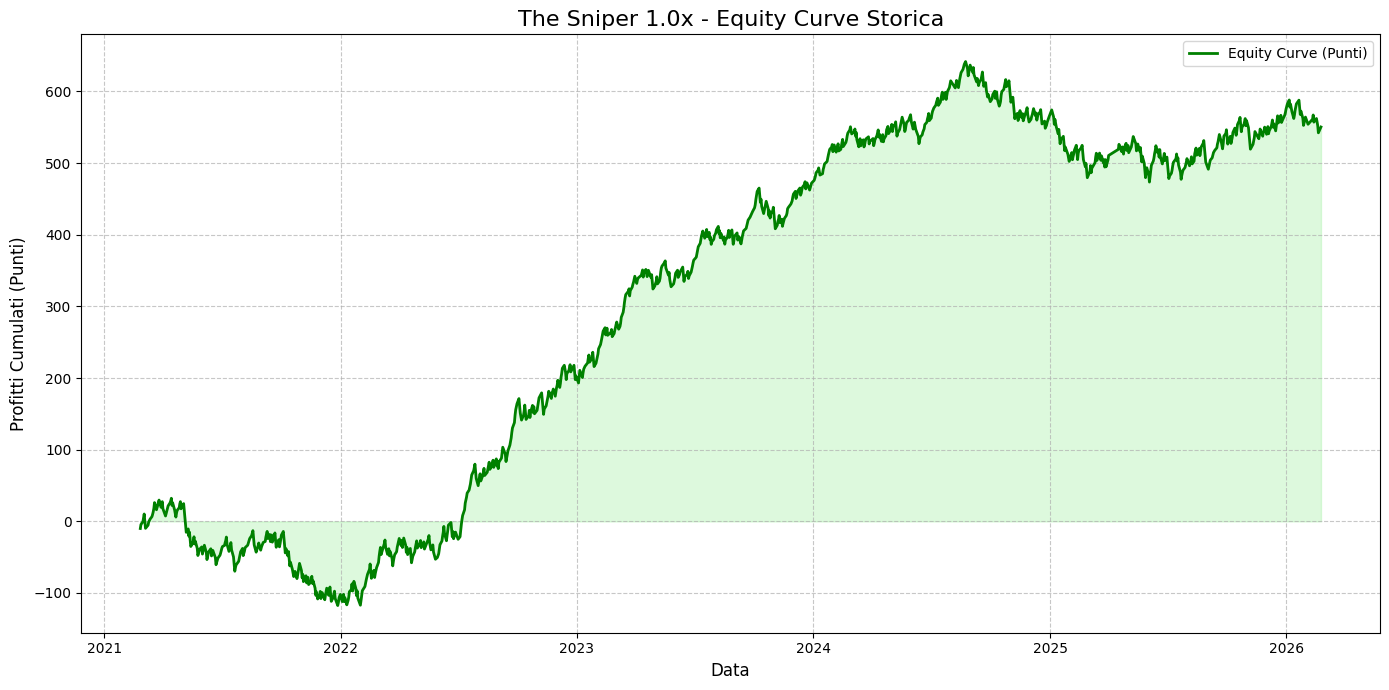

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🏆 THE MASTER ALGORITHM: Backtest Istituzionale Definitivo (1.0x) 🏆")

df_master = df_all.copy()
if 'Quarter' not in df_master.columns:
    df_master['Quarter'] = df_master.index.to_period('Q')

# Coefficienti
c_const = -1.35
c_vol = 1.69
c_rng = 0.146
c_mvol = -0.25

trades = []

for date, day_group in df_master.groupby(df_master.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    micro_vol = or_data['Close'].std()
    or_vol_avg = or_data['Volume'].mean()
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # 1. Trova il Breakout
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_idx = None
    side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_idx = break_up.index[0]; side = 'SHORT'
        else:
            first_break_idx = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break_idx = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break_idx = break_dn.index[0]; side = 'LONG'
        
    if first_break_idx is None: continue
    
    # 2. Calcolo Dinamico 1.0x
    bo_candle = post_or.loc[first_break_idx]
    bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
    
    limit_ext = c_const + (c_vol * bo_vol_ratio) + (c_rng * or_range) + (c_mvol * micro_vol)
    if limit_ext < 1.0: limit_ext = 1.0 
        
    # TP Sicuro (Mediana)
    if or_range < 10.5: tp_pct = 0.32
    elif or_range <= 15.5: tp_pct = 0.24
    else: tp_pct = 0.22
        
    if side == 'SHORT':
        entry_price = or_h + limit_ext
        sl_price = entry_price + 10.0  # Rischio fisso
        tp_price = or_h - (or_range * tp_pct)
    else:
        entry_price = or_l - limit_ext
        sl_price = entry_price - 10.0
        tp_price = or_l + (or_range * tp_pct)
        
    future = post_or.loc[first_break_idx:]
    dummy_future = future.index[-1] + pd.Timedelta(days=1)
    
    if side == 'SHORT':
        fill_events = future[future['High'] >= entry_price]
        if not fill_events.empty:
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            
            sl_hits = trade_path[trade_path['High'] >= sl_price]
            tp_hits = trade_path[trade_path['Low'] <= tp_price]
            
            sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
            tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
            
            if tp_time < sl_time and tp_time != dummy_future:
                pnl = entry_price - tp_price
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': pnl, 'Result': 'WIN'})
            elif sl_time < tp_time and sl_time != dummy_future:
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': -10.0, 'Result': 'LOSS'})
                
    else: # LONG
        fill_events = future[future['Low'] <= entry_price]
        if not fill_events.empty:
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            
            sl_hits = trade_path[trade_path['Low'] <= sl_price]
            tp_hits = trade_path[trade_path['High'] >= tp_price]
            
            sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
            tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
            
            if tp_time < sl_time and tp_time != dummy_future:
                pnl = tp_price - entry_price
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': pnl, 'Result': 'WIN'})
            elif sl_time < tp_time and sl_time != dummy_future:
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': -10.0, 'Result': 'LOSS'})

# Elaborazione Risultati
df_trades = pd.DataFrame(trades)
df_trades['Cum_PnL'] = df_trades['PnL'].cumsum()
df_trades['Peak'] = df_trades['Cum_PnL'].cummax()
df_trades['Drawdown'] = df_trades['Peak'] - df_trades['Cum_PnL']

quarterly_stats = []
for q, group in df_trades.groupby('Quarter'):
    f = len(group)
    w = len(group[group['Result'] == 'WIN'])
    l = len(group[group['Result'] == 'LOSS'])
    wr = (w / f * 100) if f > 0 else 0
    pnl = group['PnL'].sum()
    avg_win = group[group['Result'] == 'WIN']['PnL'].mean()
    avg_loss = abs(group[group['Result'] == 'LOSS']['PnL'].mean())
    rr = avg_win / avg_loss if avg_loss > 0 else 0
    max_dd = group['Drawdown'].max()
    
    quarterly_stats.append({
        'Quarter': q, 'Trades': f, 'WR%': wr, 'Avg Win': avg_win, 'Avg Loss': avg_loss, 'RR': rr, 'Max DD': max_dd, 'PnL': pnl
    })

df_q = pd.DataFrame(quarterly_stats)

print("\n" + "="*95)
print(f"{'Trimestre':<10} | {'Trades':<6} | {'WR%':<7} | {'Avg Win':<8} | {'Avg Loss':<8} | {'RR Ratio':<8} | {'Max DD':<8} | {'PnL (Pt)'}")
print("-" * 95)
for _, r in df_q.iterrows():
    print(f"{r['Quarter']:<10} | {r['Trades']:<6} | {r['WR%']:>6.1f}% | {r['Avg Win']:>8.2f} | {r['Avg Loss']:>8.2f} | 1 : {r['RR']:<4.2f} | {r['Max DD']:>8.2f} | {r['PnL']:>8.2f}")

# Statistiche Globali
tot_trades = len(df_trades)
tot_wins = len(df_trades[df_trades['Result'] == 'WIN'])
tot_pnl = df_trades['PnL'].sum()
global_wr = tot_wins / tot_trades * 100
global_avg_win = df_trades[df_trades['Result'] == 'WIN']['PnL'].mean()
global_avg_loss = abs(df_trades[df_trades['Result'] == 'LOSS']['PnL'].mean())
global_rr = global_avg_win / global_avg_loss
profit_factor = df_trades[df_trades['Result'] == 'WIN']['PnL'].sum() / abs(df_trades[df_trades['Result'] == 'LOSS']['PnL'].sum())
global_max_dd = df_trades['Drawdown'].max()

print("-" * 95)
print(f"TOTALE     | {tot_trades:<6} | {global_wr:>6.1f}% | {global_avg_win:>8.2f} | {global_avg_loss:>8.2f} | 1 : {global_rr:<4.2f} | {global_max_dd:>8.2f} | {tot_pnl:>8.2f}")
print("="*95)
print(f"💰 Profit Factor: {profit_factor:.2f} (Sopra 1.5 è eccellente, sopra 2.0 è il Sacro Graal)")
print(f"📉 Maximum Drawdown Storico: {global_max_dd:.2f} Punti")

# Generazione Grafico
plt.figure(figsize=(14, 7))
plt.plot(df_trades['Date'], df_trades['Cum_PnL'], color='green', linewidth=2, label='Equity Curve (Punti)')
plt.fill_between(df_trades['Date'], df_trades['Cum_PnL'], color='lightgreen', alpha=0.3)
plt.title('The Sniper 1.0x - Equity Curve Storica', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Profitti Cumulati (Punti)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd
import numpy as np

print("🔬 THE RR MATRIX: Grid Search per Rischio/Rendimento (Target >= 1:0.8) 🔬")

df_grid = df_all.copy()
if 'Quarter' not in df_grid.columns:
    df_grid['Quarter'] = df_grid.index.to_period('Q')

# Parametri della Grid Search
multipliers = [1.0, 1.2, 1.3]
sl_risks = [7.0, 8.0, 9.0, 10.0]
tp_stretches = [1.0, 1.2, 1.4] # Moltiplicatore della profondità del TP

# Coefficienti della formula quant
c_const = -1.35; c_vol = 1.69; c_rng = 0.146; c_mvol = -0.25

results_summary = []

for mult in multipliers:
    for sl_risk in sl_risks:
        for tp_stretch in tp_stretches:
            
            fills = 0
            wins = 0
            losses = 0
            pnl_tot = 0
            win_pts = 0
            loss_pts = 0
            
            for date, day_group in df_grid.groupby(df_grid.index.date):
                or_data = day_group.between_time('09:30', '09:44')
                if len(or_data) < 15: continue
                
                or_h, or_l = or_data['High'].max(), or_data['Low'].min()
                or_range = or_h - or_l
                
                if or_range <= 0 or or_range > 30.0: continue
                    
                micro_vol = or_data['Close'].std()
                or_vol_avg = or_data['Volume'].mean()
                
                post_or = day_group.between_time('09:45', '16:00')
                if post_or.empty: continue
                    
                break_up = post_or[post_or['High'] > or_h]
                break_dn = post_or[post_or['Low'] < or_l]
                
                first_break_idx = None; side = None
                
                if not break_up.empty and not break_dn.empty:
                    if break_up.index[0] < break_dn.index[0]:
                        first_break_idx = break_up.index[0]; side = 'SHORT'
                    else:
                        first_break_idx = break_dn.index[0]; side = 'LONG'
                elif not break_up.empty:
                    first_break_idx = break_up.index[0]; side = 'SHORT'
                elif not break_dn.empty:
                    first_break_idx = break_dn.index[0]; side = 'LONG'
                    
                if first_break_idx is None: continue
                
                # Calcolo Ingresso
                bo_candle = post_or.loc[first_break_idx]
                bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
                
                limit_ext = c_const + (c_vol * bo_vol_ratio) + (c_rng * or_range) + (c_mvol * micro_vol)
                if limit_ext < 1.0: limit_ext = 1.0 
                limit_ext = limit_ext * mult
                
                # Calcolo TP (Stretched)
                if or_range < 10.5: tp_pct = 0.32 * tp_stretch
                elif or_range <= 15.5: tp_pct = 0.24 * tp_stretch
                else: tp_pct = 0.22 * tp_stretch
                    
                if side == 'SHORT':
                    entry_price = or_h + limit_ext
                    sl_price = entry_price + sl_risk
                    tp_price = or_h - (or_range * tp_pct)
                else:
                    entry_price = or_l - limit_ext
                    sl_price = entry_price - sl_risk
                    tp_price = or_l + (or_range * tp_pct)
                    
                future = post_or.loc[first_break_idx:]
                dummy_future = future.index[-1] + pd.Timedelta(days=1)
                
                if side == 'SHORT':
                    fill_events = future[future['High'] >= entry_price]
                    if not fill_events.empty:
                        fills += 1
                        trade_path = future.loc[fill_events.index[0]:]
                        
                        sl_hits = trade_path[trade_path['High'] >= sl_price]
                        tp_hits = trade_path[trade_path['Low'] <= tp_price]
                        
                        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
                        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
                        
                        if tp_time < sl_time and tp_time != dummy_future:
                            wins += 1
                            pt_gain = entry_price - tp_price
                            pnl_tot += pt_gain
                            win_pts += pt_gain
                        elif sl_time < tp_time and sl_time != dummy_future:
                            losses += 1
                            pnl_tot -= sl_risk
                            loss_pts += sl_risk
                            
                else: # LONG
                    fill_events = future[future['Low'] <= entry_price]
                    if not fill_events.empty:
                        fills += 1
                        trade_path = future.loc[fill_events.index[0]:]
                        
                        sl_hits = trade_path[trade_path['Low'] <= sl_price]
                        tp_hits = trade_path[trade_path['High'] >= tp_price]
                        
                        sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
                        tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
                        
                        if tp_time < sl_time and tp_time != dummy_future:
                            wins += 1
                            pt_gain = tp_price - entry_price
                            pnl_tot += pt_gain
                            win_pts += pt_gain
                        elif sl_time < tp_time and sl_time != dummy_future:
                            losses += 1
                            pnl_tot -= sl_risk
                            loss_pts += sl_risk

            wr = (wins / fills * 100) if fills > 0 else 0
            avg_win = (win_pts / wins) if wins > 0 else 0
            avg_loss = (loss_pts / losses) if losses > 0 else sl_risk
            rr = avg_win / avg_loss if avg_loss > 0 else 0
            
            results_summary.append({
                'Config': f"E:{mult}x | SL:{sl_risk} | TP:{tp_stretch}x",
                'Fills': fills,
                'WR%': wr,
                'Avg Win': avg_win,
                'RR': rr,
                'PnL': pnl_tot
            })

df_res = pd.DataFrame(results_summary)
# Ordiniamo prima per PnL, ma filtriamo solo le configurazioni che hanno senso
df_res = df_res.sort_values(by='PnL', ascending=False)

print("\n" + "="*90)
print(f"{'Configurazione':<28} | {'Fills':<6} | {'WR%':<6} | {'Avg Win':<8} | {'RR Ratio':<10} | {'PnL Teorico'}")
print("-" * 90)
for _, r in df_res.head(25).iterrows(): # Mostriamo le migliori 25
    rr_str = f"1 : {r['RR']:.2f}"
    # Mettiamo in evidenza se RR >= 0.80
    marker = "🔥" if r['RR'] >= 0.80 else "  "
    print(f"{r['Config']:<28} | {r['Fills']:<6} | {r['WR%']:>5.1f}% | {r['Avg Win']:>7.2f} pt | {rr_str:<10} {marker}| {r['PnL']:>8.2f} pt")
print("="*90)
print("🔥 = Target RR 1:0.80 o superiore raggiunto!")

🔬 THE RR MATRIX: Grid Search per Rischio/Rendimento (Target >= 1:0.8) 🔬

Configurazione               | Fills  | WR%    | Avg Win  | RR Ratio   | PnL Teorico
------------------------------------------------------------------------------------------
E:1.0x | SL:7.0 | TP:1.0x    | 1153   |  64.0% |    4.99 pt | 1 : 0.71     |   877.68 pt
E:1.0x | SL:8.0 | TP:1.0x    | 1153   |  66.2% |    5.00 pt | 1 : 0.62     |   798.24 pt
E:1.2x | SL:7.0 | TP:1.0x    | 1138   |  60.8% |    5.34 pt | 1 : 0.76     |   682.46 pt
E:1.0x | SL:9.0 | TP:1.0x    | 1153   |  67.5% |    5.01 pt | 1 : 0.56     |   628.71 pt
E:1.3x | SL:7.0 | TP:1.0x    | 1125   |  59.5% |    5.50 pt | 1 : 0.79     |   596.63 pt
E:1.0x | SL:7.0 | TP:1.2x    | 1153   |  58.5% |    5.64 pt | 1 : 0.81   🔥|   566.54 pt
E:1.0x | SL:10.0 | TP:1.0x   | 1153   |  69.2% |    5.00 pt | 1 : 0.50     |   550.39 pt
E:1.2x | SL:8.0 | TP:1.0x    | 1138   |  62.7% |    5.34 pt | 1 : 0.67     |   538.97 pt
E:1.2x | SL:7.0 | TP:1.2x    | 1138   | 

🏆 THE APEX PREDATOR: Backtest Definitivo (E:1.0x | SL:7.0 | TP:1.0x) 🏆

Trimestre  | Trades | WR%     | Avg Win  | Avg Loss | RR Ratio | Max DD   | PnL (Pt)
-----------------------------------------------------------------------------------------------
2021Q1     | 23     |   78.3% |     4.30 |     7.00 | 1 : 0.61 |    14.00 |    42.48
2021Q2     | 62     |   59.7% |     3.79 |     7.00 | 1 : 0.54 |    60.12 |   -34.90
2021Q3     | 63     |   69.8% |     3.97 |     7.00 | 1 : 0.57 |    46.07 |    41.85
2021Q4     | 60     |   51.7% |     5.01 |     7.00 | 1 : 0.72 |    74.47 |   -47.55
2022Q1     | 57     |   68.4% |     6.10 |     7.00 | 1 : 0.87 |    65.57 |   111.96
2022Q2     | 50     |   56.0% |     6.57 |     7.00 | 1 : 0.94 |    35.00 |    30.05
2022Q3     | 61     |   75.4% |     6.08 |     7.00 | 1 : 0.87 |    21.00 |   174.80
2022Q4     | 56     |   62.5% |     6.04 |     7.00 | 1 : 0.86 |    28.00 |    64.55
2023Q1     | 57     |   75.4% |     5.05 |     7.00 | 1 : 0.72 |   

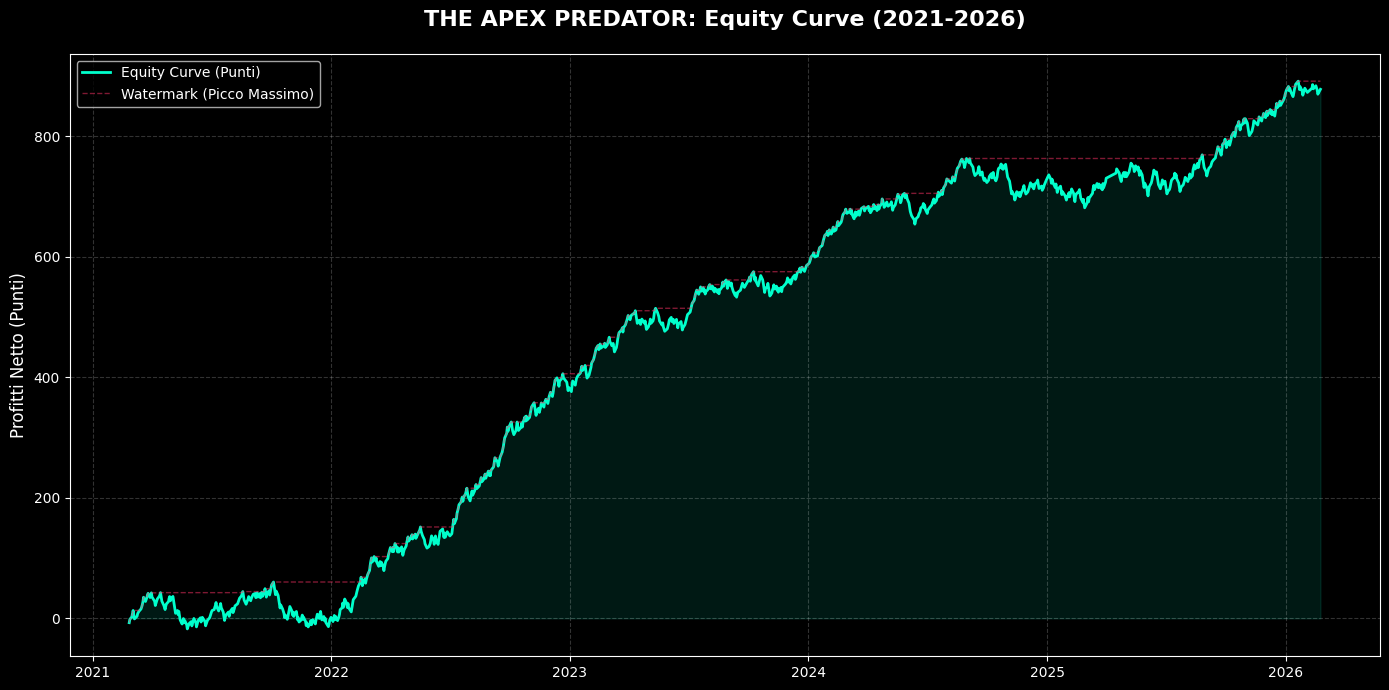

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🏆 THE APEX PREDATOR: Backtest Definitivo (E:1.0x | SL:7.0 | TP:1.0x) 🏆")

df_master = df_all.copy()
if 'Quarter' not in df_master.columns:
    df_master['Quarter'] = df_master.index.to_period('Q')

# Parametri Vincitori della Grid Search
mult = 1.0
sl_risk = 7.0
tp_stretch = 1.0

# Coefficienti della formula quant
c_const = -1.35; c_vol = 1.69; c_rng = 0.146; c_mvol = -0.25

trades = []

for date, day_group in df_master.groupby(df_master.index.date):
    or_data = day_group.between_time('09:30', '09:44')
    if len(or_data) < 15: continue
    
    or_h, or_l = or_data['High'].max(), or_data['Low'].min()
    or_range = or_h - or_l
    
    if or_range <= 0 or or_range > 30.0: continue
        
    micro_vol = or_data['Close'].std()
    or_vol_avg = or_data['Volume'].mean()
    
    post_or = day_group.between_time('09:45', '16:00')
    if post_or.empty: continue
        
    # 1. Trova il Breakout
    break_up = post_or[post_or['High'] > or_h]
    break_dn = post_or[post_or['Low'] < or_l]
    
    first_break_idx = None; side = None
    
    if not break_up.empty and not break_dn.empty:
        if break_up.index[0] < break_dn.index[0]:
            first_break_idx = break_up.index[0]; side = 'SHORT'
        else:
            first_break_idx = break_dn.index[0]; side = 'LONG'
    elif not break_up.empty:
        first_break_idx = break_up.index[0]; side = 'SHORT'
    elif not break_dn.empty:
        first_break_idx = break_dn.index[0]; side = 'LONG'
        
    if first_break_idx is None: continue
    
    # 2. Calcolo Ingresso e Target
    bo_candle = post_or.loc[first_break_idx]
    bo_vol_ratio = bo_candle['Volume'] / or_vol_avg if or_vol_avg > 0 else 1
    
    limit_ext = c_const + (c_vol * bo_vol_ratio) + (c_rng * or_range) + (c_mvol * micro_vol)
    if limit_ext < 1.0: limit_ext = 1.0 
    limit_ext = limit_ext * mult
    
    if or_range < 10.5: tp_pct = 0.32 * tp_stretch
    elif or_range <= 15.5: tp_pct = 0.24 * tp_stretch
    else: tp_pct = 0.22 * tp_stretch
        
    if side == 'SHORT':
        entry_price = or_h + limit_ext
        sl_price = entry_price + sl_risk
        tp_price = or_h - (or_range * tp_pct)
    else:
        entry_price = or_l - limit_ext
        sl_price = entry_price - sl_risk
        tp_price = or_l + (or_range * tp_pct)
        
    # 3. Simulazione Trade
    future = post_or.loc[first_break_idx:]
    dummy_future = future.index[-1] + pd.Timedelta(days=1)
    
    if side == 'SHORT':
        fill_events = future[future['High'] >= entry_price]
        if not fill_events.empty:
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            
            sl_hits = trade_path[trade_path['High'] >= sl_price]
            tp_hits = trade_path[trade_path['Low'] <= tp_price]
            
            sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
            tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
            
            if tp_time < sl_time and tp_time != dummy_future:
                pnl = entry_price - tp_price
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': pnl, 'Result': 'WIN'})
            elif sl_time < tp_time and sl_time != dummy_future:
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': -sl_risk, 'Result': 'LOSS'})
                
    else: # LONG
        fill_events = future[future['Low'] <= entry_price]
        if not fill_events.empty:
            fill_idx = fill_events.index[0]
            trade_path = future.loc[fill_idx:]
            
            sl_hits = trade_path[trade_path['Low'] <= sl_price]
            tp_hits = trade_path[trade_path['High'] >= tp_price]
            
            sl_time = sl_hits.index[0] if not sl_hits.empty else dummy_future
            tp_time = tp_hits.index[0] if not tp_hits.empty else dummy_future
            
            if tp_time < sl_time and tp_time != dummy_future:
                pnl = tp_price - entry_price
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': pnl, 'Result': 'WIN'})
            elif sl_time < tp_time and sl_time != dummy_future:
                trades.append({'Date': fill_idx, 'Quarter': str(fill_idx.to_period('Q')), 'PnL': -sl_risk, 'Result': 'LOSS'})

# --- ELABORAZIONE DATI ---
df_trades = pd.DataFrame(trades)
df_trades = df_trades.sort_values('Date').reset_index(drop=True)
df_trades['Cum_PnL'] = df_trades['PnL'].cumsum()
df_trades['Peak'] = df_trades['Cum_PnL'].cummax()
df_trades['Drawdown'] = df_trades['Peak'] - df_trades['Cum_PnL']

quarterly_stats = []
for q, group in df_trades.groupby('Quarter'):
    f = len(group)
    w = len(group[group['Result'] == 'WIN'])
    l = len(group[group['Result'] == 'LOSS'])
    wr = (w / f * 100) if f > 0 else 0
    pnl = group['PnL'].sum()
    avg_win = group[group['Result'] == 'WIN']['PnL'].mean()
    avg_loss = abs(group[group['Result'] == 'LOSS']['PnL'].mean())
    rr = avg_win / avg_loss if avg_loss > 0 else 0
    max_dd = group['Drawdown'].max()
    
    quarterly_stats.append({
        'Quarter': q, 'Trades': f, 'WR%': wr, 'Avg Win': avg_win, 'Avg Loss': avg_loss, 'RR': rr, 'Max DD': max_dd, 'PnL': pnl
    })

df_q = pd.DataFrame(quarterly_stats)

print("\n" + "="*95)
print(f"{'Trimestre':<10} | {'Trades':<6} | {'WR%':<7} | {'Avg Win':<8} | {'Avg Loss':<8} | {'RR Ratio':<8} | {'Max DD':<8} | {'PnL (Pt)'}")
print("-" * 95)
for _, r in df_q.iterrows():
    print(f"{r['Quarter']:<10} | {r['Trades']:<6} | {r['WR%']:>6.1f}% | {r['Avg Win']:>8.2f} | {r['Avg Loss']:>8.2f} | 1 : {r['RR']:<4.2f} | {r['Max DD']:>8.2f} | {r['PnL']:>8.2f}")

# Statistiche Globali
tot_trades = len(df_trades)
tot_wins = len(df_trades[df_trades['Result'] == 'WIN'])
tot_pnl = df_trades['PnL'].sum()
global_wr = tot_wins / tot_trades * 100
global_avg_win = df_trades[df_trades['Result'] == 'WIN']['PnL'].mean()
global_avg_loss = abs(df_trades[df_trades['Result'] == 'LOSS']['PnL'].mean())
global_rr = global_avg_win / global_avg_loss
profit_factor = df_trades[df_trades['Result'] == 'WIN']['PnL'].sum() / abs(df_trades[df_trades['Result'] == 'LOSS']['PnL'].sum())
global_max_dd = df_trades['Drawdown'].max()

print("-" * 95)
print(f"TOTALE     | {tot_trades:<6} | {global_wr:>6.1f}% | {global_avg_win:>8.2f} | {global_avg_loss:>8.2f} | 1 : {global_rr:<4.2f} | {global_max_dd:>8.2f} | {tot_pnl:>8.2f}")
print("="*95)
print(f"💰 Profit Factor Globale: {profit_factor:.2f}")
print(f"💵 Valore Generato (a $50/pt): ${tot_pnl * 50:,.2f}")

# --- GRAFICO EQUITY CURVE ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_trades['Date'], df_trades['Cum_PnL'], color='#00ffcc', linewidth=2, label='Equity Curve (Punti)')
ax.fill_between(df_trades['Date'], df_trades['Cum_PnL'], color='#00ffcc', alpha=0.1)

# Annotiamo i Drawdown
ax.plot(df_trades['Date'], df_trades['Peak'], color='#ff3366', linewidth=1, linestyle='--', alpha=0.5, label='Watermark (Picco Massimo)')

ax.set_title('THE APEX PREDATOR: Equity Curve (2021-2026)', fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_ylabel('Profitti Netto (Punti)', fontsize=12, color='white')
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()